# Geocoding Analysis

## 1. First Analysis
General density and coverage exploration, not tied to a specific classification method.

combines geocoded final/ files, builds Profession/Category/Occupation classifications, density maps, thesis stats

## Imports

In [15]:
import os
import sys
import glob
import re
import json
import time
import math
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial import cKDTree
from openai import OpenAI, APIConnectionError
from rapidfuzz import fuzz

_dt = datetime  # some cells below use this alias


## Configuration

In [16]:
# sys.path.insert(0, "/content/drive/MyDrive/Venezia_Almanac_1947")  # if needed

from config import (
    LOCAL_ALMANAC_ROOT,
    FINAL_OUTPUT_DIR,
    DRIVE_ROOT_FOLDER,
    DRIVE_GEOSPATIAL_FOLDER,
    DRIVE_FINAL_FOLDER,
    OPENAI_KEY_FILE,
    SAVE_MODE,
    SESTIERE_PATH,
    STATS_GEO_DIR,
    DRIVE_STATS_FOLDER,
)

# loaded once, shared by every heatmap cell below for sestiere-outline context
sestieri = gpd.read_file(SESTIERE_PATH).to_crs(epsg=4326)

# RUN_TAG so outputs don't overwrite the previous run
RUN_TAG = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Notebook 08 run tag: {RUN_TAG}")

def _v(name):
    stem, ext = os.path.splitext(name)
    return f"{stem}_{RUN_TAG}{ext}"

FINAL_DIR = FINAL_OUTPUT_DIR
OUTPUT_COMBINED_CSV = os.path.join(FINAL_DIR, _v("combined_geocoded_inside_venice.csv"))
OUTPUT_COMBINED_GEOJSON = os.path.join(FINAL_DIR, _v("combined_geocoded_inside_venice.geojson"))

TARGET_FILE_KEYWORDS = [
    "ref_table_all_pages_20260721_1901_geocoded",
    "manual_matched",
    "nciv_check_matched",
    "nciv_interpolated_matched",
    "nominatim_inside_matched_20260722_1042",
]

def matches_target(basename):
    b = basename.lower()
    return any(kw.lower() in b for kw in TARGET_FILE_KEYWORDS)

TOP_N_CATEGORIES = 6
GRIDSIZE_OVERALL = 60
GRIDSIZE_CATEGORY = 40

VENICE_BBOX = {
    "lat_min": 45.20, "lat_max": 45.55,
    "lon_min": 12.15, "lon_max": 12.55,
}


OCR_GARBAGE_PATTERN = re.compile(r"^[\W_]+$|^.$")

def _is_ocr_garbage(value, placeholder_tokens):
    if pd.isna(value):
        return False
    v = str(value).strip()
    if v in placeholder_tokens:
        return True
    if len(v) <= 1:
        return True
    if OCR_GARBAGE_PATTERN.match(v):
        return True
    return False

FORCE_REFRESH_FROM_DRIVE = False

# Dedicated folder at Drive root for all stats/geo-analysis outputs from this stage (separate from the geocoding pipeline's final/ folder).
STATS_FOLDER_NAME = DRIVE_STATS_FOLDER


Notebook 08 run tag: 20260824_161514


## Drive helpers

In [17]:
from drive_utils import (
    get_drive_service,
    find_folder,
    get_or_create_folder,
    list_files_in_folder,
    download_drive_file,
    upload_bytes,
    save_or_upload_text,
    save_or_upload_geojson,
    normalize_tier_column,
)


## Load target files (local, Drive fallback)

In [18]:
service = get_drive_service()
root_id = find_folder(service, DRIVE_ROOT_FOLDER)

os.makedirs(FINAL_DIR, exist_ok=True)

if FORCE_REFRESH_FROM_DRIVE:
    stale = [p for p in glob.glob(os.path.join(FINAL_DIR, "**", "*"), recursive=True)
             if os.path.isfile(p) and matches_target(os.path.splitext(os.path.basename(p))[0])]
    if stale:
        print(f"FORCE_REFRESH_FROM_DRIVE is True — removing {len(stale)} stale local target file(s) first.")
        for p in stale:
            os.remove(p)

local_target_csvs_present = [
    p for p in glob.glob(os.path.join(FINAL_DIR, "**", "*.csv"), recursive=True)
    if matches_target(os.path.splitext(os.path.basename(p))[0])
]

if not local_target_csvs_present:
    print(f"Local folder '{FINAL_DIR}' is empty — falling back to Drive.")

    geo_id = find_folder(service, DRIVE_GEOSPATIAL_FOLDER, root_id)
    final_id = find_folder(service, DRIVE_FINAL_FOLDER, geo_id)

    if final_id is None:
        raise RuntimeError(
            "Could not locate the Drive final/ folder via "
            f"{DRIVE_ROOT_FOLDER}/{DRIVE_GEOSPATIAL_FOLDER}/{DRIVE_FINAL_FOLDER} "
            "— check the DRIVE_* folder names in config.py."
        )

    drive_files = list_files_in_folder(service, final_id)
    print(f"Found {len(drive_files)} items in Drive final/ folder.")

    csv_by_base = {
        os.path.splitext(f["name"])[0]: f
        for f in drive_files if f["name"].lower().endswith(".csv")
    }
    geojson_by_base = {
        os.path.splitext(f["name"])[0]: f
        for f in drive_files if f["name"].lower().endswith(".geojson")
    }
    paired_bases = set(csv_by_base) & set(geojson_by_base)
    target_bases = {b for b in paired_bases if matches_target(b)}

    print(f"{len(paired_bases)} CSV+GeoJSON pairs on Drive total; "
          f"{len(target_bases)} match the inside-Venice target file list:")
    for b in sorted(target_bases):
        print("  -", b)

    for base in target_bases:
        for f in (csv_by_base[base], geojson_by_base[base]):
            dest = os.path.join(FINAL_DIR, f["name"])
            download_drive_file(service, f["id"], dest)

    print(f"Downloaded {len(target_bases)} target pairs to {FINAL_DIR}")
else:
    print(f"Using {len(local_target_csvs_present)} target CSVs already present locally in {FINAL_DIR} — skipping Drive fetch.")


Using 5 target CSVs already present locally in ./geospatial/final — skipping Drive fetch.


## Combine target files

In [19]:
csv_files = glob.glob(os.path.join(FINAL_DIR, "**", "*.csv"), recursive=True)
geojson_files = glob.glob(os.path.join(FINAL_DIR, "**", "*.geojson"), recursive=True)
geojson_by_base = {os.path.splitext(os.path.basename(p))[0]: p for p in geojson_files}

dfs = []
skipped_no_geojson = []
skipped_not_target = []
for csv_path in csv_files:
    base = os.path.splitext(os.path.basename(csv_path))[0]
    if not matches_target(base):
        skipped_not_target.append(base)
        continue
    if base not in geojson_by_base:
        skipped_no_geojson.append(base)
        continue
    df = pd.read_csv(csv_path)
    df["source_file"] = base
    dfs.append(df)

if not dfs:
    raise RuntimeError(
        "No matching target files found — check TARGET_FILE_KEYWORDS "
        "against your actual filenames."
    )

combined = pd.concat(dfs, ignore_index=True)
combined = normalize_tier_column(combined)
print(f"Combined {len(dfs)} target file(s) -> {len(combined)} rows total.")
if skipped_no_geojson:
    print(f"Skipped {len(skipped_no_geojson)} target-named CSVs missing a .geojson: {skipped_no_geojson}")

combined.to_csv(OUTPUT_COMBINED_CSV, index=False)
print(f"Saved combined file -> {OUTPUT_COMBINED_CSV}")

combined_geo = combined.dropna(subset=["matched_lat", "matched_lon"]).copy()
if not combined_geo.empty:
    gdf = gpd.GeoDataFrame(
        combined_geo,
        geometry=gpd.points_from_xy(
            combined_geo["matched_lon"].astype(float),
            combined_geo["matched_lat"].astype(float),
        ),
        crs="EPSG:4326",
    )
    gdf.to_file(OUTPUT_COMBINED_GEOJSON, driver="GeoJSON")
    print(f"Saved combined geojson -> {OUTPUT_COMBINED_GEOJSON}")


Combined 5 target file(s) -> 16475 rows total.
Saved combined file -> ./geospatial/final/combined_geocoded_inside_venice_20260824_161514.csv


## Clean & validate coordinates

In [20]:
geo = combined.dropna(subset=["matched_lat", "matched_lon"]).copy()
geo["matched_lat"] = pd.to_numeric(geo["matched_lat"], errors="coerce")
geo["matched_lon"] = pd.to_numeric(geo["matched_lon"], errors="coerce")
geo = geo.dropna(subset=["matched_lat", "matched_lon"])

print(f"{len(geo)} matched, geocoded points (out of {len(combined)} total rows in the target files).")

# ── Venice bounding box check ──

n_before_bbox = len(geo)
in_bbox = (
    geo["matched_lat"].between(VENICE_BBOX["lat_min"], VENICE_BBOX["lat_max"]) &
    geo["matched_lon"].between(VENICE_BBOX["lon_min"], VENICE_BBOX["lon_max"])
)
out_of_bbox = geo[~in_bbox]
geo = geo[in_bbox]
n_dropped_bbox = n_before_bbox - len(geo)

print(f"Dropped {n_dropped_bbox} rows outside the Venice bounding box "
      f"(lat {VENICE_BBOX['lat_min']}-{VENICE_BBOX['lat_max']}, "
      f"lon {VENICE_BBOX['lon_min']}-{VENICE_BBOX['lon_max']}).")
if n_dropped_bbox > 0:
    print("Dropped rows preview (first 10):")
    print(out_of_bbox[["Name", "Address", "matched_lat", "matched_lon", "source_file"]].head(10))
print(f"{len(geo)} points remain after bbox check.")

# ── Coordinate sanity check ──

print("matched_lat range:", geo["matched_lat"].min(), "-", geo["matched_lat"].max())
print("matched_lon range:", geo["matched_lon"].min(), "-", geo["matched_lon"].max())
print("(Expected roughly: lat 45.3-45.5, lon 12.2-12.4 for Venice)")


16475 matched, geocoded points (out of 16475 total rows in the target files).
Dropped 6 rows outside the Venice bounding box (lat 45.2-45.55, lon 12.15-12.55).
Dropped rows preview (first 10):
                     Name                    Address  matched_lat  \
438                   NaN   Via Fratelli Bandiera 21    45.957168   
3740        Toniolo Maria           Via Marghera 105    45.390030   
4464         I.N.T.R.E.V.           Via Mazzini 5110    45.455172   
6947          La Vittoria               Via Rosa, 22    45.923547   
8705       Brunello Luigi               Via Costa 10    46.214345   
12143  Pintureiro Carmelo                Via Rosa 27    45.924318   

       matched_lon                       source_file  
438      12.664532  all_pages_20260721_1901_geocoded  
3740     12.139285  all_pages_20260721_1901_geocoded  
4464     12.068014  all_pages_20260721_1901_geocoded  
6947     12.875540  all_pages_20260721_1901_geocoded  
8705     12.988060  all_pages_20260721_1901_geoc

## Stats output folder + most-repeated coordinates

In [21]:
# Creates (or reuses) stats_geo_analysis/ at Drive root, and uploads  tables from this analysis stage there 

_stats_folder_id = get_or_create_folder(service, STATS_FOLDER_NAME, root_id)

STATS_LOCAL_DIR = Path(STATS_GEO_DIR)
STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)

# occupation_merge and occupation_clustering both fold into "occupation"
STATS_SUBFOLDER_RENAME = {
    "category_clustering": "category",
    "profession_clustering": "profession",
    "occupation_clustering": "occupation",
    "occupation_merge": "occupation",
    "general": "general",
}

def upload_to_stats(name, content_bytes, mimetype, subfolder=None):
    name = _v(name)
    if subfolder in STATS_SUBFOLDER_RENAME:
        subfolder = f"{STATS_SUBFOLDER_RENAME[subfolder]}/{'figures' if mimetype == 'image/png' else 'csv'}"
    run_subfolder = f"{RUN_TAG}/{subfolder}" if subfolder else RUN_TAG
    local_dir = STATS_LOCAL_DIR / run_subfolder
    local_dir.mkdir(parents=True, exist_ok=True)
    folder_id = _stats_folder_id
    for part in Path(run_subfolder).parts:
        folder_id = get_or_create_folder(service, part, folder_id)
    if mimetype.startswith("text/"):
        save_or_upload_text(content_bytes.decode("utf-8"), local_dir / name,
                             service, folder_id, SAVE_MODE)
    else:
        if SAVE_MODE in ("local", "both"):
            try:
                (local_dir / name).write_bytes(content_bytes)
            except OSError as e:
                print(f"  WARNING: local write failed for {name} — {e}")
        if SAVE_MODE in ("drive", "both"):
            upload_bytes(service, content_bytes, name, mimetype, folder_id)
    dest_label = f"{STATS_FOLDER_NAME}/{run_subfolder}/"
    print(f"Saved ({SAVE_MODE}) to {dest_label}: {name}")

# --- Most-repeated coordinates table ---
TOP_N_COORDS = 20

coord_stats = geo.groupby(["matched_lat", "matched_lon"]).agg(
    n_entries=("Name", "size"),
    place_name=("Address", "first"),
).reset_index().sort_values("n_entries", ascending=False)

top_places = coord_stats.head(TOP_N_COORDS)[["place_name", "matched_lat", "matched_lon", "n_entries"]]
top_places.columns = ["Lieu / Adresse", "Latitude", "Longitude", "Nombre d'entrées"]

print(f"\nTop {TOP_N_COORDS} lieux les plus fréquents (intra muros) :\n")
print(top_places.to_string(index=False))

csv_bytes = top_places.to_csv(index=False).encode("utf-8")
upload_to_stats("top_repeated_coordinates.csv", csv_bytes, "text/csv", subfolder="general")

print(f"\n=== STEP 5 DONE — outputs in Drive: {DRIVE_ROOT_FOLDER}/{STATS_FOLDER_NAME}/ ===")


Top 20 lieux les plus fréquents (intra muros) :

                                                         Lieu / Adresse  Latitude  Longitude  Nombre d'entrées
   Palazzi Foscari, Giustinian e Rio Nuovo, Anagrafi: 3226, 3232 e 3881 45.427566  12.321626               124
              Palazzo del Governo - S. Maurizio, fondamenta Zaguri 2662 45.432689  12.331900                78
                                                            San Trovaso 45.430788  12.326027                71
                                                          San Luca 4041 45.435831  12.333414                63
                                                      Rialto numero 199 45.439192  12.335370                58
                                                        Palazzo Loredan 45.432843  12.329840                55
                                            CAMPO S. BARTOLOMEO N. 5379 45.437679  12.336811                52
BASILICA PATRIARCALE PRIMARIZIALE METROPOLITANA DI S. MARCO EV

In [22]:
# hexagon size + shared heatmap window -- derived from real data spacing instead of eyeballing it

HEATMAP_LON_MIN, HEATMAP_LON_MAX = 12.31, 12.365
HEATMAP_LAT_MIN, HEATMAP_LAT_MAX = 45.420, 45.450

geo_heatmap_zoom = geo[
    geo["matched_lon"].between(HEATMAP_LON_MIN, HEATMAP_LON_MAX) &
    geo["matched_lat"].between(HEATMAP_LAT_MIN, HEATMAP_LAT_MAX)
]

# nearest-neighbor distance between distinct addresses, not rows
geo_zoom_pts = geo_heatmap_zoom.drop_duplicates(subset=["matched_lat", "matched_lon"])

# scale lon by cos(latitude) to get meters
LAT0 = geo_zoom_pts["matched_lat"].mean()
M_PER_DEG_LAT = 111_320
M_PER_DEG_LON = 111_320 * math.cos(math.radians(LAT0))

xy_m = np.column_stack([
    geo_zoom_pts["matched_lon"].to_numpy() * M_PER_DEG_LON,
    geo_zoom_pts["matched_lat"].to_numpy() * M_PER_DEG_LAT,
])

tree = cKDTree(xy_m)
nn_dist_m, _ = tree.query(xy_m, k=2)  # k=1 result is the point itself (distance 0)
nn_dist_m = nn_dist_m[:, 1]

median_nn_m = float(np.median(nn_dist_m))
p25_nn_m = float(np.percentile(nn_dist_m, 25))

print(f"{len(geo_zoom_pts)} distinct addresses in the zoomed map extent.")
print(f"Nearest-neighbor distance between distinct addresses:")
print(f"  median  : {median_nn_m:.1f} m")
print(f"  25th pct: {p25_nn_m:.1f} m")

extent_m = (HEATMAP_LON_MAX - HEATMAP_LON_MIN) * M_PER_DEG_LON
target_hex_width_m = median_nn_m
GRIDSIZE_OVERALL_ZOOM = int(round(extent_m / target_hex_width_m))

print(f"\nMap extent (zoomed, east-west): {extent_m:.0f} m")
print(f"Target hex width: {target_hex_width_m:.1f} m (median address spacing)")
print(f"Derived gridsize: {GRIDSIZE_OVERALL_ZOOM}")


6473 distinct addresses in the zoomed map extent.
Nearest-neighbor distance between distinct addresses:
  median  : 6.5 m
  25th pct: 3.7 m

Map extent (zoomed, east-west): 4296 m
Target hex width: 6.5 m (median address spacing)
Derived gridsize: 664


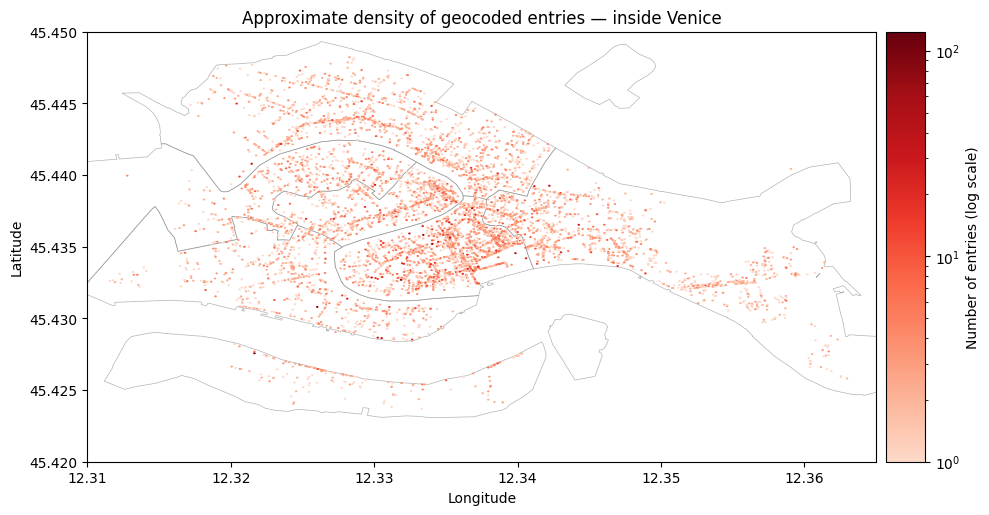

In [101]:
# overall density heatmap -- HEATMAP_LON/LAT_MIN/MAX, geo_heatmap_zoom and
# GRIDSIZE_OVERALL_ZOOM all come from the hexagon-size cell above

DENSITY_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "darker_reds", plt.cm.Reds(np.linspace(0.15, 1.0, 256))
)

fig, ax = plt.subplots(figsize=(10, 8))
sestieri.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.6, zorder=0)
hb = ax.hexbin(
    geo_heatmap_zoom["matched_lon"], geo_heatmap_zoom["matched_lat"],
    gridsize=GRIDSIZE_OVERALL_ZOOM, cmap=DENSITY_CMAP, mincnt=1, bins="log", zorder=1
)
ax.set_title(f"Approximate density of geocoded entries \u2014 inside Venice")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(HEATMAP_LON_MIN, HEATMAP_LON_MAX)
ax.set_ylim(HEATMAP_LAT_MIN, HEATMAP_LAT_MAX)
ax.set_aspect("equal")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(hb, cax=cax, label="Number of entries (log scale)")
plt.tight_layout()
plt.savefig(_v("heatmap_overall_inside_venice.png"), dpi=200)
plt.show()


In [24]:
# what's driving the densest hexagons: one busy institution (shared address) or a genuinely dense area (many different addresses)?


TOP_N_DENSE_CELLS = 10

# approximate hexbin resolution with a simple square grid
_dense_grid_size_lon = (HEATMAP_LON_MAX - HEATMAP_LON_MIN) / GRIDSIZE_OVERALL_ZOOM

geo_dense = geo_heatmap_zoom.copy()
geo_dense["grid_lat"] = (geo_dense["matched_lat"] / _dense_grid_size_lon).round() * _dense_grid_size_lon
geo_dense["grid_lon"] = (geo_dense["matched_lon"] / _dense_grid_size_lon).round() * _dense_grid_size_lon

grid_counts = geo_dense.groupby(["grid_lat", "grid_lon"]).size().sort_values(ascending=False)

_lat0 = geo_dense["matched_lat"].mean()
_cell_width_m = _dense_grid_size_lon * 111_320 * math.cos(math.radians(_lat0))
print(f"Approximate cell width: {_dense_grid_size_lon:.6f} degrees (~{_cell_width_m:.0f} m)")
print(f"\nTop {TOP_N_DENSE_CELLS} densest cells:\n")
print(grid_counts.head(TOP_N_DENSE_CELLS).to_string())

for (glat, glon), n_entries in grid_counts.head(TOP_N_DENSE_CELLS).items():
    cell = geo_dense[(geo_dense["grid_lat"] == glat) & (geo_dense["grid_lon"] == glon)]
    n_unique_addr = cell["Address"].nunique() if "Address" in cell.columns else None

    print(f"\n{'='*70}")
    print(f"Cell ({glat:.5f}, {glon:.5f}) — {n_entries} entries"
          + (f", {n_unique_addr} distinct address(es)" if n_unique_addr is not None else ""))
    print(f"{'='*70}")

    if n_unique_addr is not None:
        if n_unique_addr <= 2:
            print("-> mostly ONE shared address -- institution-driven density, "
                  "not a genuinely dense area of many different buildings.")
        else:
            print(f"-> {n_unique_addr} distinct addresses -- a genuinely dense area, "
                  "not concentration at a single institution.")

    if "sestiere_parsed" in cell.columns:
        print("Sestiere:", cell["sestiere_parsed"].value_counts().head(3).to_dict())

    for col in ("Profession", "Role", "Category"):
        if col in cell.columns and cell[col].notna().any():
            print(f"Top {col} values here:", cell[col].value_counts().head(3).to_dict())

    print("\nSample entries:")
    cols = [c for c in ("Name", "Address", "Profession", "Role", "section") if c in cell.columns]
    print(cell[cols].drop_duplicates(subset="Address").head(5).to_string(index=False))


Approximate cell width: 0.000083 degrees (~6 m)

Top 10 densest cells:

grid_lat   grid_lon 
45.427598  12.321657    124
45.432651  12.331928     78
45.430828  12.326047     71
45.435798  12.333419     63
45.439194  12.335407     58
45.432816  12.329857     55
45.437703  12.336815     52
45.435218  12.334081     48
45.434556  12.339797     46
45.434721  12.338554     42

Cell (45.42760, 12.32166) — 124 entries, 2 distinct address(es)
-> mostly ONE shared address -- institution-driven density, not a genuinely dense area of many different buildings.
Sestiere: {}
Top Profession values here: {'Personale degli Uffici - Segreteria della Sezione di Lingue e letterature straniere': 10, 'Personale degli Uffici - Segreteria della Sezione di Economia e Commercio': 4, 'Lingua tedesca': 4}
Top Role values here: {'Professore incaricato': 26, 'Professore ordinario': 13, 'ASSISTENTI E LETTORI': 13}
Top Category values here: {'Istituto Universitario di Economia e Commercio': 1}

Sample entries:
       

In [25]:
# coordinate duplication: same address (expected) vs different
# addresses collapsed onto one point (a real precision issue)

coord_stats = geo.groupby(["matched_lat", "matched_lon"]).agg(
    n_entries=("Name", "size"),
    n_unique_addresses=("Address", "nunique"),
    representative_address=("Address", "first"),
).reset_index().sort_values("n_entries", ascending=False)

# flag rows where Address text actually varies at a shared coordinate
coord_stats["single_address_only"] = coord_stats["n_unique_addresses"] == 1

print("Top 20 most-repeated coordinates:")
print(coord_stats.head(20)[
    ["matched_lat", "matched_lon", "n_entries", "n_unique_addresses",
     "representative_address", "single_address_only"]
].to_string(index=False))

total_rows = len(geo)
n_coords_total = len(coord_stats)
shared_coords = coord_stats[coord_stats["n_entries"] > 1]
unique_coords = coord_stats[coord_stats["n_entries"] == 1]

rows_at_shared = shared_coords["n_entries"].sum()
rows_at_unique = unique_coords["n_entries"].sum()

genuinely_mixed = shared_coords[~shared_coords["single_address_only"]]
rows_at_mixed = genuinely_mixed["n_entries"].sum()

print(f"\n{'='*65}")
print("SUMMARY")
print(f"{'='*65}")
print(f"Total rows                              : {total_rows}")
print(f"Distinct coordinates used                : {n_coords_total}")
print(f"Rows at a unique (unshared) coordinate    : {rows_at_unique} ({100*rows_at_unique/total_rows:.1f}%)")
print(f"Rows at a shared coordinate (n>1)         : {rows_at_shared} ({100*rows_at_shared/total_rows:.1f}%)")
print(f"  of which: same Address text (expected)  : {rows_at_shared - rows_at_mixed} "
      f"({100*(rows_at_shared - rows_at_mixed)/total_rows:.1f}%)")
print(f"  of which: DIFFERENT Address text (flag)  : {rows_at_mixed} "
      f"({100*rows_at_mixed/total_rows:.1f}%)")
print(f"Number of shared coordinates (n>1)        : {len(shared_coords)}")
print(f"  of which mixing different addresses      : {len(genuinely_mixed)}")

_coord_table_name = _v("coordinate_duplication_table.csv")
coord_stats.to_csv(_coord_table_name, index=False)
print(f"\nSaved full table -> {_coord_table_name}")

Top 20 most-repeated coordinates:
 matched_lat  matched_lon  n_entries  n_unique_addresses                                                  representative_address  single_address_only
   45.427566    12.321626        124                   2    Palazzi Foscari, Giustinian e Rio Nuovo, Anagrafi: 3226, 3232 e 3881                False
   45.432689    12.331900         78                   1               Palazzo del Governo - S. Maurizio, fondamenta Zaguri 2662                 True
   45.430788    12.326027         71                   8                                                             San Trovaso                False
   45.435831    12.333414         63                   2                                                           San Luca 4041                False
   45.439192    12.335370         58                   3                                                       Rialto numero 199                False
   45.432843    12.329840         55                   6          


Category
Rows with a Category value: 12505 / 16469 (75.9%)

Top 20 'Category' values:
Category
Agenzie di trasporto                                   323
OFFICINA RIPARAZIONI MACCHINE PER SCRIVERE             322
Camicerie da uomo                                      238
Trattorie                                              177
MACCHINE per scrivere -- Calcolatrici - Duplicatori    167
Olimpia Film                                           162
Nuova Editoriale S. A.                                 157
Macchine per scrivere                                  144
Paganotto Elsa                                         138
Alimentari                                             135
VALESE LUIGI                                           131
cappelano S. Bingio (Chiesa della Marina).             105
Strti da uomo                                          101
Bar                                                     93
Latterie                                                84
MOBILI e ACCESSORI 

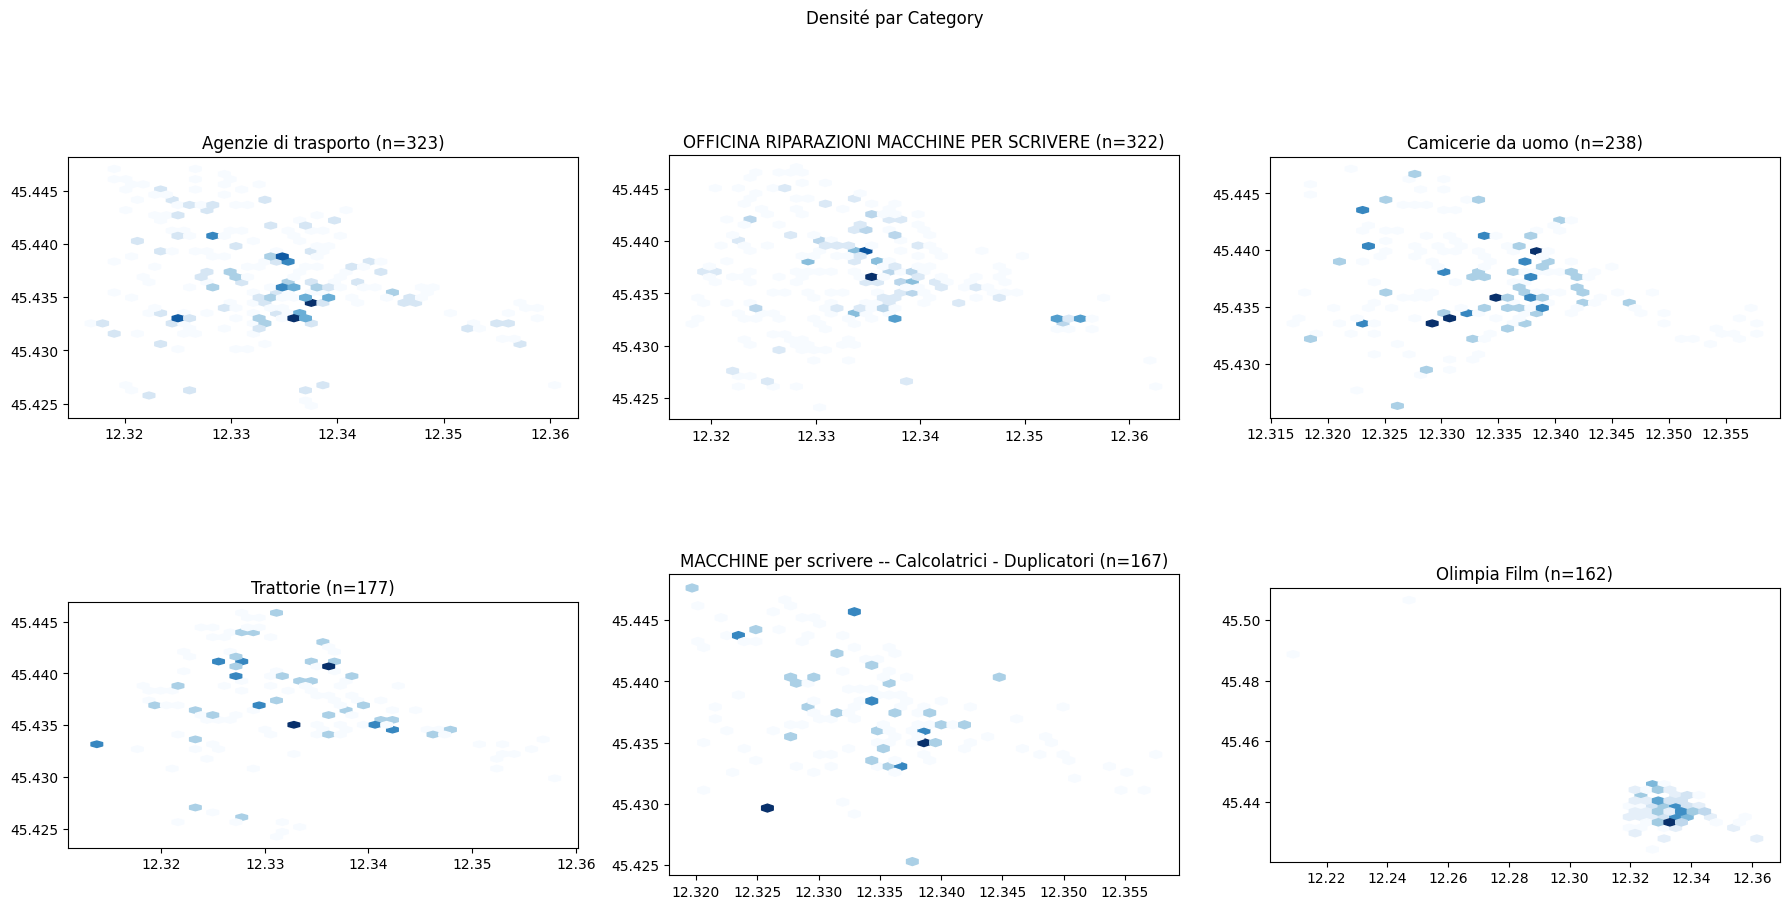

Saved: heatmap_by_category_inside_venice_20260824_161514.png


In [26]:
# raw Category coverage, before cleaning -- not the final view

if "Category" not in geo.columns:
    print("No 'Category' column in geo -- skipping.")
else:
    print(f"\n{'='*60}\nCategory\n{'='*60}")

    has_cat = geo["Category"].notna()
    print(f"Rows with a Category value: {has_cat.sum()} / {len(geo)} ({100*has_cat.sum()/len(geo):.1f}%)")

    print(f"\nTop 20 'Category' values:")
    print(geo["Category"].value_counts().head(20))

    top_categories = geo["Category"].value_counts().head(TOP_N_CATEGORIES).index.tolist()
    print(f"\nTop categories plotted for Category:", top_categories)

    n_cols = 3
    n_rows = -(-len(top_categories) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, cat in zip(axes, top_categories):
        sub = geo[geo["Category"] == cat]
        hb = ax.hexbin(
            sub["matched_lon"], sub["matched_lat"],
            gridsize=GRIDSIZE_CATEGORY, cmap="Blues", mincnt=1
        )
        ax.set_title(f"{cat} (n={len(sub)})")
        ax.set_aspect("equal")

    for ax in axes[len(top_categories):]:
        ax.axis("off")

    plt.suptitle("Densité par Category")
    plt.tight_layout()
    out_name = "heatmap_by_category_inside_venice.png"
    plt.savefig(out_name, dpi=200)
    plt.show()

    with open(out_name, "rb") as f:
        upload_to_stats(out_name, f.read(), "image/png", subfolder="category_clustering")

In [27]:
# coverage for Category/Role/Profession, individually and combined

print("=== CATEGORY COVERAGE — INSIDE VENICE ===\n")

combined_cat = geo
total_cat    = len(combined_cat)

has_role_c = combined_cat["Role"].notna()       if "Role"       in combined_cat.columns else pd.Series(False, index=combined_cat.index)
has_prof_c = combined_cat["Profession"].notna() if "Profession" in combined_cat.columns else pd.Series(False, index=combined_cat.index)
has_cat_c  = combined_cat["Category"].notna()   if "Category"   in combined_cat.columns else pd.Series(False, index=combined_cat.index)

print(f"Total inside-Venice rows: {total_cat}\n")
print(f"{'FIELD':<25} {'ROWS':>8} {'% OF TOTAL':>12}")
print("-" * 47)
print(f"{'Has Category':<25} {has_cat_c.sum():>8} {100*has_cat_c.sum()/total_cat:>11.1f}%")
print(f"{'Has Role':<25} {has_role_c.sum():>8} {100*has_role_c.sum()/total_cat:>11.1f}%")
print(f"{'Has Profession':<25} {has_prof_c.sum():>8} {100*has_prof_c.sum()/total_cat:>11.1f}%")

any_field  = has_cat_c | has_role_c | has_prof_c
none_field = ~any_field
print("-" * 47)
print(f"{'Any of the three':<25} {any_field.sum():>8} {100*any_field.sum()/total_cat:>11.1f}%")
print(f"{'None of the three':<25} {none_field.sum():>8} {100*none_field.sum()/total_cat:>11.1f}%")

# which combinations of the three fields co-occur
combo = pd.Series(
    list(zip(has_cat_c, has_role_c, has_prof_c)), index=combined_cat.index
).value_counts()

_labels = {
    (True, False, False):  "Category only",
    (False, True, False):  "Role only",
    (False, False, True):  "Profession only",
    (True, True, False):   "Category + Role",
    (True, False, True):   "Category + Profession",
    (False, True, True):   "Role + Profession",
    (True, True, True):    "All three",
    (False, False, False): "None",
}
print(f"\n{'Category / Role / Profession present':<40} {'ROWS':>8} {'% OF TOTAL':>12}")
print("-" * 62)
for key, label in _labels.items():
    n = int(combo.get(key, 0))
    print(f"{label:<40} {n:>8} {100*n/total_cat:>11.1f}%")

print("\n=== DONE ===")

=== CATEGORY COVERAGE — INSIDE VENICE ===

Total inside-Venice rows: 16469

FIELD                         ROWS   % OF TOTAL
-----------------------------------------------
Has Category                 12505        75.9%
Has Role                      2065        12.5%
Has Profession                6013        36.5%
-----------------------------------------------
Any of the three             15689        95.3%
None of the three              780         4.7%

Category / Role / Profession present         ROWS   % OF TOTAL
--------------------------------------------------------------
Category only                                9200        55.9%
Role only                                     339         2.1%
Profession only                              1395         8.5%
Category + Role                               137         0.8%
Category + Profession                        3029        18.4%
Role + Profession                            1450         8.8%
All three                          

In [28]:
# are Category and Profession the same signal, or different populations?
print("=== CATEGORY vs PROFESSION — CONTENT COMPARISON ===\n")

has_cat_b  = geo["Category"].notna()   if "Category"   in geo.columns else pd.Series(False, index=geo.index)
has_prof_b = geo["Profession"].notna() if "Profession" in geo.columns else pd.Series(False, index=geo.index)

both_mask = has_cat_b & has_prof_b
n_both    = int(both_mask.sum())
print(f"Rows with BOTH Category and Profession non-null: {n_both} "
      f"({100*n_both/len(geo):.1f}% of {len(geo)} inside-Venice rows)")

if n_both == 0:
    print("\nNo overlap -- Category and Profession are populated by mutually "
          "exclusive extraction paths, not two labels for the same rows.")
else:
    both_df = geo.loc[both_mask, ["Category", "Profession"]].copy()
    both_df["identical"] = (
        both_df["Category"].str.strip().str.lower()
        == both_df["Profession"].str.strip().str.lower()
    )
    both_df["similarity"] = both_df.apply(
        lambda r: fuzz.token_sort_ratio(str(r["Category"]).lower(), str(r["Profession"]).lower()),
        axis=1,
    )
    n_identical = int(both_df["identical"].sum())
    n_high_sim  = int((both_df["similarity"] >= 85).sum())
    print(f"  Identical text (case-insensitive): {n_identical} ({100*n_identical/n_both:.1f}% of overlap rows)")
    print(f"  Similarity >= 85 (rapidfuzz token_sort_ratio), not identical: "
          f"{n_high_sim - n_identical} ({100*(n_high_sim-n_identical)/n_both:.1f}% of overlap rows)")
    print(f"  Mean similarity across overlap rows: {both_df['similarity'].mean():.1f}")
    print("\n  Sample of overlap rows (Category, Profession, similarity):")
    print(both_df.sort_values("similarity").head(10).to_string(index=False))

# --- vocabulary comparison, independent of row overlap ---
cat_vals  = set(geo.loc[has_cat_b,  "Category"].str.strip().str.lower().unique())
prof_vals = set(geo.loc[has_prof_b, "Profession"].str.strip().str.lower().unique())

print(f"\nDistinct Category values   : {len(cat_vals)}")
print(f"Distinct Profession values : {len(prof_vals)}")
print(f"Exact-text overlap between the two vocabularies: {len(cat_vals & prof_vals)} value(s)")
if cat_vals & prof_vals:
    print("  Shared values:", sorted(cat_vals & prof_vals)[:20])

# --- side-by-side top values ---
print("\nTop 15 Category values:")
print(geo.loc[has_cat_b, "Category"].value_counts().head(15).to_string())
print("\nTop 15 Profession values:")
print(geo.loc[has_prof_b, "Profession"].value_counts().head(15).to_string())


=== CATEGORY vs PROFESSION — CONTENT COMPARISON ===

Rows with BOTH Category and Profession non-null: 3168 (19.2% of 16469 inside-Venice rows)
  Identical text (case-insensitive): 1 (0.0% of overlap rows)
  Similarity >= 85 (rapidfuzz token_sort_ratio), not identical: 36 (1.1% of overlap rows)
  Mean similarity across overlap rows: 29.9

  Sample of overlap rows (Category, Profession, similarity):
             Category       Profession  identical  similarity
           farmacista                O      False         0.0
              o'clock             S.A.      False         0.0
      nettezza urbana                O      False         0.0
           macelleria                O      False         0.0
           macelleria                O      False         0.0
lavanderia e stireria                O      False         0.0
                sarta                O      False         0.0
                   S.  Pietto in Volta      False         0.0
   alimentari (dett.)                O   

In [29]:
# shared embedding client/helper, used by every embedding cell below

api_file = Path(OPENAI_KEY_FILE)
with open(api_file, "r") as f:
    cont = f.readlines()
params = dict(v.strip().split("=", 1) for v in cont if "=" in v)
OPENAI_API_KEY = params["api_key"]

client = OpenAI(api_key=OPENAI_API_KEY, timeout=30.0, max_retries=0)

EMBEDDING_MODEL = "text-embedding-3-small"
BATCH_SIZE = 50
MAX_RETRIES = 5

def embed_batch_with_retry(batch, max_retries=MAX_RETRIES):
    for attempt in range(max_retries):
        try:
            resp = client.embeddings.create(model=EMBEDDING_MODEL, input=batch)
            return [e.embedding for e in resp.data]
        except APIConnectionError as e:
            wait = 2 ** attempt
            print(f"    Connection error (attempt {attempt+1}/{max_retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"Failed after {max_retries} retries.")


# 2. Profession

In [30]:
# pre-clustering patch: remove OCR garbage + unresolved acronyms from Profession before embedding
# unresolved acronyms, not OCR garbage -- dropped for now
UNRESOLVED_ACRONYMS = {
    "aderenti all\u2019 « A.P.P.I.A. » di Milano",
    "C.A.I.M.",
    "S.E.V",
}

# OCR garbage: punctuation/dashes, single chars, known placeholders
OCR_GARBAGE_PATTERN = re.compile(r"^[\W_]+$|^.$")  # matches dashes and single chars
KNOWN_PLACEHOLDER_TOKENS = {"ditto", "fom", "ras", '4130"', "8. a. r. Ir.", "Cone."}

def _is_ocr_garbage(value):
    if pd.isna(value):
        return False
    v = str(value).strip()
    if v in KNOWN_PLACEHOLDER_TOKENS:
        return True
    if len(v) <= 1:  # single character like "O"
        return True
    if OCR_GARBAGE_PATTERN.match(v):  # pure punctuation/dashes
        return True
    return False

mask_acronyms = geo["Profession"].isin(UNRESOLVED_ACRONYMS)
mask_garbage = geo["Profession"].apply(_is_ocr_garbage)
mask_total = mask_acronyms | mask_garbage

print(f"{mask_acronyms.sum()} rows matched unresolved acronyms: "
      f"{sorted(geo.loc[mask_acronyms, 'Profession'].dropna().unique())}")
print(f"{mask_garbage.sum()} rows matched OCR-garbage pattern: "
      f"{sorted(geo.loc[mask_garbage, 'Profession'].dropna().unique())[:20]}"
      f"{' ...' if mask_garbage.sum() > 20 else ''}")

geo.loc[mask_total, "Profession"] = pd.NA
print(f"\nTotal blanked: {mask_total.sum()} rows.")

156 rows matched unresolved acronyms: ['C.A.I.M.', 'S.E.V', 'aderenti all’ « A.P.P.I.A. » di Milano']
123 rows matched OCR-garbage pattern: [' 4130"', ' ras', '-', '8. a. r. Ir.', 'Cone.', 'O', 'ditto', 'fom'] ...

Total blanked: 279 rows.


In [31]:
# profession embedding -- reuses client/embed_batch_with_retry/BATCH_SIZE from the shared setup cell

value_counts = geo["Profession"].value_counts()
unique_values = value_counts.index.tolist()
print(f"{len(unique_values)} unique Profession values to embed "
      f"(covering {value_counts.sum()} total rows).")

_prof_emb_cache = STATS_LOCAL_DIR / "reference" / "profession" / "profession_embeddings_cache.npy"
_prof_emb_values_cache = STATS_LOCAL_DIR / "reference" / "profession" / "profession_embeddings_values.csv"

if _prof_emb_cache.exists() and _prof_emb_values_cache.exists():
    _cached_values = pd.read_csv(_prof_emb_values_cache)["value"].tolist()
    if _cached_values == unique_values:
        embeddings = np.load(_prof_emb_cache)
        print(f"Loaded cached embeddings -> {embeddings.shape}, no API calls made.")
    else:
        print("Cached values don't match current unique_values (Profession changed since caching) -- recomputing.")
        embeddings = None
else:
    embeddings = None

if embeddings is None:
    embeddings = []
    for i in range(0, len(unique_values), BATCH_SIZE):
        batch = unique_values[i:i + BATCH_SIZE]
        batch_embeddings = embed_batch_with_retry(batch)
        embeddings.extend(batch_embeddings)
        print(f"  Embedded {min(i + BATCH_SIZE, len(unique_values))}/{len(unique_values)}")
    embeddings = np.array(embeddings)
    np.save(_prof_emb_cache, embeddings)
    pd.DataFrame({"value": unique_values}).to_csv(_prof_emb_values_cache, index=False)
    print(f"\nEmbedding matrix shape: {embeddings.shape}")


1090 unique Profession values to embed (covering 5734 total rows).
Loaded cached embeddings -> (1090, 1536), no API calls made.


k=  5  inertia=     752.7  silhouette=0.0232
k= 10  inertia=     721.6  silhouette=0.0251
k= 15  inertia=     697.9  silhouette=0.0291
k= 20  inertia=     679.5  silhouette=0.0344
k= 25  inertia=     663.9  silhouette=0.0354
k= 30  inertia=     649.5  silhouette=0.0398
k= 35  inertia=     640.7  silhouette=0.0411
k= 40  inertia=     629.3  silhouette=0.0450
k= 45  inertia=     622.0  silhouette=0.0448
k= 50  inertia=     613.6  silhouette=0.0476
k= 55  inertia=     604.5  silhouette=0.0452
k= 60  inertia=     598.1  silhouette=0.0473


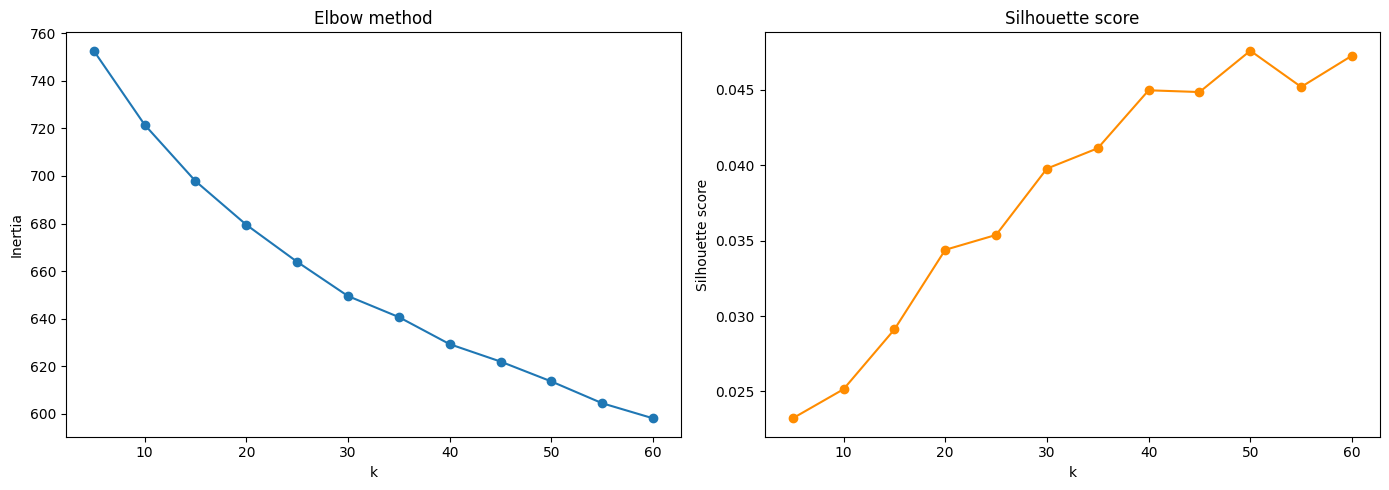

Saved (both) to stats_geo_analysis/20260824_161514/profession_clustering/: k_selection_diagnostics_20260824_161514.csv


In [32]:
# k selection -- elbow method + silhouette score, reuses existing embeddings
K_RANGE = range(5, 61, 5)  # 5, 10, 15, ..., 60

inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    sil = silhouette_score(embeddings, labels)
    silhouettes.append(sil)
    print(f"k={k:>3}  inertia={km.inertia_:>10.1f}  silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_RANGE), inertias, marker="o")
ax1.set_xlabel("k"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow method")

ax2.plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
ax2.set_xlabel("k"); ax2.set_ylabel("Silhouette score"); ax2.set_title("Silhouette score")

plt.tight_layout()
plt.savefig(_v("k_selection_diagnostics.png"), dpi=200)
plt.show()

csv_bytes = pd.DataFrame({"k": list(K_RANGE), "inertia": inertias, "silhouette": silhouettes}).to_csv(index=False).encode("utf-8")
upload_to_stats("k_selection_diagnostics.csv", csv_bytes, "text/csv", subfolder="profession_clustering")

In [33]:
# clustering + pin -- profession k=30, reference: profession_clusters_20260728_122005.csv (hand-verified)
# skips KMeans and loads the reference directly if the value set is unchanged

REFERENCE_CLUSTER_FILE = STATS_LOCAL_DIR / "reference" / "profession" / "profession_clusters_20260728_122005.csv"

if not REFERENCE_CLUSTER_FILE.exists():
    raise RuntimeError(
        f"Reference clustering file not found locally: {REFERENCE_CLUSTER_FILE}. "
        f"CLUSTER_DEFAULT_NAMES in the next cell cannot be applied without it."
    )

reference_df = pd.read_csv(REFERENCE_CLUSTER_FILE)

if set(reference_df["profession"]) == set(unique_values):
    print(f"Value set unchanged ({len(unique_values)} values match the reference exactly) "
          f"-- skipping KMeans, loading the pinned reference directly.")
    cluster_df = reference_df.copy()
else:
    N_CLUSTERS = 30
    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    cluster_df = pd.DataFrame({
        "profession": unique_values,
        "frequency": value_counts.values,
        "cluster_id": cluster_labels,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    reference_map = dict(zip(reference_df["profession"], reference_df["cluster_id"]))
    current_map = dict(zip(cluster_df["profession"], cluster_df["cluster_id"]))
    mismatches = {
        p: (reference_map.get(p), current_map.get(p))
        for p in set(reference_map) | set(current_map)
        if reference_map.get(p) != current_map.get(p)
    }
    print(f"{'='*70}")
    print(f"MISMATCH -- value set differs from the reference run: "
          f"{len(mismatches)} of {len(set(reference_map) | set(current_map))} profession value(s) differ.")
    print("cluster_df is being reset to the pinned reference regardless, so category names still apply correctly.")
    print(f"{'='*70}\n")
    cluster_df = reference_df.copy()

print(f"{'='*70}")
print("CLUSTERING IN USE FOR CATEGORY NAMES (k=30, run 20260728_122005)")
print(f"{'='*70}")
for cid in sorted(cluster_df["cluster_id"].unique()):
    sub = cluster_df[cluster_df["cluster_id"] == cid]
    total_rows = sub["frequency"].sum()
    print(f"\n--- Cluster {cid}  (total rows: {total_rows}, unique values: {len(sub)}) ---")
    print(sub.sort_values("frequency", ascending=False)
          .head(15)[["profession", "frequency"]]
          .to_string(index=False))


Value set unchanged (1090 values match the reference exactly) -- skipping KMeans, loading the pinned reference directly.
CLUSTERING IN USE FOR CATEGORY NAMES (k=30, run 20260728_122005)

--- Cluster 0  (total rows: 338, unique values: 55) ---
                                                             profession  frequency
                               parroco S. Maria del Rosario (Gesuitati)        167
                                              Commissariato di S. Elena         52
                                                       Giovanni e Paolo         37
BASILICA PATRIARCALE PRIMARIZIALE METROPOLITANA DI S. MARCO EVANGELISTA         24
                                                               Torcello          7
                                               S. Giovanni Laterano, ,           2
                                                               S. Marco          1
                                                             Rialto 198          1
          

In [34]:
# apply category names + corrections (k=30, run 20260728_122005)
# names verified value-by-value against this run's actual cluster contents -- cluster_ids aren't stable across reruns

CLUSTER_DEFAULT_NAMES = {
    0:  "Religious & civic institutions",
    1:  "'Capo' titles (mixed domains)",
    2:  "Administration & directorship",
    3:  "Economic administration (academic)",
    4:  "Visual and decorative arts",
    5:  "Technical/engineering professions",
    6:  "Government offices / State administration",
    7:  "Medical professions",
    8:  "Religious & civic institutions",
    9:  "Education",
    10: "Office & mechanical equipment (ad-dominated)",
    11: "Technical/engineering professions",
    12: "Provincial and state institutions",
    13: "Education",
    14: "Government offices / State administration",
    15: "General retail shops",
    16: "Industry and construction",
    17: "Language education",
    18: "Language education",
    19: "Sales representatives / Commercial agents",
    20: "Governance and leadership titles",
    21: "Sports organizations",
    22: "General goods trade",
    23: "Trade guild categories",
    24: "General goods trade (ad-dominated)",
    25: "Law and judiciary (academic)",
    26: "Address fragments / non-profession",
    27: "Food & hospitality",
    28: "Governance and leadership titles",
    29: "Transport and maritime",
}

VALUE_OVERRIDES = {
    # same overrides as before -- APPIA/CAIM/SEV were never mapped here anyway

    "ARTI GRAFICHE ESPERIA": "Visual and decorative arts",
    "pittrice": "Visual and decorative arts",
    "Pittrice": "Visual and decorative arts",
    "malattie polmonari": "Medical professions",
    "PARROCCHIE E SUCCURSALI": "Religious & civic institutions",
    "sarto da uomo": "Textile and tailoring",
    "sarta da uomo": "Textile and tailoring",
    "falegname": "Industry and construction",
    "trattoria": "Food & hospitality",
    "osteria": "Food & hospitality",
    "Linee esercite": "Transport and maritime",
    "IL MATTINO DEL POPOLO": "Institutions, press and political parties",
    "Character: A il Vostro giornale": "Institutions, press and political parties",
    "ostetrica": "Medical professions",
    "sarta": "Textile and tailoring",
    "oriferia": "General retail shops",
    "tratorria": "Food & hospitality",
    "Ponte Canonica Pl. Maria": "Address fragments / non-profession",
    "Calle della Mandola": "Address fragments / non-profession",
    "anche per Giudecca, , ": "Address fragments / non-profession",
    "anche per S. Polo, , ": "Address fragments / non-profession",
    "Direzione S. Lucia": "Administration & directorship",
    "illuminazione pubblica": "Government offices / State administration",
    "GABINETTI DENTISTICI": "Medical professions",
    "Sezione Seconda Promiscu": "Law and judiciary (academic)",
    "Squadra Mobile": "Government offices / State administration",
    "Rio Nuovo 3498-A": "Address fragments / non-profession",
    "numero. 920": "Address fragments / non-profession",
    "FERROVIE DELLO STATO": "Transport and maritime",
    "autotrasporti": "Transport and maritime",
    "Vanoni Ezio": "Address fragments / non-profession",
    "Servizi Filoviari": "Transport and maritime",
    "latteria": "Food & grocery retail",
    "lavanderia e stireria": "Personal care",

    "AFFITTAVOLI": "Real estate & rentals",
    "Ragioniere": "Legal & accounting",
    "I. Ragioniere": "Legal & accounting",
    "Consolati": "Government offices / State administration",
    "Torcello": "Address fragments / non-profession",
    "da A. Joggna": "Address fragments / non-profession",
    "Supplente": "Education",
    "arciprete": "Religious & civic institutions",
    "Rio del Pontelungo": "Address fragments / non-profession",
    "Riva del Carbon": "Address fragments / non-profession",
    "Silvestro": "Address fragments / non-profession",
    "Alberoni": "Address fragments / non-profession",

    "MEDICI DELLA PROVINCIA": "Medical professions",
    "Forniture compiete MOBILI e ACCESSORI per UFFICIO": "Office & mechanical equipment (ad-dominated)",
    "Ospedale Civile": "Medical professions",
    "Osp. Civile": "Medical professions",
    "OPERA NAZIONALE PER LA PROTEZIONE E ASSISTENZA DEGLI INVALIDI DI GUERRA": "Provincial and state institutions",

    "SPORT OLIMPICI": "Sports organizations",
    "Category: Attività Marittime ed Aeree": "Transport and maritime",
    "Stabilimento I. N. A.": "Provincial and state institutions",
    "presso Adriatica di Navigazione": "Transport and maritime",
    "P.le Stazione": "Address fragments / non-profession",
    "Direzione Marittima e Gabinetto": "Transport and maritime",

    "parrucchiere per signora": "Personal care",

    "CIMITERI COMUNALI": "Government offices / State administration",
    "dettaglio": "General retail shops",
    "avv.": "Legal & accounting",
    "Comm. Agg.": "Governance and leadership titles",
    "CASINO DI COMMERCIO": "Civic associations & clubs",
    "V. Comm.": "Governance and leadership titles",
    "rivendita": "General retail shops",
    "noleggio riparazioni)": "Industry and construction",
    ", MACELLO COMUNALE": "Government offices / State administration",
    "Applicato, ": "Administration & directorship",
    "V. Comm. Agg.": "Governance and leadership titles",

    "SCUOLA GRANDE DI SAN ROCCO": "Religious & civic institutions",

    "Geometra principale del": "Technical/engineering professions",
    "Geometra principale del Genio Civile": "Technical/engineering professions",

    "Agenzia Nazionale Stampa Associata": "Institutions, press and political parties",
    "Fid. Prov.": "Governance and leadership titles",
    "Ispettore Onorario, prof. Amedeo Gottardi": "Governance and leadership titles",
    "IspetL Sanità": "Government offices / State administration",
    "Via XXII, marzo": "Address fragments / non-profession",

    "PROFESSIONISTI E ARTISTI": "Visual and decorative arts",
    "Giornalista professionista": "Institutions, press and political parties",
    "commercialista": "Legal & accounting",
    "SCIENTIFICA E MAGISTRALE,": "Education",
    "UFFICIO TECNICO ERARIALE,": "Government offices / State administration",
    "UFFICIO TECNICO IMPOSTE DI FABBRICAZIONE,": "Government offices / State administration",

    "Personale degli Uffici - Segreteria della Sezione di Economia e Commercio": "Economic administration (academic)",

    "Biblioteca": "Provincial and state institutions",
    "dett.": "General retail shops",
    "teatro": "Visual and decorative arts",
    "corredi": "Textile and tailoring",
    "bar": "Food & hospitality",
    "uova": "Food & grocery retail",
    "polleria": "Food & grocery retail",

    "panificio. SS.": "Food & grocery retail",
    "panificio": "Food & grocery retail",
    "BICROMIE TRICROMIE FOTOLITO": "Visual and decorative arts",
    "cartoleria": "General retail shops",
    "giornali": "Institutions, press and political parties",
    "confezioni": "Textile and tailoring",
    "QUERINI STAMPALIA": "Civic associations & clubs",
    "pelletterie": "General retail shops",
    "calzature": "General retail shops",
    "articoli da viaggio": "General retail shops",

    "Commissariato di S. Elena": "Government offices / State administration",
    "Biblioteca Marciana": "Civic associations & clubs",
    "Santa Croce (IV)": "Address fragments / non-profession",
    "Via Torre Belfredo": "Address fragments / non-profession",
    "Asilo e Morioni n. S. Francesco della Vigna, numero 2951": "Address fragments / non-profession",
    "presso ditta 'Jessurum'": "Textile and tailoring",
    "Osp. Marino": "Medical professions",
    "Carpenedo, Mestre": "Address fragments / non-profession",

    "DELLA CA’ PESARO": "Civic associations & clubs",
    "presso Italian": "Address fragments / non-profession",
    "località Dese": "Address fragments / non-profession",
    "stireria": "Personal care",
    "Stabilimento : Casa di Pena": "Government offices / State administration",
    "Premiate Cantine": "Food & grocery retail",

    "presso Camera del Lavoro": "Provincial and state institutions",
    "Commissione del Listino": "Economic administration (academic)",
    "Category: Provvianza e Credito": "Economic administration (academic)",
    "Tesoriere": "Administration & directorship",
    "Ragionieri capi sezione": "Legal & accounting",
    "ISPETTORATO COMPARTIMENTALE DELLE IMPOSTE DIRETTE,": "Government offices / State administration",
    "ISPETTORATO COMPARTIMENTALE DELLE TASSE E DELLE IMPOSTE INDIRETTE SUGLI AFFARI,": "Government offices / State administration",
    "Caccia e Pesca": "Sports organizations",
    "Sezione Autonoma di Credito per le Piccole Industrie e l’Artigianato": "Economic administration (academic)",
    "presso Lega Reg.": "Civic associations & clubs",
    "Commissariato": "Government offices / State administration",
    "Uff. Supelivo - Addetto, Legione Ferr. della Guardia di Finanza": "Government offices / State administration",
    "Ispettore Istituto Aut. per le case popolari": "Provincial and state institutions",

    "ASSOCIAZIONE FRA PROPRIETARI DI FABBRICATI DELLA PROVINCIA DI VENEZIA": "Civic associations & clubs",
    "Comitato di Venezia": "Civic associations & clubs",
    "CIRCOLO ARTISTICO DI VENEZIA": "Civic associations & clubs",
    "SEZIONE FILATELICA VENEZIANA DEL CIRCOLO ARTISTICO": "Civic associations & clubs",
    "GUÏDA COMMERCIALE DI VENEZIA E PROVINCIA": "Institutions, press and political parties",
    "Venezia": "Address fragments / non-profession",
    "Altri Consolati aventi giurisdizione sulla Regione Veneta": "Government offices / State administration",
    "Mazzorbo di Burano": "Address fragments / non-profession",
    "Corsi vari di istruzione professionale per artigiani e operai in tutto il Veneto": "Education",
    "Ufficio Commissionario Industrie e Artigiane con Mostre campionarie permanenti di prodotti tipici dell’artigianato e delle piccole industrie venete": "Provincial and state institutions",
    "Agente principale della Società Autori ed Editori della Agenzia di Venezia": "Institutions, press and political parties",
    "Murano, Venezia": "Address fragments / non-profession",

    "CAMERA DI COMMERCIO,  INDUSTRIA ED AGRICOLTURA": "Provincial and state institutions",
    "importazioni ed esportazioni varie": "General goods trade",
    "Economo": "Administration & directorship",
    "economo": "Administration & directorship",
    "Economo Provinciale": "Administration & directorship",
    "fabbricati e aziende agricole": "Industry and construction",

    "Rappresentante di case produttrici di medicinali": "Sales representatives / Commercial agents",

    "vicario": "Religious & civic institutions",
    "prof.": "Education",
    "Commissario": "Government offices / State administration",
    "Parroco": "Religious & civic institutions",
    "Mediatore": "General goods trade",
    "perito": "Technical/engineering professions",
    "Condirettore": "Administration & directorship",

    "cicli e accessori": "General retail shops",

    "liquori": "Food & grocery retail",
    "liquori (fabbrica e deposito)": "Food & grocery retail",
    "carbone e legna (dettaglio)": "General retail shops",
    "carbone e legna": "General retail shops",
    "fluviali e terrestri": "Transport and maritime",

    "grossista": "General goods trade",
    "(grossista)": "General goods trade",
    "ingrosso": "General goods trade",
    "(commercio)": "General goods trade",
    "commercio": "General goods trade",
    "pasticceria": "Food & grocery retail",
    "bottiglieria. (esercizi)": "Food & grocery retail",
    "caffè (esercizi)": "Food & hospitality",
    "salumi (negozio)": "Food & grocery retail",
    "mercerie": "Textile and tailoring",

    "Geometra": "Technical/engineering professions",
    "Geom.": "Technical/engineering professions",
    "S.A.": "Companies/business entities",
    "Attuari": "Economic administration (academic)",
    "Municipio": "Government offices / State administration",
    "Mensile": "Institutions, press and political parties",
    "(abbigra)": "Textile and tailoring",
    "Enego": "Address fragments / non-profession",
    "Solesin,": "Address fragments / non-profession",

    "SOCIETA' CANOTTIERI BUCIUNTORO": "Sports organizations",
    "CONSORZIO DI BONIFICA DESE SUPERIORE": "Provincial and state institutions",
    "Società Cooperativa Lavori e Recuperi Marittimi e Fluviali A. r. l.": "Transport and maritime",
    "SOCIETA ITALIANA DEGLI AUTORI ED EDITORI": "Institutions, press and political parties",

    # cluster 6 residual -- doesn't fit the default category:
    "Concessionario esclusivo: Rag. Cleto Rossini": "Sales representatives / Commercial agents",
    "Agenzia P. Bortoluzzi": "Sales representatives / Commercial agents",

    # cluster 12 residual -- splits from the default:
    "Lavorazione artistica mosaici in smalto di vetro Veneziano": "Visual and decorative arts",
    "al Porto di Venezia": "Transport and maritime",

    # cluster 19 residual -- painters pulled out:
    "pittore": "Visual and decorative arts",
    "Pittore": "Visual and decorative arts",
    "Pittura": "Visual and decorative arts",
    "pittore decoratore": "Visual and decorative arts",

    # cluster 24 residual -- food/grocery content pulled out from under the ZAMPIRONI ad:
    "Alimentari (Dett.)": "Food & grocery retail",
    "alimentari (dett.)": "Food & grocery retail",
    "alimentari, (dett.)": "Food & grocery retail",
    "alimentari": "Food & grocery retail",
    " alimentari": "Food & grocery retail",
    "piante e sementi": "Food & grocery retail",
    " piante e sementi": "Food & grocery retail",
    "frutta e verdura": "Food & grocery retail",
    " frutta e verdura": "Food & grocery retail",
    "legumi": "Food & grocery retail",
    " Agrumi": "Food & grocery retail",

    # cluster 29 residual -- biggest value here is a sales business, not governance:
    "Vendita e Mobilizzi": "General goods trade",
}

NON_PLOTTED_CATEGORIES = {"Address fragments / non-profession"}

# --- Apply ---
cluster_df["category_name"] = cluster_df.apply(
    lambda row: VALUE_OVERRIDES.get(row["profession"], CLUSTER_DEFAULT_NAMES[row["cluster_id"]]),
    axis=1
)

n_overridden = sum(1 for p in cluster_df["profession"] if p in VALUE_OVERRIDES)
print(f"{n_overridden} of {len(VALUE_OVERRIDES)} defined overrides matched an actual unique value.")

# ad-propagation flagging
MIN_ROWS = 5
MIN_UNIQUE_RATIO = 0.8

sub = geo[(geo["section"] == "indice_generale") & (geo["Profession"].notna())]
page_prof = sub.groupby(["page_num", "Profession"]).agg(
    n_rows=("Name", "size"),
    n_unique_names=("Name", "nunique"),
).reset_index()

flagged_ad_pattern = page_prof[
    (page_prof["n_rows"] >= MIN_ROWS) &
    (page_prof["n_unique_names"] / page_prof["n_rows"] > MIN_UNIQUE_RATIO)
]

likely_ad_values = set(flagged_ad_pattern["Profession"].unique())
cluster_df["likely_ad_propagation"] = cluster_df["profession"].isin(likely_ad_values)

n_flagged_values = cluster_df["likely_ad_propagation"].sum()
n_flagged_rows = cluster_df.loc[cluster_df["likely_ad_propagation"], "frequency"].sum()

print(f"\n{'='*65}")
print("LIKELY AD-PROPAGATION VALUES (auto-flagged)")
print(f"{'='*65}")
print(f"{n_flagged_values} unique values flagged, covering {n_flagged_rows} rows.\n")
flagged_detail = cluster_df[cluster_df["likely_ad_propagation"]].sort_values("frequency", ascending=False)
print(flagged_detail[["profession", "frequency", "cluster_id", "category_name"]].to_string(index=False))

# --- Save corrected lookup table ---
csv_bytes = cluster_df.to_csv(index=False).encode("utf-8")
upload_to_stats("profession_clusters_k30_corrected.csv", csv_bytes, "text/csv", subfolder="profession_clustering")

# --- Join category_name onto the full inside-Venice dataset ---
category_lookup = dict(zip(cluster_df["profession"], cluster_df["category_name"]))
geo["profession_category"] = geo["Profession"].map(category_lookup)

ad_flag_lookup = dict(zip(cluster_df["profession"], cluster_df["likely_ad_propagation"]))
geo["profession_likely_ad"] = geo["Profession"].map(ad_flag_lookup).fillna(False)

# --- Stats ---
print(f"\n{'='*65}")
print("PROFESSION CATEGORY STATS (k=30, corrected)")
print(f"{'='*65}")

total_rows = len(geo)
has_category = geo["profession_category"].notna().sum()
print(f"Total inside-Venice rows       : {total_rows}")
print(f"Rows with a Profession category: {has_category} ({100*has_category/total_rows:.1f}%)")
print(f"Rows flagged as likely ad-propagation: {geo['profession_likely_ad'].sum()} "
      f"({100*geo['profession_likely_ad'].sum()/has_category:.1f}% of categorized rows)")

cat_counts = geo["profession_category"].value_counts()
print(f"\n{'CATEGORY':<50} {'ROWS':>8} {'% OF CATEGORIZED':>10} {'PLOTTED?':>10}")
print("-" * 88)
for cat, count in cat_counts.items():
    plotted = "No" if cat in NON_PLOTTED_CATEGORIES else "Yes"
    print(f"{cat:<50} {count:>8} {100*count/has_category:>9.1f}% {plotted:>10}")

# names columns directly -- avoids relying on reset_index()'s default index name
stats_bytes = cat_counts.rename_axis("category").reset_index(name="n_rows").to_csv(index=False).encode("utf-8")
upload_to_stats("profession_category_stats_k30.csv", stats_bytes, "text/csv", subfolder="profession_clustering")

print(f"\nSaved: stats_geo_analysis/{_v('profession_clusters_k30_corrected.csv')}")
print(f"Saved: stats_geo_analysis/{_v('profession_category_stats_k30.csv')}")


166 of 203 defined overrides matched an actual unique value.

LIKELY AD-PROPAGATION VALUES (auto-flagged)
25 unique values flagged, covering 2664 rows.

                                                profession  frequency  cluster_id                                category_name
                                       Vendita e Mobilizzi        544          29                          General goods trade
        Macchine per scrivere - Calcolatrici - Duplicatori        360          10 Office & mechanical equipment (ad-dominated)
           MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI        359          10 Office & mechanical equipment (ad-dominated)
Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia        194          24           General goods trade (ad-dominated)
          Rappresentante di case produttrici di medicinali        186          19    Sales representatives / Commercial agents
                                                 industria        176          16    

In [35]:
# manual category force -- source-verified categories for patched registry rows, run after the cell above

MANUAL_CATEGORY_FORCE = {
    "Cereali e Derivati": "General goods trade",
    "Orto-Floro-Frutticoltura": "Food & grocery retail",
    "Viti-Vinicola-Olearia": "Food & grocery retail",
    "Legno e Ammobiliamento": "Industry and construction",
    "Tessili": "Textile and tailoring",
    "Abbigliamento": "Textile and tailoring",
    "Meccanica": "Technical/engineering professions",
    "Chimica": "Chemicals & utilities",
    "Combustibili e Carburanti": "Chemicals & utilities",
    "Costruzioni edili": "Industry and construction",
    "Acqua - Gas - Elettricità": "Chemicals & utilities",
    "Vetro e Ceramica": "Visual and decorative arts",
    "Comunicazioni interne": "Transport and maritime",
    "Ospitalità": "Food & hospitality",
    "Previdenza e Credito": "Economic administration (academic)",
    "Attività Marittime ed Aeree": "Transport and maritime",
    "Attività varie": "General goods trade",
}

force_mask = geo["Profession"].isin(MANUAL_CATEGORY_FORCE.keys())
n_forced = force_mask.sum()
geo.loc[force_mask, "profession_category"] = geo.loc[force_mask, "Profession"].map(MANUAL_CATEGORY_FORCE)

unresolved_mask = geo["Profession"].astype(str).str.match(r"^Categoria [IVXLC]+$", na=False)
n_excluded_unresolved = unresolved_mask.sum()
geo.loc[unresolved_mask, "profession_category"] = None

n_overridden_cluster = sum(1 for p in cluster_df["profession"] if p in VALUE_OVERRIDES)

print(f"{'='*65}\nCATEGORIZATION AUDIT — for thesis stats\n{'='*65}")
print(f"Cluster-derived reclassifications (VALUE_OVERRIDES matches): {n_overridden_cluster}")
print(f"Source-verified manual patches (registry rows, this cell)  : {n_forced}")
print(f"Unresolved/excluded (Categoria VIII etc.)                  : {n_excluded_unresolved}")

CATEGORIZATION AUDIT — for thesis stats
Cluster-derived reclassifications (VALUE_OVERRIDES matches): 166
Source-verified manual patches (registry rows, this cell)  : 33
Unresolved/excluded (Categoria VIII etc.)                  : 4


In [36]:
# investigates where "Duplicatori" (and similar page-wide contamination) comes from

dup_rows = geo[geo["Profession"] == "Duplicatori"]
print(f"{len(dup_rows)} rows with Profession == 'Duplicatori', "
      f"{dup_rows['Name'].nunique()} distinct names, "
      f"pages: {sorted(dup_rows['page_num'].unique().tolist())}")

page_prof = geo[geo["Profession"].notna()].groupby(["page_num", "Profession"]).agg(
    n_rows=("Name", "size"), n_unique_names=("Name", "nunique"),
).reset_index()

SUSPICIOUS_MIN_ROWS = 10
suspicious = page_prof[
    (page_prof["n_rows"] >= SUSPICIOUS_MIN_ROWS) &
    (page_prof["n_unique_names"] / page_prof["n_rows"] > 0.8)
].sort_values("n_rows", ascending=False)

total_suspicious = suspicious["n_rows"].sum()
print(f"\n{len(suspicious)} (page, Profession) combos look like the same pattern "
      f"({total_suspicious} rows, {100*total_suspicious/geo['Profession'].notna().sum():.1f}% "
      "of all Profession-bearing rows -- most of this is real, common professions, "
      "not contamination, see methodology).")
print(suspicious.head(15).to_string(index=False))

# thesis example table: a few distinct real entries that all got stamped
# with the same ad text
example_cols = [c for c in ("Name", "Address", "page_num", "section", "Profession") if c in dup_rows.columns]
example_table = dup_rows[example_cols].drop_duplicates(subset="Name").head(8)
upload_to_stats("duplicatori_contamination_example.csv",
                 example_table.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="profession_clustering")
print("\nSaved thesis example table -> duplicatori_contamination_example.csv")


51 rows with Profession == 'Duplicatori', 50 distinct names, pages: [383]

105 (page, Profession) combos look like the same pattern (3949 rows, 68.9% of all Profession-bearing rows -- most of this is real, common professions, not contamination, see methodology).
 page_num                                                 Profession  n_rows  n_unique_names
      112                                                    Attuari     100             100
      123               Concessionario esclusivo: Rag. Cleto Rossini      92              92
      113                                                 Farmacista      84              84
      119                                          Medicina generale      83              83
       55                                        al Porto di Venezia      74              72
      118                                          Medicina generale      67              67
      109                                                    pittore      65          

In [37]:
# flagged categories -- print contents for review, uses cluster_df from the k=30 corrected mapping

FLAGGED_CATEGORIES = [
    "'Capo' titles (mixed domains)",              # cluster 1 — lexical, not semantic
    "Office & mechanical equipment (ad-dominated)", # cluster 10 — Duplicatori-dominated
    "General goods trade (ad-dominated)",           # cluster 24 — ZAMPIRONI-dominated
    "Address fragments / non-profession",           # cluster 26 (+ scattered override additions elsewhere) — genuinely mixed noise
    "Trade guild categories",                       # cluster 23 — Categoria/Divisione registry codes; "Divisione I.a/II.a/III.a" (5 rows) aren't covered by CATEGORIA_PATCH's roman-numeral keys, unlike "Categoria N"
]

print("=== FLAGGED CATEGORIES — CONTENTS FOR REVIEW ===\n")

total_flagged_rows = 0

for cat in FLAGGED_CATEGORIES:
    sub = cluster_df[cluster_df["category_name"] == cat]
    if sub.empty:
        print(f"--- {cat}: NOT FOUND in cluster_df ---\n")
        continue

    cluster_ids_involved = sorted(sub["cluster_id"].unique())
    total_rows_in_cat = sub["frequency"].sum()
    total_flagged_rows += total_rows_in_cat

    print(f"{'='*70}")
    print(f"{cat}")
    print(f"(from cluster(s) {cluster_ids_involved} — {total_rows_in_cat} rows, "
          f"{len(sub)} unique values)")
    print(f"{'='*70}")
    print(sub.sort_values("frequency", ascending=False)
          [["profession", "frequency", "cluster_id"]]
          .to_string(index=False))
    print()

print(f"{'='*70}")
print(f"TOTAL rows across all flagged categories: {total_flagged_rows} "
      f"out of {cluster_df['frequency'].sum()} total categorized rows "
      f"({100*total_flagged_rows/cluster_df['frequency'].sum():.1f}%)")
print(f"{'='*70}")


=== FLAGGED CATEGORIES — CONTENTS FOR REVIEW ===

'Capo' titles (mixed domains)
(from cluster(s) [np.int64(1)] — 39 rows, 31 unique values)
                                 profession  frequency  cluster_id
                             Ispettore Capo          5           1
                               Ispett. Capo          3           1
                                 Comm. Capo          2           1
                 Capitano di P.S. in S.P.E.          2           1
                 Capo Uff. Stampa e Propag.          1           1
                               Capo Tecnico          1           1
                                       Cap.          1           1
                              Capo Stazione          1           1
                     S. Capu di Stato Magg.          1           1
                             Capo Divisione          1           1
                                  Cav. Uff.          1           1
Ispet. Capo Amm. Imposte Consumo del Comune          1  

In [38]:
# clustering + pin -- profession k=10, reference: profession_clusters_k10_20260728_183800.csv
# same skip-if-unchanged shortcut as k=30. set REGENERATE_REFERENCE_PROF_K10=True to replace the reference

REGENERATE_REFERENCE_PROF_K10 = False
REFERENCE_CLUSTER_FILE_PROF_K10 = STATS_LOCAL_DIR / "reference" / "profession" / "profession_clusters_k10_20260728_183800.csv"

_need_compute = True
if not REGENERATE_REFERENCE_PROF_K10 and REFERENCE_CLUSTER_FILE_PROF_K10.exists():
    reference_df_prof_k10 = pd.read_csv(REFERENCE_CLUSTER_FILE_PROF_K10)
    if set(reference_df_prof_k10["profession"]) == set(unique_values):
        print(f"Value set unchanged ({len(unique_values)} values match the reference exactly) "
              f"-- skipping KMeans, loading the pinned reference directly.")
        cluster_df_k10 = reference_df_prof_k10.copy()
        _need_compute = False

if _need_compute:
    N_CLUSTERS_K10 = 10
    kmeans_k10 = KMeans(n_clusters=N_CLUSTERS_K10, random_state=42, n_init=10)
    cluster_labels_k10 = kmeans_k10.fit_predict(embeddings)
    cluster_df_k10 = pd.DataFrame({
        "profession": unique_values,
        "frequency": value_counts.values,
        "cluster_id": cluster_labels_k10,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    if REGENERATE_REFERENCE_PROF_K10 or not REFERENCE_CLUSTER_FILE_PROF_K10.exists():
        if REGENERATE_REFERENCE_PROF_K10:
            print("REGENERATE_REFERENCE_PROF_K10=True -- overwriting the pinned reference with this run.")
        else:
            print(f"No reference file found at {REFERENCE_CLUSTER_FILE_PROF_K10.name} -- "
                  f"bootstrapping: this run becomes the permanent reference.")
        reference_df_prof_k10 = cluster_df_k10.copy()
        STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        reference_df_prof_k10.to_csv(REFERENCE_CLUSTER_FILE_PROF_K10, index=False)
        upload_to_stats("profession_clusters_k10_reference.csv",
                         reference_df_prof_k10.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="profession_clustering")
        print(f"Saved reference: {REFERENCE_CLUSTER_FILE_PROF_K10.name} ({len(reference_df_prof_k10)} rows)")
    else:
        reference_map_pk10 = dict(zip(reference_df_prof_k10["profession"], reference_df_prof_k10["cluster_id"]))
        current_map_pk10 = dict(zip(cluster_df_k10["profession"], cluster_df_k10["cluster_id"]))
        mismatches_pk10 = {
            p: (reference_map_pk10.get(p), current_map_pk10.get(p))
            for p in set(reference_map_pk10) | set(current_map_pk10)
            if reference_map_pk10.get(p) != current_map_pk10.get(p)
        }
        print(f"{'='*70}")
        print(f"MISMATCH -- {len(mismatches_pk10)} of "
              f"{len(set(reference_map_pk10) | set(current_map_pk10))} profession value(s) differ from the reference.")
        print("cluster_df_k10 is being reset to the pinned reference. "
              "Set REGENERATE_REFERENCE_PROF_K10=True above if this run should replace it instead.")
        print(f"{'='*70}\n")

    cluster_df_k10 = reference_df_prof_k10.copy()

print(f"cluster_df_k10 is now pinned ({len(cluster_df_k10)} rows, "
      f"{cluster_df_k10['cluster_id'].nunique()} clusters).")


Value set unchanged (1090 values match the reference exactly) -- skipping KMeans, loading the pinned reference directly.
cluster_df_k10 is now pinned (1090 rows, 10 clusters).


In [39]:
# apply category names + corrections (k=10) -- HISCO's 7 major groups + 3 almanac-specific institutional categories

CLUSTER_DEFAULT_NAMES_K10 = {
    0: "General commerce, real estate & advertising",
    1: "Education & academic institutions",
    2: "Retail trade & consumer goods",
    3: "Religious & civic institutions",
    4: "Medical professions",
    5: "Legal, economic & administrative professions",
    6: "Governance & administrative titles",
    7: "Visual, decorative & graphic arts",
    8: "Education & academic institutions",
    9: "Industrial & construction trades",     
}

# Ad-dominated content pulled OUT of cluster 9's default via override
CLUSTER9_AD_VALUES = {
    "MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI": "Advertisement-dominated content",
    "Macchine per scrivere - Calcolatrici - Duplicatori": "Advertisement-dominated content",
    "Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia": "Advertisement-dominated content",
    "Tutti i prodotti ZAMPIRONI sono di massima fiducia": "Advertisement-dominated content",
    "Duplicatori": "Advertisement-dominated content",
    "Forniture compiete MOBILI e ACCESSORI per UFFICIO": "Advertisement-dominated content",
}

VALUE_OVERRIDES_K10 = {
    **CLUSTER9_AD_VALUES,

    # ── CLUSTER 0 ──
    "CIMITERI COMUNALI": "Government, military & public administration",
    "MEDICI DELLA PROVINCIA": "Medical professions",
    "al Porto di Venezia": "Transport, maritime & communications",
    "Commissariato di S. Elena": "Government, military & public administration",
    "FERROVIE DELLO STATO": "Transport, maritime & communications",
    "Ferrovie dello Stato": "Transport, maritime & communications",
    "Ferrovie de lo Stato": "Transport, maritime & communications",
    "Giovanni e Paolo": "Religious & civic institutions",
    "Ufficio postale": "Government, military & public administration",
    "PARROCCHIE E SUCCURSALI": "Religious & civic institutions",
    "Società MARE": "Industrial & construction trades",
    "BASILICA PATRIARCALE PRIMARIZIALE METROPOLITANA DI S. MARCO EVANGELISTA": "Religious & civic institutions",
    "Società in NOME COLLETTIVO": "Industrial & construction trades",
    "Agenzia Nazionale Stampa Associata": "Institutions, press & sport",
    "ASSOCIAZIONE FRA PROPRIETARI DI FABBRICATI DELLA PROVINCIA DI VENEZIA": "Religious & civic institutions",
    "Comitato di Venezia": "Religious & civic institutions",
    "numero. 920": None,
    "OPERA NAZIONALE PER LA PROTEZIONE E ASSISTENZA DEGLI INVALIDI DI GUERRA": "Government, military & public administration",
    "CIRCOLO ARTISTICO DI VENEZIA": "Religious & civic institutions",
    "IL MATTINO DEL POPOLO": "Institutions, press & sport",
    "Vanoni Ezio": None,
    "DIREZIONE SERVIZI DI IGIENE E DI ASSISTENZA PUBBLICA": "Government, military & public administration",
    "SOCIETA' CANOTTIERI BUCIUNTORO": "Institutions, press & sport",
    "Societa Canottieri Bucintoro": "Institutions, press & sport",
    "Vice Pres. Società Canottieri Bucintoro": "Institutions, press & sport",
    "CONSORZIO DI BONIFICA DESE SUPERIORE": "Industrial & construction trades",
    "SEZIONE FILATELICA VENEZIANA DEL CIRCOLO ARTISTICO": "Religious & civic institutions",
    "Azienda Idroelettrica": "Industrial & construction trades",
    "Commissione del Listino": "Legal, economic & administrative professions",
    "DELLA CA’ PESARO": "Religious & civic institutions",
    "DIREZIONE BELLE ARTI DEL COMUNE": "Government, military & public administration",
    "SPORT OLIMPICI": "Institutions, press & sport",
    "Category: Provvianza e Credito": "Legal, economic & administrative professions",
    "GUÏDA COMMERCIALE DI VENEZIA E PROVINCIA": "Institutions, press & sport",
    "Società Cooperativa Lavori e Recuperi Marittimi e Fluviali A. r. l.": "Transport, maritime & communications",
    "Category: Attività Marittime ed Aeree": "Transport, maritime & communications",
    "Venezia": None,
    "CASINO DI COMMERCIO": "Religious & civic institutions",
    "Presidente del Casinò di Commercio": "Religious & civic institutions",
    "Squadra Mobile": "Government, military & public administration",
    "Altri Consolati aventi giurisdizione sulla Regione Veneta": "Government, military & public administration",
    "QUERINI STAMPALIA": "Religious & civic institutions",
    "SOCIETA ITALIANA DEGLI AUTORI ED EDITORI": "Institutions, press & sport",
    "Osp. Civile": "Medical professions",
    "Società di assicurazioni": "Industrial & construction trades",
    "Soc. Industriale es. Marco": "Industrial & construction trades",
    "Soc. Montedison per l'industria chimica": "Industrial & construction trades",
    "Società ITMA": "Industrial & construction trades",
    "S. Giovanni Laterano, ,": "Religious & civic institutions",
    "DIREZIONE LOTTO,": "Government, military & public administration",
    "Direzione Lotto": "Government, military & public administration",
    "Assicurazioni Generali": "Industrial & construction trades",
    "Santa Croce (IV)": None,
    "Mazzorbo di Burano": None,
    "Rio del Pontelungo": None,
    "Stabilimento I. N. A.": "Government, military & public administration",
    "Riva del Carbon": None,
    "presso ditta 'Jessurum'": "Retail trade & consumer goods",
    "presso Italian": None,
    "presso Adriatica di Navigazione": "Transport, maritime & communications",
    "Via Torre Belfredo": None,
    "Uffici Finanziari di Mirano,": "Government, military & public administration",
    "Ufficio Idrografico, ": "Government, military & public administration",
    "Caccia e Pesca": "Institutions, press & sport",
    "Corsi vari di istruzione professionale per artigiani e operai in tutto il Veneto": "Education & academic institutions",
    "Sezione Autonoma di Credito per le Piccole Industrie e l’Artigianato": "Legal, economic & administrative professions",
    "Ufficio Commissionario Industrie e Artigiane con Mostre campionarie permanenti di prodotti tipici dell’artigianato e delle piccole industrie venete": "Legal, economic & administrative professions",
    "Biblioteca di consultazione per artigiani e piccoli industriali (aperto tutti i giorni feriali nelle ore d’Ufficio)": "Education & academic institutions",
    "Asilo e Morioni n. S. Francesco della Vigna, numero 2951": None,
    "anche per Giudecca, ,": None,
    "anche per S. Polo, ,": None,
    "Agente principale della Società Autori ed Editori della Agenzia di Venezia": "Institutions, press & sport",
    "Fed. Ginnastica d'Italia (FGDI)": "Institutions, press & sport",
    "Unione It. Tiro a Segno (UITS)": "Institutions, press & sport",
    "Pres. Reg., Fed. It. Sport Invernali (FISI)": "Institutions, press & sport",
    "Fed. It. Pattinaggio su Ghiaccio": "Institutions, press & sport",
    "Fed. It. Hockey su Ghiaccio": "Institutions, press & sport",
    "Fed. It Gioco Calcio (FIGC)": "Institutions, press & sport",
    "presso Lega Reg.": "Religious & civic institutions",
    "Osp. Marino": "Medical professions",
    "dirett. Cro-nici": None,
    "Murano, Venezia": None,
    "Carpenedo, Mestre": None,
    "Città Giardino": None,
    "Divisione S. Lucia": "Government, military & public administration",
    "loc. Gaggio": None,
    "Riceve dalle ore 15 alle ore 18": None,
    "Via XXII, marzo": None,
    "Ca' Foscari": "Education & academic institutions",
    "Conterie 24": None,
    "Capo Stazione l. A. Agg.": "Government, military & public administration",
    "Capo Stazione": "Government, military & public administration",
    "Azienda": "Industrial & construction trades",
    "spec. Vernizione": None,
    "Alessandro e Auiorio": None,
    "Di vetterti Aumn, Istibuto Prov. degli Esposanti": None,
    "Velluti, Soprarizzo, Broccati, Damascoti Per Ammobramento, Chiese Passamenterie": "Retail trade & consumer goods",
    "Amm. Imposte di Consumo del Comune": "Government, military & public administration",
    "località Dese": None,
    "P.le Stazione": None,
    "Viale Stazione presso Autostimesa Standa": None,
    "Via F.lli Bandierine": None,
    "Strada Nuova": None,
    "Via Galuppi": None,
    "Via Spalti": None,
    "Colonia Alpina S. Marco": "Religious & civic institutions",
    "Telefono 34-285": None,
    "agenzia nolleggio film": "Visual, decorative & graphic arts",
    "Agente per l Venetti E. A. Super Lux 8": None,
    "ved. Bianchi": None,
    "al Pingrosso": None,
    "Ufficio di Venezia": "Government, military & public administration",
    "S. Filippo e Giacomo": "Religious & civic institutions",
    "Mestre, Via Circonvallazione 2.C.": None,
    "Parigi": None,
    "della Prev. Sociale": "Government, military & public administration",
    "specialità veneziane": "Retail trade & consumer goods",
    "specialità Veneziane": "Retail trade & consumer goods",
    "noleggio imbarcazioni": "Transport, maritime & communications",
    "pres Lega R:9": "Religious & civic institutions",
    "Banca Popolare di Novara": "Industrial & construction trades",
    "SS. Pietro e Caterina": "Religious & civic institutions",
    "Rialto 1364": None,
    "Rialto 198": None,
    "Via Velarino": None,
    "agenzia d’affari": "Industrial & construction trades",
    "Stabilimento : Casa di Pena": "Government, military & public administration",
    "Cimiteri Comunali": "Government, military & public administration",
    "Società Anonima": "Industrial & construction trades",
    "Punta Sabbioni": None,
    "piazza 22 Marzo": None,
    "Gazzera Alta 158": None,
    "informazioni comm.": None,
    "Palazzo Surian": None,
    "Cannareguo 1984-85.": None,
    "S. Trovaso. Palazzo Giustiniani": None,
    "agenzia marittima": "Transport, maritime & communications",
    "Dirett. Macello Comunale": "Government, military & public administration",
    "Istituto Nazionale per l'Addestramento Professionale Lavoratori dell'Industria": "Education & academic institutions",
    "Autotrasporti": "Transport, maritime & communications",
    "Ispet. Capo Amm. Imposte Consumo del Comune": "Government, military & public administration",
    "Altri Stazione": None,
    "Lido, Via Malamocco 38": None,
    "nomina per Valli in provincia di Venezia e Campagnaluqa": None,
    "Palazzo Bonambo": None,
    "succ. di Gaio Ernengildo": None,
    "Viale S. M. Elisabetta": None,
    "Concessionarie Marelli": "Industrial & construction trades",
    "Imbarcazioni": "Transport, maritime & communications",
    "'IRC s.a.r.I.": "Industrial & construction trades",
    "Società mineraria immobile": "Industrial & construction trades",
    "Deposito: Cannaregio Abazzia": None,
    "Soc. per Az. Rossi Tranquillo": "Industrial & construction trades",
    "Società Autorimessa Roma": "Industrial & construction trades",
    "Società Autotrasporti Saturnia": "Transport, maritime & communications",
    "Società Bunieraggi": "Transport, maritime & communications",
    "esplorug pozzi neri": None,
    "Ditta Cecchetti Pradel & C.": "Industrial & construction trades",
    "Ame-ricana nel Petrolio": "Industrial & construction trades",
    "Società Italo-Oriental d’idrogenco": "Industrial & construction trades",
    "Prov. Servizio Impianti Sportivi": "Institutions, press & sport",
    "Comando Militare Mar., Autorità dell'Alto Adriatico, Arsenale": "Government, military & public administration",
    "Club Alpino Italiano": "Institutions, press & sport",
    "(Società per la Gestione)": "Industrial & construction trades",
    "Commissariato S. Polo e Santi Croce": "Government, military & public administration",
    "Soc. Naz. Trasporti e Fratelli Gondrano": "Transport, maritime & communications",
    "Ufficci Marshe": None,
    "Comando Militare Maritt Aut. dell'Alto Adriatico": "Government, military & public administration",
    "ved. di Zanco Attilio fu Sebastiano": None,
    "Imposte Comunlo del Comune": "Government, military & public administration",
    "Ispet. di l. Gl. Sez. Lavori di Venezia": "Government, military & public administration",
    "Capo Uff. Stampa e Propag.": "Institutions, press & sport",
    "presso la Corte d’Appello": "Legal, economic & administrative professions",
    "Premiate Cantine": "Retail trade & consumer goods",
    "VENEZIA s. Focn, 1079": None,
    "Consigliere Banca Veneta Mezzana a Gretti e Conti Correnti": "Governance & administrative titles",
    "Galleria gG. Franchetti alla Ca D’Oro": "Religious & civic institutions",
    "Uff. Stazione di Cura,  Soggiorno,  Turismo": "Government, military & public administration",
    "Sezione Città": "Government, military & public administration",
    "Sezione Estuario e Marghera": "Government, military & public administration",
    "Castello (II)": None,
    "Ponte delle Maravegie,  Sezione di Lido,  Via Malamocco, ,": None,
    "Rio Terra S. Giuseppe di Castello, ,": None,
    "COMITATO OLIMPICO NAZIONALE ITALIANO": "Institutions, press & sport",
    "Fed. It. di Atletica Leggera (FIDAL)": "Institutions, press & sport",
    "Unione Velocipedistica It (UVI)": "Institutions, press & sport",
    "Com. Reg., Fed. It. Canottaggio (FIC)": "Institutions, press & sport",
    "Studio di Ragiione ria, Consulenza ed Assistenza Tributaria. Telef. 28.042.": "Legal, economic & administrative professions",
    "gestione Magnarin Giuseppe": "Industrial & construction trades",
    "Soprintendenza ai Monumenti Medioevali e moderni del Veneto Orientale": "Government, military & public administration",
    "Capo Divisione Soprintendenza ai Monumenti Mediovali e Moderni del Veneto Orientale": "Government, military & public administration",
    "Medioevali e Moderni del Veneto Orientale": None,
    "Succ. a G. B. Trapolino": None,
    "Società Cattolica di Assicurazione Verona": "Industrial & construction trades",
    "Cantiere Navale": "Transport, maritime & communications",
    "gestione S. A. ICSA": "Industrial & construction trades",
    "Ponte della Canonica": None,
    "Pres, Arciconfratermita di San Cristoforo e Compagnia della Misericordia": "Religious & civic institutions",
    "dell'Unione": "Legal, economic & administrative professions",
    "ag. capo Stazione Marittima": "Transport, maritime & communications",
    "Marghera, Via Fratelli Bandiere": None,
    "Deputazione Borsa valori": "Legal, economic & administrative professions",
    "Padova": None,
    "UNIONE REGIONALE CAMERE DI COMMERCIO DELLE VENEZIE": "Legal, economic & administrative professions",
    "Commissariato di S. Marco": "Government, military & public administration",
    "Commissariato di Cannaregio": "Government, military & public administration",
    "Commissariato di S. Polo e S. Croce": "Government, military & public administration",
    "Commissariato di Dorsoduro": "Government, military & public administration",
    "r. t. trasporti marittimi": "Transport, maritime & communications",

    # ── CLUSTER 1 ──
    "SCUOLA GRANDE DI SAN ROCCO": "Religious & civic institutions",
    "Soc. in N. Coll. Filippo Campesan & F.llì": "Industrial & construction trades",
    "SCUOLA ARICCONFRATERNITA DI SAN CRISTOFORO E COMPAGNIA DELLA MISERICORDIA": "Religious & civic institutions",

    # ── CLUSTER 2 ──
    "Supplente": "Education & academic institutions",
    "noleggio riparazioni)": "Industrial & construction trades",
    ", MACELLO COMUNALE": "Government, military & public administration",
    "cinema (sale di proiezione e gestione)": "Visual, decorative & graphic arts",
    "cinema (produzione film stabii-": "Visual, decorative & graphic arts",
    "autorimessa": "Industrial & construction trades",
    "rettore": "Education & academic institutions",
    "Ditta,": "Industrial & construction trades",
    "ditta": "Industrial & construction trades",
    "grossisti spettaclli medicinali": "Medical professions",
    "Manifattura Tabacchi": "Industrial & construction trades",
    "munizioni": "Industrial & construction trades",
    "benzina": "Industrial & construction trades",

    # ── CLUSTER 3 ──
    "Presidente": "Governance & administrative titles",
    "Presidente ": "Governance & administrative titles",
    "Presidente,": "Governance & administrative titles",
    "Consolati": "Government, military & public administration",
    "S.A.": "Industrial & construction trades",
    "S. A.": "Industrial & construction trades",
    "Solesin,": None,
    "Torcello": None,
    "Attuari": "Legal, economic & administrative professions",
    "sarta": "Retail trade & consumer goods",
    "Sarta": "Retail trade & consumer goods",
    "Comm. Agg.": "Governance & administrative titles",
    "Fid. Prov.": "Governance & administrative titles",
    "Municipio": "Government, military & public administration",
    "da A. Joggna": None,
    "prof.": "Education & academic institutions",
    ", MUNICIPIO": "Government, military & public administration",
    "(interno Municipio)": "Government, military & public administration",
    "Mensile": "Institutions, press & sport",
    "V. Comm.": "Governance & administrative titles",
    "V. Comm. Agg.": "Governance & administrative titles",
    "perito": "Legal, economic & administrative professions",
    "Perito": "Legal, economic & administrative professions",
    "cavaliere": "Governance & administrative titles",
    "dett.": "Retail trade & consumer goods",
    "(dett.)": "Retail trade & consumer goods",
    "Geom.": "Legal, economic & administrative professions",
    "Soc. AGESPIDE": "Industrial & construction trades",
    "Comandante": "Government, military & public administration",
    "S. Angelo": "Religious & civic institutions",
    "Vetrocke": None,
    "Comm.": "Governance & administrative titles",
    "Silvestro": None,
    "govvp": None,
    "Fed. It. Pugilato (FIP)": "Institutions, press & sport",
    "Fed. It. Scherma (FIS)": "Institutions, press & sport",
    "Fed. It. Sport Equestri (FISE)": "Institutions, press & sport",
    "Sede": None,
    "Osp. Civ.": "Medical professions",
    "Alberoni": None,
    "Categoria VIII": None,
    "Categoria IX": "Industrial & construction trades",
    "Categoria VII": "Retail trade & consumer goods",
    "fram. Santi 3": None,
    "Vice Pres.": "Governance & administrative titles",
    "(abbigra)": "Retail trade & consumer goods",
    "Enego": None,
    "tenente": "Government, military & public administration",
    "Antonio,": None,
    "bar": "Retail trade & consumer goods",
    "polleria": "Retail trade & consumer goods",
    "gros.": "Retail trade & consumer goods",
    "(gross)": "Retail trade & consumer goods",
    "Forossitti": None,
    "Tenenzia": "Government, military & public administration",
    "s. r. l.": "Industrial & construction trades",
    "Dese": None,
    "Numero 5576-A": None,
    "S. Marziale": "Religious & civic institutions",
    "RICHMAR": None,
    "Brendole": None,
    "Litugi Achieri": None,
    "chinicalgile": None,
    "S. Maria del Carmelo": "Religious & civic institutions",
    "S. Pantalon": "Religious & civic institutions",
    "(eredi)": None,
    "chimico del La..": "Industrial & construction trades",
    "pal. Patriarcale": "Religious & civic institutions",
    "juors": None,
    "sqiurero": None,
    "orologeria": "Retail trade & consumer goods",
    "Orologeria": "Retail trade & consumer goods",
    "Orologiaio": "Retail trade & consumer goods",
    "t'atoria": None,
    "Santa Maria Formosa 4778": None,
    "Director": "Governance & administrative titles",
    "molino": "Retail trade & consumer goods",
    "Soc. a.r. l.": "Industrial & construction trades",
    "Titto": None,
    "Diret. agt.": "Governance & administrative titles",
    "Radio": "Retail trade & consumer goods",
    "radio": "Retail trade & consumer goods",
    "S. Marco": None,
    "ortagagi": "Retail trade & consumer goods",
    "(Cronometriosta)": None,
    "Arcprete": "Religious & civic institutions",
    "arcirepe": "Religious & civic institutions",
    "D'allefitanni": None,
    "Navagero 34": None,
    "Ann. Castellan G. & Santon A.": None,
    "Duro 3188-29": None,
    "Barbiere": "Retail trade & consumer goods",
    "Fotografo": "Visual, decorative & graphic arts",
    "Lari": None,
    "ispett.": "Government, military & public administration",
    "Sarto": "Retail trade & consumer goods",
    "Cap.": "Government, military & public administration",
    "n. r. 1.": None,
    "del Genio Civile": "Government, military & public administration",
    "infe.": None,
    "in translator biz": None,
    "Fidibus against mosquitoes": "Advertisement-dominated content",
    "Prodalta": None,
    "latteria": "Retail trade & consumer goods",
    "rdm": None,
    "G. V": None,
    "maestro": "Education & academic institutions",
    "M 40": None,
    "Conchiapje": None,
    "Patrimonio": "Legal, economic & administrative professions",
    "Cav. Uff.": "Governance & administrative titles",
    "Telefono": None,
    "Merceologia": "Legal, economic & administrative professions",
    "Merceologia (id.)": "Legal, economic & administrative professions",
    "Arsenal°, ,": "Government, military & public administration",
    "biblica": "Religious & civic institutions",
    "morale e sacra pastorale": "Religious & civic institutions",
    "Domenicani": "Religious & civic institutions",
    "Bimesile": "Institutions, press & sport",
    "Bce salutariameta": None,
    "Dursto Militare": "Government, military & public administration",
    "olii": "Industrial & construction trades",
    "Suaege": None,
    "DOGANA,": "Government, military & public administration",
    "Rk. PP. Armeni Mechitaristi": "Religious & civic institutions",
    "monista": "Education & academic institutions",
    "Federaz. Cooperative": "Industrial & construction trades",
    "orologie": "Retail trade & consumer goods",
    "Anatomia": "Education & academic institutions",

    # ── CLUSTER 4 ──
    "IspetL Sanità": "Government, military & public administration",
    "Ispett. Sanità": "Government, military & public administration",
    "ed L. Merline e C.": "Industrial & construction trades",

    # ── CLUSTER 5 ──
    "Ingegneri": "Industrial & construction trades",
    "Archivio di Stato": "Government, military & public administration",
    "SCIENTIFICA E MAGISTRALE,": "Education & academic institutions",
    "Meccanica": "Industrial & construction trades",
    "Chimica": "Industrial & construction trades",
    "Educazione fisica": "Education & academic institutions",
    "ISPETTORATO COMPARTIMENTALE DELLE IMPOSTE DIRETTE,": "Government, military & public administration",
    "ISPETTORATO COMPARTIMENTALE DELLE TASSE E DELLE IMPOSTE INDIRETTE SUGLI AFFARI,": "Government, military & public administration",
    "UFFICIO TECNICO ERARIALE,": "Government, military & public administration",
    "Ufficio di assistenza economica": "Government, military & public administration",
    "ISTIT. MAGISTRALE PARIFICATO": "Education & academic institutions",
    "Perito industriale": "Industrial & construction trades",
    "dell' Archivio dello Stato": "Government, military & public administration",
    "Divisione Ragioneria": "Government, military & public administration",
    "Macchine Contabili": "Industrial & construction trades",
    "Divisione tecnologica": "Industrial & construction trades",
    "Sezione Terraferma": "Government, military & public administration",
    "Archivio e Affari generali": "Government, military & public administration",
    "esperto scienze guerriere": "Government, military & public administration",
    "Divisione II.a": "Government, military & public administration",
    "Divisione III.a": "Government, military & public administration",
    "Maggiore di P.S. in S.P.E.": "Government, military & public administration",
    "Categoria XXII": "General commerce, real estate & advertising",

    # ── CLUSTER 6 ──
    "SUDDIVISIONE DEGLI UFFICI": "Government, military & public administration",
    "presso Camera del Lavoro": "Legal, economic & administrative professions",
    "avv.": "Legal, economic & administrative professions",
    "professore": "Education & academic institutions",
    "Professore": "Education & academic institutions",
    "Questura": "Government, military & public administration",
    "vicario": "Religious & civic institutions",
    "Vicario": "Religious & civic institutions",
    "Vicario S. Andrea Apostolo": "Religious & civic institutions",
    "Commissario": "Government, military & public administration",
    "commissario": "Government, military & public administration",
    "Mediatore": "Legal, economic & administrative professions",
    "mediatore": "Legal, economic & administrative professions",
    "mediatori generali": "Legal, economic & administrative professions",
    "Giornalista professionista": "Institutions, press & sport",
    "Ufficio Politico": "Government, military & public administration",
    "Category: Comunicazioni interne": "Transport, maritime & communications",
    "DIREZIONE LAVORI E SERVIZI PUBBLICI": "Government, military & public administration",
    "Avvocato": "Legal, economic & administrative professions",
    "Capitano di P.S. in S.P.E.": "Government, military & public administration",
    "Ass. Naz. Combattenti": "Government, military & public administration",
    "Ass. Commercianti": "Legal, economic & administrative professions",
    "Ass. dei Commercianti": "Legal, economic & administrative professions",
    "Ass. Naz . Reduci": "Government, military & public administration",
    "Uff. Supelivo - Addetto, Legione Ferr. della Guardia di Finanza": "Government, military & public administration",
    "Ispettore Istituto Aut. per le case popolari": "Government, military & public administration",
    "Direzione Marittima e Gabinetto": "Transport, maritime & communications",
    "Procuratore Tribunale dei Minorenni": "Legal, economic & administrative professions",
    "Segretario Tribunale dei Minorenni": "Legal, economic & administrative professions",
    "Tribunale dei Minorenni": "Legal, economic & administrative professions",
    "Tribunale del Minorenni": "Legal, economic & administrative professions",
    "Guardia di Finanza": "Government, military & public administration",
    "Uff. pagat. Legione Territ. Guardia di Finanza": "Government, military & public administration",
    "Aiutante Magg. della Guardia di Finanza": "Government, military & public administration",
    "Invest. Legione Territ. Guardia di Finanza": "Government, military & public administration",
    "Camera ricorso Legione Territ. Guardia di Finanza": "Government, military & public administration",
    "C, Reparto Uff. personale Ferrovie dello Stato, Direzione": "Transport, maritime & communications",
    "Comandante Comando Gruppo Agenti P. Sicurezza": "Government, military & public administration",
    "Corpo del Genio Civile": "Government, military & public administration",
    "Segnalazioni": None,
    "Giudice": "Legal, economic & administrative professions",
    "Questore": "Government, military & public administration",
    "capitano": "Government, military & public administration",
    "Capitano": "Government, military & public administration",
    "Rappresentante cingalmerie": "Legal, economic & administrative professions",
    "Rapprcsentanti e A.": "Legal, economic & administrative professions",
    "Rappresentante e Depositi": "Legal, economic & administrative professions",
    "Ingegn. Primo n° 7": "Industrial & construction trades",
    "Sindaco Assist. Naz. Combattenti": "Government, military & public administration",
    "Sindaco effettivo Banca Veneziana di Crediti e Conti Correnti": "Legal, economic & administrative professions",
    "Prosindaco del Municipio": "Government, military & public administration",
    "Vice Prefetto ispett.": "Government, military & public administration",
    "V. Prefetto Ispett.": "Government, military & public administration",
    "Vice Prefetto Ispett.": "Government, military & public administration",
    "Comando Vigili": "Government, military & public administration",
    "UFFICIO IMPOSTA GENERALE SULL'ENTRATA,": "Government, military & public administration",
    "UFFICIO DEL REGISTRO ATTI CIVILI,": "Government, military & public administration",
    "UFFICIO REGISTRO ATTI GIUDIZIARI E CONCESSIONI GOVERNATIVE,": "Government, military & public administration",
    "UFFICIO DEL REGISTRO SUCCESSIONI E DEMANIO,": "Government, military & public administration",
    "UFFICIO IMPOSTA IN SURROGAZIONE,": "Government, military & public administration",
    "ISPETTORATO COMPARTIMENTALE DELLE DOGANE,": "Government, military & public administration",
    "Atti giud. e conlesso governativo": "Government, military & public administration",
    "Comandante del Porto Capitano uffi Porto": "Transport, maritime & communications",
    "Vice Direttore Banca di Roma": "Legal, economic & administrative professions",
    "Vice Direttore Manifattura Tabacchi": "Industrial & construction trades",
    "Direttore aggiunto Banca di Napoli": "Legal, economic & administrative professions",
    "Segretario Ispet. Ispt. Circoscrizione Doganale": "Government, military & public administration",
    "Canonici residenziali (arcidiacono prima dignità)": "Religious & civic institutions",
    "Cappellano": "Religious & civic institutions",
    "Commissione Direttiva del Circolo Artistico": "Religious & civic institutions",
    "Presidente del Casinò di Commercio ": "Religious & civic institutions",
    "rappresentante esercenti cinema e teatri": "Visual, decorative & graphic arts",

    # ── CLUSTER 7 ──
    "illuminazione pubblica": "Government, military & public administration",
    "Ing. A. Carretta e Geom. M. Monopoli": "Industrial & construction trades",
    "Geometra": "Industrial & construction trades",
    "Geometra principale del": "Industrial & construction trades",
    "Geometra principale del Genio Civile": "Industrial & construction trades",
    "Ingegnero": "Industrial & construction trades",
    "dettaglio": "Retail trade & consumer goods",
    "Dettaglio": "Retail trade & consumer goods",
    "Pietto in Volta": None,
    "di Indri Giovanni": None,

    # ── CLUSTER 8 ──
    "Biblioteca": "Education & academic institutions",
    "Biblioteca Marciana": "Education & academic institutions",
    "teatro": "Visual, decorative & graphic arts",

    # ── CLUSTER 9 ──
    "GABINETTI DENTISTICI": "Medical professions",
    "UFFICIO TECNICO IMPOSTE DI FABBRICAZIONE,": "Government, military & public administration",
    "lavanderia e stireria": "Retail trade & consumer goods",
    "importazioni ed esportazioni varie": "Legal, economic & administrative professions",
    "rivieditori zenergi ni Monopolio": None,
}

# --- Apply ---
cluster_df_k10["category_name"] = cluster_df_k10.apply(
    lambda row: VALUE_OVERRIDES_K10.get(row["profession"], CLUSTER_DEFAULT_NAMES_K10[row["cluster_id"]]),
    axis=1
)

n_overridden = sum(1 for p in cluster_df_k10["profession"] if p in VALUE_OVERRIDES_K10)
n_excluded = cluster_df_k10["category_name"].isna().sum()
excluded_rows = cluster_df_k10.loc[cluster_df_k10["category_name"].isna(), "frequency"].sum()

print(f"{n_overridden} of {len(VALUE_OVERRIDES_K10)} defined overrides matched an actual unique value.")
print(f"{n_excluded} unique values ({excluded_rows} rows) excluded (unresolved/address fragments/OCR noise).")

# --- Save corrected lookup table ---
csv_bytes = cluster_df_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("profession_clusters_k10_corrected.csv", csv_bytes, "text/csv", subfolder="profession_clustering")

# --- Join category_name onto the full inside-Venice dataset ---
category_lookup_k10 = dict(zip(cluster_df_k10["profession"], cluster_df_k10["category_name"]))
geo["profession_category_k10"] = geo["Profession"].map(category_lookup_k10)

# --- Stats ---
total_rows = len(geo)
has_category = geo["profession_category_k10"].notna().sum()
print(f"\nTotal inside-Venice rows       : {total_rows}")
print(f"Rows with a k=10 category      : {has_category} ({100*has_category/total_rows:.1f}%)")

cat_counts_k10 = geo["profession_category_k10"].value_counts()
print(f"\n{'CATEGORY':<50} {'ROWS':>8} {'% OF CATEGORIZED':>10}")
print("-" * 78)
for cat, count in cat_counts_k10.items():
    print(f"{cat:<50} {count:>8} {100*count/has_category:>9.1f}%")

stats_bytes = cat_counts_k10.reset_index().rename(
    columns={"index": "category", "profession_category_k10": "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("profession_category_stats_k10.csv", stats_bytes, "text/csv", subfolder="profession_clustering")

print(f"\nSaved: stats_geo_analysis/profession_clusters_k10_corrected.csv")
print(f"Saved: stats_geo_analysis/profession_category_stats_k10.csv")

409 of 476 defined overrides matched an actual unique value.
85 unique values (133 rows) excluded (unresolved/address fragments/OCR noise).
Saved (both) to stats_geo_analysis/20260824_161514/profession_clustering/: profession_clusters_k10_corrected_20260824_161514.csv

Total inside-Venice rows       : 16469
Rows with a k=10 category      : 5601 (34.0%)

CATEGORY                                               ROWS % OF CATEGORIZED
------------------------------------------------------------------------------
Advertisement-dominated content                        1012      18.1%
General commerce, real estate & advertising             810      14.5%
Medical professions                                     657      11.7%
Industrial & construction trades                        547       9.8%
Visual, decorative & graphic arts                       480       8.6%
Government, military & public administration            461       8.2%
Religious & civic institutions                          392   

In [40]:
# categorization coverage stats (k=10) -- categorized vs excluded (None)

# --- Unique-value level ---
n_total_values = len(cluster_df_k10)
n_categorized_values = cluster_df_k10["category_name"].notna().sum()
n_excluded_values = cluster_df_k10["category_name"].isna().sum()

# --- Row level (frequency-weighted) ---
total_rows_clustered = cluster_df_k10["frequency"].sum()
categorized_rows = cluster_df_k10.loc[cluster_df_k10["category_name"].notna(), "frequency"].sum()
excluded_rows = cluster_df_k10.loc[cluster_df_k10["category_name"].isna(), "frequency"].sum()

print(f"{'='*65}")
print("CATEGORIZATION COVERAGE (k=10)")
print(f"{'='*65}")
print(f"\nBy unique profession VALUE:")
print(f"  Total unique values          : {n_total_values}")
print(f"  Categorized                  : {n_categorized_values} ({100*n_categorized_values/n_total_values:.1f}%)")
print(f"  Excluded (None)              : {n_excluded_values} ({100*n_excluded_values/n_total_values:.1f}%)")

print(f"\nBy ROW count (frequency-weighted):")
print(f"  Total rows                   : {total_rows_clustered}")
print(f"  Categorized                  : {categorized_rows} ({100*categorized_rows/total_rows_clustered:.1f}%)")
print(f"  Excluded (None)              : {excluded_rows} ({100*excluded_rows/total_rows_clustered:.1f}%)")

# also relative to the full geo dataset (covers blank/NaN Profession rows too)
total_geo_rows = len(geo)
has_any_profession = geo["Profession"].notna().sum()
has_category_k10 = geo["profession_category_k10"].notna().sum()

print(f"\nRelative to full geo dataset:")
print(f"  Total rows in geo             : {total_geo_rows}")
print(f"  Rows with non-blank Profession: {has_any_profession} ({100*has_any_profession/total_geo_rows:.1f}%)")
print(f"  Rows with a final k=10 category: {has_category_k10} ({100*has_category_k10/total_geo_rows:.1f}% of all rows, "
      f"{100*has_category_k10/has_any_profession:.1f}% of rows that had a Profession at all)")

# --- Breakdown of the excluded values themselves, for transparency ---
excluded_detail = cluster_df_k10[cluster_df_k10["category_name"].isna()].sort_values("frequency", ascending=False)
print(f"\n{'='*65}")
print(f"EXCLUDED VALUES DETAIL ({n_excluded_values} unique, {excluded_rows} rows)")
print(f"{'='*65}")
print(excluded_detail[["profession", "frequency", "cluster_id"]].to_string(index=False))

CATEGORIZATION COVERAGE (k=10)

By unique profession VALUE:
  Total unique values          : 1090
  Categorized                  : 1005 (92.2%)
  Excluded (None)              : 85 (7.8%)

By ROW count (frequency-weighted):
  Total rows                   : 5734
  Categorized                  : 5601 (97.7%)
  Excluded (None)              : 133 (2.3%)

Relative to full geo dataset:
  Total rows in geo             : 16469
  Rows with non-blank Profession: 5734 (34.8%)
  Rows with a final k=10 category: 5601 (34.0% of all rows, 97.7% of rows that had a Profession at all)

EXCLUDED VALUES DETAIL (85 unique, 133 rows)
                                              profession  frequency  cluster_id
                                             numero. 920         17           0
                                                Solesin,         12           3
                                             Vanoni Ezio         10           0
                                                Torcello     

In [41]:
# manual correction stats (k=10) -- how much moved vs raw k-means output

cluster_df_k10["raw_kmeans_category"] = cluster_df_k10["cluster_id"].map(CLUSTER_DEFAULT_NAMES_K10)

was_overridden = cluster_df_k10["profession"].isin(VALUE_OVERRIDES_K10.keys())

n_total_values = len(cluster_df_k10)
n_manually_moved_values = was_overridden.sum()
n_left_as_raw_kmeans_values = n_total_values - n_manually_moved_values

total_rows = cluster_df_k10["frequency"].sum()
manually_moved_rows = cluster_df_k10.loc[was_overridden, "frequency"].sum()
left_as_raw_kmeans_rows = total_rows - manually_moved_rows

moved_to_different_category = was_overridden & cluster_df_k10["category_name"].notna()
moved_to_exclusion = was_overridden & cluster_df_k10["category_name"].isna()

n_reassigned_values = moved_to_different_category.sum()
n_excluded_values = moved_to_exclusion.sum()
reassigned_rows = cluster_df_k10.loc[moved_to_different_category, "frequency"].sum()
excluded_rows = cluster_df_k10.loc[moved_to_exclusion, "frequency"].sum()

print(f"{'='*65}")
print("MANUAL CORRECTION vs. RAW K-MEANS OUTPUT (k=10)")
print(f"{'='*65}")

print(f"\nBy unique profession VALUE (n={n_total_values}):")
print(f"  Left as raw k-means cluster default : {n_left_as_raw_kmeans_values:>5} ({100*n_left_as_raw_kmeans_values/n_total_values:.1f}%)")
print(f"  Manually moved (total)               : {n_manually_moved_values:>5} ({100*n_manually_moved_values/n_total_values:.1f}%)")
print(f"    -> reassigned to a different category: {n_reassigned_values:>5} ({100*n_reassigned_values/n_total_values:.1f}%)")
print(f"    -> excluded entirely (None)           : {n_excluded_values:>5} ({100*n_excluded_values/n_total_values:.1f}%)")

print(f"\nBy ROW count, frequency-weighted (n={total_rows}):")
print(f"  Left as raw k-means cluster default : {left_as_raw_kmeans_rows:>5} ({100*left_as_raw_kmeans_rows/total_rows:.1f}%)")
print(f"  Manually moved (total)               : {manually_moved_rows:>5} ({100*manually_moved_rows/total_rows:.1f}%)")
print(f"    -> reassigned to a different category: {reassigned_rows:>5} ({100*reassigned_rows/total_rows:.1f}%)")
print(f"    -> excluded entirely (None)           : {excluded_rows:>5} ({100*excluded_rows/total_rows:.1f}%)")

correction_stats_k10 = pd.DataFrame([{
    "k": 10,
    "n_total_values": n_total_values,
    "n_manually_moved_values": n_manually_moved_values,
    "n_reassigned_values": n_reassigned_values,
    "n_excluded_values": n_excluded_values,
    "total_rows": total_rows,
    "manually_moved_rows": manually_moved_rows,
    "reassigned_rows": reassigned_rows,
    "excluded_rows": excluded_rows,
    "pct_values_moved": round(100*n_manually_moved_values/n_total_values, 1),
    "pct_rows_moved": round(100*manually_moved_rows/total_rows, 1),
}])
print(f"\n{correction_stats_k10.to_string(index=False)}")

csv_bytes = correction_stats_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("manual_correction_stats_k10.csv", csv_bytes, "text/csv", subfolder="profession_clustering")
print(f"\nSaved: stats_geo_analysis/manual_correction_stats_k10.csv")

MANUAL CORRECTION vs. RAW K-MEANS OUTPUT (k=10)

By unique profession VALUE (n=1090):
  Left as raw k-means cluster default :   681 (62.5%)
  Manually moved (total)               :   409 (37.5%)
    -> reassigned to a different category:   324 (29.7%)
    -> excluded entirely (None)           :    85 (7.8%)

By ROW count, frequency-weighted (n=5734):
  Left as raw k-means cluster default :  3173 (55.3%)
  Manually moved (total)               :  2561 (44.7%)
    -> reassigned to a different category:  2428 (42.3%)
    -> excluded entirely (None)           :   133 (2.3%)

 k  n_total_values  n_manually_moved_values  n_reassigned_values  n_excluded_values  total_rows  manually_moved_rows  reassigned_rows  excluded_rows  pct_values_moved  pct_rows_moved
10            1090                      409                  324                 85        5734                 2561             2428            133              37.5            44.7
Saved (both) to stats_geo_analysis/20260824_161514/profes

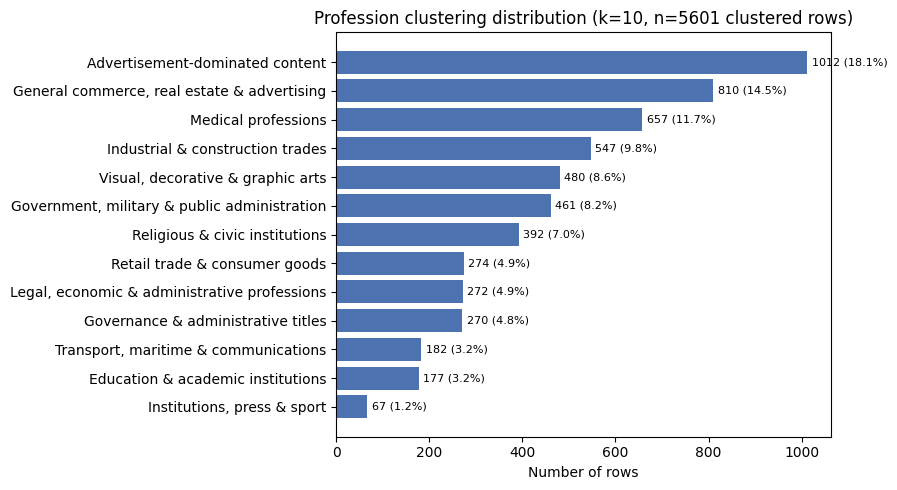

Saved (both) to stats_geo_analysis/20260824_161514/profession_clustering/: profession_category_distribution_k10_20260824_161514.png
Saved figure: stats_geo_analysis/profession_category_distribution_k10.png
                                    Category  Rows  % of categorized
             Advertisement-dominated content  1012              18.1
 General commerce, real estate & advertising   810              14.5
                         Medical professions   657              11.7
            Industrial & construction trades   547               9.8
           Visual, decorative & graphic arts   480               8.6
Government, military & public administration   461               8.2
              Religious & civic institutions   392               7.0
               Retail trade & consumer goods   274               4.9
Legal, economic & administrative professions   272               4.9
          Governance & administrative titles   270               4.8
        Transport, maritime & commu

In [95]:
# figures & tables -- k=10 profession distribution


cat_counts_k10 = geo["profession_category_k10"].value_counts().sort_values(ascending=True)
has_category = geo["profession_category_k10"].notna().sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cat_counts_k10.index, cat_counts_k10.values, color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"Profession clustering distribution (k=10, n={has_category} clustered rows)")
for bar, val in zip(bars, cat_counts_k10.values):
    ax.text(val + max(cat_counts_k10.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{val} ({100*val/has_category:.1f}%)", va="center", fontsize=8)
plt.tight_layout()

fig_path = "profession_category_distribution_k10.png"
plt.savefig(fig_path, dpi=150)
plt.show()

with open(fig_path, "rb") as f:
    upload_to_stats(fig_path, f.read(), "image/png", subfolder="profession_clustering")
print(f"Saved figure: stats_geo_analysis/{fig_path}")

# summary table for the thesis
summary_table_k10 = pd.DataFrame({
    "Category": cat_counts_k10.index[::-1],
    "Rows": cat_counts_k10.values[::-1],
    "% of categorized": (100 * cat_counts_k10.values[::-1] / has_category).round(1),
})
print(summary_table_k10.to_string(index=False))

csv_bytes = summary_table_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("profession_category_table_k10.csv", csv_bytes, "text/csv", subfolder="profession_clustering")
print(f"\nSaved: stats_geo_analysis/profession_category_table_k10.csv")


In [43]:
# cross-k comparison -- k=30 vs k=10, normalized (k=30's junk category treated as excluded, same basis as k=10's None)

def summarize_run(df, overrides_dict, k_label, junk_category_name=None):
    total_values = len(df)
    total_rows = df["frequency"].sum()
    was_overridden = df["profession"].isin(overrides_dict.keys())

    # treat both None and the named junk category as excluded
    is_excluded = df["category_name"].isna()
    if junk_category_name is not None:
        is_excluded = is_excluded | (df["category_name"] == junk_category_name)

    n_categorized_values = (~is_excluded).sum()
    n_excluded_values = is_excluded.sum()
    categorized_rows = df.loc[~is_excluded, "frequency"].sum()
    excluded_rows = df.loc[is_excluded, "frequency"].sum()
    n_distinct_categories = df.loc[~is_excluded, "category_name"].nunique()

    return {
        "k": k_label,
        "n_distinct_categories": n_distinct_categories,
        "total_unique_values": total_values,
        "total_rows": total_rows,
        "pct_values_categorized": round(100 * n_categorized_values / total_values, 1),
        "pct_rows_categorized": round(100 * categorized_rows / total_rows, 1),
        "pct_values_manually_moved": round(100 * was_overridden.sum() / total_values, 1),
        "pct_rows_manually_moved": round(100 * df.loc[was_overridden, "frequency"].sum() / total_rows, 1),
        "n_excluded_values": n_excluded_values,
        "excluded_rows": excluded_rows,
    }

comparison_rows = [
    summarize_run(cluster_df, VALUE_OVERRIDES, "k=30 (normalized)",
                  junk_category_name="Address fragments / non-profession"),
    summarize_run(cluster_df_k10, VALUE_OVERRIDES_K10, "k=10"),
]

comparison_df = pd.DataFrame(comparison_rows)
print(f"{'='*100}")
print("CROSS-K COMPARISON (normalized)")
print(f"{'='*100}")
print(comparison_df.to_string(index=False))

# note: input differences between the two runs
values_k30 = set(cluster_df["profession"])
values_k10 = set(cluster_df_k10["profession"])
only_in_k30 = values_k30 - values_k10
only_in_k10 = values_k10 - values_k30

print(f"\n{'='*65}")
print("NOTE: input difference between runs")
print(f"{'='*65}")
print(f"{len(only_in_k30)} value(s) only in k=30 (pre-registry-patch): {sorted(only_in_k30)}")
print(f"{len(only_in_k10)} value(s) only in k=10 (post-registry-patch, recovered names): {sorted(only_in_k10)}")
print("k=10 was clustered after the Ruolo Periti registry patch; k=30 predates it. "
      "The two runs are not on byte-identical input for this reason.")

csv_bytes = comparison_df.to_csv(index=False).encode("utf-8")
upload_to_stats("cross_k_comparison_normalized.csv", csv_bytes, "text/csv", subfolder="profession_clustering")
print(f"\nSaved: stats_geo_analysis/cross_k_comparison_normalized.csv")


CROSS-K COMPARISON (normalized)
                k  n_distinct_categories  total_unique_values  total_rows  pct_values_categorized  pct_rows_categorized  pct_values_manually_moved  pct_rows_manually_moved  n_excluded_values  excluded_rows
k=30 (normalized)                     31                 1090        5734                    93.0                  97.8                       15.2                     44.2                 76            124
             k=10                     13                 1090        5734                    92.2                  97.7                       37.5                     44.7                 85            133

NOTE: input difference between runs
0 value(s) only in k=30 (pre-registry-patch): []
0 value(s) only in k=10 (post-registry-patch, recovered names): []
k=10 was clustered after the Ruolo Periti registry patch; k=30 predates it. The two runs are not on byte-identical input for this reason.
Saved (both) to stats_geo_analysis/20260824_161514/professi

In [44]:
# diagnostic -- (1) same unique values in k=30 and k=10? (2) how much of k=30's junk hides under a named category?

# check 1: same underlying unique values?
values_k30 = set(cluster_df["profession"])
values_k10 = set(cluster_df_k10["profession"])

only_in_k30 = values_k30 - values_k10
only_in_k10 = values_k10 - values_k30

print(f"{'='*65}")
print("CHECK 1 — Do k=30 and k=10 share the exact same unique values?")
print(f"{'='*65}")
print(f"Unique values in k=30 cluster_df : {len(values_k30)}")
print(f"Unique values in k=10 cluster_df : {len(values_k10)}")
print(f"In k=30 but NOT in k=10           : {len(only_in_k30)}")
print(f"In k=10 but NOT in k=30           : {len(only_in_k10)}")

if only_in_k30:
    print(f"\nValues only in k=30:")
    for v in sorted(only_in_k30):
        print(f"  {v!r}")
if only_in_k10:
    print(f"\nValues only in k=10:")
    for v in sorted(only_in_k10):
        print(f"  {v!r}")

# check 2: junk hiding under a named category?
print(f"\n{'='*65}")
print("CHECK 2 — k=30's 'Address fragments / non-profession' category")
print(f"{'='*65}")

k30_junk_category = "Address fragments / non-profession"
k30_junk_mask = cluster_df["category_name"] == k30_junk_category
n_k30_junk_values = k30_junk_mask.sum()
k30_junk_rows = cluster_df.loc[k30_junk_mask, "frequency"].sum()

print(f"Unique values under '{k30_junk_category}' in k=30: {n_k30_junk_values}")
print(f"Rows under '{k30_junk_category}' in k=30         : {k30_junk_rows}")

n_total_values_k30 = len(cluster_df)
total_rows_k30 = cluster_df["frequency"].sum()

print(f"\nIf treated as 'excluded' for a fair comparison with k=10's None-based exclusion:")
print(f"  Adjusted excluded values (k=30): {n_k30_junk_values} ({100*n_k30_junk_values/n_total_values_k30:.1f}% of unique values)")
print(f"  Adjusted excluded rows (k=30)  : {k30_junk_rows} ({100*k30_junk_rows/total_rows_k30:.1f}% of rows)")
print(f"  Adjusted pct_values_categorized: {100*(n_total_values_k30 - n_k30_junk_values)/n_total_values_k30:.1f}%")
print(f"  Adjusted pct_rows_categorized  : {100*(total_rows_k30 - k30_junk_rows)/total_rows_k30:.1f}%")

print(f"\nFor comparison, k=10's actual figures:")
n_total_values_k10 = len(cluster_df_k10)
total_rows_k10 = cluster_df_k10["frequency"].sum()
n_excluded_k10 = cluster_df_k10["category_name"].isna().sum()
excluded_rows_k10 = cluster_df_k10.loc[cluster_df_k10["category_name"].isna(), "frequency"].sum()
print(f"  Excluded values (k=10): {n_excluded_k10} ({100*n_excluded_k10/n_total_values_k10:.1f}%)")
print(f"  Excluded rows (k=10)  : {excluded_rows_k10} ({100*excluded_rows_k10/total_rows_k10:.1f}%)")

CHECK 1 — Do k=30 and k=10 share the exact same unique values?
Unique values in k=30 cluster_df : 1090
Unique values in k=10 cluster_df : 1090
In k=30 but NOT in k=10           : 0
In k=10 but NOT in k=30           : 0

CHECK 2 — k=30's 'Address fragments / non-profession' category
Unique values under 'Address fragments / non-profession' in k=30: 76
Rows under 'Address fragments / non-profession' in k=30         : 124

If treated as 'excluded' for a fair comparison with k=10's None-based exclusion:
  Adjusted excluded values (k=30): 76 (7.0% of unique values)
  Adjusted excluded rows (k=30)  : 124 (2.2% of rows)
  Adjusted pct_values_categorized: 93.0%
  Adjusted pct_rows_categorized  : 97.8%

For comparison, k=10's actual figures:
  Excluded values (k=10): 85 (7.8%)
  Excluded rows (k=10)  : 133 (2.3%)


In [45]:
# ad-contamination candidates -- general method: a (page, value) shared across many distinct names in indice_generale may be ad text leaking in

MIN_ROWS = 5              # minimum repeat count to count as a pattern, not coincidence
MIN_UNIQUE_RATIO = 0.8    # >80% distinct names = spread across real entries, not one repeated name

def find_ad_contaminated_values(geo, column, section_col="section", target_section="indice_generale"):
    sub = geo[(geo[section_col] == target_section) & (geo[column].notna())]
    grouped = sub.groupby(["page_num", column]).agg(
        n_rows=("Name", "size"),
        n_unique_names=("Name", "nunique"),
    ).reset_index()
    flagged = grouped[
        (grouped["n_rows"] >= MIN_ROWS) &
        (grouped["n_unique_names"] / grouped["n_rows"] > MIN_UNIQUE_RATIO)
    ]
    return flagged

# Category added after finding "Colorificio Veneziano" (page 371) this way, same pattern as "Duplicatori"
results = {}
for col in ("Profession", "Role", "Category"):
    if col not in geo.columns:
        continue
    flagged = find_ad_contaminated_values(geo, col)
    results[col] = flagged
    print(f"\n=== {col}: {len(flagged)} candidate (page, value) patterns found "
          f"(needs human review -- see caveat above) ===")
    print(f"Distinct candidate values: {flagged[col].nunique()}")
    print(flagged.sort_values("n_rows", ascending=False).head(15).to_string(index=False))


# --- Save the flagged candidate patterns for manual review ---
for col in ("Profession", "Role", "Category"):
    if col in results:
        csv_bytes = results[col].to_csv(index=False).encode("utf-8")
        upload_to_stats(f"ad_contamination_candidates_{col.lower()}.csv", csv_bytes, "text/csv", subfolder="general")



=== Profession: 74 candidate (page, value) patterns found (needs human review -- see caveat above) ===
Distinct candidate values: 25
 page_num                                                 Profession  n_rows  n_unique_names
      402            MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI      61              58
      379                                        Vendita e Mobilizzi      55              53
      369 Lavorazione artistica mosaici in smalto di vetro Veneziano      54              54
      414                                                  industria      54              52
      389                                             panificio. SS.      53              50
      375                                        Vendita e Mobilizzi      53              48
      383                                                Duplicatori      51              50
      382                                        Vendita e Mobilizzi      51              51
      445           Rappresen

# 3. Category

In [46]:
# category pre-clustering: ad-contamination + English-label leak cleaning, runs before the OCR-garbage patch below
# (a) 6 business/institution names used as self-promo ads, not real categories
# (b) synthesized English labels not present in the source OCR -- recovered from Additional Info where possible, else blanked

AD_CONTAMINATION_NAMES_CAT = {
    "Nuova Editoriale S. A.":        "journal / publishing house (ad)",
    "Cassa di Risparmio di Venezia": "bank (ad)",
    "VALESE LUIGI":                  "foundry (ad)",
    "Paganotto Elsa":                "unidentified (ad, likely garbage)",
    "Stabilimento Marghera":         "port-related establishment (ad)",
    "Olimpia Film":                  "cinema (ad)",
    # typewriter/office-machine dealer ad, stamped across pages 346-486 (559 rows) -- not a real trade category
    "OFFICINA RIPARAZIONI MACCHINE PER SCRIVERE":                          "typewriter/office-machine repair shop (ad)",
    "OPIFCINA RIPARAZIONI MACCHINE PER SCRIVERE":                          "typewriter/office-machine repair shop (ad, OCR variant)",
    "MACCHINE per scrivere -- Calcolatrici - Duplicatori":                 "typewriter/calculator/duplicator dealer (ad)",
    "MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI":                     "typewriter/duplicator/accessories dealer (ad)",
    "MACCHINE CONTABILI MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI":  "accounting machine/typewriter dealer (ad)",
}

ENGLISH_LABEL_LEAK_CAT = {
    "Religious", "Military", "Finance", "Education", "Footwear",
    "Healthcare", "Insurance", "Municipal", "Associational",
    "Second-hand", "Representation",
    "Commercial", "ORGANIZATION", "Business", "Commerce",
    "Craftsmanship", "Retail", "Hospitality",
    "bottling", "tailor", "butchery", "millinery", "furniture",
    "chemistry", "pharmacist", "accountant", "representations",
    "cork", "wines", "factory", "furs", "expert", "products",
    "footwear", "profession", "religious", "Construction",
}
total_cat_bearing = int(geo["Category"].notna().sum())

# --- (a) Ad-contamination: count, save, then blank ---
mask_ad_cat = geo["Category"].isin(AD_CONTAMINATION_NAMES_CAT.keys())
ad_counts_cat = geo.loc[mask_ad_cat, "Category"].value_counts()

print("=== AD-CONTAMINATION IN CATEGORY (business/institution self-promotion) ===\n")
for name, kind in AD_CONTAMINATION_NAMES_CAT.items():
    n = int(ad_counts_cat.get(name, 0))
    print(f"  {name:<32} {kind:<35} {n:>5} rows")

total_ad_cat = int(mask_ad_cat.sum())
print(f"\nTotal ad-contamination instances : {total_ad_cat}")
print(f"As % of all Category-bearing rows: {100*total_ad_cat/total_cat_bearing:.2f}%")

ad_log_cat = pd.DataFrame([
    {"category_value": name, "identity": kind, "n_rows": int(ad_counts_cat.get(name, 0))}
    for name, kind in AD_CONTAMINATION_NAMES_CAT.items()
])
ad_log_cat.loc["TOTAL"] = ["TOTAL", "", total_ad_cat]
_ad_bytes = ad_log_cat.to_csv(index=False).encode("utf-8")
upload_to_stats("category_ad_contamination.csv", _ad_bytes, "text/csv", subfolder="category_clustering")

geo.loc[mask_ad_cat, "Category"] = pd.NA

# (b) recover from Additional Info where possible, blank what's left
mask_english_cat = geo["Category"].isin(ENGLISH_LABEL_LEAK_CAT)
english_counts_cat = geo.loc[mask_english_cat, "Category"].value_counts()

print("\n=== SYNTHESIZED-ENGLISH-LABEL ANOMALY IN CATEGORY ===\n")
print(english_counts_cat.to_string())
total_english_cat = int(mask_english_cat.sum())
print(f"\nTotal instances: {total_english_cat} "
      f"({100*total_english_cat/total_cat_bearing:.2f}% of Category-bearing rows)")
print("Page distribution:",
      geo.loc[mask_english_cat, "page_num"].value_counts().to_dict()
      if "page_num" in geo.columns else "(page_num not in geo)")

def _usable_addinfo(v):
    if pd.isna(v):
        return None
    v = str(v).strip()
    if not v or v in ENGLISH_LABEL_LEAK_CAT or v in AD_CONTAMINATION_NAMES_CAT:
        return None
    return v

_recovered_from = geo.loc[mask_english_cat, "Additional Info"].apply(_usable_addinfo)
_recovered_mask = mask_english_cat & _recovered_from.notna().reindex(geo.index, fill_value=False)

english_log_cat = geo.loc[mask_english_cat, ["Category"]].copy()
english_log_cat["recovered_value"] = _recovered_from
english_log_cat["status"] = english_log_cat["recovered_value"].apply(
    lambda v: "recovered_from_additional_info" if pd.notna(v) else "blanked_no_usable_source"
)
_english_bytes = english_log_cat.reset_index(drop=True).to_csv(index=False).encode("utf-8")
upload_to_stats("category_english_label_anomaly.csv", _english_bytes, "text/csv", subfolder="category_clustering")

n_recovered = int(_recovered_mask.sum())
n_blanked_english = int(mask_english_cat.sum()) - n_recovered
print(f"\nRecovered from Additional Info: {n_recovered}")
print(f"Blanked (no usable Additional Info): {n_blanked_english}")

geo.loc[_recovered_mask, "Category"] = _recovered_from.dropna()  # pandas aligns by index label
geo.loc[mask_english_cat & ~_recovered_mask, "Category"] = pd.NA

print(f"\nTotal Category values blanked by this cell: {total_ad_cat + n_blanked_english}")
print(f"Total Category values recovered by this cell: {n_recovered}")

=== AD-CONTAMINATION IN CATEGORY (business/institution self-promotion) ===

  Nuova Editoriale S. A.           journal / publishing house (ad)       157 rows
  Cassa di Risparmio di Venezia    bank (ad)                              67 rows
  VALESE LUIGI                     foundry (ad)                          131 rows
  Paganotto Elsa                   unidentified (ad, likely garbage)     138 rows
  Stabilimento Marghera            port-related establishment (ad)        56 rows
  Olimpia Film                     cinema (ad)                           162 rows
  OFFICINA RIPARAZIONI MACCHINE PER SCRIVERE typewriter/office-machine repair shop (ad)   322 rows
  OPIFCINA RIPARAZIONI MACCHINE PER SCRIVERE typewriter/office-machine repair shop (ad, OCR variant)    46 rows
  MACCHINE per scrivere -- Calcolatrici - Duplicatori typewriter/calculator/duplicator dealer (ad)   167 rows
  MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI typewriter/duplicator/accessories dealer (ad)    13 rows
  MA

In [47]:
# pre-clustering patch: Category 
# (a) strips "Category:"/"Location:" prefix leaks, keeps the real content after it
# (b) blanks the bare literal "Category" (column header leaking into itself)
FIELD_PREFIX_RE = re.compile(r"^(category|location)\s*:\s*", re.IGNORECASE)

def _strip_field_prefix_cat(value):
    if pd.isna(value):
        return value
    v = FIELD_PREFIX_RE.sub("", str(value).strip()).strip()
    return v if v else pd.NA

_before_prefix_strip = geo["Category"].copy()
geo["Category"] = geo["Category"].apply(_strip_field_prefix_cat)
n_prefix_stripped = int((_before_prefix_strip.fillna("") != geo["Category"].fillna("")).sum())
print(f"{n_prefix_stripped} rows had a 'Category:'/'Location:' prefix stripped.")

OCR_GARBAGE_PATTERN = re.compile(r"^[\W_]+$|^.$")
KNOWN_PLACEHOLDER_TOKENS_CAT = {
    "ditto", "fom", "ras", '4130"', "8. a. r. Ir.", "Cone.",
    "Category", "Location",  # the bare field-name literal itself, no colon/value
}

def _is_ocr_garbage_cat(value):
    if pd.isna(value):
        return False
    v = str(value).strip()
    if v in KNOWN_PLACEHOLDER_TOKENS_CAT:
        return True
    if len(v) <= 1:
        return True
    if OCR_GARBAGE_PATTERN.match(v):
        return True
    return False

mask_garbage_cat = geo["Category"].apply(_is_ocr_garbage_cat)

print(f"{mask_garbage_cat.sum()} rows matched OCR-garbage pattern: "
      f"{sorted(geo.loc[mask_garbage_cat, 'Category'].dropna().unique())[:20]}"
      f"{' ...' if mask_garbage_cat.sum() > 20 else ''}")

geo.loc[mask_garbage_cat, "Category"] = pd.NA
print(f"\nTotal blanked: {mask_garbage_cat.sum()} rows.")

189 rows had a 'Category:'/'Location:' prefix stripped.
52 rows matched OCR-garbage pattern: ['Category'] ...

Total blanked: 52 rows.


In [48]:
# embedding + clustering + pin -- category k=10 (direct), reference: category_clusters_k10_reference.csv
# skips embedding and clustering if the value set is unchanged

cat_value_counts  = geo["Category"].value_counts()
cat_unique_values = cat_value_counts.index.tolist()
print(f"{len(cat_unique_values)} unique Category values "
      f"(covering {cat_value_counts.sum()} total rows).")

REGENERATE_REFERENCE_CAT = False
REFERENCE_CLUSTER_FILE_CAT = STATS_LOCAL_DIR / "reference" / "category" / "category_clusters_k10_reference.csv"

_need_compute = True
if not REGENERATE_REFERENCE_CAT and REFERENCE_CLUSTER_FILE_CAT.exists():
    reference_df_cat = pd.read_csv(REFERENCE_CLUSTER_FILE_CAT)
    if set(reference_df_cat["category"]) == set(cat_unique_values):
        print(f"Value set unchanged ({len(cat_unique_values)} values match the reference exactly) "
              f"-- skipping embedding and KMeans, loading the pinned reference directly.")
        cat_cluster_df = reference_df_cat.copy()
        _need_compute = False

if _need_compute:
    _cat_emb_cache = STATS_LOCAL_DIR / "reference" / "category" / "category_embeddings_cache.npy"
    _cat_emb_values_cache = STATS_LOCAL_DIR / "reference" / "category" / "category_embeddings_values.csv"
    cat_embeddings = None
    if _cat_emb_cache.exists() and _cat_emb_values_cache.exists():
        _cached_cat_values = pd.read_csv(_cat_emb_values_cache)["value"].tolist()
        if _cached_cat_values == cat_unique_values:
            cat_embeddings = np.load(_cat_emb_cache)
            print(f"Loaded cached embeddings -> {cat_embeddings.shape}, no API calls made.")
        else:
            print("Cached values don't match current cat_unique_values -- recomputing.")
    if cat_embeddings is None:
        cat_embeddings = []
        for i in range(0, len(cat_unique_values), BATCH_SIZE):
            batch = cat_unique_values[i:i + BATCH_SIZE]
            batch_embeddings = embed_batch_with_retry(batch)
            cat_embeddings.extend(batch_embeddings)
            print(f"  Embedded {min(i + BATCH_SIZE, len(cat_unique_values))}/{len(cat_unique_values)}")
        cat_embeddings = np.array(cat_embeddings)
        np.save(_cat_emb_cache, cat_embeddings)
        pd.DataFrame({"value": cat_unique_values}).to_csv(_cat_emb_values_cache, index=False)
        print(f"Embedding matrix shape: {cat_embeddings.shape}")

    N_CLUSTERS_CAT = 10
    kmeans_cat = KMeans(n_clusters=N_CLUSTERS_CAT, random_state=42, n_init=10)
    cat_cluster_labels = kmeans_cat.fit_predict(cat_embeddings)
    cat_cluster_df = pd.DataFrame({
        "category": cat_unique_values,
        "frequency": cat_value_counts.values,
        "cluster_id": cat_cluster_labels,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    if REGENERATE_REFERENCE_CAT or not REFERENCE_CLUSTER_FILE_CAT.exists():
        if REGENERATE_REFERENCE_CAT:
            print("REGENERATE_REFERENCE_CAT=True -- overwriting the pinned reference with this run.")
        else:
            print(f"No reference file found at {REFERENCE_CLUSTER_FILE_CAT.name} -- "
                  f"bootstrapping: this run becomes the permanent reference.")
        reference_df_cat = cat_cluster_df.copy()
        STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        reference_df_cat.to_csv(REFERENCE_CLUSTER_FILE_CAT, index=False)
        upload_to_stats("category_clusters_k10_reference.csv",
                         reference_df_cat.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="category_clustering")
        print(f"Saved reference: {REFERENCE_CLUSTER_FILE_CAT.name} ({len(reference_df_cat)} rows)")
    else:
        reference_map_cat = dict(zip(reference_df_cat["category"], reference_df_cat["cluster_id"]))
        current_map_cat = dict(zip(cat_cluster_df["category"], cat_cluster_df["cluster_id"]))
        mismatches_cat = {
            c: (reference_map_cat.get(c), current_map_cat.get(c))
            for c in set(reference_map_cat) | set(current_map_cat)
            if reference_map_cat.get(c) != current_map_cat.get(c)
        }
        print(f"{'='*70}")
        print(f"MISMATCH -- {len(mismatches_cat)} of "
              f"{len(set(reference_map_cat) | set(current_map_cat))} category value(s) differ from the reference.")
        print("cat_cluster_df is being reset to the pinned reference. "
              "Set REGENERATE_REFERENCE_CAT=True above if this run should replace it instead.")
        print(f"{'='*70}\n")

    cat_cluster_df = reference_df_cat.copy()

print(f"cat_cluster_df is now pinned ({len(cat_cluster_df)} rows, "
      f"{cat_cluster_df['cluster_id'].nunique()} clusters).")


2749 unique Category values (covering 11175 total rows).
Value set unchanged (2749 values match the reference exactly) -- skipping embedding and KMeans, loading the pinned reference directly.
cat_cluster_df is now pinned (2749 rows, 10 clusters).


In [49]:
# apply category names + corrections (k=10, final) -- one name per cluster plus manual value-level moves
# names read directly off category_clusters_k10_20260802_173629.csv

import os as _os_cat_guard
if not callable(globals().get("_v")):
    def _v(name):
        stem, ext = _os_cat_guard.path.splitext(name)
        return f"{stem}_{RUN_TAG}{ext}"
    print("NOTE: _v() was clobbered earlier this session -- restored here.")

CLUSTER_DEFAULT_NAMES_CAT = {
    0: "Textiles, clothing",
    1: "Transport, shipping & maritime trades",
    2: "general retail",
    3: "Institutions/companies",
    4: "Legal, financial & administrative professions ",
    5: "Real estate, construction & business services",
    6: "Chemicals, fuel, construction materials & raw materials",
    7: "Decorative arts, photography, antiques & artisan crafts",
    8: "Office equipment, electrical, mechanical & industrial trades",
    9: "Food, grocery & hospitality trade",
}

# manual moves: bare place names/addresses excluded, LA VELOCE moved to maritime, carpentry/lampshades moved to decorative arts, MACCHINE PER SCRIVERE family excluded (ad)
RELIGIOUS_CAT_NAME = "Religious institutions & clergy"
CULTURE_CAT_NAME = "Culture, entertainment & leisure"

VALUE_OVERRIDES_CAT = {
    "Mestre": None,
    "Venezia - Via XXII Marzo, 2288, Telephone: 25-889": None,
    "LA VELOCE..": CLUSTER_DEFAULT_NAMES_CAT[1],
    "Carpentiere": CLUSTER_DEFAULT_NAMES_CAT[7],
    "Abat jours": CLUSTER_DEFAULT_NAMES_CAT[7],
    "Macchine per scrivere": None,
    "Macchine per scrivere - Calcolatrici - Duplicatori": None,
    "Macchine per scrivere e accessori": None,
    "Macchine per scrivere - Calcolatrici - Duplicatori - OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI": None,
    "Macchine per scrivene - Calcilatrici - Duplicatori": None,
    "SCHEDARI - MOBILI PER UFFICIO - MACCHINE CONTABILI - MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI": None,
    "SCHEDARI - MOBILI PER UFFICI - MACCHINE CONTABILI MACCHINE PER SCRIVERE DUPLICATORI - ACCESSORI": None,
    "macchine contabili calcolatrici": None,
}

# manual review of cluster 2 (heterogeneous grab-bag) -- values reassigned to an existing cluster's theme, grouped by destination below

# --> cluster 9 (Food, grocery & hospitality trade) 
CLUSTER2_TO_FOOD = [
    "Bar", "bar", "Latterie", "Latteria", "Osterie", "osteria", "Osteria",
    "osterie", "LOCANDE", "Vini", "vini", "Liqouri", "Dolciumi", "Agrumi",
    "Birrerie", "birreria", "Birreria", "Hotel", "albergo", "Albergo",
    "pensione", "Pensione", "o. pensione", "Uova", "uova", "Zucchero",
    "polleria", "Vallicultura", "vallicultura", "Ghiaccio", "ghiaccio",
    "Ghiacciaie",
    "Barili", "Droghe", "Ortaggi", "Aceto", "Alcool", "Carni", "Caviale",
    "dolciumi",
]
for _val in CLUSTER2_TO_FOOD:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[9]

# --> cluster 4 (Legal, financial & administrative professions) 
CLUSTER2_TO_PROFESSIONS = [
    "Case di Cura", "Geometra", "Geometre", "Geomera", "ostetrica", "Ostetrica",
    "perito", "dentista", "Dentista", "Medico", "medico", "medico generale",
    "Medicina", "chirurgo", "medico chirurgo", "stomatologo", "oculista",
    "veterinario", "Veterinario", "notaio", "attuario", "Attuario",
    "Cassiere", "Ragiionere", "Economo",
    "malattie nervose", "dermosifilopatica", "dermosifilopata", "dermatologo",
    "otorinolaringoiatra", "ortopedico", "radiologo", "radiogiologo",
    "Pediatra", "osteitrico", "ostetrico", "ostetia", "Clinica Ostetrica",
    "malatte polmonari", "pharmacy",
]
for _val in CLUSTER2_TO_PROFESSIONS:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[4]

# --> cluster 1 (Transport, shipping & maritime trades)
CLUSTER2_TO_MARITIME = [
    "Squerì", "Navi", "navi", "Rimorchatori", "Recuperi marittimi",
    "ricuperi marittimi",
    # third pass
    "Messaggerie", "Morocicli",
]
for _val in CLUSTER2_TO_MARITIME:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[1]

# --> cluster 7 (Decorative arts, photography, antiques & artisan crafts)
CLUSTER2_TO_DECORATIVE = [
    "falegname", "Cornici", "Vetri", "vetri", "Vetria 17", "vetria",
    "Vetreria", "vetreria",
    # third pass
    "pittrice", "ottica", "terraglie", "Vetri neutri",
]
for _val in CLUSTER2_TO_DECORATIVE:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[7]

# --> cluster 0 (Textiles, clothing, haberdashery & general retail trades)
CLUSTER2_TO_TEXTILES = [
    "Strti da uomo", "sarta", "Sarte", "Sarta", "sarto", "barbiere",
    "Barbieri", "Barbiere", "barbieri", "mercerie", "Seterie", "oreficeria",
    "Argenterie", "Modisterie", "Modisteria", "modisteria", "CARTA", "Carta",
    "carta", "fiori", "Fiori", "Perle",
    "Mode", "mode", "orologeria", "libreria", "Pelli", "pellami",
    "pellami e cuoi", "Bazar", "IMPERMEABILI", "Pantofolai", "Ombrelli",
    "Filande", "setorie e lanerie", "Lane e crine", "Telerie", "Stracci",
    "Sementi", "calze", "valigerie",
]
for _val in CLUSTER2_TO_TEXTILES:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[0]

# --> cluster 6 (Chemicals, fuel, construction materials & raw materials)
CLUSTER2_TO_MATERIALS = [
    "Refrettari", "Petrolio",
    # third pass
    "Catrame", "Semi oleosi", "Sughero", "Acciai", "Bitumi", "Gas",
    "Zolfo", "Ghisa", "Olii", "Bandiere", "trebbiatura",
]
for _val in CLUSTER2_TO_MATERIALS:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[6]

# --> cluster 8 (Office equipment, electrical, mechanical & industrial trades) 
CLUSTER2_TO_OFFICE = [
    "Coltellinai e Arrotini", "coltellinaio e arrotino", "ing.",
    "Frigoriferi", "Bilancie", "Calderai", "Lamiere", "radio", "pianoforti",
    "Tipografie", "tipografia", "Tipografia", "STABILIMENTO GRAFICO",
    "Zincografia", "Giornali", "giornali",
]
for _val in CLUSTER2_TO_OFFICE:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[8]

# --> cluster 5 (Real estate, construction, office furniture & business services)
CLUSTER2_TO_REALESTATE = ["Materassai", "Terrrazzi", "murari"]
for _val in CLUSTER2_TO_REALESTATE:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[5]

# --> cluster 3 (Institutions/companies) -- "rettore" is ambiguous between academic and institutional head; not clergy enough for Religious
CLUSTER2_TO_INSTITUTIONS_ADMIN = ["rettore"]
for _val in CLUSTER2_TO_INSTITUTIONS_ADMIN:
    VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[3]

# --> NEW: Culture, entertainment & leisure 
CLUSTER2_TO_CULTURE = ["Cinema", "cinema", "Teatri", "Filatelico"]
for _val in CLUSTER2_TO_CULTURE:
    VALUE_OVERRIDES_CAT[_val] = CULTURE_CAT_NAME

# --> NEW: Religious institutions & clergy 
CLUSTER2_TO_RELIGIOUS = ["parroco", "Parroco", "Arciprete", "arciprete"]
CLUSTER3_TO_RELIGIOUS = [
    "pm. Patriarcale", "arpicprete Basilica di San Marco",
    "arciprete Basilica di S. Marco", "parroco S. Maria Elisabetta di Lido",
    "parroco, S. Giacomo dall\u2019Orio", "parroco S. Maria del Gi glio",
    "parroco Treporti", "Purroco San Polo Apostolo", "Parocco",
    "Geriatrico del Seminario Patriarcale, Santa Maria della Salute",
    "Basilica di S. Marco", "Basilica di San Marco",
]
CLUSTER4_TO_RELIGIOUS = [
    "Vescovo Ausiliare", "Comunit\u00e0 Israelitica", "Cerioniero del Patriarcato",
    "vicario", "Vicario", "vicario S. Leone, (S. Lio)", "vicario S. Barnaba",
    "Vicario S. Sofia", "curato autonomo",
]
for _val in CLUSTER2_TO_RELIGIOUS + CLUSTER3_TO_RELIGIOUS + CLUSTER4_TO_RELIGIOUS:
    VALUE_OVERRIDES_CAT[_val] = RELIGIOUS_CAT_NAME

CLUSTER2_MANUAL_MOVES = (
    CLUSTER2_TO_FOOD + CLUSTER2_TO_PROFESSIONS + CLUSTER2_TO_MARITIME
    + CLUSTER2_TO_DECORATIVE + CLUSTER2_TO_TEXTILES + CLUSTER2_TO_MATERIALS
    + CLUSTER2_TO_RELIGIOUS + CLUSTER2_TO_OFFICE + CLUSTER2_TO_REALESTATE
    + CLUSTER2_TO_INSTITUTIONS_ADMIN + CLUSTER2_TO_CULTURE
)


GENRETAIL_TO_TEXTILES = [  # cluster 0
    "Manifesture", "Libreria", "abbiagliamento", "Orologeria", "pelliche", "ombrelli", "perle",
    "Vestiario", "Divise", "divise", "Filanda", "lavandiera", "Penna", "Bottegon",
    "Acqua di colonia", "Fibre autarchiche", "tessanti", "Merletta e cirmi", "cappelleria",
    "liagerie", "cinzieria", "calcature", "cralrature", "chincaglie", "ca-toleria",
    "sa to da uomo", "argenteria orologeria", "Laboratorio orologeria", "orologiaio",
    "oreccheria", "orefici", "orefaceri", "ore-fiseria", "orefice'ia", "orefacreia",
    "mercer.", "merce verie", "merce'cie", "merce- rie", "mererce", "micelleria",
    "cartolexia", "carta (grossiuita)", "carta da macera", "Cartotecnica", "valigeria",
    "pellami e cuoi a", "pellami e cuolo", "Pellami e cuoi", "pellicterie", "pelli",
    "pelterie", "lavandoria e steria", "barberie", "parru1chiera", "fiati ed affini",
    "Armonium",
]

GENRETAIL_TO_FOOD = [  # cluster 9
    "Strucchi", "liquori", "lateria", "leatarie", "trattorìa", "trattorio", "tratto-ia",
    "trattatia", "ristor ante", "osterica", "oste", "foraggi", "Foraggi", "caffe", "caffe'",
    "caffe (serezizi)", "contoi e casearia", "latte", "Latte", "pasticciere", "pasticcera",
    "conservere", "tabachcheria", "Orzo", "budella", "sciroppi liguori", "levita", "baccaleria",
    "dolciumi (mag osso)", "carni equine", "Carni equine", "hotelgieria", "Molino", "molino",
    "Molini", "Ghiaccio (tabralerio)", "valli cultura", "Zuccherifici", "Coloniali", "Conserve",
    "Malto", "agrumi", "nacelleria", "aimenzanti (dett.)", "macellazione", "Macellazione",
    "macellaia", "macellaio", "Bestimare ed esercizio macellere", "Case da Gioco",
]

GENRETAIL_TO_MARITIME = [  # cluster 1
    "imbarchi e sbarchi", "imbarcbi e subarbe", "squero", "sguero", "automoleggio", "recuperi",
    "facchini | publici", "Marittimi", "cordami", "Lloyd’s Agen.", "Piloti", "piloti",
    "Palombari", "palombari",
]

GENRETAIL_TO_DECORATIVE = [  # cluster 7
    "rigattatoi", "bigiotterie", "Bigiotterie", "Quadri", "quadri", "cornice", "ebanista",
    "Ebanisti", "vetroflex", "Vetroflex", "Plexiglas", "Conterie ar-pe-le",
    "incisore, cesellatore, sbalzatore", "incisore", "Ottonai", "hottigliocristai.",
    "Porcellane", "Terragliole", "Francobolli", "Doratura", "stucchi", "cortele e e perle",
    "carpentire", "lapidi marini", "Bronzi", "bronzi",
]

GENRETAIL_TO_MATERIALS = [  # cluster 6
    "petrolio", "Imballaggii", "minio", "Turaccioli", "calce e laterizzi", "Calce", "Ghiaia",
    "Gres", "Cave", "sughero", "Insetticidi", "INSETTICIDI", "INSETTICIDA", "Eraclit", "Rodio",
    "Panelli", "Sego", "carbonia", "Nichelatura",
]

GENRETAIL_TO_OFFICE = [  # cluster 8
    "cotellajuai, arrottini, minio", "elttricità econo, nizatori", "bandaio e fattirone",
    "bandaio lattoniere", "radio e radio; alumunofni", "Radio", "Telecommunication",
    "Zinografia", "accumulatori", "Accumulatóri", "Aspirapolvere", "Stufe", "Termometri",
    "tipografa", "automatismi", "Pianoforti",
]

GENRETAIL_TO_INSTITUTIONS = [  # cluster 3
    "autoscuola", "nettezza urbana", "consigliere", "scuola", "polizia rifiori", "Municipio",
    "Recordi ferroviari", "incendiere", "usciere",
]

GENRETAIL_TO_REALESTATE = ["Espurgo pozzi neri", "murtori", "macerie"]  # cluster 5

GENRETAIL_TO_PROFESSIONS = [  # cluster 4
    "l'attrice", "geometra", "insegnanter", "notato", "notai1o", "Detective", "ingg.", "arw.",
    "chirurg", "rappresantanze varie", "raprresentante",
]

GENRETAIL_TO_CULTURE = ["Filatelica"]  # not tied to a cluster index

GENRETAIL_TO_RELIGIOUS = ["Pastore"]  # user confirmed: pastor, not shepherd

GENRETAIL_EXCLUDED = [
    # generic legal-form / business-form abbreviations, not a trade category
    "Soc. Coop.", "S. A.", "S.", "Soc. An.", "Soc per Az", "(Ditta)", "(dett.)", "(dettaglio)",
    "dettaglio", "Comm.", "comm.", "Pres.", "per azioni", "Esercizi", "Esercizio", "AGENCY",
    "well executives", "soc", "Duplicatori", 
    "fdm. Navagero 34", "Cann. 1671", "Cann. 2102", "Cann 8971", "via Dese", "Via Algieri",
    "Ruga Giuffa", "C.P. 28", "C. P. 46", "numero 45", "numero 1641", "numero 565", "numero 572",
    "telefono 24-562", "Telef. 53-819", "Santa Apneise 909-A", "fond. Cavor 13", "Gludeco 595",
    "Cast. 3133", "S. Moisé", "Fond. Convertite", "Cavalcavia", "Calvacavia", "Pal Da Mula",
    "Màghera", "Navagero 54", "ldm. Domnla Onesta", "v. Macello", "Cà Vio", "2196 A", "661-A",
    "119-A\"", "1079\"", "co 1294", "2667 B", "O.S.M.", "F.I.T.T.V.", "S.A.V.I.A.", "S.A.F.A.",
    "P. S. in S.P.K.", "A.C.S Empale. vile e handli're;", "(ANPI)", "Organiz. (ANT)",
]

GENRETAIL_MANUAL_MOVES = (
    GENRETAIL_TO_TEXTILES + GENRETAIL_TO_FOOD + GENRETAIL_TO_MARITIME + GENRETAIL_TO_DECORATIVE
    + GENRETAIL_TO_MATERIALS + GENRETAIL_TO_OFFICE + GENRETAIL_TO_INSTITUTIONS
    + GENRETAIL_TO_REALESTATE + GENRETAIL_TO_PROFESSIONS + GENRETAIL_TO_CULTURE
    + GENRETAIL_TO_RELIGIOUS + GENRETAIL_EXCLUDED
)

for _val in GENRETAIL_TO_TEXTILES: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[0]
for _val in GENRETAIL_TO_MARITIME: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[1]
for _val in GENRETAIL_TO_INSTITUTIONS: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[3]
for _val in GENRETAIL_TO_PROFESSIONS: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[4]
for _val in GENRETAIL_TO_REALESTATE: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[5]
for _val in GENRETAIL_TO_MATERIALS: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[6]
for _val in GENRETAIL_TO_DECORATIVE: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[7]
for _val in GENRETAIL_TO_OFFICE: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[8]
for _val in GENRETAIL_TO_FOOD: VALUE_OVERRIDES_CAT[_val] = CLUSTER_DEFAULT_NAMES_CAT[9]
for _val in GENRETAIL_TO_CULTURE: VALUE_OVERRIDES_CAT[_val] = CULTURE_CAT_NAME
for _val in GENRETAIL_TO_RELIGIOUS: VALUE_OVERRIDES_CAT[_val] = RELIGIOUS_CAT_NAME
for _val in GENRETAIL_EXCLUDED: VALUE_OVERRIDES_CAT[_val] = None

# cluster 3 address-fragment sweep: anything matching a Venice toponym/street/phone pattern is excluded too

KEEP_CLUSTER3 = {
    "cappelano S. Bingio (Chiesa della Marina).", "Banco di Roma",
    "CINEMA S. Margherita", "VISITOSI GUIDO", "Trattoria", "locanda",
    "Specialità Veneziane",
}
ADDRESS_FRAGMENT_RE = re.compile(
    r'^(s\.|ss\.|san |santa |sant[\u2019\']|campo |calle |via |piazza|piazzale|piazz\.|'
    r'p\.za|fondamenta|fdn\.|fdm\.|riva |ponte|corso |strada|sede |bacino|zattere|telefono|'
    r'cannaregio|castello|giudecca|dorsoduro|d\. duro|venezia|milano|lido |burano|murano|'
    r'chioggia|pellestrina|favaro|mestre|marco |numero )',
    re.IGNORECASE,
)

_cluster3_vals = cat_cluster_df.loc[cat_cluster_df["cluster_id"] == 3, "category"]
_address_moves = {
    v: None for v in _cluster3_vals
    if v not in KEEP_CLUSTER3 and v not in VALUE_OVERRIDES_CAT
    and bool(ADDRESS_FRAGMENT_RE.match(str(v).strip()))
}
VALUE_OVERRIDES_CAT.update(_address_moves)

# --- Apply ---
cat_cluster_df["category_name"] = cat_cluster_df.apply(
    lambda row: VALUE_OVERRIDES_CAT.get(row["category"], CLUSTER_DEFAULT_NAMES_CAT[row["cluster_id"]]),
    axis=1
)

n_matched_cat = sum(1 for c in cat_cluster_df["category"] if c in VALUE_OVERRIDES_CAT)
n_excluded_cat = cat_cluster_df["category_name"].isna().sum()
excluded_rows_cat = cat_cluster_df.loc[cat_cluster_df["category_name"].isna(), "frequency"].sum()

print("=== MANUAL CHANGES APPLIED ===\n")
_moved_from_c2 = cat_cluster_df[
    (cat_cluster_df["cluster_id"] == 2) & (cat_cluster_df["category"].isin(CLUSTER2_MANUAL_MOVES))
]
print(f"Cluster 2 values manually reassigned to an existing cluster: {len(_moved_from_c2)} unique values, "
      f"{int(_moved_from_c2['frequency'].sum())} rows")
for _dest in sorted(set(VALUE_OVERRIDES_CAT[v] for v in CLUSTER2_MANUAL_MOVES if v in VALUE_OVERRIDES_CAT)):
    _sub = _moved_from_c2[_moved_from_c2["category"].map(VALUE_OVERRIDES_CAT) == _dest]
    print(f"    -> {_dest:<65} {len(_sub):>4} values, {int(_sub['frequency'].sum()):>5} rows")
_remaining_c2 = cat_cluster_df[
    (cat_cluster_df["cluster_id"] == 2) & (cat_cluster_df["category_name"] == "general retail")
]
print(f"Cluster 2 reshuffled in the second pass (general retail -> an existing cluster): "
      f"{sum(1 for v in GENRETAIL_MANUAL_MOVES if v not in GENRETAIL_EXCLUDED)} unique values, "
      f"{int(cat_cluster_df[cat_cluster_df['category'].isin(GENRETAIL_MANUAL_MOVES) & (cat_cluster_df['category_name'].notna())]['frequency'].sum())} rows")
print(f"Cluster 2 excluded in the second pass (legal-form / address fragments, not a trade "
      f"category): {len(GENRETAIL_EXCLUDED)} unique values, "
      f"{int(cat_cluster_df[cat_cluster_df['category'].isin(GENRETAIL_EXCLUDED)]['frequency'].sum())} rows")
print(f"Cluster 2 still kept as \"general retail\" (real content, but too corrupted by OCR to "
      f"confidently reshuffle): {len(_remaining_c2)} unique values, "
      f"{int(_remaining_c2['frequency'].sum())} rows")

_religious_all = CLUSTER2_TO_RELIGIOUS + CLUSTER3_TO_RELIGIOUS + CLUSTER4_TO_RELIGIOUS
_religious_matched = cat_cluster_df[cat_cluster_df["category"].isin(_religious_all)]
print(f"\nNew '{RELIGIOUS_CAT_NAME}' category: {len(_religious_matched)} of {len(_religious_all)} "
      f"defined values matched, {int(_religious_matched['frequency'].sum())} rows "
      f"(from clusters 2, 3, and 4 combined)")

_culture_matched = cat_cluster_df[cat_cluster_df["category"].isin(CLUSTER2_TO_CULTURE)]
print(f"New '{CULTURE_CAT_NAME}' category: {len(_culture_matched)} of {len(CLUSTER2_TO_CULTURE)} "
      f"defined values matched, {int(_culture_matched['frequency'].sum())} rows")
print(f"\nAddress fragments excluded from cluster 3: {len(_address_moves)} unique values, "
      f"{int(cat_cluster_df[cat_cluster_df['category'].isin(_address_moves)]['frequency'].sum())} rows")
print(f"Total manual overrides matched: {n_matched_cat} of {len(VALUE_OVERRIDES_CAT)} defined")
print(f"Total excluded (all reasons combined): {n_excluded_cat} unique values, {excluded_rows_cat} rows")

# --- Save corrected lookup table ---
csv_bytes = cat_cluster_df.to_csv(index=False).encode("utf-8")
upload_to_stats("category_clusters_k10_corrected.csv", csv_bytes, "text/csv", subfolder="category_clustering")

# --- Join category_name onto the full inside-Venice dataset ---
category_lookup_cat = dict(zip(cat_cluster_df["category"], cat_cluster_df["category_name"]))
geo["category_class_k10"] = geo["Category"].map(category_lookup_cat)

# --- Stats ---
total_rows_cat = len(geo)
has_class_cat = geo["category_class_k10"].notna().sum()
print(f"\nTotal inside-Venice rows       : {total_rows_cat}")
print(f"Rows with a k=10 category class: {has_class_cat} ({100*has_class_cat/total_rows_cat:.1f}%)")

cat_class_counts_k10 = geo["category_class_k10"].value_counts()
print(f"\n{'CLASS':<70} {'ROWS':>8} {'% OF CLASSIFIED':>10}")
print("-" * 98)
for cls, count in cat_class_counts_k10.items():
    print(f"{cls:<70} {count:>8} {100*count/has_class_cat:>9.1f}%")

stats_bytes = cat_class_counts_k10.reset_index().rename(
    columns={"index": "category_class", "category_class_k10": "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("category_class_stats_k10.csv", stats_bytes, "text/csv", subfolder="category_clustering")

print(f"\nSaved: stats_geo_analysis/category_clusters_k10_corrected.csv")
print(f"Saved: stats_geo_analysis/category_class_stats_k10.csv")

=== MANUAL CHANGES APPLIED ===

Cluster 2 values manually reassigned to an existing cluster: 181 unique values, 1734 rows
    -> Chemicals, fuel, construction materials & raw materials             13 values,   108 rows
    -> Culture, entertainment & leisure                                     4 values,    18 rows
    -> Decorative arts, photography, antiques & artisan crafts             12 values,    78 rows
    -> Food, grocery & hospitality trade                                   40 values,   584 rows
    -> Institutions/companies                                               1 values,     2 rows
    -> Legal, financial & administrative professions                       39 values,   151 rows
    -> Office equipment, electrical, mechanical & industrial trades        16 values,   122 rows
    -> Real estate, construction & business services                        3 values,    11 rows
    -> Religious institutions & clergy                                      4 values,     9 rows
    -

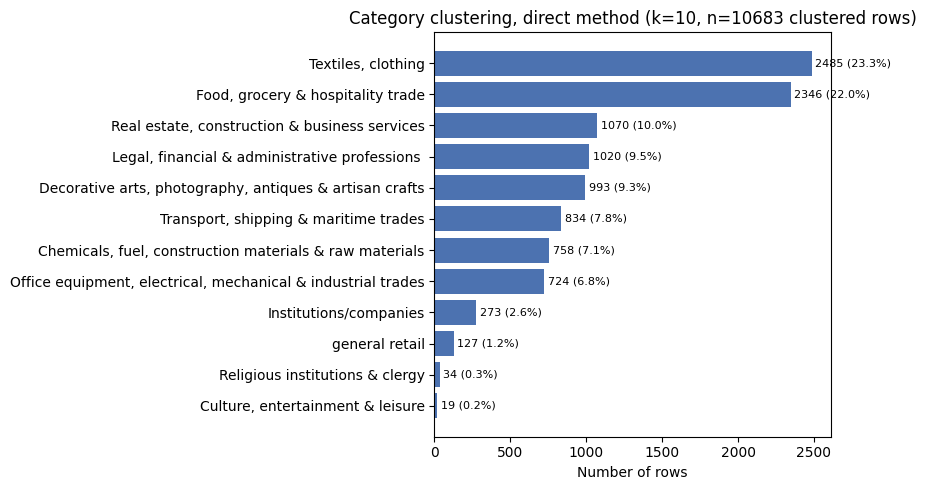

Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_distribution_direct_k10_20260824_161514.png
Saved figure: stats_geo_analysis/category_distribution_direct_k10.png
                                                    Category  Rows  % of categorized
                                          Textiles, clothing  2485              23.3
                           Food, grocery & hospitality trade  2346              22.0
               Real estate, construction & business services  1070              10.0
              Legal, financial & administrative professions   1020               9.5
     Decorative arts, photography, antiques & artisan crafts   993               9.3
                       Transport, shipping & maritime trades   834               7.8
     Chemicals, fuel, construction materials & raw materials   758               7.1
Office equipment, electrical, mechanical & industrial trades   724               6.8
                                      I

In [96]:
# figures & tables -- k=10 category distribution (direct method)

catdirect_counts_k10 = geo["category_class_k10"].value_counts().sort_values(ascending=True)
has_catdirect = geo["category_class_k10"].notna().sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(catdirect_counts_k10.index, catdirect_counts_k10.values, color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"Category clustering, direct method (k=10, n={has_catdirect} clustered rows)")
for bar, val in zip(bars, catdirect_counts_k10.values):
    ax.text(val + max(catdirect_counts_k10.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{val} ({100*val/has_catdirect:.1f}%)", va="center", fontsize=8)
plt.tight_layout()

fig_path = "category_distribution_direct_k10.png"
plt.savefig(fig_path, dpi=150)
plt.show()

with open(fig_path, "rb") as f:
    upload_to_stats(fig_path, f.read(), "image/png", subfolder="category_clustering")
print(f"Saved figure: stats_geo_analysis/{fig_path}")

# summary table for the thesis
summary_table_catdirect_k10 = pd.DataFrame({
    "Category": catdirect_counts_k10.index[::-1],
    "Rows": catdirect_counts_k10.values[::-1],
    "% of categorized": (100 * catdirect_counts_k10.values[::-1] / has_catdirect).round(1),
})
print(summary_table_catdirect_k10.to_string(index=False))

csv_bytes = summary_table_catdirect_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("category_distribution_table_direct_k10.csv", csv_bytes, "text/csv", subfolder="category_clustering")
print(f"\nSaved: stats_geo_analysis/category_distribution_table_direct_k10.csv")


In [51]:
# category naming changelog -- every default name + override written to a timestamped CSV, run whenever overrides change


_default_names_log = pd.DataFrame([
    {"cluster_id": cid, "default_name": name}
    for cid, name in CLUSTER_DEFAULT_NAMES_CAT.items()
])
_overrides_log = pd.DataFrame([
    {
        "category_value": val,
        "override_name": name,
        "cluster_id": (
            cat_cluster_df.loc[cat_cluster_df["category"] == val, "cluster_id"].iloc[0]
            if (cat_cluster_df["category"] == val).any() else None
        ),
        "default_name_would_have_been": (
            CLUSTER_DEFAULT_NAMES_CAT.get(
                cat_cluster_df.loc[cat_cluster_df["category"] == val, "cluster_id"].iloc[0]
            ) if (cat_cluster_df["category"] == val).any() else None
        ),
    }
    for val, name in VALUE_OVERRIDES_CAT.items()
])

print(f"Cluster default names : {len(_default_names_log)}")
print(f"Value-level overrides : {len(_overrides_log)}")

_default_bytes = _default_names_log.to_csv(index=False).encode("utf-8")
upload_to_stats("category_cluster_default_names.csv", _default_bytes, "text/csv", subfolder="category_clustering")

_overrides_bytes = _overrides_log.to_csv(index=False).encode("utf-8")
upload_to_stats("category_value_overrides.csv", _overrides_bytes, "text/csv", subfolder="category_clustering")

print("\nThese two files are the citable record of every manual naming/correction "
      "decision made for the Category k=10 classification -- cite the row counts "
      "from here directly, rather than counting VALUE_OVERRIDES_CAT by hand.")

# final categorization -- full review, every value grouped under its final class name

print(f"\n{'='*70}")
print("FINAL CATEGORIZATION — CONTENTS BY CLASS")
print(f"{'='*70}")
for _cls in sorted(cat_cluster_df["category_name"].dropna().unique()):
    _sub = cat_cluster_df[cat_cluster_df["category_name"] == _cls].sort_values("frequency", ascending=False)
    print(f"\n--- {_cls}  (total rows: {int(_sub['frequency'].sum())}, unique values: {len(_sub)}) ---")
    print(_sub[["category", "frequency"]].to_string(index=False))

_excluded_final = cat_cluster_df[cat_cluster_df["category_name"].isna()].sort_values("frequency", ascending=False)
print(f"\n--- EXCLUDED (no category_name -- contamination/address fragments)  "
      f"(total rows: {int(_excluded_final['frequency'].sum())}, unique values: {len(_excluded_final)}) ---")
print(_excluded_final[["category", "frequency"]].to_string(index=False))

Cluster default names : 10
Value-level overrides : 589
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_cluster_default_names_20260824_161514.csv
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_value_overrides_20260824_161514.csv

These two files are the citable record of every manual naming/correction decision made for the Category k=10 classification -- cite the row counts from here directly, rather than counting VALUE_OVERRIDES_CAT by hand.

FINAL CATEGORIZATION — CONTENTS BY CLASS

--- Chemicals, fuel, construction materials & raw materials  (total rows: 758, unique values: 266) ---
                                                                                                                    category  frequency
                                                                                                                  Refrettari         64
                                                                   

In [52]:
# tokenisation of labels -- LLM canonicalization (category)
CHAT_MODEL_CAT = "gpt-4o-mini"
CANONICALIZE_BATCH_SIZE = 25
CANONICALIZE_MAX_RETRIES = 5

CANONICALIZE_PROMPT_HEADER = (
    "You are helping classify entries from a 1947 Venetian commercial almanac. "
    "For each numbered term below (a business trade/category label, sometimes OCR-corrupted "
    "or an advertising slogan rather than a real category), output a SHORT canonical label "
    "(2-4 words, Italian or English, whichever is clearer) naming the general trade, "
    "profession, or institution type it represents -- e.g. 'tailor', 'grocer', "
    "'religious institution/clergy', 'shipping company', 'construction trade', "
    "'medical profession', 'government/civic institution', 'legal profession'. "
    "If the entry is clearly self-promotional advertising text rather than a real category, "
    "output exactly: ADVERTISEMENT. "
    "If the entry is unreadable OCR noise with no discernible meaning, output exactly: GARBAGE. "
    "Reply with ONLY a numbered list matching the input numbering, one label per line, "
    "no other text.\n\n"
)

_NUMBERED_LINE_RE = re.compile(r"^\d+[\.\)]\s*(.+)$")

def canonicalize_batch_with_retry(batch, max_retries=CANONICALIZE_MAX_RETRIES):
    numbered_input = "\n".join(f"{i+1}. {v}" for i, v in enumerate(batch))
    prompt = CANONICALIZE_PROMPT_HEADER + numbered_input
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=CHAT_MODEL_CAT,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
            )
            raw = resp.choices[0].message.content.strip()
            lines = [l.strip() for l in raw.splitlines() if l.strip()]
            labels = []
            for line in lines:
                m = _NUMBERED_LINE_RE.match(line)
                labels.append(m.group(1).strip() if m else line)
            if len(labels) != len(batch):
                raise ValueError(f"Expected {len(batch)} labels, got {len(labels)}: {labels}")
            return labels
        except Exception as e:
            wait = 2 ** attempt
            print(f"    Error (attempt {attempt+1}/{max_retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"Failed after {max_retries} retries on batch starting with: {batch[0]!r}")

print(f"{len(cat_unique_values)} unique Category values to canonicalize "
      f"(covering {cat_value_counts.sum()} total rows).")

# cache: skip the LLM if this exact value list was already canonicalized
_cat_canon_cache = STATS_LOCAL_DIR / "reference" / "category" / "category_canonical_label_map.csv"
_canon_cached_valid = False
if _cat_canon_cache.exists():
    _cached_map_df = pd.read_csv(_cat_canon_cache)
    if _cached_map_df["category"].tolist() == cat_unique_values:
        _map_df_cat = _cached_map_df
        canonical_labels_cat = _map_df_cat["canonical_label"].tolist()
        _canon_cached_valid = True
        print(f"Loaded {len(_map_df_cat)} cached canonical labels from {_cat_canon_cache.name} "
              f"(values match exactly) -- no API calls made.")
    else:
        print(f"Cache at {_cat_canon_cache.name} doesn't match the current {len(cat_unique_values)} "
              f"unique values -- recomputing.")

if not _canon_cached_valid:
    canonical_labels_cat = []
    for i in range(0, len(cat_unique_values), CANONICALIZE_BATCH_SIZE):
        batch = cat_unique_values[i:i + CANONICALIZE_BATCH_SIZE]
        batch_labels = canonicalize_batch_with_retry(batch)
        canonical_labels_cat.extend(batch_labels)
        print(f"  Canonicalized {min(i + CANONICALIZE_BATCH_SIZE, len(cat_unique_values))}/{len(cat_unique_values)}")

    _map_df_cat = pd.DataFrame({
        "category": cat_unique_values,
        "frequency": cat_value_counts.values,
        "canonical_label": canonical_labels_cat,
    })
    _map_df_cat.to_csv(_cat_canon_cache, index=False)

canonical_label_map_cat = dict(zip(cat_unique_values, canonical_labels_cat))
csv_bytes = _map_df_cat.to_csv(index=False).encode("utf-8")
upload_to_stats("category_canonical_label_map.csv", csv_bytes, "text/csv", subfolder="category_clustering")

n_garbage_canon = int((_map_df_cat["canonical_label"] == "GARBAGE").sum())
n_ad_canon = int((_map_df_cat["canonical_label"] == "ADVERTISEMENT").sum())
print(f"\n{n_garbage_canon} values labeled GARBAGE, {n_ad_canon} labeled ADVERTISEMENT "
      f"(both excluded from the next clustering step).")
print(f"\nSample of canonicalization (first 20):")
print(_map_df_cat.head(20).to_string(index=False))
print(f"\nSaved: stats_geo_analysis/category_canonical_label_map.csv")

2749 unique Category values to canonicalize (covering 11175 total rows).
Loaded 2749 cached canonical labels from category_canonical_label_map.csv (values match exactly) -- no API calls made.
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_canonical_label_map_20260824_161514.csv

341 values labeled GARBAGE, 132 labeled ADVERTISEMENT (both excluded from the next clustering step).

Sample of canonicalization (first 20):
                                          category  frequency              canonical_label
                              Agenzie di trasporto        323             shipping company
                                 Camicerie da uomo        238                 men's shirts
                                         Trattorie        177                   trattorias
                             Macchine per scrivere        144                  typewriters
                                        Alimentari        136                      grocer

In [53]:
# aggregate + embed + cluster + pin -- category tokenised k=10, reference: category_tokenised_clusters_k10_reference.csv
# aggregation always runs ; embedding+clustering skipped if the canonical-label set is unchanged

_map_df_cat["frequency"] = _map_df_cat["frequency"].astype(int)

EXCLUDED_CANON_LABELS = {"GARBAGE", "ADVERTISEMENT"}
_excluded_canon = _map_df_cat[_map_df_cat["canonical_label"].isin(EXCLUDED_CANON_LABELS)]
_kept_canon = _map_df_cat[~_map_df_cat["canonical_label"].isin(EXCLUDED_CANON_LABELS)]

print(f"Excluded (GARBAGE/ADVERTISEMENT): {len(_excluded_canon)} raw values, "
      f"{int(_excluded_canon['frequency'].sum())} rows.")
print(_excluded_canon["canonical_label"].value_counts().to_string())

canon_freq_df = (
    _kept_canon.groupby("canonical_label", as_index=False)["frequency"].sum()
    .sort_values("frequency", ascending=False)
)
print(f"\n{len(canon_freq_df)} distinct canonical labels covering "
      f"{int(canon_freq_df['frequency'].sum())} rows "
      f"(down from {len(cat_unique_values)} raw unique values).")
print(canon_freq_df.head(30).to_string(index=False))

canon_unique_labels = canon_freq_df["canonical_label"].tolist()

REGENERATE_REFERENCE_CANON_CAT = False
REFERENCE_CLUSTER_FILE_CANON_CAT = STATS_LOCAL_DIR / "reference" / "category" / "category_tokenised_clusters_k10_reference.csv"

_need_compute = True
if not REGENERATE_REFERENCE_CANON_CAT and REFERENCE_CLUSTER_FILE_CANON_CAT.exists():
    reference_df_canon_cat = pd.read_csv(REFERENCE_CLUSTER_FILE_CANON_CAT)
    if set(reference_df_canon_cat["canonical_label"]) == set(canon_unique_labels):
        print(f"Label set unchanged ({len(canon_unique_labels)} labels match the reference exactly) "
              f"-- skipping embedding and KMeans, loading the pinned reference directly.")
        canon_cluster_df = reference_df_canon_cat.copy()
        _need_compute = False

if _need_compute:
    _cat_canon_emb_cache = STATS_LOCAL_DIR / "reference" / "category" / "category_canonical_embeddings_cache.npy"
    _cat_canon_emb_values_cache = STATS_LOCAL_DIR / "reference" / "category" / "category_canonical_embeddings_values.csv"
    canon_embeddings = None
    if _cat_canon_emb_cache.exists() and _cat_canon_emb_values_cache.exists():
        _cached_canon_values = pd.read_csv(_cat_canon_emb_values_cache)["value"].tolist()
        if _cached_canon_values == canon_unique_labels:
            canon_embeddings = np.load(_cat_canon_emb_cache)
            print(f"Loaded cached embeddings -> {canon_embeddings.shape}, no API calls made.")
        else:
            print("Cached values don't match current canon_unique_labels -- recomputing.")
    if canon_embeddings is None:
        canon_embeddings = []
        for i in range(0, len(canon_unique_labels), BATCH_SIZE):
            batch = canon_unique_labels[i:i + BATCH_SIZE]
            batch_embeddings = embed_batch_with_retry(batch)
            canon_embeddings.extend(batch_embeddings)
            print(f"  Embedded {min(i + BATCH_SIZE, len(canon_unique_labels))}/{len(canon_unique_labels)}")
        canon_embeddings = np.array(canon_embeddings)
        np.save(_cat_canon_emb_cache, canon_embeddings)
        pd.DataFrame({"value": canon_unique_labels}).to_csv(_cat_canon_emb_values_cache, index=False)
        print(f"Embedding matrix shape: {canon_embeddings.shape}")

    N_CLUSTERS_CANON_CAT = 10
    kmeans_canon_cat = KMeans(n_clusters=N_CLUSTERS_CANON_CAT, random_state=42, n_init=10)
    canon_cluster_labels = kmeans_canon_cat.fit_predict(canon_embeddings)
    canon_cluster_df = pd.DataFrame({
        "canonical_label": canon_unique_labels,
        "frequency": canon_freq_df["frequency"].values,
        "cluster_id": canon_cluster_labels,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    if REGENERATE_REFERENCE_CANON_CAT or not REFERENCE_CLUSTER_FILE_CANON_CAT.exists():
        if REGENERATE_REFERENCE_CANON_CAT:
            print("REGENERATE_REFERENCE_CANON_CAT=True -- overwriting the pinned reference with this run.")
        else:
            print(f"No reference file found at {REFERENCE_CLUSTER_FILE_CANON_CAT.name} -- "
                  f"bootstrapping: this run becomes the permanent reference.")
        reference_df_canon_cat = canon_cluster_df.copy()
        STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        reference_df_canon_cat.to_csv(REFERENCE_CLUSTER_FILE_CANON_CAT, index=False)
        upload_to_stats("category_tokenised_clusters_k10_reference.csv",
                         reference_df_canon_cat.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="category_clustering")
        print(f"Saved reference: {REFERENCE_CLUSTER_FILE_CANON_CAT.name} ({len(reference_df_canon_cat)} rows)")
    else:
        reference_map_canon_cat = dict(zip(reference_df_canon_cat["canonical_label"], reference_df_canon_cat["cluster_id"]))
        current_map_canon_cat = dict(zip(canon_cluster_df["canonical_label"], canon_cluster_df["cluster_id"]))
        mismatches_canon_cat = {
            c: (reference_map_canon_cat.get(c), current_map_canon_cat.get(c))
            for c in set(reference_map_canon_cat) | set(current_map_canon_cat)
            if reference_map_canon_cat.get(c) != current_map_canon_cat.get(c)
        }
        print(f"{'='*70}")
        print(f"MISMATCH -- {len(mismatches_canon_cat)} of "
              f"{len(set(reference_map_canon_cat) | set(current_map_canon_cat))} label(s) differ from the reference.")
        print("canon_cluster_df is being reset to the pinned reference. "
              "Set REGENERATE_REFERENCE_CANON_CAT=True above to replace it instead.")
        print(f"{'='*70}\n")

    canon_cluster_df = reference_df_canon_cat.copy()

print(f"canon_cluster_df is now pinned ({len(canon_cluster_df)} rows, "
      f"{canon_cluster_df['cluster_id'].nunique()} clusters).")


Excluded (GARBAGE/ADVERTISEMENT): 473 raw values, 1019 rows.
canonical_label
GARBAGE          341
ADVERTISEMENT    132

1543 distinct canonical labels covering 10156 rows (down from 2749 raw unique values).
             canonical_label  frequency
            shipping company        364
                men's shirts        238
                  trattorias        177
                     grocery        166
                 typewriters        144
          construction trade        127
                     butcher        118
                         bar        113
religious institution/clergy        112
              men's clothing        105
                   trattoria        101
        Venetian specialties         98
          medical profession         97
                      Lawyer         86
                        café         85
                     dairies         84
            office furniture         80
                      tailor         80
                      tavern     

In [54]:
# apply tokenised category names (k=10)
# names checked against real cluster content so words aren't repeated across categories

TOKEN_CLUSTER_DEFAULT_NAMES = {
    0: "Food & beverages",
    1: "Transport, shipping & maritime trades",
    2: "Electrical, mechanical, industrial & automotive trades",
    3: "Construction, carpentry, chemicals, fuel & raw materials",
    4: "Decorative arts, antiques & artisan crafts",
    5: "Wholesale, agricultural & general commerce trades",
    6: None,  # split below into professions vs institutions
    7: "Office equipment, stationery, printing, publishing & photography",
    8: "Hospitality, dining & retail shops",
    9: "Textiles, clothing, footwear, haberdashery & perfumery",
}

RELIGIOUS_CAT_NAME_TOKEN = "Religious institutions & clergy"
PROFESSIONS_CAT_NAME_TOKEN = "Legal, financial & administrative professions"
INSTITUTIONS_CAT_NAME_TOKEN = "Institutions & companies"

TOKEN_VALUE_OVERRIDES = {
    "Garbage": None,
}
TOKEN_TO_EXCLUDED_AD = ["typewriters", "typewriters and calculators", "Typewriters"]
for _val in TOKEN_TO_EXCLUDED_AD:
    TOKEN_VALUE_OVERRIDES[_val] = None

# liquid/gas fuel + industrial oil, moved out of cluster 0 into cluster 3 with the solid fuel
TOKEN_TO_FUEL_CLUSTER3 = [
    "mineral oils", "lubricants", "Liquid fuels", "fuel oils", "Natural gas",
    "tar", "fuels", "fuels and oils", "bitumen", "Petroleum products",
    "liquid fuels", "Gas", "solid and liquid fuels", "Fossil fuels",
    "Gasoline", "petroleum products", "petroleum",
    "Oil", "Oils", "oils", "Toxic Gases", "Paraffin",
]
for _val in TOKEN_TO_FUEL_CLUSTER3:
    TOKEN_VALUE_OVERRIDES[_val] = TOKEN_CLUSTER_DEFAULT_NAMES[3]

# chemicals out of cluster 0 into cluster 3
TOKEN_TO_CHEM_CLUSTER3 = ["chemical products", "Chemical representative", "Chemical products"]
for _val in TOKEN_TO_CHEM_CLUSTER3:
    TOKEN_VALUE_OVERRIDES[_val] = TOKEN_CLUSTER_DEFAULT_NAMES[3]

# perfumery out of cluster 0 into cluster 9
TOKEN_TO_PERFUME_CLUSTER9 = ["perfumery", "Perfumery", "Perfumes", "perfume representative", "Perfume"]
for _val in TOKEN_TO_PERFUME_CLUSTER9:
    TOKEN_VALUE_OVERRIDES[_val] = TOKEN_CLUSTER_DEFAULT_NAMES[9]

# barbers/hairdressers/beauty out of food/hospitality, into textiles with the other personal-care/haberdashery items
TOKEN_TO_TEXTILES = [
    "barber", "barbers", "Hairdressers", "Women's hairdresser", "hairdresser",
    "women's hairdresser", "Beauty institutes", "beauty salon", "Mercerie",
]
for _val in TOKEN_TO_TEXTILES:
    TOKEN_VALUE_OVERRIDES[_val] = TOKEN_CLUSTER_DEFAULT_NAMES[9]

# religious content out of cluster 6, own category (rector/Rector left in cluster 6, ambiguous academic/religious)
TOKEN_TO_RELIGIOUS = [
    "religious institution/clergy", "Religious institution/clergy",
    "clergy", "Clergy", "religious institution", "Religious institution",
    "Religious Institution", "vicar", "parish priest",
]
for _val in TOKEN_TO_RELIGIOUS:
    TOKEN_VALUE_OVERRIDES[_val] = RELIGIOUS_CAT_NAME_TOKEN

# cluster 6 conflates two things the direct method kept separate -- split by content
TOKEN_TO_INSTITUTIONS = [
    'government/civic institution', 'insurance', 'Real estate companies', 'Insurance company',
    'Credit institutions', 'bank', 'Boarding houses', 'hotel', 'company', 'Boarding house',
    'Government Institution', 'Bank', 'institutions', 'Government/civic institution',
    'agencies and businesses', 'government office', 'Business', 'government institution',
    'cooperative', 'real estate company', 'Government/Civic Institution', 'Civil and criminal court',
    'university', 'banking institution', 'advertising agency', 'Hotel', 'University',
    'Educational institution', 'Educational Institution', 'medical institution', 'banking',
    'Government', 'Typing schools', 'labor association', 'educational institution',
    'Business agency', 'Urban district', 'Military district', 'Company', 'Corporation',
    'Court of Mestre', 'association', 'University Institution', 'Commercial agency',
    'Automobile Club', 'Offices', 'Police', 'Provincial Government', 'Museum', 'Pawn Agency',
    'Water authority', 'Theatre Administration', 'Real Estate Company', 'Laboratory', 'civic club',
    'charitable institution', 'driving school', 'customs office', 'customs laboratory',
    'cultural association', 'Library', 'foreign office', 'Investigation agency',
    'industrial association', 'hotel management', 'hospital', 'Investigation Agency',
    'labor organization', 'school', 'provincial administration', 'property owners association',
    'real estate agency', 'railway police', 'mining company', 'veterans association',
    'social institution', 'national interest bank', 'warehouse office', 'prefecture office',
    'insurance company', 'university library', 'Insurance association', 'Insurance Agency',
    'Medical institution', 'Medical Institution', 'Hotel management', 'Hotel Management',
    'Government Services', 'Government Agency', 'lottery office', 'government/military institution',
    'university institution', 'typing school', 'sports club', 'sports association',
    'government inspection', 'Architecture Institute', 'Telephone Directory', 'tax inspectorate',
    'real estate', 'Real estate', 'Real Estate', 'Labor',
    'Nursing homes', 'nursing home', 'Pharmacy', 'pharmacy', 'inn',
    'Public Housing Institute', 'Public works', 'Occupational safety institute',
    'Water Magistrate', 'gaming houses', 'investment services', 'Entertainment industry',
    'physical culture institute', 'Educational Shows', 'assistance', 'education', 'Education',
    'civil service', 'Military command', 'military command', 'Urban sanitation',
    'Investigation services', 'Pest control',
]
for _val in TOKEN_TO_INSTITUTIONS:
    TOKEN_VALUE_OVERRIDES[_val] = INSTITUTIONS_CAT_NAME_TOKEN

TOKEN_TO_PROFESSIONS = [
    'medical profession', 'Lawyer', 'Pharmacist', 'Surveyor', 'legal profession', 'midwifery',
    'architect', 'accountant', 'Sales representative', 'Accountant', 'expert', 'dentist', 'broker',
    'Notary', 'Medical profession', 'Midwifery', 'Architect', 'Medical Profession', 'secretary',
    'Representative', 'Teacher', 'Director', 'Expert', 'Inspector', 'judge', 'surveyor',
    'academic profession', 'surgeon', 'veterinary', 'shoe representative', 'general practitioner',
    'dental profession', 'pharmacist', 'Legal Profession', 'representatives', 'chemical profession',
    'actress', 'Actuary', 'Architecture Professor', 'Coal Representatives', 'Dentist', 'Detective',
    'Ear, nose, throat specialist', 'Accounting inspector', 'dermatologist', 'Surgeon',
    'civil engineer', 'educator', 'designer', 'commercial director', 'sales representative',
    'service manager', 'midwife', 'veterinary profession', 'industrial representative',
    'specialist', 'Home Goods Representative', 'representative', 'pediatrician',
    'Municipal councilor', 'Government Position', 'Bank Position', 'Vice Commissioner',
    'administrative officer', 'University Secretary', 'Director of Police Station',
    'banking director', 'national bank secretary', 'Insurance Representative', 'government inspector',
    'mediators', 'Chimney sweeps', 'President', 'military rank', 'accounting', 'Oculista', 'optician',
    'rector', 'Rector', 'Counselor', 'animal care', 'archivist', 'Dealer', 'Civic advisor',
    'Decorator', 'decorator', 'Pilots', 'pilots', 'Pharmaceutical Representation', 'divers',
    'legal sponsor', 'executive', 'watchmaker', 'Firefighter', 'usher', 'Shepherd',
    'General medicine', 'general medicine', 'Medicine',
]
for _val in TOKEN_TO_PROFESSIONS:
    TOKEN_VALUE_OVERRIDES[_val] = PROFESSIONS_CAT_NAME_TOKEN

# leftover fragments in cluster 6, not real business categories
TOKEN_TO_EXCLUDED_C6 = ['Neighborhood', 'radio', 'Castle', 'bridge', 'historical site', 'horse racing',
                        'hunting', 'military service', 'location', 'of Venice', 'general representation']
for _val in TOKEN_TO_EXCLUDED_C6:
    TOKEN_VALUE_OVERRIDES[_val] = None

# a mercer is a textiles/haberdashery trader, same as Mercerie
TOKEN_VALUE_OVERRIDES['Mercer'] = TOKEN_CLUSTER_DEFAULT_NAMES[9]

# stray retail items misplaced in the food/hospitality cluster
TOKEN_VALUE_OVERRIDES["hardware store"]      = TOKEN_CLUSTER_DEFAULT_NAMES[2]
TOKEN_VALUE_OVERRIDES["paint store"]         = TOKEN_CLUSTER_DEFAULT_NAMES[3]
TOKEN_VALUE_OVERRIDES["jewelry store"]       = TOKEN_CLUSTER_DEFAULT_NAMES[4]
TOKEN_VALUE_OVERRIDES["furniture store"]     = TOKEN_CLUSTER_DEFAULT_NAMES[3]
TOKEN_VALUE_OVERRIDES["furniture (stores)"]  = TOKEN_CLUSTER_DEFAULT_NAMES[3]

TOKEN_MANUAL_MOVES = (
    TOKEN_TO_EXCLUDED_AD + TOKEN_TO_FUEL_CLUSTER3 + TOKEN_TO_CHEM_CLUSTER3 + TOKEN_TO_PERFUME_CLUSTER9
    + TOKEN_TO_TEXTILES + TOKEN_TO_RELIGIOUS + TOKEN_TO_INSTITUTIONS + TOKEN_TO_PROFESSIONS
    + TOKEN_TO_EXCLUDED_C6 + ['Mercer']
    + ["hardware store", "paint store", "jewelry store", "furniture store", "furniture (stores)"]
)

canon_cluster_df["category_name"] = canon_cluster_df.apply(
    lambda row: TOKEN_VALUE_OVERRIDES.get(row["canonical_label"], TOKEN_CLUSTER_DEFAULT_NAMES[row["cluster_id"]]),
    axis=1
)

n_matched_token = sum(1 for c in canon_cluster_df["canonical_label"] if c in TOKEN_VALUE_OVERRIDES)
n_excluded_token = canon_cluster_df["category_name"].isna().sum()
excluded_rows_token = canon_cluster_df.loc[canon_cluster_df["category_name"].isna(), "frequency"].sum()

print("cluster default names:", len(TOKEN_CLUSTER_DEFAULT_NAMES))
print("value overrides defined:", len(TOKEN_VALUE_OVERRIDES))
print("value overrides matched:", n_matched_token, "of", len(TOKEN_VALUE_OVERRIDES))

_moved_token = canon_cluster_df[canon_cluster_df["canonical_label"].isin(TOKEN_MANUAL_MOVES)]
for _dest in sorted(set(TOKEN_VALUE_OVERRIDES[v] for v in TOKEN_MANUAL_MOVES if v in TOKEN_VALUE_OVERRIDES and TOKEN_VALUE_OVERRIDES[v] is not None)):
    _sub = _moved_token[_moved_token["canonical_label"].map(TOKEN_VALUE_OVERRIDES) == _dest]
    print(_dest, "-", len(_sub), "labels,", int(_sub["frequency"].sum()), "rows")

print("labels excluded:", n_excluded_token, "-", excluded_rows_token, "rows")

csv_bytes = canon_cluster_df.to_csv(index=False).encode("utf-8")
upload_to_stats("category_tokenised_clusters_k10_corrected.csv", csv_bytes, "text/csv", subfolder="category_clustering")

canon_label_lookup = dict(zip(canon_cluster_df["canonical_label"], canon_cluster_df["category_name"]))
raw_to_canon = dict(zip(_map_df_cat["category"], _map_df_cat["canonical_label"]))
geo["category_class_tokenised"] = geo["Category"].map(raw_to_canon).map(canon_label_lookup)

total_rows_token = len(geo)
has_class_token = geo["category_class_tokenised"].notna().sum()
print("total rows:", total_rows_token)
print("classified:", has_class_token, f"({100*has_class_token/total_rows_token:.1f}%)")

token_class_counts = geo["category_class_tokenised"].value_counts()
for cls, count in token_class_counts.items():
    print(cls, count, f"{100*count/has_class_token:.1f}%")

stats_bytes = token_class_counts.reset_index().rename(
    columns={"index": "category_class", "category_class_tokenised": "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("category_class_stats_tokenised_k10.csv", stats_bytes, "text/csv", subfolder="category_clustering")


cluster default names: 10
value overrides defined: 294
value overrides matched: 288 of 294
Construction, carpentry, chemicals, fuel & raw materials - 28 labels, 215 rows
Decorative arts, antiques & artisan crafts - 1 labels, 44 rows
Electrical, mechanical, industrial & automotive trades - 1 labels, 58 rows
Institutions & companies - 121 labels, 620 rows
Legal, financial & administrative professions - 99 labels, 565 rows
Religious institutions & clergy - 9 labels, 153 rows
Textiles, clothing, footwear, haberdashery & perfumery - 15 labels, 251 rows
labels excluded: 15 - 245 rows
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_tokenised_clusters_k10_corrected_20260824_161514.csv
total rows: 16469
classified: 9911 (60.2%)
Textiles, clothing, footwear, haberdashery & perfumery 1611 16.3%
Hospitality, dining & retail shops 1423 14.4%
Food & beverages 1069 10.8%
Construction, carpentry, chemicals, fuel & raw materials 1064 10.7%
Wholesale, agricultural & gen

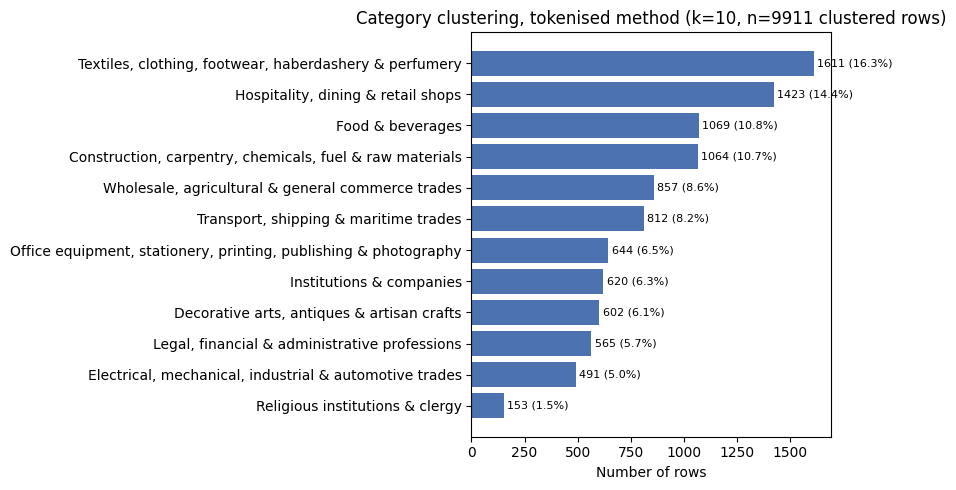

Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_distribution_tokenised_k10_20260824_161514.png
Saved figure: stats_geo_analysis/category_distribution_tokenised_k10.png
                                                        Category  Rows  % of categorized
          Textiles, clothing, footwear, haberdashery & perfumery  1611              16.3
                              Hospitality, dining & retail shops  1423              14.4
                                                Food & beverages  1069              10.8
        Construction, carpentry, chemicals, fuel & raw materials  1064              10.7
               Wholesale, agricultural & general commerce trades   857               8.6
                           Transport, shipping & maritime trades   812               8.2
Office equipment, stationery, printing, publishing & photography   644               6.5
                                        Institutions & companies   620               6

In [98]:
# figures & tables -- k=10 category distribution (tokenised method)

cattoken_counts_k10 = geo["category_class_tokenised"].value_counts().sort_values(ascending=True)
has_cattoken = geo["category_class_tokenised"].notna().sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(cattoken_counts_k10.index, cattoken_counts_k10.values, color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"Category clustering, tokenised method (k=10, n={has_cattoken} clustered rows)")
for bar, val in zip(bars, cattoken_counts_k10.values):
    ax.text(val + max(cattoken_counts_k10.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{val} ({100*val/has_cattoken:.1f}%)", va="center", fontsize=8)
plt.tight_layout()

fig_path = "category_distribution_tokenised_k10.png"
plt.savefig(fig_path, dpi=150)
plt.show()

with open(fig_path, "rb") as f:
    upload_to_stats(fig_path, f.read(), "image/png", subfolder="category_clustering")
print(f"Saved figure: stats_geo_analysis/{fig_path}")

# summary table for the thesis
summary_table_cattoken_k10 = pd.DataFrame({
    "Category": cattoken_counts_k10.index[::-1],
    "Rows": cattoken_counts_k10.values[::-1],
    "% of categorized": (100 * cattoken_counts_k10.values[::-1] / has_cattoken).round(1),
})
print(summary_table_cattoken_k10.to_string(index=False))

csv_bytes = summary_table_cattoken_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("category_distribution_table_tokenised_k10.csv", csv_bytes, "text/csv", subfolder="category_clustering")
print(f"\nSaved: stats_geo_analysis/category_distribution_table_tokenised_k10.csv")


10683 classified out of 16469 total (64.9%)
category_class_k10
Textiles, clothing                                              2485
Food, grocery & hospitality trade                               2346
Real estate, construction & business services                   1070
Legal, financial & administrative professions                   1020
Decorative arts, photography, antiques & artisan crafts          993
Transport, shipping & maritime trades                            834
Chemicals, fuel, construction materials & raw materials          758
Office equipment, electrical, mechanical & industrial trades     724
Institutions/companies                                           273
general retail                                                   127
Religious institutions & clergy                                   34
Culture, entertainment & leisure                                  19
Most spatially spread class: 'Culture, entertainment & leisure' (spacing=209.6m) -> gridsize=20


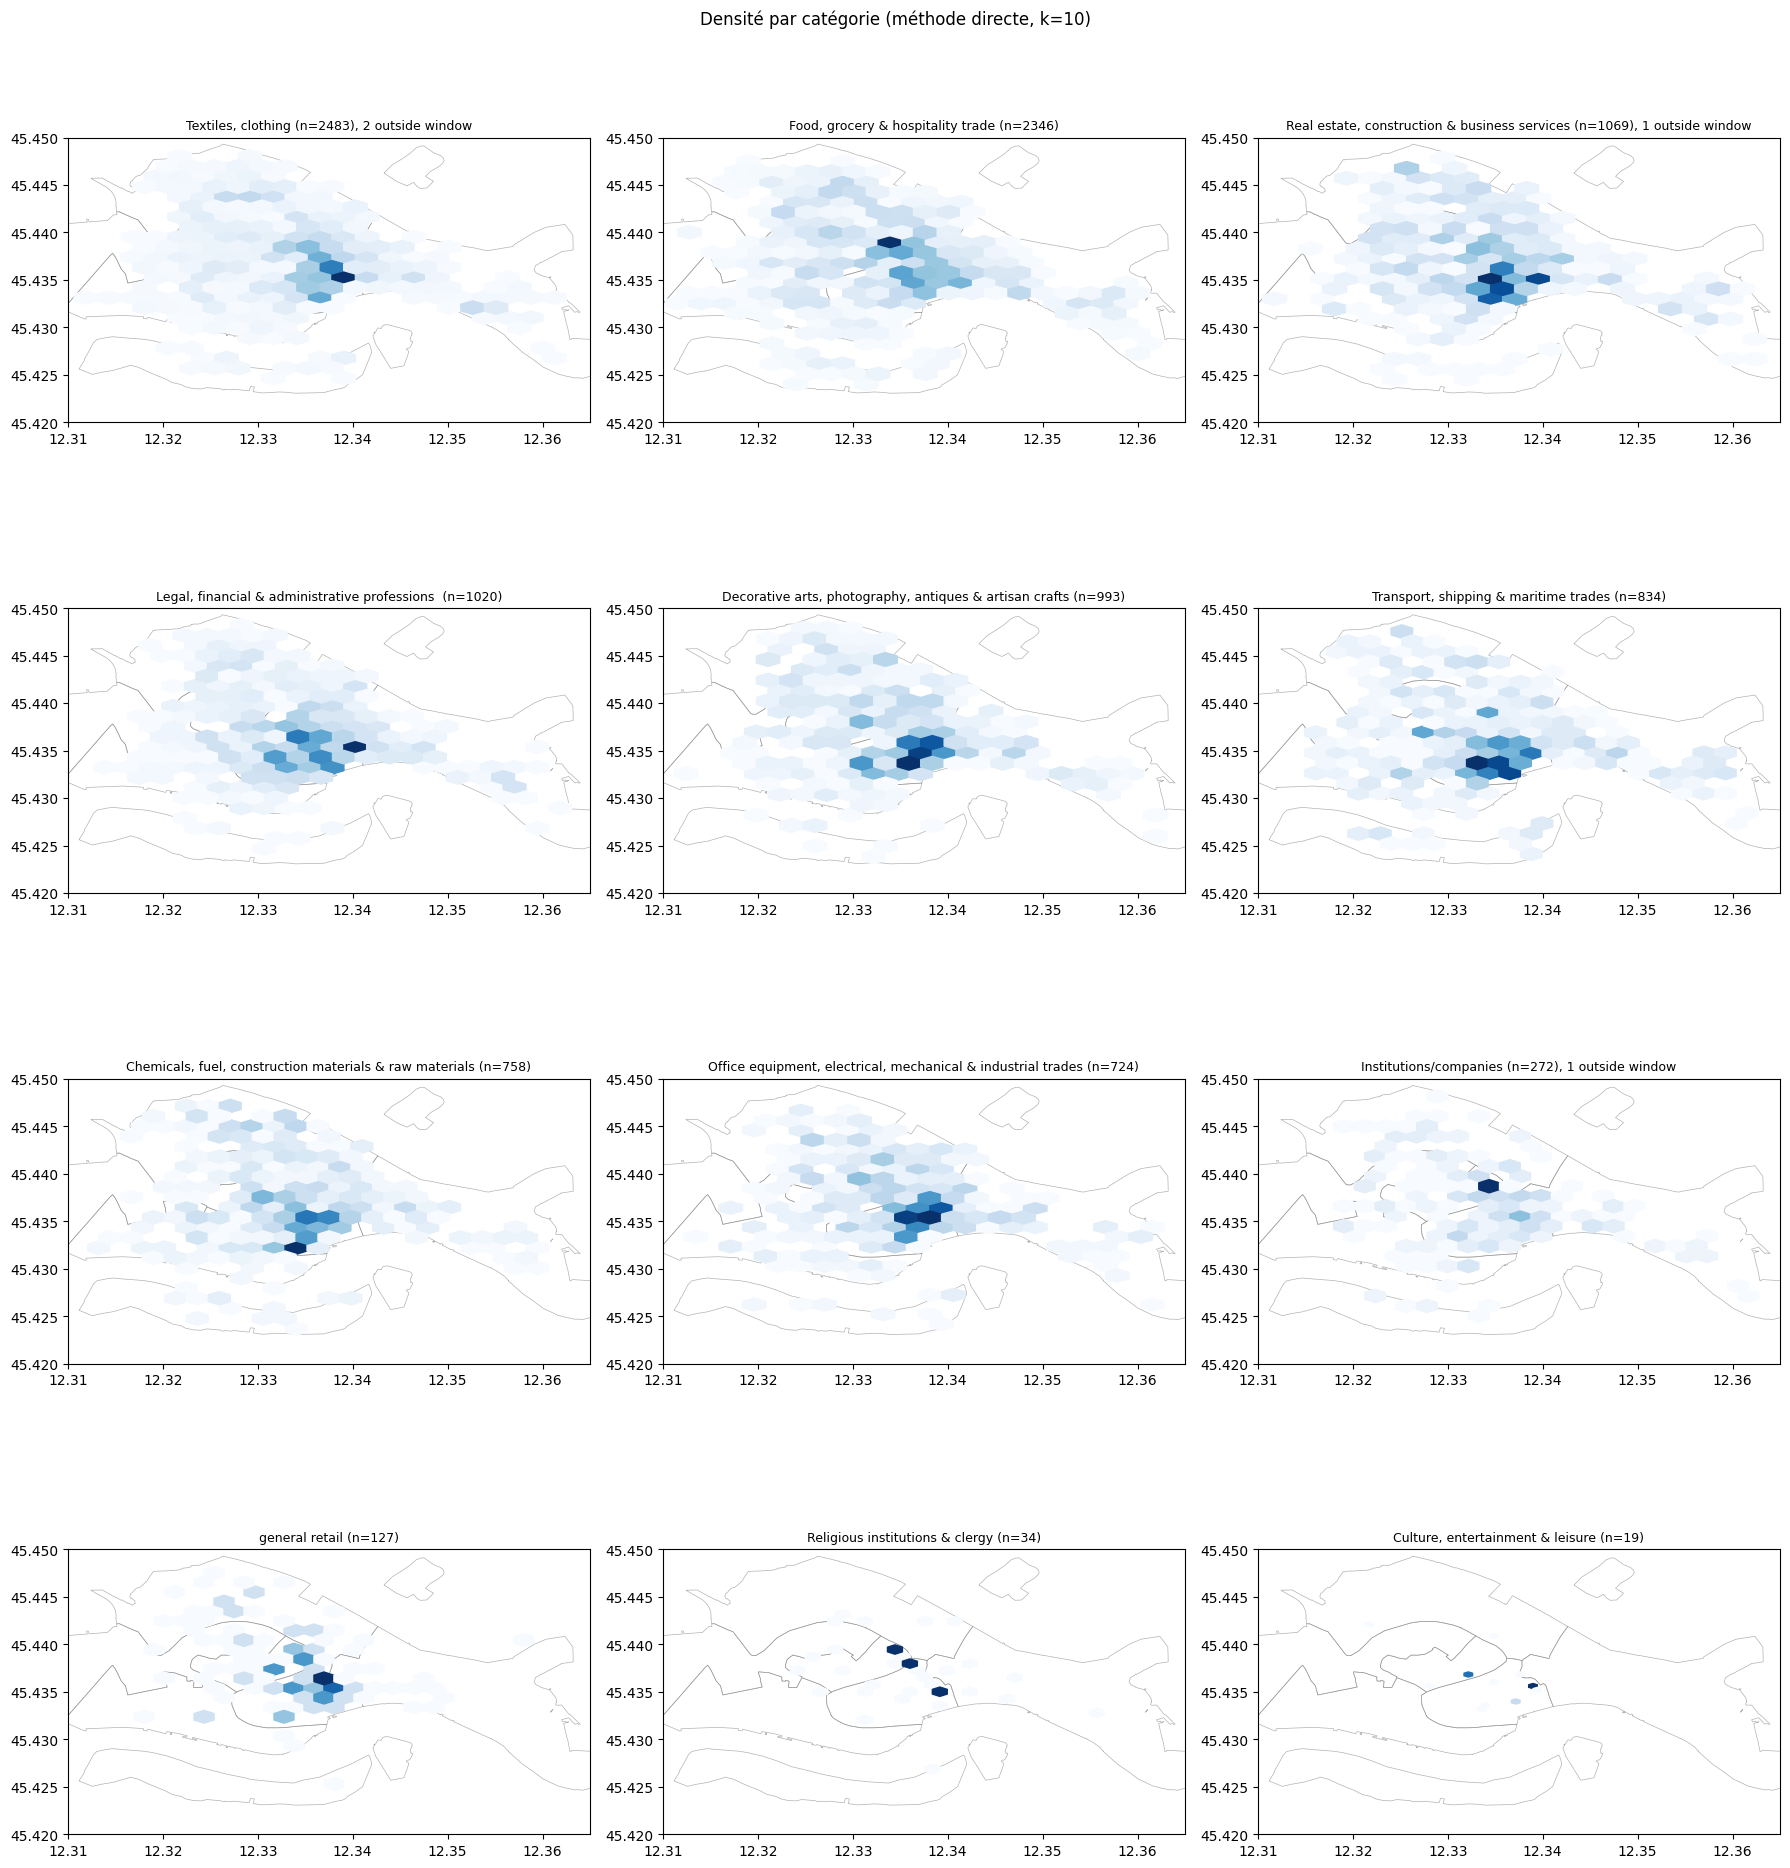

Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: heatmap_category_class_direct_k10_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_class_direct_k10_coverage_20260824_161514.csv


In [56]:
# density heatmaps by category (k=10) -- direct method, same shared-window + sparsest-category gridsize as occupation

col = "category_class_k10"
geo_direct = geo[geo[col].notna()].copy()
print(f"{len(geo_direct)} classified out of {len(geo)} total ({100*len(geo_direct)/len(geo):.1f}%)")

class_counts_direct = geo_direct[col].value_counts()
print(class_counts_direct.to_string())

lon_min, lon_max = HEATMAP_LON_MIN, HEATMAP_LON_MAX
lat_min, lat_max = HEATMAP_LAT_MIN, HEATMAP_LAT_MAX

def _median_nn_spacing_m_c(pts):
    lat0 = pts["matched_lat"].mean()
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat0))
    xy = np.column_stack([
        pts["matched_lon"].to_numpy() * m_per_deg_lon,
        pts["matched_lat"].to_numpy() * m_per_deg_lat,
    ])
    tree = cKDTree(xy)
    nn_dist, _ = tree.query(xy, k=2)
    return float(np.median(nn_dist[:, 1]))

_class_spacings_c = {}
for _cls in class_counts_direct.index:
    _sub_cls = geo_direct[geo_direct[col] == _cls]
    _pts_cls = _sub_cls[
        _sub_cls["matched_lon"].between(lon_min, lon_max) & _sub_cls["matched_lat"].between(lat_min, lat_max)
    ].drop_duplicates(subset=["matched_lat", "matched_lon"])
    if len(_pts_cls) >= 2:
        _class_spacings_c[_cls] = _median_nn_spacing_m_c(_pts_cls)

_sparsest_cls_c = max(_class_spacings_c, key=_class_spacings_c.get)
target_hex_width_m_c = _class_spacings_c[_sparsest_cls_c]
_m_per_deg_lon_c = 111_320 * math.cos(math.radians(geo_direct["matched_lat"].mean()))
_extent_m_c = (lon_max - lon_min) * _m_per_deg_lon_c
GRIDSIZE_CAT_DIRECT_PANEL = int(round(_extent_m_c / target_hex_width_m_c))
print(f"Most spatially spread class: {_sparsest_cls_c!r} (spacing={target_hex_width_m_c:.1f}m) -> gridsize={GRIDSIZE_CAT_DIRECT_PANEL}")

classes = class_counts_direct.index.tolist()
n_cols = 3
n_rows = -(-len(classes) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sub = geo_direct[geo_direct[col] == cls]
    in_window = sub[sub["matched_lon"].between(lon_min, lon_max) & sub["matched_lat"].between(lat_min, lat_max)]
    n_dropped = len(sub) - len(in_window)
    sestieri.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.6, zorder=0)
    ax.hexbin(in_window["matched_lon"], in_window["matched_lat"], gridsize=GRIDSIZE_CAT_DIRECT_PANEL, cmap="Blues", mincnt=1, zorder=1)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect("equal")
    title = f"{cls} (n={len(in_window)})"
    if n_dropped:
        title += f", {n_dropped} outside window"
    ax.set_title(title, fontsize=9)

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Densité par catégorie (méthode directe, k=10)")
plt.tight_layout()
out_name = _v("heatmap_category_class_direct_k10.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("heatmap_category_class_direct_k10.png", f.read(), "image/png", subfolder="category_clustering")

csv_bytes = class_counts_direct.reset_index().rename(
    columns={"index": "category_class", col: "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("category_class_direct_k10_coverage.csv", csv_bytes, "text/csv", subfolder="category_clustering")


9911 classified out of 16469 total (60.2%)
category_class_tokenised
Textiles, clothing, footwear, haberdashery & perfumery              1611
Hospitality, dining & retail shops                                  1423
Food & beverages                                                    1069
Construction, carpentry, chemicals, fuel & raw materials            1064
Wholesale, agricultural & general commerce trades                    857
Transport, shipping & maritime trades                                812
Office equipment, stationery, printing, publishing & photography     644
Institutions & companies                                             620
Decorative arts, antiques & artisan crafts                           602
Legal, financial & administrative professions                        565
Electrical, mechanical, industrial & automotive trades               491
Religious institutions & clergy                                      153
Most spatially spread class: 'Religious institutions & c

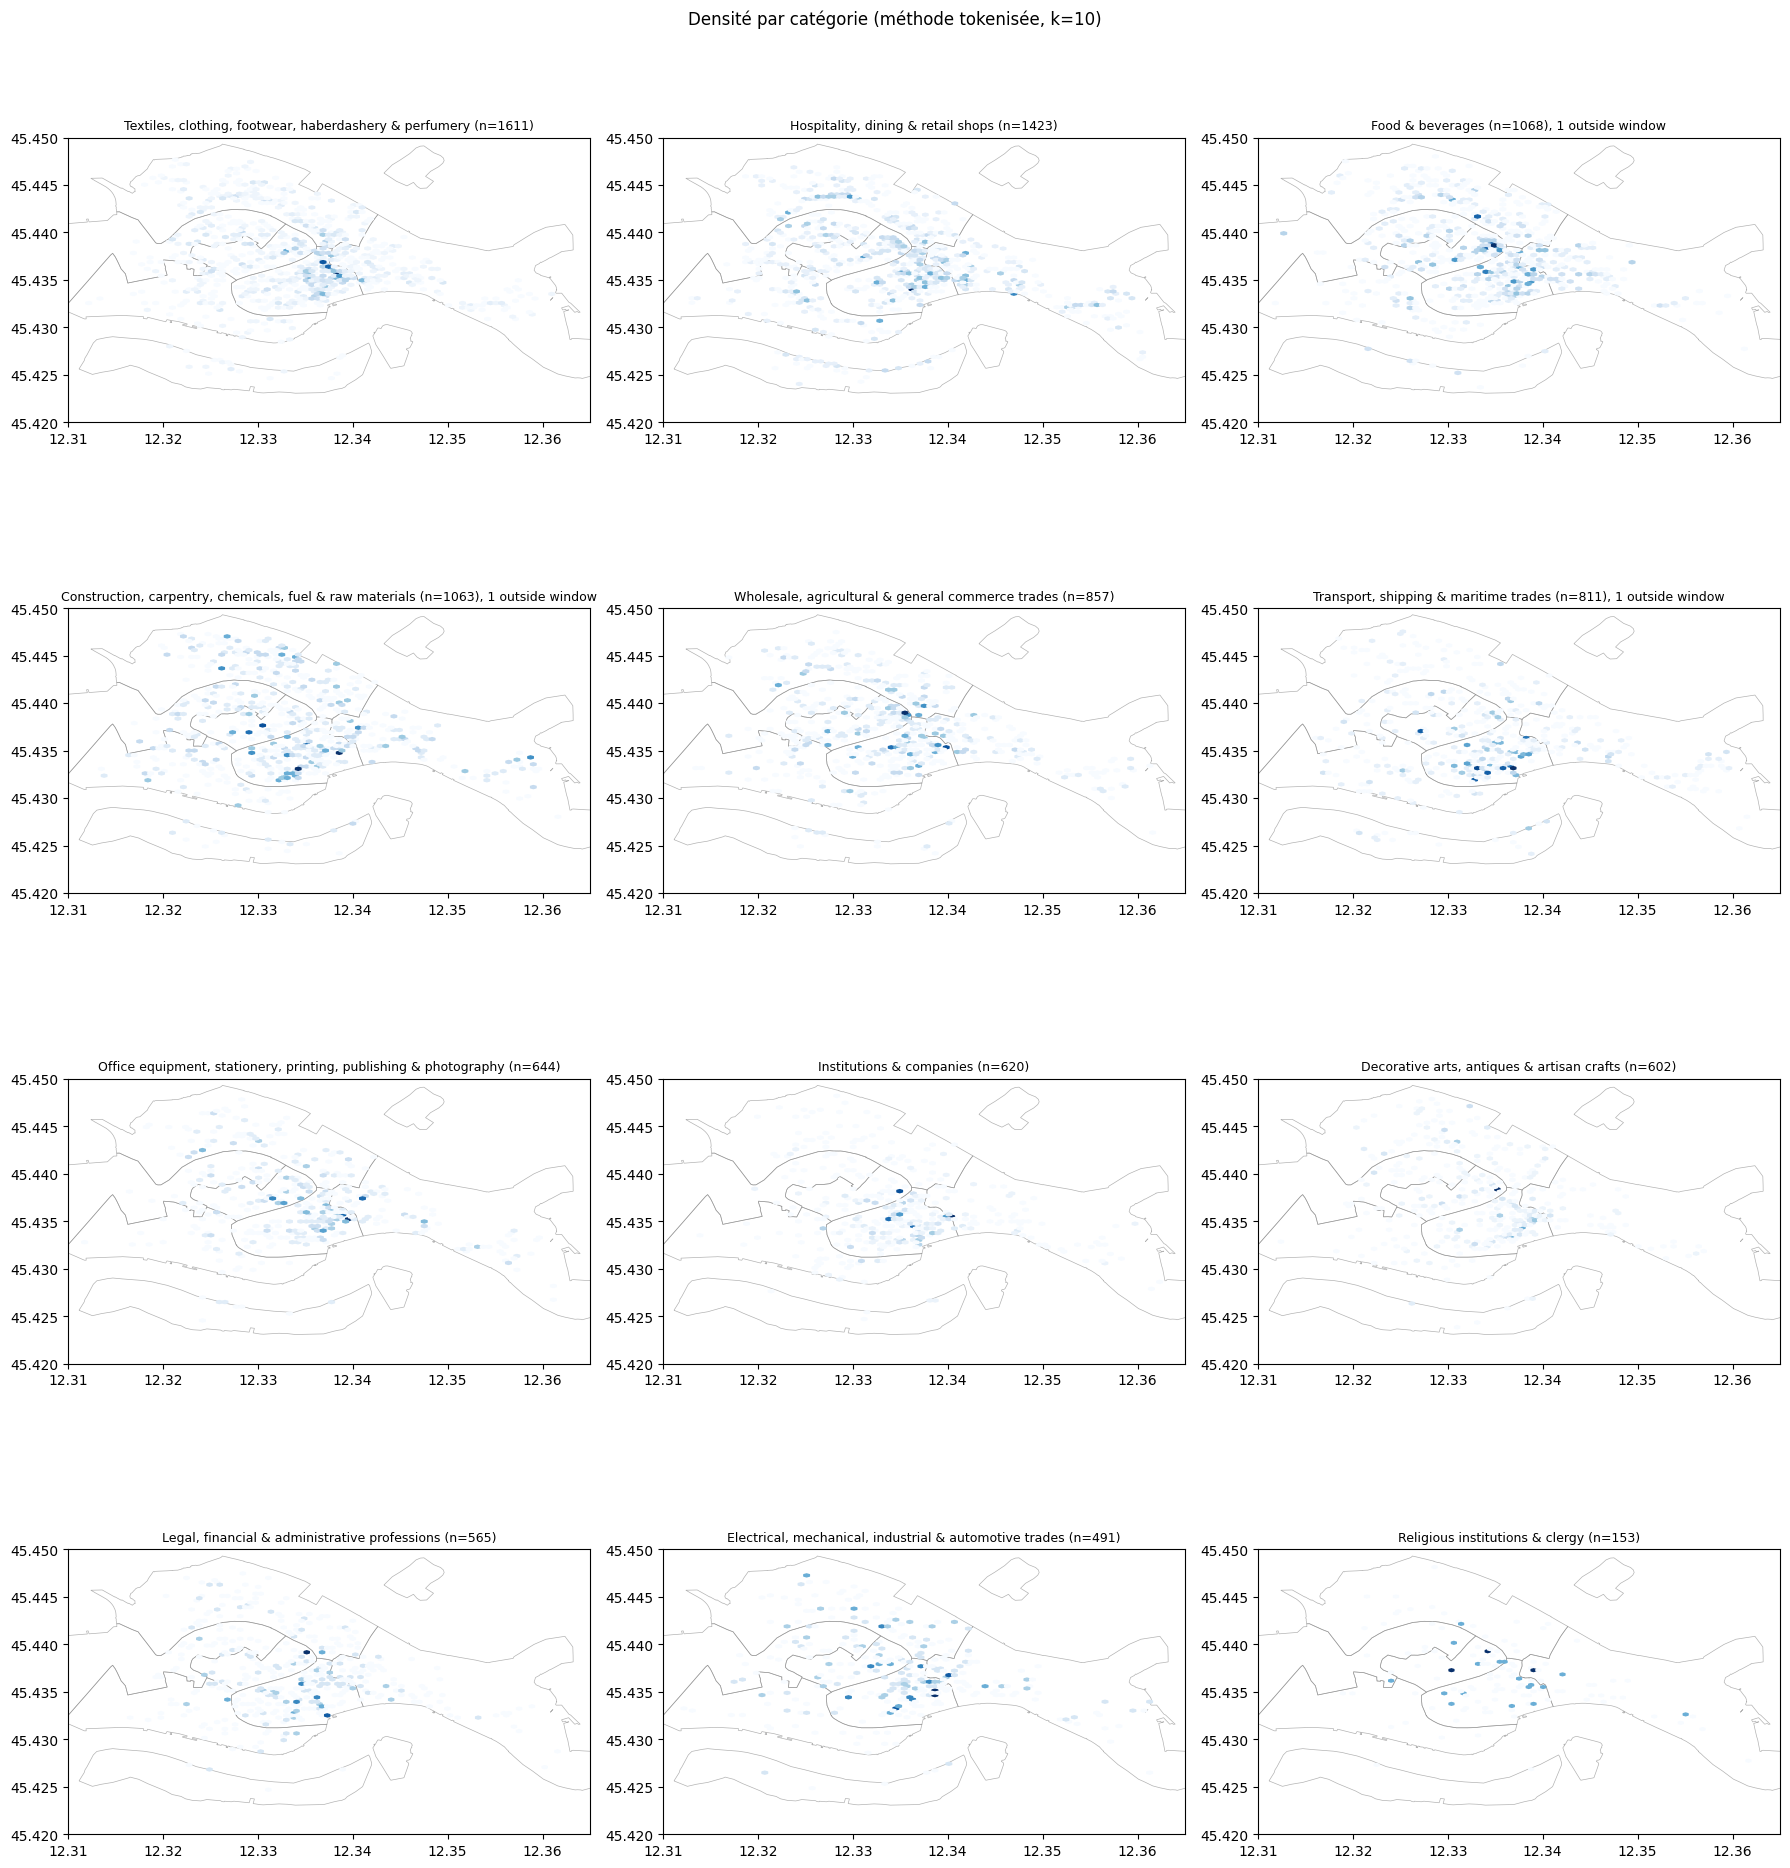

Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: heatmap_category_class_tokenised_k10_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_class_tokenised_k10_coverage_20260824_161514.csv


In [57]:
# density heatmaps by category (k=10) -- tokenised method, same gridsize approach

col = "category_class_tokenised"
geo_token = geo[geo[col].notna()].copy()
print(f"{len(geo_token)} classified out of {len(geo)} total ({100*len(geo_token)/len(geo):.1f}%)")

class_counts_token = geo_token[col].value_counts()
print(class_counts_token.to_string())

lon_min, lon_max = HEATMAP_LON_MIN, HEATMAP_LON_MAX
lat_min, lat_max = HEATMAP_LAT_MIN, HEATMAP_LAT_MAX

sestieri = gpd.read_file(SESTIERE_PATH).to_crs(epsg=4326)

def _median_nn_spacing_m_ct(pts):
    lat0 = pts["matched_lat"].mean()
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat0))
    xy = np.column_stack([
        pts["matched_lon"].to_numpy() * m_per_deg_lon,
        pts["matched_lat"].to_numpy() * m_per_deg_lat,
    ])
    tree = cKDTree(xy)
    nn_dist, _ = tree.query(xy, k=2)
    return float(np.median(nn_dist[:, 1]))

# size hexagons off whichever class is most spatially spread out (largest median nearest-neighbor spacing) 
_class_spacings_ct = {}
for _cls in class_counts_token.index:
    _sub_cls = geo_token[geo_token[col] == _cls]
    _pts_cls = _sub_cls[
        _sub_cls["matched_lon"].between(lon_min, lon_max) & _sub_cls["matched_lat"].between(lat_min, lat_max)
    ].drop_duplicates(subset=["matched_lat", "matched_lon"])
    if len(_pts_cls) >= 2:
        _class_spacings_ct[_cls] = _median_nn_spacing_m_ct(_pts_cls)

_sparsest_cls_ct = max(_class_spacings_ct, key=_class_spacings_ct.get)
target_hex_width_m_ct = _class_spacings_ct[_sparsest_cls_ct]
_m_per_deg_lon_ct = 111_320 * math.cos(math.radians(geo_token["matched_lat"].mean()))
_extent_m_ct = (lon_max - lon_min) * _m_per_deg_lon_ct
GRIDSIZE_CAT_TOKEN_PANEL = int(round(_extent_m_ct / target_hex_width_m_ct))
print(f"Most spatially spread class: {_sparsest_cls_ct!r} (spacing={target_hex_width_m_ct:.1f}m) -> gridsize={GRIDSIZE_CAT_TOKEN_PANEL}")

classes = class_counts_token.index.tolist()
n_cols = 3
n_rows = -(-len(classes) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sub = geo_token[geo_token[col] == cls]
    in_window = sub[sub["matched_lon"].between(lon_min, lon_max) & sub["matched_lat"].between(lat_min, lat_max)]
    n_dropped = len(sub) - len(in_window)
    sestieri.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.6, zorder=0)
    ax.hexbin(in_window["matched_lon"], in_window["matched_lat"], gridsize=GRIDSIZE_CAT_TOKEN_PANEL, cmap="Blues", mincnt=1, zorder=1)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect("equal")
    title = f"{cls} (n={len(in_window)})"
    if n_dropped:
        title += f", {n_dropped} outside window"
    ax.set_title(title, fontsize=9)

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Densité par catégorie (méthode tokenisée, k=10)")
plt.tight_layout()
out_name = _v("heatmap_category_class_tokenised_k10.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("heatmap_category_class_tokenised_k10.png", f.read(), "image/png", subfolder="category_clustering")

csv_bytes = class_counts_token.reset_index().rename(
    columns={"index": "category_class", col: "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("category_class_tokenised_k10_coverage.csv", csv_bytes, "text/csv", subfolder="category_clustering")


In [58]:
# comparison: direct method vs tokenised method, row-level

both = geo[geo["category_class_k10"].notna() & geo["category_class_tokenised"].notna()].copy()
print(f"{len(both)} rows classified by both methods "
      f"(direct: {geo['category_class_k10'].notna().sum()}, tokenised: {geo['category_class_tokenised'].notna().sum()})")

crosstab_counts = pd.crosstab(both["category_class_k10"], both["category_class_tokenised"])
crosstab_pct = pd.crosstab(both["category_class_k10"], both["category_class_tokenised"], normalize="index") * 100

print("\nrow totals (direct method categories):")
print(crosstab_counts.sum(axis=1).to_string())

print("\ndominant tokenised match per direct category:")
for cls in crosstab_counts.index:
    row = crosstab_counts.loc[cls]
    top = row.idxmax()
    print(f"{cls:<65} -> {top:<55} {row[top]/row.sum()*100:.1f}%")

upload_to_stats("category_method_comparison_counts.csv",
                crosstab_counts.to_csv().encode("utf-8"), "text/csv", subfolder="category_clustering")
upload_to_stats("category_method_comparison_pct.csv",
                crosstab_pct.round(1).to_csv().encode("utf-8"), "text/csv", subfolder="category_clustering")


9864 rows classified by both methods (direct: 10683, tokenised: 9911)

row totals (direct method categories):
category_class_k10
Chemicals, fuel, construction materials & raw materials          678
Culture, entertainment & leisure                                  19
Decorative arts, photography, antiques & artisan crafts          953
Food, grocery & hospitality trade                               2268
Institutions/companies                                           224
Legal, financial & administrative professions                    836
Office equipment, electrical, mechanical & industrial trades     678
Real estate, construction & business services                    919
Religious institutions & clergy                                   33
Textiles, clothing                                              2408
Transport, shipping & maritime trades                            809
general retail                                                    39

dominant tokenised match per direct catego

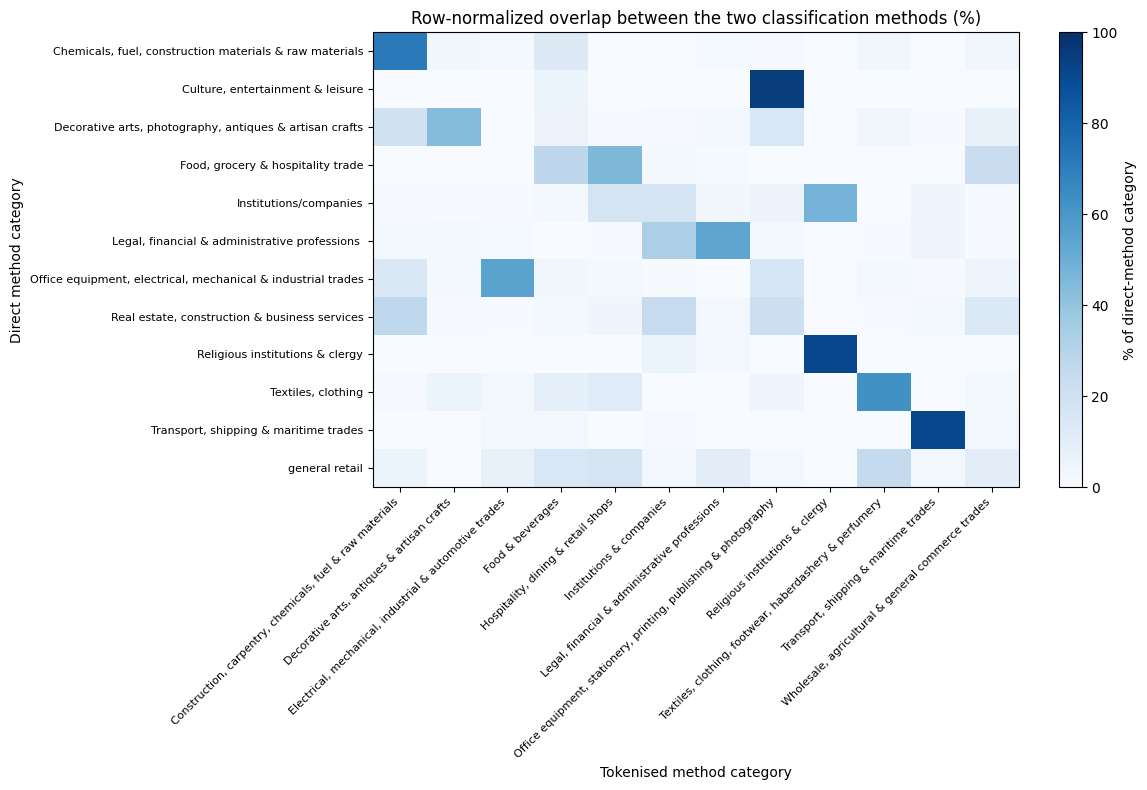

Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_method_comparison_heatmap_20260824_161514.png


In [59]:
# comparison plot -- normalized crosstab as a heatmap

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(crosstab_pct.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(crosstab_pct.columns)))
ax.set_xticklabels(crosstab_pct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(crosstab_pct.index)))
ax.set_yticklabels(crosstab_pct.index, fontsize=8)
ax.set_xlabel("Tokenised method category")
ax.set_ylabel("Direct method category")
ax.set_title("Row-normalized overlap between the two classification methods (%)")
fig.colorbar(im, ax=ax, label="% of direct-method category")
plt.tight_layout()
out_name = _v("category_method_comparison_heatmap.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("category_method_comparison_heatmap.png", f.read(), "image/png", subfolder="category_clustering")


In [60]:
# dense-cluster analysis (direct method) -- what is actually driving the hotspots on the maps above: top repeated coordinates per category, with sample names

TOP_N_HOTSPOTS = 3
TOP_N_NAMES = 5

hotspot_rows_direct = []
for cls in geo_direct["category_class_k10"].value_counts().index:
    sub = geo_direct[geo_direct["category_class_k10"] == cls]
    hotspots = sub.groupby(["matched_lat", "matched_lon"]).agg(
        n=("Name", "size"), address=("Address", "first"),
    ).reset_index().sort_values("n", ascending=False).head(TOP_N_HOTSPOTS)

    print(f"\n{cls} (n={len(sub)})")
    for _, row in hotspots.iterrows():
        pt = sub[(sub["matched_lat"] == row["matched_lat"]) & (sub["matched_lon"] == row["matched_lon"])]
        names = pt["Name"].head(TOP_N_NAMES).tolist()
        print(f"  {row['address']:<40} {int(row['n']):>4} entries  e.g. {names}")
        hotspot_rows_direct.append({
            "category_class": cls, "address": row["address"],
            "lat": row["matched_lat"], "lon": row["matched_lon"],
            "n_entries": int(row["n"]), "sample_names": " | ".join(names),
        })

hotspot_df_direct = pd.DataFrame(hotspot_rows_direct)
csv_bytes = hotspot_df_direct.to_csv(index=False).encode("utf-8")
upload_to_stats("category_direct_k10_hotspots.csv", csv_bytes, "text/csv", subfolder="category_clustering")



Textiles, clothing (n=2485)
  Giudecca 52                                 7 entries  e.g. ['Gaspè-uzzo Primo', 'Gasperuzzo Primo', 'Gasparuzzo Primo', 'Gheller Galliamo', 'Giarcozzi Irma']
  S. Marco 5177                               7 entries  e.g. ['Bagiolotto Umberto', 'Bagiottuto Umberto', 'Bagliotto Attilio', 'Bonotto Pierina', 'Bagiotto Umberto']
  Cannaregio 1374                             6 entries  e.g. ['Stefanatti Stefano', 'Stefanutti Stefano', 'Stefanutti Stefano', 'Stefanutti Stefano', 'Stefanutti Stefano']

Food, grocery & hospitality trade (n=2346)
  Riva Schiavoni 4202                        10 entries  e.g. ["Galleria d'arte del Cavallino", 'Mazzarini Giuseppe', 'Maestrello Virginia', 'Cigana Emma', 'Censi Elena']
  Cannaregio 6025                             8 entries  e.g. ['Pellegrinotti Mario', 'Pellegrinotti G. e C.', 'Pellegrinotti Mario', 'Pellegrinotti Mario (ditta) Soc. a. r. l.', 'Pellegrinotti Mario (ditta)']
  S. Polo 1518                               

In [61]:
# dense-cluster analysis (tokenised method) -- same as above, for the tokenised classes

hotspot_rows_token = []
for cls in geo_token["category_class_tokenised"].value_counts().index:
    sub = geo_token[geo_token["category_class_tokenised"] == cls]
    hotspots = sub.groupby(["matched_lat", "matched_lon"]).agg(
        n=("Name", "size"), address=("Address", "first"),
    ).reset_index().sort_values("n", ascending=False).head(TOP_N_HOTSPOTS)

    print(f"\n{cls} (n={len(sub)})")
    for _, row in hotspots.iterrows():
        pt = sub[(sub["matched_lat"] == row["matched_lat"]) & (sub["matched_lon"] == row["matched_lon"])]
        names = pt["Name"].head(TOP_N_NAMES).tolist()
        print(f"  {row['address']:<40} {int(row['n']):>4} entries  e.g. {names}")
        hotspot_rows_token.append({
            "category_class": cls, "address": row["address"],
            "lat": row["matched_lat"], "lon": row["matched_lon"],
            "n_entries": int(row["n"]), "sample_names": " | ".join(names),
        })

hotspot_df_token = pd.DataFrame(hotspot_rows_token)
csv_bytes = hotspot_df_token.to_csv(index=False).encode("utf-8")
upload_to_stats("category_tokenised_k10_hotspots.csv", csv_bytes, "text/csv", subfolder="category_clustering")



Textiles, clothing, footwear, haberdashery & perfumery (n=1611)
  Merceria S. Salvador 5024                   7 entries  e.g. ['Istituto di Bellezza', 'ISTITUTO DI BELLEZZA', '« La Veneziana » di Ballarin Nino', 'Istituto di bellezza', 'Istituto di Bellezza']
  S. Marco 5177                               6 entries  e.g. ['Bagiolotto Umberto', 'Bagiottuto Umberto', 'Bagliotto Attilio', 'Bonotto Pierina', 'Baggetto Attilio']
  S. Marco 1218                               6 entries  e.g. ['Polotto Giuseppe', 'Cioni Piganton Evelina', 'Gioni Pignaton Evelyna', 'Cioni Evelina', 'Cioni Piglato Evelina']

Hospitality, dining & retail shops (n=1423)
  Riva degli Schiavoni 4119                   9 entries  e.g. ['Mazzarini Giuseppe', 'Maestrello Virginia', 'Bagagioli Mario', 'Cigana Emma', 'Cigana Emma']
  S. Croce 745                                5 entries  e.g. ['Rampazzo Ampelio', 'Ravagnan Nicola', 'Rinaldi Elisa', 'Rampazzo Ampelio', 'Ramazzo Ampelio']
  S. Marco 1165                    

In [62]:
# cluster composition -- what's driving each dense region, grid-binned, top N cells with category breakdown and sample entries

GRID_SIZE = 0.0015   # roughly matches the hexbin visual resolution
TOP_N_CLUSTERS = 10

geo_grid = geo.copy()
geo_grid["grid_lat"] = (geo_grid["matched_lat"] / GRID_SIZE).round() * GRID_SIZE
geo_grid["grid_lon"] = (geo_grid["matched_lon"] / GRID_SIZE).round() * GRID_SIZE

grid_counts = geo_grid.groupby(["grid_lat", "grid_lon"]).size().sort_values(ascending=False)

print(f"Top {TOP_N_CLUSTERS} densest grid cells:\n")
print(grid_counts.head(TOP_N_CLUSTERS).to_string())

for (glat, glon), n_entries in grid_counts.head(TOP_N_CLUSTERS).items():
    cell = geo_grid[(geo_grid["grid_lat"] == glat) & (geo_grid["grid_lon"] == glon)]
    print(f"\n{'='*70}")
    print(f"Cell ({glat:.4f}, {glon:.4f}) — {n_entries} entries")
    print(f"{'='*70}")

    if "sestiere_parsed" in cell.columns:
        print("Sestiere:", cell["sestiere_parsed"].value_counts().head(3).to_dict())

    if "profession_category" in cell.columns:
        cat_comp = cell["profession_category"].value_counts(normalize=True).head(5) * 100
        n_with_cat = cell["profession_category"].notna().sum()
        print(f"Rows with a profession category: {n_with_cat}/{n_entries} "
              f"({100*n_with_cat/n_entries:.0f}%)")
        print("Top categories in this cell:")
        print(cat_comp.round(1).to_string())

    print("\nSample entries:")
    cols = [c for c in ("Name", "Address", "Profession", "section") if c in cell.columns]
    print(cell[cols].drop_duplicates(subset="Address").head(5).to_string(index=False))

Top 10 densest grid cells:

grid_lat  grid_lon
45.4350   12.3390     493
          12.3360     401
45.4335   12.3360     340
45.4365   12.3375     332
          12.3345     315
45.4350   12.3375     299
45.4335   12.3345     276
45.4350   12.3405     259
45.4335   12.3375     253
45.4395   12.3345     250

Cell (45.4350, 12.3390) — 493 entries
Sestiere: {'SAN MARCO': 453, 'CASTELLO': 32}
Rows with a profession category: 115/493 (23%)
Top categories in this cell:
profession_category
Office & mechanical equipment (ad-dominated)    23.5
General goods trade                             17.4
Religious & civic institutions                   9.6
Sales representatives / Commercial agents        8.7
Industry and construction                        8.7

Sample entries:
                Name                          Address                                         Profession        section
Societa’ dell’Unione            Piazza S. Marco 153-A                                                NaN      r

In [63]:
# coverage summary -- direct vs tokenised, side by side

has_raw_cat = geo["Category"].notna().sum()
total = len(geo)

summary_rows = []
for label, col in [("Direct (k=10)", "category_class_k10"), ("Tokenised (k=10)", "category_class_tokenised")]:
    classified = geo[col].notna().sum()
    n_categories = geo[col].nunique()
    excluded = has_raw_cat - classified
    summary_rows.append({
        "method": label,
        "total_rows": total,
        "rows_with_category_value": has_raw_cat,
        "rows_classified": classified,
        "pct_of_total": round(100 * classified / total, 1),
        "pct_of_rows_with_category": round(100 * classified / has_raw_cat, 1),
        "n_categories": n_categories,
        "rows_excluded": excluded,
    })

coverage_summary = pd.DataFrame(summary_rows)
print(coverage_summary.to_string(index=False))

csv_bytes = coverage_summary.to_csv(index=False).encode("utf-8")
upload_to_stats("category_coverage_summary_both_methods.csv", csv_bytes, "text/csv", subfolder="category_clustering")


          method  total_rows  rows_with_category_value  rows_classified  pct_of_total  pct_of_rows_with_category  n_categories  rows_excluded
   Direct (k=10)       16469                     11175            10683          64.9                       95.6            12            492
Tokenised (k=10)       16469                     11175             9911          60.2                       88.7            12           1264
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_coverage_summary_both_methods_20260824_161514.csv


In [64]:
# manual-override transparency -- direct vs tokenised

def _override_stats(value_overrides, cluster_default_names, cluster_df, value_col):
    n_reassign_defs = sum(1 for v in value_overrides.values() if v is not None)
    n_exclude_defs = sum(1 for v in value_overrides.values() if v is None)
    matched = cluster_df[cluster_df[value_col].isin(value_overrides)]
    reassigned = matched[matched["category_name"].notna()]
    excluded = matched[matched["category_name"].isna()]
    return {
        "n_cluster_defaults": sum(1 for v in cluster_default_names.values() if v is not None),
        "n_overrides_defined": len(value_overrides),
        "n_overrides_reassign": n_reassign_defs,
        "n_overrides_exclude": n_exclude_defs,
        "n_values_reassigned": len(reassigned),
        "rows_reassigned": int(reassigned["frequency"].sum()),
        "n_values_excluded_by_override": len(excluded),
        "rows_excluded_by_override": int(excluded["frequency"].sum()),
    }

direct_stats = _override_stats(VALUE_OVERRIDES_CAT, CLUSTER_DEFAULT_NAMES_CAT, cat_cluster_df, "category")
direct_stats["method"] = "Direct (k=10)"

token_stats = _override_stats(TOKEN_VALUE_OVERRIDES, TOKEN_CLUSTER_DEFAULT_NAMES, canon_cluster_df, "canonical_label")
token_stats["method"] = "Tokenised (k=10)"

override_summary = pd.DataFrame([direct_stats, token_stats])
override_summary = override_summary[[
    "method", "n_cluster_defaults", "n_overrides_defined", "n_overrides_reassign",
    "n_overrides_exclude", "n_values_reassigned", "rows_reassigned",
    "n_values_excluded_by_override", "rows_excluded_by_override",
]]
print(override_summary.to_string(index=False))

csv_bytes = override_summary.to_csv(index=False).encode("utf-8")
upload_to_stats("category_override_transparency_both_methods.csv", csv_bytes, "text/csv", subfolder="category_clustering")


          method  n_cluster_defaults  n_overrides_defined  n_overrides_reassign  n_overrides_exclude  n_values_reassigned  rows_reassigned  n_values_excluded_by_override  rows_excluded_by_override
   Direct (k=10)                  10                  589                   413                  176                  409             2014                            175                        492
Tokenised (k=10)                   9                  294                   279                   15                  274             1906                             14                        244
Saved (both) to stats_geo_analysis/20260824_161514/category_clustering/: category_override_transparency_both_methods_20260824_161514.csv


In [65]:
# profession/category clustering saving file
_PROF_CAT_COLS = [
    "Name", "Address", "page_num", "source_file", "matched_lat", "matched_lon",
    "profession_category", "profession_likely_ad", "profession_category_k10",
    "category_class_k10", "category_class_tokenised",
]
_prof_cat_present = [c for c in _PROF_CAT_COLS if c in geo.columns]
_prof_cat_missing = [c for c in _PROF_CAT_COLS if c not in geo.columns]
if _prof_cat_missing:
    print(f"  WARNING: profession/category preservation file missing columns: {_prof_cat_missing}")

profession_category_preserved = geo[_prof_cat_present].copy()
_pc_csv_bytes = profession_category_preserved.to_csv(index=False).encode("utf-8")
upload_to_stats(
    "profession_final.csv", _pc_csv_bytes, "text/csv",
    subfolder="profession_clustering",
)
print(f"Saved {len(profession_category_preserved)} rows -> "
      f"stats_geo_analysis/{RUN_TAG}/profession/csv/")


Saved (both) to stats_geo_analysis/20260824_161514/final_results/profession_category_clustering/: profession_category_clustering_20260824_161514.csv
Saved 16469 rows -> stats_geo_analysis/final_results/profession_category_clustering/


# 4. Occupation

In [66]:
# profession ad-contamination cleaning, before the occupation merge
PROFESSION_AD_VALUES = {
    "MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI": "typewriter/office dealer (ad)",
    "Macchine per scrivere - Calcolatrici - Duplicatori": "typewriter/office dealer (ad)",
    "Duplicatori": "typewriter/office dealer (ad, truncated)",
    "Forniture compiete MOBILI e ACCESSORI per UFFICIO": "typewriter/office dealer (ad)",
    "Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia": "Zampironi mosquito repellent (ad)",
    "Tutti i prodotti ZAMPIRONI sono di massima fiducia": "Zampironi mosquito repellent (ad)",
    "Fidibus against mosquitoes": "Zampironi mosquito repellent (ad)",
}

mask_prof_ad = geo["Profession"].isin(PROFESSION_AD_VALUES.keys())
prof_ad_counts = geo.loc[mask_prof_ad, "Profession"].value_counts()

print("Profession ad-contamination:")
for val, kind in PROFESSION_AD_VALUES.items():
    n = int(prof_ad_counts.get(val, 0))
    print(f"  {n:>4}  {kind:<35} {val!r}")
print(f"total: {int(mask_prof_ad.sum())} rows")

prof_ad_log = pd.DataFrame([
    {"profession_value": v, "identity": k, "n_rows": int(prof_ad_counts.get(v, 0))}
    for v, k in PROFESSION_AD_VALUES.items()
])
upload_to_stats("profession_ad_contamination.csv",
                 prof_ad_log.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_merge")

geo.loc[mask_prof_ad, "Profession"] = pd.NA

# variant check: anything else matching the same pattern family that
# isn't in the list above yet. Same regex used to verify Category earlier.
_AD_VARIANT_PATTERN = re.compile(r"2288|scrivere|typewriter|machine.{0,10}writ|duplicator|zampironi", re.I)
_prof_variant_hits = geo.loc[geo["Profession"].notna() & geo["Profession"].str.contains(_AD_VARIANT_PATTERN, na=False), "Profession"]
if not _prof_variant_hits.empty:
    print(f"\n{_prof_variant_hits.nunique()} value(s) NOT in the list above still match the ad pattern -- check these:")
    print(_prof_variant_hits.value_counts())
else:
    print("\nNo further variants found matching the ad pattern.")


Profession ad-contamination:
   359  typewriter/office dealer (ad)       'MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI'
   360  typewriter/office dealer (ad)       'Macchine per scrivere - Calcolatrici - Duplicatori'
    51  typewriter/office dealer (ad, truncated) 'Duplicatori'
    46  typewriter/office dealer (ad)       'Forniture compiete MOBILI e ACCESSORI per UFFICIO'
   194  Zampironi mosquito repellent (ad)   'Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia'
     1  Zampironi mosquito repellent (ad)   'Tutti i prodotti ZAMPIRONI sono di massima fiducia'
     1  Zampironi mosquito repellent (ad)   'Fidibus against mosquitoes'
total: 1012 rows
Saved (both) to stats_geo_analysis/20260824_161514/occupation_merge/: profession_ad_contamination_20260824_161514.csv

No further variants found matching the ad pattern.


In [67]:
# category was already cleaned above but re-checking with a pattern match instead of an exact list

_AD_VARIANT_PATTERN_CAT = re.compile(r"2288|scrivere|typewriter|machine.{0,10}writ|duplicator", re.I)
_cat_variant_hits = geo.loc[geo["Category"].notna() & geo["Category"].str.contains(_AD_VARIANT_PATTERN_CAT, na=False), "Category"]

if not _cat_variant_hits.empty:
    print(f"{_cat_variant_hits.nunique()} Category value(s) still matching the ad pattern after cleaning:")
    print(_cat_variant_hits.value_counts())
    cat_recheck_log = _cat_variant_hits.value_counts().reset_index()
    cat_recheck_log.columns = ["category_value", "n_rows"]
    upload_to_stats("category_ad_recheck.csv",
                     cat_recheck_log.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_merge")
    geo.loc[_cat_variant_hits.index, "Category"] = pd.NA
    print(f"\nBlanked {len(_cat_variant_hits)} more row(s).")
else:
    print("No leftover ad-contamination pattern found in Category -- clean.")


9 Category value(s) still matching the ad pattern after cleaning:
Category
Macchine per scrivere                                                                                   144
Macchine per scrivere - Calcolatrici - Duplicatori                                                       66
SCHEDARI - MOBILI PER UFFICIO - MACCHINE CONTABILI - MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI     17
Venezia - Via XXII Marzo, 2288, Telephone: 25-889                                                        15
Macchine per scrivere - Calcolatrici - Duplicatori - OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI          1
Macchine per scrivere e accessori                                                                         1
2288 - Telefono 25-889                                                                                    1
Macchine per scrivene - Calcilatrici - Duplicatori                                                        1
SCHEDARI - MOBILI PER UFFICI - MACCHINE CONTABILI MACCHINE PE

In [68]:
# role cleaning

ROLE_MASTHEAD_VALUES = {
    "- GUIDA COMMERCIALE 01 VENEZIA E PROVINCIA": "almanac's own title (masthead)",
}

mask_role_masthead = geo["Role"].isin(ROLE_MASTHEAD_VALUES.keys())
role_masthead_counts = geo.loc[mask_role_masthead, "Role"].value_counts()

print("Role masthead contamination:")
for val, kind in ROLE_MASTHEAD_VALUES.items():
    n = int(role_masthead_counts.get(val, 0))
    print(f"  {n:>4}  {kind:<30} {val!r}")
print(f"total: {int(mask_role_masthead.sum())} rows")

role_masthead_log = pd.DataFrame([
    {"role_value": v, "identity": k, "n_rows": int(role_masthead_counts.get(v, 0))}
    for v, k in ROLE_MASTHEAD_VALUES.items()
])
upload_to_stats("role_masthead_contamination.csv",
                 role_masthead_log.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_merge")

geo.loc[mask_role_masthead, "Role"] = pd.NA


Role masthead contamination:
    19  almanac's own title (masthead) '- GUIDA COMMERCIALE 01 VENEZIA E PROVINCIA'
total: 19 rows
Saved (both) to stats_geo_analysis/20260824_161514/occupation_merge/: role_masthead_contamination_20260824_161514.csv


In [69]:
# second-round exclusions, found via the extended detector + cross-field
# checks against Additional Info. 

PROFESSION_ROUND2 = {
    "Agenzia P. Bortoluzzi": "agency name (ad)",
    "Lavorazione artistica mosaici in smalto di vetro Veneziano":
        "propagated alongside 'OFFICINA RIPARAZIONI MACCHINE PER SCRIVERE VENEZIA' in Additional Info",
    "Rappresentante di case produttrici di medicinali":
        "propagated alongside 'OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI' in Additional Info",
}
mask_prof_r2 = geo["Profession"].isin(PROFESSION_ROUND2.keys())
prof_r2_counts = geo.loc[mask_prof_r2, "Profession"].value_counts()
print("Profession round 2:")
for v, k in PROFESSION_ROUND2.items():
    print(f"  {int(prof_r2_counts.get(v, 0)):>4}  {k:<70} {v!r}")
print(f"total: {int(mask_prof_r2.sum())} rows")
geo.loc[mask_prof_r2, "Profession"] = pd.NA

ROLE_ROUND2 = {
    "AFFITTI APPARTAMENTI, COMPRA - VENDITA, AMMINISTRAZIONE": "real-estate agency service list (ad)",
}
mask_role_r2 = geo["Role"].isin(ROLE_ROUND2.keys())
role_r2_counts = geo.loc[mask_role_r2, "Role"].value_counts()
print("\nRole round 2:")
for v, k in ROLE_ROUND2.items():
    print(f"  {int(role_r2_counts.get(v, 0)):>4}  {k:<40} {v!r}")
print(f"total: {int(mask_role_r2.sum())} rows")
geo.loc[mask_role_r2, "Role"] = pd.NA

CATEGORY_ROUND2 = {
    "AGENZIA P. BORTOLUZZI": "agency name (ad)",
    "ZAGO F.LLI": "company name (ad)",
    "Forniture complete MOBILI e ACCESSORI per UFFICIO": "typewriter/office dealer (ad, spelling variant)",
    "OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI": "typewriter/office dealer (ad fragment)",
    "AFFITTANO APPARTAMENTI": "real-estate agency service list (ad)",
    "agenzia di viaggi e turismo,Cappellont Aldo": "travel agency + name (ad)",
    "Mestre": "bare place name",
    "cappelano S. Bingio (Chiesa della Marina).": "one chaplain's title, propagated",
}
mask_cat_r2 = geo["Category"].isin(CATEGORY_ROUND2.keys())
cat_r2_counts = geo.loc[mask_cat_r2, "Category"].value_counts()
print("\nCategory round 2:")
for v, k in CATEGORY_ROUND2.items():
    print(f"  {int(cat_r2_counts.get(v, 0)):>4}  {k:<40} {v!r}")
print(f"total: {int(mask_cat_r2.sum())} rows")
geo.loc[mask_cat_r2, "Category"] = pd.NA

round2_log = pd.DataFrame(
    [{"field": "Profession", "value": v, "identity": k, "n_rows": int(prof_r2_counts.get(v, 0))} for v, k in PROFESSION_ROUND2.items()]
    + [{"field": "Role", "value": v, "identity": k, "n_rows": int(role_r2_counts.get(v, 0))} for v, k in ROLE_ROUND2.items()]
    + [{"field": "Category", "value": v, "identity": k, "n_rows": int(cat_r2_counts.get(v, 0))} for v, k in CATEGORY_ROUND2.items()]
)
upload_to_stats("contamination_round2.csv",
                 round2_log.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_merge")
print(f"\nTotal round-2 rows blanked across all three fields: "
      f"{int(mask_prof_r2.sum()) + int(mask_role_r2.sum()) + int(mask_cat_r2.sum())}")


Profession round 2:
    48  agency name (ad)                                                       'Agenzia P. Bortoluzzi'
   168  propagated alongside 'OFFICINA RIPARAZIONI MACCHINE PER SCRIVERE VENEZIA' in Additional Info 'Lavorazione artistica mosaici in smalto di vetro Veneziano'
   186  propagated alongside 'OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI' in Additional Info 'Rappresentante di case produttrici di medicinali'
total: 402 rows

Role round 2:
   119  real-estate agency service list (ad)     'AFFITTI APPARTAMENTI, COMPRA - VENDITA, AMMINISTRAZIONE'
total: 119 rows

Category round 2:
    49  agency name (ad)                         'AGENZIA P. BORTOLUZZI'
    58  company name (ad)                        'ZAGO F.LLI'
    75  typewriter/office dealer (ad, spelling variant) 'Forniture complete MOBILI e ACCESSORI per UFFICIO'
    75  typewriter/office dealer (ad fragment)   'OCCASIONI - CAMBI - RICOSTRUZIONI - NOLEGGI'
    49  real-estate agency service list (ad)     'AFFITTANO

In [70]:
# LLM occupation resolution -- for rows where 2+ of Category/Role/Profession are present, asks an LLM which field holds the real data and whether they contradict

_api_file = Path(OPENAI_KEY_FILE)
with open(_api_file, "r") as f:
    _cont = f.readlines()
_params = dict(v.strip().split("=", 1) for v in _cont if "=" in v)
occ_client = OpenAI(api_key=_params["api_key"], timeout=30.0, max_retries=0)

OCC_CHAT_MODEL = "gpt-4o-mini"
OCC_BATCH_SIZE = 10
OCC_MAX_RETRIES = 5

has_cat_c  = geo["Category"].notna()
has_role_c = geo["Role"].notna()
has_prof_c = geo["Profession"].notna()

multi_field_mask = (has_cat_c.astype(int) + has_role_c.astype(int) + has_prof_c.astype(int)) >= 2
occ_candidates = geo.loc[multi_field_mask, ["Name", "Address", "Category", "Role", "Profession"]].copy()
occ_candidates = occ_candidates.reset_index().rename(columns={"index": "row_id"})
print(f"{len(occ_candidates)} rows with 2+ of Category/Role/Profession present")

OCC_PROMPT_HEADER = (
    "You are helping decide which field holds the real occupational/business information "
    "for entries from a 1947 Venetian commercial almanac. For each numbered row below, you "
    "are given up to three fields -- Category, Role, Profession -- along with Name and Address "
    "for context. Decide which field(s) contain genuine occupational data (a trade, profession, "
    "or business type), and whether the fields present genuinely disagree/contradict each other "
    "(e.g. one names a completely different, unrelated occupation from another) as opposed to "
    "being complementary (e.g. a Role like 'Direttore' alongside a Profession like 'Avvocato' is "
    "not a contradiction, a director can be a lawyer).\n\n"
    "For each row, reply with a JSON object on its own line: "
    '{"source": "Category"|"Role"|"Profession"|"Category+Role"|"Category+Profession"|'
    '"Role+Profession"|"All three"|"none", "occupation": "<the resolved occupation text, or empty>", '
    '"contradiction": true|false, "reasoning": "<one short sentence>"}\n'
    "Reply with ONLY a numbered list matching the input numbering, one JSON object per line, "
    "no other text. You MUST output exactly one JSON object per numbered input row, in the same "
    "order, even if several rows look identical or very similar to each other -- never merge, "
    "skip, or deduplicate rows. If two input rows are identical, output the same decision twice.\n\n"
)

_OCC_NUMBERED_LINE_RE = re.compile(r"^\d+[\.\)]\s*(.+)$")

def occ_row_text(row):
    parts = [f"Name: {row['Name']}", f"Address: {row['Address']}"]
    for f in ["Category", "Role", "Profession"]:
        if pd.notna(row[f]):
            parts.append(f"{f}: {row[f]}")
    return " | ".join(parts)

def _occ_parse_batch_reply(raw):
    if raw.startswith("```"):
        raw = re.sub(r"^```[a-zA-Z]*\n?", "", raw)
        raw = re.sub(r"\n?```$", "", raw.strip())
    lines = [l.strip() for l in raw.splitlines() if l.strip()]
    lines = [l for l in lines if l not in ("```", "```json")]
    decisions = []
    for line in lines:
        m = _OCC_NUMBERED_LINE_RE.match(line)
        text = m.group(1).strip() if m else line
        decisions.append(json.loads(text))
    return decisions

def resolve_occupation_batch_with_retry(batch_rows, max_retries=OCC_MAX_RETRIES, _depth=0):
    numbered_input = "\n".join(f"{i+1}. {occ_row_text(r)}" for i, r in enumerate(batch_rows))
    prompt = OCC_PROMPT_HEADER + numbered_input
    pad = "  " * _depth
    mismatch_budget = max_retries if len(batch_rows) == 1 else 2
    mismatch_attempts = 0
    for attempt in range(max_retries):
        try:
            resp = occ_client.chat.completions.create(
                model=OCC_CHAT_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
            )
            raw = resp.choices[0].message.content.strip()
            decisions = _occ_parse_batch_reply(raw)
            if len(decisions) != len(batch_rows):
                mismatch_attempts += 1
                print(f"{pad}    Mismatch (attempt {mismatch_attempts}/{mismatch_budget}): expected "
                      f"{len(batch_rows)} decisions, got {len(decisions)}. Raw reply:")
                print(raw)
                if mismatch_attempts >= mismatch_budget:
                    break
                continue
            return decisions
        except (APIConnectionError, json.JSONDecodeError) as e:
            wait = 2 ** attempt
            print(f"{pad}    Error (attempt {attempt+1}/{max_retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    if len(batch_rows) > 1:
        mid = len(batch_rows) // 2
        print(f"{pad}    Batch of {len(batch_rows)} starting at row_id {batch_rows[0]['row_id']} "
              f"still failing -- splitting into {mid} + {len(batch_rows) - mid} and retrying each half.")
        return (resolve_occupation_batch_with_retry(batch_rows[:mid], max_retries, _depth + 1)
                + resolve_occupation_batch_with_retry(batch_rows[mid:], max_retries, _depth + 1))
    raise RuntimeError(f"Failed after {max_retries} retries on single row_id {batch_rows[0]['row_id']}")

# shared cache, same idea as the embedding/cluster reference files above
OCC_DECISIONS_FILE = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_resolution_decisions_cleaned.csv"
OCC_DECISIONS_FILE.parent.mkdir(parents=True, exist_ok=True)

_cached_valid = False
if OCC_DECISIONS_FILE.exists():
    _cached_df = pd.read_csv(OCC_DECISIONS_FILE)
    if set(_cached_df["row_id"]) == set(occ_candidates["row_id"]):
        occ_decisions_df = _cached_df
        _cached_valid = True
        print(f"Loaded {len(occ_decisions_df)} cached decisions from {OCC_DECISIONS_FILE} "
              f"(row_ids match the current {len(occ_candidates)} candidates exactly) -- no API calls made.")
    else:
        print(f"Cache at {OCC_DECISIONS_FILE.name} has {len(_cached_df)} decisions but doesn't match "
              f"the current {len(occ_candidates)} candidates (row_ids differ) -- recomputing.")

if not _cached_valid:
    _records = occ_candidates.to_dict("records")
    _all_decisions = []
    for i in range(0, len(_records), OCC_BATCH_SIZE):
        batch = _records[i:i + OCC_BATCH_SIZE]
        batch_decisions = resolve_occupation_batch_with_retry(batch)
        for row, dec in zip(batch, batch_decisions):
            _all_decisions.append({
                "row_id": row["row_id"],
                "Name": row["Name"], "Address": row["Address"],
                "Category": row["Category"], "Role": row["Role"], "Profession": row["Profession"],
                "source": dec.get("source"), "occupation": dec.get("occupation"),
                "contradiction": dec.get("contradiction"), "reasoning": dec.get("reasoning"),
            })
        print(f"  Resolved {min(i + OCC_BATCH_SIZE, len(_records))}/{len(_records)}")
    occ_decisions_df = pd.DataFrame(_all_decisions)
    occ_decisions_df.to_csv(OCC_DECISIONS_FILE, index=False)
    csv_bytes = occ_decisions_df.to_csv(index=False).encode("utf-8")
    upload_to_stats("occupation_resolution_decisions.csv", csv_bytes, "text/csv", subfolder="occupation_merge")
    print(f"Saved {len(occ_decisions_df)} decisions -> {OCC_DECISIONS_FILE} (shared cache) "
          f"and stats_geo_analysis/{RUN_TAG}/occupation/csv/ (this run's copy)")

print(f"\nSource distribution:")
print(occ_decisions_df["source"].value_counts().to_string())

n_contradictions = int(occ_decisions_df["contradiction"].sum())
print(f"\n{n_contradictions} rows flagged as contradicting ({100*n_contradictions/len(occ_decisions_df):.1f}% of {len(occ_decisions_df)})")

contradictions_df = occ_decisions_df[occ_decisions_df["contradiction"] == True]
csv_bytes = contradictions_df.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_resolution_contradictions.csv", csv_bytes, "text/csv", subfolder="occupation_merge")
print(f"Saved {len(contradictions_df)} contradicting rows for manual review -> occupation_resolution_contradictions.csv")

print("\nContradicting rows (full list, for manual review):")
print(contradictions_df[["Name", "Category", "Role", "Profession", "source", "occupation", "reasoning"]].to_string(index=False))



2664 rows with 2+ of Category/Role/Profession present
Loaded 2664 cached decisions from occupation_resolution_decisions_cleaned.csv (row_ids match the current 2664 candidates exactly) -- no API calls made.

Source distribution:
source
Role+Profession             693
Category+Profession         618
Category                    611
Role                        382
none                        153
Category+Role               101
Profession                   90
Category+Role+Profession      9
All three                     7

606 rows flagged as contradicting (22.7% of 2664)
Saved (both) to stats_geo_analysis/20260824_161514/occupation_merge/: occupation_resolution_contradictions_20260824_161514.csv
Saved 606 contradicting rows for manual review -> occupation_resolution_contradictions.csv

Contradicting rows (full list, for manual review):
                                                                           Name                                                           Category          

In [71]:
# occupation resolution -- deterministic overrides

FILLER_PROFESSION_VALUES = {
    "Vendita e Mobilizzi",
    "parroco S. Maria del Rosario (Gesuitati)",
    "ARTI GRAFICHE ESPERIA",
    "industria",
    "illuminazione pubblica",
    "panificio. SS.",
}

INSTITUTION_PROFESSION_VALUES = {
    "Ufficio postale",
    "Archivio di Stato",
    "al Porto di Venezia",
    "Commissariato di S. Elena",
    "CIMITERI COMUNALI",
}

occ_resolved_df = occ_decisions_df.copy()

# filler Profession values: real content is whichever OTHER field is populated, Category preferred (more useful for clustering than Role)
is_filler_prof = occ_resolved_df["Profession"].isin(FILLER_PROFESSION_VALUES)
use_cat = is_filler_prof & occ_resolved_df["Category"].notna()
occ_resolved_df.loc[use_cat, "occupation"] = occ_resolved_df.loc[use_cat, "Category"]
occ_resolved_df.loc[use_cat, "source"] = "Category"
use_role = is_filler_prof & ~use_cat & occ_resolved_df["Role"].notna()
occ_resolved_df.loc[use_role, "occupation"] = occ_resolved_df.loc[use_role, "Role"]
occ_resolved_df.loc[use_role, "source"] = "Role"
n_filler_fixed = int(is_filler_prof.sum())

# government-office Profession values: keep the institution name, not the one-off personal title in Role (Category is always empty here)
is_institution = occ_resolved_df["Profession"].isin(INSTITUTION_PROFESSION_VALUES)
occ_resolved_df.loc[is_institution, "occupation"] = occ_resolved_df.loc[is_institution, "Profession"]
occ_resolved_df.loc[is_institution, "source"] = "Profession"
n_institution_fixed = int(is_institution.sum())

# safety net: anything still blank falls back to whichever field is populated, same priority order
_blank = occ_resolved_df["occupation"].isna() | (occ_resolved_df["occupation"].astype(str).str.strip() == "")
n_blank_before = int(_blank.sum())
for _col in ["Category", "Profession", "Role"]:
    _fill = _blank & occ_resolved_df[_col].notna()
    occ_resolved_df.loc[_fill, "occupation"] = occ_resolved_df.loc[_fill, _col]
    occ_resolved_df.loc[_fill, "source"] = _col
    _blank = occ_resolved_df["occupation"].isna() | (occ_resolved_df["occupation"].astype(str).str.strip() == "")
n_blank_after = int(_blank.sum())

print(f"Filler-Profession override applied: {n_filler_fixed} rows")
print(f"Institution-affiliation override applied: {n_institution_fixed} rows")
print(f"Blank occupation before fallback: {n_blank_before}, after: {n_blank_after}")

OCC_RESOLVED_FILE = STATS_LOCAL_DIR / RUN_TAG / "occupation" / "csv" / _v("occupation_resolution_final.csv")
upload_to_stats("occupation_resolution_final.csv", occ_resolved_df.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_merge")
print(f"Saved {len(occ_resolved_df)} final resolved rows -> {OCC_RESOLVED_FILE.name}")

print("\nFinal source distribution (after overrides, all candidate rows):")
print(occ_resolved_df["source"].value_counts().to_string())


Filler-Profession override applied: 813 rows
Institution-affiliation override applied: 360 rows
Blank occupation before fallback: 164, after: 0
Saved (both) to stats_geo_analysis/20260824_161514/occupation_merge/: occupation_resolution_final_20260824_161514.csv
Saved 2664 final resolved rows -> occupation_resolution_final.csv

Final source distribution (after overrides, all candidate rows):
source
Category                    979
Role+Profession             537
Profession                  510
Category+Profession         337
Role                        201
Category+Role                85
Category+Role+Profession      8
All three                     7


In [72]:
# occupation -- merge into geo + save final inside-Venice CSV
# multi-field rows get the resolved value above, single-field rows get that field directly (no LLM call needed)

geo["occupation"] = pd.NA
_occ_map = occ_resolved_df.set_index("row_id")["occupation"]
geo.loc[_occ_map.index, "occupation"] = _occ_map.values

_still_missing = geo["occupation"].isna()
for _col in ["Category", "Profession", "Role"]:
    _fill = _still_missing & geo[_col].notna()
    geo.loc[_fill, "occupation"] = geo.loc[_fill, _col]
    _still_missing = geo["occupation"].isna()

n_with_occupation = int(geo["occupation"].notna().sum())
print(f"occupation populated for {n_with_occupation}/{len(geo)} rows ({n_with_occupation/len(geo):.1%})")

occupation populated for 13953/16469 rows (84.7%)


In [73]:
# occupation -- exclusions
OCCUPATION_ALWAYS_EXCLUDE = {
    "parroco S. Maria del Rosario (Gesuitati)",
    "ARTI GRAFICHE ESPERIA",
    "Colorificio Veneziano",
    "Concessionario esclusivo: Rag. Cleto Rossini",
    "MOBILI e ACCESSORI per UFFICIО",
    "Forniture complete MOBILI e ACCESSORI per UFFICI",
    "Prefettura",
    "Istituto di Diritto Pubblico",
}

mask_occ_exclude = geo["occupation"].isin(OCCUPATION_ALWAYS_EXCLUDE)
occ_exclude_counts = geo.loc[mask_occ_exclude, "occupation"].value_counts()
print("Blanking known-contamination occupation values:")
for val in OCCUPATION_ALWAYS_EXCLUDE:
    n = int(occ_exclude_counts.get(val, 0))
    if n:
        print(f"  {n:>4}  {val!r}")
print(f"total: {int(mask_occ_exclude.sum())} rows")

geo.loc[mask_occ_exclude, "occupation"] = pd.NA

n_with_occupation = int(geo["occupation"].notna().sum())
print(f"\noccupation populated for {n_with_occupation}/{len(geo)} rows ({n_with_occupation/len(geo):.1%})")

Blanking known-contamination occupation values:
    34  'Colorificio Veneziano'
    79  'MOBILI e ACCESSORI per UFFICIО'
   123  'Concessionario esclusivo: Rag. Cleto Rossini'
    41  'ARTI GRAFICHE ESPERIA'
     1  'Prefettura'
    21  'parroco S. Maria del Rosario (Gesuitati)'
     2  'Forniture complete MOBILI e ACCESSORI per UFFICI'
total: 301 rows

occupation populated for 13652/16469 rows (82.9%)


In [74]:
# embedding + clustering + pin -- occupation k=10 (direct), reference: occupation_clusters_k10_reference.csv
# skips embedding and clustering if the value set is unchanged

occ_value_counts  = geo["occupation"].value_counts()
occ_unique_values = occ_value_counts.index.tolist()
print(f"{len(occ_unique_values)} unique occupation values "
      f"(covering {occ_value_counts.sum()} total rows).")

REGENERATE_REFERENCE_OCC_K10 = False
REFERENCE_CLUSTER_FILE_OCC_K10 = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_clusters_k10_reference.csv"

_need_compute = True
if not REGENERATE_REFERENCE_OCC_K10 and REFERENCE_CLUSTER_FILE_OCC_K10.exists():
    reference_df_occ_k10 = pd.read_csv(REFERENCE_CLUSTER_FILE_OCC_K10)
    if set(reference_df_occ_k10["occupation"]) == set(occ_unique_values):
        print(f"Value set unchanged ({len(occ_unique_values)} values match the reference exactly) "
              f"-- skipping embedding and KMeans, loading the pinned reference directly.")
        occ_cluster_df_k10 = reference_df_occ_k10.copy()
        _need_compute = False

if _need_compute:
    _occ_emb_cache = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_embeddings_cache.npy"
    _occ_emb_values_cache = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_embeddings_values.csv"
    occ_embeddings = None
    if _occ_emb_cache.exists() and _occ_emb_values_cache.exists():
        _cached_occ_values = pd.read_csv(_occ_emb_values_cache)["value"].tolist()
        if _cached_occ_values == occ_unique_values:
            occ_embeddings = np.load(_occ_emb_cache)
            print(f"Loaded cached embeddings -> {occ_embeddings.shape}, no API calls made.")
        else:
            print("Cached values don't match current occ_unique_values -- recomputing.")
    if occ_embeddings is None:
        occ_embeddings = []
        for i in range(0, len(occ_unique_values), BATCH_SIZE):
            batch = occ_unique_values[i:i + BATCH_SIZE]
            batch_embeddings = embed_batch_with_retry(batch)
            occ_embeddings.extend(batch_embeddings)
            print(f"  Embedded {min(i + BATCH_SIZE, len(occ_unique_values))}/{len(occ_unique_values)}")
        occ_embeddings = np.array(occ_embeddings)
        np.save(_occ_emb_cache, occ_embeddings)
        pd.DataFrame({"value": occ_unique_values}).to_csv(_occ_emb_values_cache, index=False)
        print(f"Embedding matrix shape: {occ_embeddings.shape}")

    N_CLUSTERS_OCC_K10 = 10
    kmeans_occ_k10 = KMeans(n_clusters=N_CLUSTERS_OCC_K10, random_state=42, n_init=10)
    occ_cluster_labels_k10 = kmeans_occ_k10.fit_predict(occ_embeddings)
    occ_cluster_df_k10 = pd.DataFrame({
        "occupation": occ_unique_values,
        "frequency": occ_value_counts.values,
        "cluster_id": occ_cluster_labels_k10,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    if REGENERATE_REFERENCE_OCC_K10 or not REFERENCE_CLUSTER_FILE_OCC_K10.exists():
        if REGENERATE_REFERENCE_OCC_K10:
            print("REGENERATE_REFERENCE_OCC_K10=True -- overwriting the pinned reference with this run.")
        else:
            print(f"No reference file found at {REFERENCE_CLUSTER_FILE_OCC_K10.name} -- "
                  f"bootstrapping: this run becomes the permanent reference.")
        reference_df_occ_k10 = occ_cluster_df_k10.copy()
        STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        reference_df_occ_k10.to_csv(REFERENCE_CLUSTER_FILE_OCC_K10, index=False)
        upload_to_stats("occupation_clusters_k10_reference.csv",
                         reference_df_occ_k10.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_clustering")
        print(f"Saved reference: {REFERENCE_CLUSTER_FILE_OCC_K10.name} ({len(reference_df_occ_k10)} rows)")
    else:
        reference_map_ok10 = dict(zip(reference_df_occ_k10["occupation"], reference_df_occ_k10["cluster_id"]))
        current_map_ok10 = dict(zip(occ_cluster_df_k10["occupation"], occ_cluster_df_k10["cluster_id"]))
        mismatches_ok10 = {
            v: (reference_map_ok10.get(v), current_map_ok10.get(v))
            for v in set(reference_map_ok10) | set(current_map_ok10)
            if reference_map_ok10.get(v) != current_map_ok10.get(v)
        }
        print(f"{'='*70}")
        print(f"MISMATCH -- {len(mismatches_ok10)} of "
              f"{len(set(reference_map_ok10) | set(current_map_ok10))} occupation value(s) differ from the reference.")
        print("occ_cluster_df_k10 is being reset to the pinned reference. "
              "Set REGENERATE_REFERENCE_OCC_K10=True above if this run should replace it instead.")
        print(f"{'='*70}\n")

    occ_cluster_df_k10 = reference_df_occ_k10.copy()

print(f"occ_cluster_df_k10 is now pinned ({len(occ_cluster_df_k10)} rows, "
      f"{occ_cluster_df_k10['cluster_id'].nunique()} clusters).")


3671 unique occupation values (covering 13652 total rows).
Value set unchanged (3671 values match the reference exactly) -- skipping embedding and KMeans, loading the pinned reference directly.
occ_cluster_df_k10 is now pinned (3671 rows, 10 clusters).


In [75]:
# apply occupation names + corrections (k=10)

CLUSTER_DEFAULT_NAMES_OCC_K10 = {
    0: "Industrial, technical & construction trades",
    1: "Fashion, textiles & personal goods retail",
    2: "Governance, civic administration & institutional titles",
    3: "Retail trade & consumer goods",
    4: "General commerce & advertising",
    5: "Hospitality & dining",
    6: "Maritime, shipping & transport",
    7: "Food, grocery & pharmacy retail",
    8: "Retail trade & consumer goods",
    9: "Visual, decorative arts & antiques",
}

# one institution's course catalog (Ca' Foscari economics/law faculty + language courses)
EDUCATION_PATTERN = re.compile(
    r"^Diritto |^Istituzioni di diritto|^Lingua |^Filologia|^Glottologia|"
    r"^Statistica|^Economia |^Politica economica|^Tecnica (del|amministrativ|commerciale|bancaria)|"
    r"^Matematica|^Demografia|^Storia economica|^Ragioneria generale|^Geografia economica|"
    r"^Laboratorio di|^Scuola:|^Scuola |^Istituto Universitario|Ca. Foscari|^Avventizi|"
    r"^SCIENTIFICA E MAGISTRALE|^ISTIT\. MAGISTRALE|^Educazione fisica|^Scienze naturali|"
    r"^Contabilita di Stato|^Elementi di diritto", re.I
)

VALUE_OVERRIDES_OCC_K10 = {
    # ── religious & civic institutions ──
    "PARROCCHIE E SUCCURSALI": "Religious & civic institutions",
    "Annessa alla Comunità Israelitica": "Religious & civic institutions",
    "Canonici residenziali (teolog.)": "Religious & civic institutions",
    "Canonici residenziali (penitenz)": "Religious & civic institutions",
    "Canonici residenziali": "Religious & civic institutions",
    "curato autonomo": "Religious & civic institutions",
    "arciprete": "Religious & civic institutions",
    "Arciprete": "Religious & civic institutions",
    "Cappellano": "Religious & civic institutions",
    "Curato": "Religious & civic institutions",
    "Cappellano-curato": "Religious & civic institutions",
    "Cappelano": "Religious & civic institutions",
    "Pastore": "Religious & civic institutions",
    "morale e sacra pastorale": "Religious & civic institutions",
    "religione": "Religious & civic institutions",
    "Parroco": "Religious & civic institutions",
    "parroco": "Religious & civic institutions",
    "BASILICA PATRIARCALE PRIMARIZIALE METROPOLITANA DI S. MARCO EVANGELISTA": "Religious & civic institutions",
    "SEZIONE FILATELICA VENEZIANA DEL CIRCOLO ARTISTICO": "Religious & civic institutions",
    "CIRCOLO ARTISTICO DI VENEZIA": "Religious & civic institutions",
    "Commissariato di S. Elena": "Governance, civic administration & institutional titles",

    # ── dissolved "Institutions, press & sport" -- press to visual/graphic arts, sport/clubs to governance ──
    "IL GAZZETTINO": "Visual, decorative arts & antiques",
    "Agenzia Nazionale Stampa Associata": "Visual, decorative arts & antiques",
    "Giornalista professionista": "Visual, decorative arts & antiques",
    "SPORT OLIMPICI": "Governance, civic administration & institutional titles",
    "COMITATO OLIMPICO NAZIONALE ITALIANO": "Governance, civic administration & institutional titles",
    "Fed. It. di Atletica Leggera (FIDAL)": "Governance, civic administration & institutional titles",
    "Unione Velocipedistica It (UVI)": "Governance, civic administration & institutional titles",
    "SOCIETA' CANOTTIERI BUCIUNTORO": "Governance, civic administration & institutional titles",
    "Societa Canottieri Bucintoro": "Governance, civic administration & institutional titles",
    "Fed. It. Pugilato (FIP)": "Governance, civic administration & institutional titles",
    "Fed. It. Pattinaggio su Ghiaccio": "Governance, civic administration & institutional titles",
    "Fed. It. Hockey su Ghiaccio": "Governance, civic administration & institutional titles",
    "Fed. It. Scherma (FIS)": "Governance, civic administration & institutional titles",
    "Fed. It. Sport Equestri (FISE)": "Governance, civic administration & institutional titles",

    # ── legal, economic & administrative professions ──
    "avvocato": "Legal & professional titles",
    "Avvocato": "Legal & professional titles",
    "Avv.": "Legal & professional titles",
    "avv.": "Legal & professional titles",
    "avv": "Legal & professional titles",
    "avvz.": "Legal & professional titles",
    "commercialista": "Legal & professional titles",
    "Commercialista": "Legal & professional titles",
    "Ragioniere": "Legal & professional titles",
    "ragioniere": "Legal & professional titles",
    "Ragiionere": "Legal & professional titles",
    "Giudice": "Legal & professional titles",
    "Giudice Tribunale Civile e Penale": "Legal & professional titles",
    "Giudice: Tribunale Civile e Penale": "Legal & professional titles",
    "Tribunale del Minorenni": "Legal & professional titles",
    "Tribunale Civile e Penale": "Legal & professional titles",
    "Sostituto Proc. Tribunale Civile e Penale": "Legal & professional titles",
    "notaio": "Legal & professional titles",
    "notai1o": "Legal & professional titles",
    "notato": "Legal & professional titles",
    "mediatore": "Legal & professional titles",
    "Mediatore": "Legal & professional titles",
    "Mediatori": "Legal & professional titles",
    "mediatori generali": "Legal & professional titles",
    "attuario": "Legal & professional titles",
    "Attuario": "Legal & professional titles",
    "Attuari": "Legal & professional titles",
    "Patrocinatore legale": "Legal & professional titles",
    "Contabile": "Legal & professional titles",
    "Revisore dei Cont.": "Legal & professional titles",
    "Geometra": "Legal & professional titles",
    "perito": "Legal & professional titles",
    "Perito": "Legal & professional titles",

    # ── medical professions ──
    "Osp. Civile": "Medical professions",
    "Ospedale Civile": "Medical professions",
    "Osp. Civ.": "Medical professions",
    "Asp. Civile": "Medical professions",
    "Infermiere": "Medical professions",
    "Specialista Malattie Pelle e Veneree": "Medical professions",
    "Medicina interna, Specialista Malattie Polmonari": "Medical professions",
    "Docente malattie del bambini": "Medical professions",
    "Specialisti in malattie oculari": "Medical professions",
    "Specialista Malattie Lattanti e Bambini": "Medical professions",
    "Chirurgia I": "Medical professions",
    "Gabinetto radiologico": "Medical professions",
    "Farmacìa esterna": "Medical professions",
    "IspetL Sanità": "Medical professions",
    "Ispett. Sanità": "Medical professions",
    "Scuola Infermiere della Croce Rossa Italiana": "Medical professions",
    "Ispettrice Reale Infermiere Volont. Croce Rossa Italiana": "Medical professions",
    "Medico generale": "Medical professions",
    "Istituto Ortopedioco Elioteropico": "Medical professions",
    "Veterinario": "Medical professions",
    "veterinario": "Medical professions",
    "ostetrica": "Medical professions",
    "Ostetrica": "Medical professions",
    "dentista": "Medical professions",
    "Medico": "Medical professions",
    "medico": "Medical professions",
    "chirurgo": "Medical professions",
    "medico chirurgo": "Medical professions",
    "stomatologo": "Medical professions",
    "otorinolaringoiatra": "Medical professions",
    "colonnello medico": "Medical professions",
    "malattie polmonari": "Medical professions",
    "malattie nervose": "Medical professions",
    "Gabinettl dentistici": "Medical professions",

    # ── reassigned out of cluster 5's hospitality default ──
    "al Porto di Venezia": "Maritime, shipping & transport",
    "Vetreria": "Visual, decorative arts & antiques",
    "CINEMA S. Margherita": "Visual, decorative arts & antiques",
    "Cinema": "Visual, decorative arts & antiques",
    "Calonificio Veneziano": None,  # OCR variant of "Colorificio Veneziano", already excluded above under the correct spelling
    "Torcello": None,
    "Venezia": None,
    " Venezia": None,
    "VENEZIA": None,
    "S. Marco": None,
    "Cannaregio": None,
    "Castello": None,
    "S. Polo": None,
    "S. Elena": None,
    "Giudecca": None,
    "San Lio": None,
    "Frari": None,
    "Padova": None,
    "Veneto": None,

    # ── reassigned out of cluster 3/4's construction-adjacent trades ──
    "Imprese ed appalti vari": "Industrial, technical & construction trades",
    "imprese ed appalti vari": "Industrial, technical & construction trades",
    "impresa edile": "Industrial, technical & construction trades",
    "Impresa edile": "Industrial, technical & construction trades",
    "impresa-edile": "Industrial, technical & construction trades",
    "COSTRUZIONI EDILI ED AFFINI": "Industrial, technical & construction trades",
    "IMPRESA ARTIGIANA": "Industrial, technical & construction trades",
    "Imprese di Costruzioni": "Industrial, technical & construction trades",
    "Costruzioni Edili": "Industrial, technical & construction trades",
    "falegname": "Industrial, technical & construction trades",
    "Falegname": "Industrial, technical & construction trades",
    "Marmi": "Industrial, technical & construction trades",
    "marmi": "Industrial, technical & construction trades",

    # ── reassigned out of cluster 3/8 into fashion/personal goods ──
    "Tappezzieri": "Fashion, textiles & personal goods retail",
    "tappezziere": "Fashion, textiles & personal goods retail",
    "Tappezziere": "Fashion, textiles & personal goods retail",
    "tappezziere c.": "Fashion, textiles & personal goods retail",
    "Impermeabili": "Fashion, textiles & personal goods retail",
    "IMPERMEABILI": "Fashion, textiles & personal goods retail",
    "Calze": "Fashion, textiles & personal goods retail",
    "calze": "Fashion, textiles & personal goods retail",
    "Pelli": "Fashion, textiles & personal goods retail",
    "pelli": "Fashion, textiles & personal goods retail",
    "pellami": "Fashion, textiles & personal goods retail",
    "Materassai": "Fashion, textiles & personal goods retail",
    "materassai": "Fashion, textiles & personal goods retail",
    "Barbiere": "Fashion, textiles & personal goods retail",
    "barbiere": "Fashion, textiles & personal goods retail",
    "Barbieri": "Fashion, textiles & personal goods retail",
    "sarta": "Fashion, textiles & personal goods retail",
    "Sarta": "Fashion, textiles & personal goods retail",
    "Sarte": "Fashion, textiles & personal goods retail",
    "Manifesture": "Fashion, textiles & personal goods retail",
    "Modisterie": "Fashion, textiles & personal goods retail",
    "Modisteria": "Fashion, textiles & personal goods retail",
    "Mode": "Fashion, textiles & personal goods retail",
    "mercerie": "Fashion, textiles & personal goods retail",
    "Seterie": "Fashion, textiles & personal goods retail",
    "Argenterie": "Fashion, textiles & personal goods retail",

    # ── reassigned out of cluster 3/8 into visual/graphic arts ──
    "pittrice": "Visual, decorative arts & antiques",
    "Pittrice": "Visual, decorative arts & antiques",
    "pittrici": "Visual, decorative arts & antiques",
    "tipografia": "Visual, decorative arts & antiques",
    "Tipografie": "Visual, decorative arts & antiques",
    "Legatorie di libri": "Visual, decorative arts & antiques",
    "legatoria di libri": "Visual, decorative arts & antiques",
    "legatoria di Libri": "Visual, decorative arts & antiques",
    "Cornici": "Visual, decorative arts & antiques",
    "Conterie e Perle": "Visual, decorative arts & antiques",
    "Perle": "Visual, decorative arts & antiques",
    "perle": "Visual, decorative arts & antiques",
    "Giornali": "Visual, decorative arts & antiques",
    "giornali": "Visual, decorative arts & antiques",
    "CARTA": "Visual, decorative arts & antiques",
    "Carta": "Visual, decorative arts & antiques",
    "Vetri": "Visual, decorative arts & antiques",
    "fotografo": "Visual, decorative arts & antiques",
    "Zincografia": "Visual, decorative arts & antiques",
    "Foto reportage": "Visual, decorative arts & antiques",
    "Biblioteca": "Visual, decorative arts & antiques",
    "libreria": "Visual, decorative arts & antiques",

    # ── reassigned into maritime/shipping/transport ──
    "Squerì": "Maritime, shipping & transport",
    "Messaggerie": "Maritime, shipping & transport",
    "Facchini pubblici": "Maritime, shipping & transport",
    "facchini pubblici": "Maritime, shipping & transport",
    "facchini | publici": "Maritime, shipping & transport",

    # ── reassigned into food/grocery/pharmacy ──
    "Vini": "Food, grocery & pharmacy retail",
    "vini": "Food, grocery & pharmacy retail",
    "Agrumi": "Food, grocery & pharmacy retail",
    "agrumi": "Food, grocery & pharmacy retail",
    "Vallicultura": "Food, grocery & pharmacy retail",
    "vallicultura": "Food, grocery & pharmacy retail",
    "Dolciumi": "Food, grocery & pharmacy retail",
    "dolciumi": "Food, grocery & pharmacy retail",
    "Latteria": "Food, grocery & pharmacy retail",
    "Uova": "Food, grocery & pharmacy retail",
    "uova": "Food, grocery & pharmacy retail",
    "Droghe": "Food, grocery & pharmacy retail",

    # ── reassigned into governance ──
    "Consolati": "Governance, civic administration & institutional titles",
    "Membri": "Governance, civic administration & institutional titles",
    "Municipio": "Governance, civic administration & institutional titles",
    "MUNICIPIO": "Governance, civic administration & institutional titles",
    "Fid. Prov.": "Governance, civic administration & institutional titles",
    "Comm.": "Governance, civic administration & institutional titles",
    "V. Comm.": "Governance, civic administration & institutional titles",
    "Comm. Agg.": "Governance, civic administration & institutional titles",

    # ── reassigned into hospitality ──
    "pensione": "Hospitality & dining",
    "Birrerie": "Hospitality & dining",
    "birreria": "Hospitality & dining",
    "Birreria": "Hospitality & dining",
    "Birra": "Hospitality & dining",
    "LOCANDE": "Hospitality & dining",
    "Hotel": "Hospitality & dining",
    "Bar": "Hospitality & dining",
    "bar": "Hospitality & dining",
    "Liqouri": "Hospitality & dining",


    # ── cluster 3 -> hospitality/fashion/industrial subsets ──
    "Bottigliere": "Hospitality & dining",
    "bottigliera": "Hospitality & dining",
    "Osterie": "Hospitality & dining",
    "trattorio": "Hospitality & dining",
    "bottiglieriа": "Hospitality & dining",
    "Strti da uomo": "Fashion, textiles & personal goods retail",
    "Ombrelli": "Fashion, textiles & personal goods retail",
    "ombrelli": "Fashion, textiles & personal goods retail",
    "Tappeti": "Fashion, textiles & personal goods retail",
    "tappeti": "Fashion, textiles & personal goods retail",
    "MOBILI LACCATI": "Fashion, textiles & personal goods retail",
    "Pantofolai": "Fashion, textiles & personal goods retail",
    "sarto": "Fashion, textiles & personal goods retail",
    "pellami e cuoi": "Fashion, textiles & personal goods retail",
    "barbieri": "Fashion, textiles & personal goods retail",
    "Coltellinai e Arrotini": "Industrial, technical & construction trades",
    "coltellinaio e arrotino": "Industrial, technical & construction trades",
    "coltellaio e arrotino": "Industrial, technical & construction trades",
    "coltelli e arrotini": "Industrial, technical & construction trades",
    "Ghiaccio": "Industrial, technical & construction trades",
    "ghiaccio": "Industrial, technical & construction trades",
    "Ghiacciaie": "Industrial, technical & construction trades",
    "Petrolio": "Industrial, technical & construction trades",
    "petrolio": "Industrial, technical & construction trades",
    "Morocicli": "Industrial, technical & construction trades",
    "Bandai e Lattonieri": "Industrial, technical & construction trades",
    "radio e radiogrammofoni": "Industrial, technical & construction trades",
    "Carta da macero": "Industrial, technical & construction trades",
    "Crine vegetali": "Industrial, technical & construction trades",

    # ── cluster 4 -> Profession-scheme precedent + real estate/finance ──
    "CIMITERI COMUNALI": "Governance, civic administration & institutional titles",
    "Cimiteri Comunali": "Governance, civic administration & institutional titles",
    "MEDICI DELLA PROVINCIA": "Medical professions",
    "Ufficio postale": "Governance, civic administration & institutional titles",
    "Archivio di Stato": "Governance, civic administration & institutional titles",
    "PENSIONI": "Governance, civic administration & institutional titles",
    "ASSOCIAZIONE REGIONALE VENETA PER LA TUTELA DELLE VITTIME DEL FASCISMO": "Religious & civic institutions",
    "ASSOCIAZIONE TRA GLI AGRICOLTORI DELLA PROVINCIA DI VENEZIA": "Religious & civic institutions",
    "ASSOCIAZIONE DEI PANIFICATORI DI VENEZA E PROVINCIA": "Religious & civic institutions",
    "ASSOCIAZIONE ESERCENTI PUBBLICI ESERCIZI DELLA PROV. DI VENEZIA": "Religious & civic institutions",
    "ASSOCIAZIONE FRA PROPRIETARI DI FABBRICATI DELLA PROVINCIA DI VENEZIA": "Religious & civic institutions",
    "Associazione": "Religious & civic institutions",
    "Case di Cura": "Medical professions",
    "DISINFESTAZIONI UNIVERSALI": "Industrial, technical & construction trades",
    "casa editrice": "Visual, decorative arts & antiques",
    "STABILIMENTO GRAFICO": "Visual, decorative arts & antiques",
    "Compra - vendita Immobili": "Property, banking & insurance businesses",
    "Compra-vendita immobili": "Property, banking & insurance businesses",
    "compra-vendita immobili": "Property, banking & insurance businesses",
    "compra.vendita immobili": "Property, banking & insurance businesses",
    "compravendita immobili": "Property, banking & insurance businesses",
    "vendita immobili": "Property, banking & insurance businesses",
    "Compravendita immobili": "Property, banking & insurance businesses",
    "Compra-vendita": "Property, banking & insurance businesses",
    "compra-vendita": "Property, banking & insurance businesses",
    "compravendita": "Property, banking & insurance businesses",
    "Società immobiliari": "Property, banking & insurance businesses",
    "Società immobiliare": "Property, banking & insurance businesses",
    "Societa immobiliare": "Property, banking & insurance businesses",
    "Attività Immobiliari in genere": "Property, banking & insurance businesses",
    "Imprese immobiliari": "Property, banking & insurance businesses",
    "Soc. An. Condizione Immobilit": "Property, banking & insurance businesses",
    "Società mobiliare immobiliare e agricola": "Property, banking & insurance businesses",
    "Società mineraria immobile": "Property, banking & insurance businesses",
    "Immobiliare": "Property, banking & insurance businesses",
    "attività immobiliare": "Property, banking & insurance businesses",
    "attività immobiliari": "Property, banking & insurance businesses",
    "Società di assicurazioni": "Property, banking & insurance businesses",
    "società di assicurazioni": "Property, banking & insurance businesses",
    "Assicurazioni": "Property, banking & insurance businesses",
    "assicurazioni": "Property, banking & insurance businesses",
    "Assicurazioni Generali": "Property, banking & insurance businesses",
    "Istituti di credito": "Property, banking & insurance businesses",
    "Banco di Sicilia": "Property, banking & insurance businesses",
    "Banco di Roma": "Property, banking & insurance businesses",
    "Banca Popolare di Novara": "Property, banking & insurance businesses",
    "Banca Nazionale del Lavoro": "Property, banking & insurance businesses",

    # ── cluster 8 -> maritime/industrial/governance/food subsets ──
    "Navi": "Maritime, shipping & transport",
    "navi": "Maritime, shipping & transport",
    "Carbone": "Industrial, technical & construction trades",
    "carbone": "Industrial, technical & construction trades",
    "Catrame": "Industrial, technical & construction trades",
    "Filande": "Industrial, technical & construction trades",
    "Guami": "Industrial, technical & construction trades",
    "Sughero": "Industrial, technical & construction trades",
    "sughero": "Industrial, technical & construction trades",
    "Olii": "Industrial, technical & construction trades",
    "olii": "Industrial, technical & construction trades",
    " olii": "Industrial, technical & construction trades",
    "Gas": "Industrial, technical & construction trades",
    "Bitumi": "Industrial, technical & construction trades",
    "Lane e crine": "Industrial, technical & construction trades",
    "Telerie": "Industrial, technical & construction trades",
    "Carni": "Food, grocery & pharmacy retail",
    "Carni equine": "Food, grocery & pharmacy retail",
    "carni equine": "Food, grocery & pharmacy retail",
    "Aceto": "Food, grocery & pharmacy retail",
    "Alcool": "Food, grocery & pharmacy retail",
    "Economo": "Governance, civic administration & institutional titles",
    "economo": "Governance, civic administration & institutional titles",
    "Componente": "Governance, civic administration & institutional titles",
    "ing.": "Governance, civic administration & institutional titles",
    "Membro": "Governance, civic administration & institutional titles",
    "Solesin": "Governance, civic administration & institutional titles",
    "Solesin,": "Governance, civic administration & institutional titles",
    "S. A.": "Governance, civic administration & institutional titles",
    "coll.": "Governance, civic administration & institutional titles",
    "V. Comm. Agg.": "Governance, civic administration & institutional titles",
    "Prof. dr. ing.": "Governance, civic administration & institutional titles",
    "ing. cav": "Governance, civic administration & institutional titles",
    "Latterie": "Food, grocery & pharmacy retail",
    "Bazar": "Food, grocery & pharmacy retail",
    "bazar": "Food, grocery & pharmacy retail",
    "polleria": "Food, grocery & pharmacy retail",


    # ── General commerce & advertising -> reroute institutions/real estate ──
    "CAMERA DI COMMERCIO,  INDUSTRIA ED AGRICOLTURA": "Governance, civic administration & institutional titles",
    "OPERA NAZIONALE PER LA PROTEZIONE E ASSISTENZA DEGLI INVALIDI DI GUERRA": "Governance, civic administration & institutional titles",
    "GUÏDA COMMERCIALE DI VENEZIA E PROVINCIA": "Governance, civic administration & institutional titles",
    "presso Camera del Lavoro": "Governance, civic administration & institutional titles",
    "Scuole Elementari": "Education & academic institutions",
    "Impresa Edile": "Industrial, technical & construction trades",
    "Articoli Sanitari e Affini": "Medical professions",
    "Affitti Appartamenti": "Property, banking & insurance businesses",

    # ── dissolving "Mixed retail, crafts & professional services" (no equivalent in Profession's scheme) ──
    "orologeria": "Industrial, technical & construction trades",
    "Orologeria": "Industrial, technical & construction trades",
    "Orologiaio": "Industrial, technical & construction trades",
    "radio": "Industrial, technical & construction trades",
    "Radio": "Industrial, technical & construction trades",
    "murari": "Industrial, technical & construction trades",
    "Carpentiere": "Industrial, technical & construction trades",
    "carpentire": "Industrial, technical & construction trades",
    "ottica": "Industrial, technical & construction trades",
    "Chimico": "Industrial, technical & construction trades",
    "chimico del La..": "Industrial, technical & construction trades",
    "squero": "Industrial, technical & construction trades",
    "vetreria": "Industrial, technical & construction trades",
    "orefaceri": "Industrial, technical & construction trades",
    "orefacreia": "Industrial, technical & construction trades",
    "bigiotterie": "Industrial, technical & construction trades",
    "Ottonai": "Industrial, technical & construction trades",
    "minio": "Industrial, technical & construction trades",
    "eletrogavanica": "Industrial, technical & construction trades",
    "Nichelatura": "Industrial, technical & construction trades",
    "Doratura": "Industrial, technical & construction trades",
    "Plexiglas": "Industrial, technical & construction trades",
    "Accumulatóri": "Industrial, technical & construction trades",
    "geometra": "Legal & professional titles",
    "Geometra principale del": "Legal & professional titles",
    "Geometre": "Legal & professional titles",
    "Geomera": "Legal & professional titles",
    "ingg.": "Legal & professional titles",
    "awvoc": "Legal & professional titles",
    "arw.": "Legal & professional titles",
    "Merceologia": "Legal & professional titles",
    "Rag.": "Legal & professional titles",
    "Lettrice": "Education & academic institutions",
    "Matematico": "Education & academic institutions",
    "Geografia": "Education & academic institutions",
    "Pedagogia": "Education & academic institutions",
    "Filosofia": "Education & academic institutions",
    "Anatomia": "Education & academic institutions",
    "Filatelico": "Governance, civic administration & institutional titles",
    "Filatelica": "Governance, civic administration & institutional titles",
    "Mensile": None,
    "Bimesile": None,
    "lateria": "Food, grocery & pharmacy retail",
    "carta": "Visual, decorative arts & antiques",
    "mode": "Fashion, textiles & personal goods retail",
    "manifature": "Fashion, textiles & personal goods retail",
    "dr.": "Governance, civic administration & institutional titles",
    "prof.": "Governance, civic administration & institutional titles",
    "professor": "Governance, civic administration & institutional titles",
    "dottore": "Governance, civic administration & institutional titles",
    "Director": "Governance, civic administration & institutional titles",
    "Cassiere": "Governance, civic administration & institutional titles",
    "Custode": "Governance, civic administration & institutional titles",
    "Presd. Soc.": "Governance, civic administration & institutional titles",
    "V. Pres.": "Governance, civic administration & institutional titles",
    "Pres.": "Governance, civic administration & institutional titles",
    "Pres": "Governance, civic administration & institutional titles",
    "Fotografo": "Visual, decorative arts & antiques",
    "fotografe": "Visual, decorative arts & antiques",
    "cinema": "Visual, decorative arts & antiques",
    "teatro": "Visual, decorative arts & antiques",
    "Teatri": "Visual, decorative arts & antiques",
    "cornice": "Visual, decorative arts & antiques",
    "Zinografia": "Visual, decorative arts & antiques",
    "Cartotecnica": "Visual, decorative arts & antiques",
    "oculista": "Medical professions",
    "Oculista": "Medical professions",
    "dermosifilopatica": "Medical professions",
    "dermosifilopata": "Medical professions",
    "ortopedico": "Medical professions",
    "Pediatra": "Medical professions",
    "medico pediatra": "Medical professions",
    "radiologo": "Medical professions",
    "radiogiologo": "Medical professions",
    "dermatologo": "Medical professions",
    "Dentista": "Medical professions",
    "Primario": "Medical professions",
    "Clinica": "Medical professions",
    "Clinica Ostetrica": "Medical professions",
    "Chirurgia II": "Medical professions",
    "Chirurgia III": "Medical professions",
    "Medica": "Medical professions",
    "Medica II": "Medical professions",
    "Farmacla interna": "Medical professions",
    "MEDICO CHIRURGO": "Medical professions",
    "Medico Chirurgo": "Medical professions",
    "Medico Chirurgo Ostetrico": "Medical professions",
    "Medicina Interna": "Medical professions",
    "ostetrico": "Medical professions",
    "ostetia": "Medical professions",
    "osterica": "Medical professions",
    "chirurg": "Medical professions",
    "Veterinarî prov.": "Medical professions",


    # ── shrinking "Retail trade & consumer goods" ──
    "Zucchero": "Food, grocery & pharmacy retail",
    "Granaglie": "Food, grocery & pharmacy retail",
    "saponi": "Food, grocery & pharmacy retail",
    "Ortaggi e legumi": "Food, grocery & pharmacy retail",
    "Ortaggi": "Food, grocery & pharmacy retail",
    "essicazione frutta ed erbaggi": "Food, grocery & pharmacy retail",
    "Essicazione frutta ed erbaggi": "Food, grocery & pharmacy retail",
    "Sciroppi": "Food, grocery & pharmacy retail",
    "Caviale": "Food, grocery & pharmacy retail",
    "Marmellate": "Food, grocery & pharmacy retail",
    "Sementi": "Food, grocery & pharmacy retail",
    "Liquori": "Food, grocery & pharmacy retail",
    "liquori": "Food, grocery & pharmacy retail",
    "budella salate": "Food, grocery & pharmacy retail",
    "Semi oleosi": "Food, grocery & pharmacy retail",
    "acque gassate": "Food, grocery & pharmacy retail",
    "rosticceria": "Food, grocery & pharmacy retail",
    "Frigoriferi": "Industrial, technical & construction trades",
    "Calderai": "Industrial, technical & construction trades",
    "Ghisa": "Industrial, technical & construction trades",
    "Lamiere": "Industrial, technical & construction trades",
    "Acciai": "Industrial, technical & construction trades",
    "Cementi": "Industrial, technical & construction trades",
    "Fumisti": "Industrial, technical & construction trades",
    "Zolfo": "Industrial, technical & construction trades",
    "Timbri di gomma": "Industrial, technical & construction trades",
    "Vetri neutri": "Industrial, technical & construction trades",
    "Espurgo pozzi neri": "Industrial, technical & construction trades",
    "Prodotti antiparassitari": "Industrial, technical & construction trades",
    "trebbiatura": "Industrial, technical & construction trades",
    "Addizionatrici": "Industrial, technical & construction trades",
    "Copertoni": "Industrial, technical & construction trades",
    "Stracci": "Industrial, technical & construction trades",
    "Terrrazzi": "Industrial, technical & construction trades",
    "Saccherie ed affini": "Industrial, technical & construction trades",
    "Rimorchatori": "Maritime, shipping & transport",
    "rimorchiatori": "Maritime, shipping & transport",
    "Recuperi marittimi": "Maritime, shipping & transport",
    "Cordami e Spaghi": "Maritime, shipping & transport",
    "Vele e bandiere": "Maritime, shipping & transport",
    "Bandiere": "Maritime, shipping & transport",
    "Corredi sposa": "Fashion, textiles & personal goods retail",
    "cappelleria": "Fashion, textiles & personal goods retail",
    "valigerie": "Fashion, textiles & personal goods retail",
    "setorie e lanerie": "Fashion, textiles & personal goods retail",
    "Cinghie di Cuoio": "Fashion, textiles & personal goods retail",
    " giocattoli": "Fashion, textiles & personal goods retail",
    "pianoforti": "Visual, decorative arts & antiques",
    "terraglie, porcellane": "Visual, decorative arts & antiques",
    "terraglie": "Visual, decorative arts & antiques",
    "rettore": "Education & academic institutions",
    "scuole": "Education & academic institutions",
    "Usceri capi": "Governance, civic administration & institutional titles",
    "Rag. capi": "Legal & professional titles",
    "Geom.": "Legal & professional titles",

    # ── excluded (not occupational content) ──
    "Ing. A. Carretta e Geom. M. Monopoli": None,  # same propagation pattern as the blanket exclusion cell above
    "Vanoni Ezio": None,
    "dettaglio": None,
    "rappresentanze varie": None,
    "reprezntanze varie": None,
    "rappresantanze varie": None,
}

ADDRESS_LIKE_PATTERN_OCC = re.compile(
    r"^(Torcello|Venezia|VENEZIA|Cannaregio|Castello|Giudecca|Murano|Burano|"
    r"Mestre|Padova|Portogruaro|Cavarzere|Noale|MILANO|Chioggia|"
    r"S\. [A-ZÀ-Ú][a-zà-ú]+( \d|,|$)|S\. (Marco|Polo|Elena|Croce|Angelo|Fosca|Trovaso|Moisè|Luca|Samuele)( |$|,)|"
    r"Rialto|Riva |Via |Piazza |P\.za |P\.le |Calle |Campo |Rio |Ponte |Fondamenta |Sottoportico |"
    r"Telefono|Telef\.|numero \d|^\d|Piazzale)",
    re.I,
)

def _occ_category(row):
    v = row["occupation"]
    if v in VALUE_OVERRIDES_OCC_K10:
        return VALUE_OVERRIDES_OCC_K10[v]
    if EDUCATION_PATTERN.search(v):
        return "Education & academic institutions"
    if ADDRESS_LIKE_PATTERN_OCC.search(v):
        return None
    return CLUSTER_DEFAULT_NAMES_OCC_K10[row["cluster_id"]]

occ_cluster_df_k10["category_name"] = occ_cluster_df_k10.apply(_occ_category, axis=1)

n_overridden = sum(1 for v in occ_cluster_df_k10["occupation"] if v in VALUE_OVERRIDES_OCC_K10)
n_education_pattern = sum(1 for v in occ_cluster_df_k10["occupation"]
                           if v not in VALUE_OVERRIDES_OCC_K10 and EDUCATION_PATTERN.search(v))
n_address_pattern = sum(1 for v in occ_cluster_df_k10["occupation"]
                         if v not in VALUE_OVERRIDES_OCC_K10 and not EDUCATION_PATTERN.search(v)
                         and ADDRESS_LIKE_PATTERN_OCC.search(v))
n_excluded = occ_cluster_df_k10["category_name"].isna().sum()
excluded_rows = occ_cluster_df_k10.loc[occ_cluster_df_k10["category_name"].isna(), "frequency"].sum()

print(f"{n_overridden} of {len(VALUE_OVERRIDES_OCC_K10)} defined overrides matched an actual unique value.")
print(f"{n_education_pattern} more values caught by the education course-catalog pattern.")
print(f"{n_address_pattern} more values caught by the address-like pattern.")
print(f"{n_excluded} unique values ({excluded_rows} rows) excluded (bare place names / non-occupational).")

# --- Save corrected lookup table ---
csv_bytes = occ_cluster_df_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_clusters_k10_corrected.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

# --- Join category_name onto the full inside-Venice dataset ---
occ_category_lookup_k10 = dict(zip(occ_cluster_df_k10["occupation"], occ_cluster_df_k10["category_name"]))
geo["occupation_category_k10"] = geo["occupation"].map(occ_category_lookup_k10)

# --- Stats ---
total_rows = len(geo)
has_category = geo["occupation_category_k10"].notna().sum()
print(f"\nTotal inside-Venice rows       : {total_rows}")
print(f"Rows with a k=10 category      : {has_category} ({100*has_category/total_rows:.1f}%)")

occ_cat_counts_k10 = geo["occupation_category_k10"].value_counts()
print(f"\n{'CATEGORY':<55} {'ROWS':>8} {'% OF CATEGORIZED':>10}")
print("-" * 80)
for cat, count in occ_cat_counts_k10.items():
    print(f"{cat:<55} {count:>8} {100*count/has_category:>9.1f}%")

stats_bytes = occ_cat_counts_k10.reset_index().rename(
    columns={"index": "category", "occupation_category_k10": "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_category_stats_k10.csv", stats_bytes, "text/csv", subfolder="occupation_clustering")

print(f"\nSaved: stats_geo_analysis/occupation_clusters_k10_corrected.csv")
print(f"Saved: stats_geo_analysis/occupation_category_stats_k10.csv")


486 of 492 defined overrides matched an actual unique value.
89 more values caught by the education course-catalog pattern.
92 more values caught by the address-like pattern.
115 unique values (212 rows) excluded (bare place names / non-occupational).
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_clusters_k10_corrected_20260824_161514.csv

Total inside-Venice rows       : 16469
Rows with a k=10 category      : 13440 (81.6%)

CATEGORY                                                    ROWS % OF CATEGORIZED
--------------------------------------------------------------------------------
Fashion, textiles & personal goods retail                   2198      16.4%
Food, grocery & pharmacy retail                             1994      14.8%
Industrial, technical & construction trades                 1716      12.8%
Visual, decorative arts & antiques                          1441      10.7%
Governance, civic administration & institutional titles     1285

In [76]:
# categorization coverage stats (k=10) -- occupation, categorized vs excluded (None)

n_total_values = len(occ_cluster_df_k10)
n_categorized_values = occ_cluster_df_k10["category_name"].notna().sum()
n_excluded_values = occ_cluster_df_k10["category_name"].isna().sum()

total_rows_clustered = occ_cluster_df_k10["frequency"].sum()
categorized_rows = occ_cluster_df_k10.loc[occ_cluster_df_k10["category_name"].notna(), "frequency"].sum()
excluded_rows = occ_cluster_df_k10.loc[occ_cluster_df_k10["category_name"].isna(), "frequency"].sum()

print(f"{'='*65}")
print("CATEGORIZATION COVERAGE (k=10) -- OCCUPATION")
print(f"{'='*65}")
print(f"\nBy unique occupation VALUE:")
print(f"  Total unique values          : {n_total_values}")
print(f"  Categorized                  : {n_categorized_values} ({100*n_categorized_values/n_total_values:.1f}%)")
print(f"  Excluded (None)              : {n_excluded_values} ({100*n_excluded_values/n_total_values:.1f}%)")

print(f"\nBy ROW count (frequency-weighted):")
print(f"  Total rows                   : {total_rows_clustered}")
print(f"  Categorized                  : {categorized_rows} ({100*categorized_rows/total_rows_clustered:.1f}%)")
print(f"  Excluded (None)              : {excluded_rows} ({100*excluded_rows/total_rows_clustered:.1f}%)")

total_geo_rows = len(geo)
has_any_occupation = geo["occupation"].notna().sum()
has_category_k10 = geo["occupation_category_k10"].notna().sum()

print(f"\nRelative to full geo dataset:")
print(f"  Total rows in geo              : {total_geo_rows}")
print(f"  Rows with non-blank occupation : {has_any_occupation} ({100*has_any_occupation/total_geo_rows:.1f}%)")
print(f"  Rows with a final k=10 category: {has_category_k10} ({100*has_category_k10/total_geo_rows:.1f}% of all rows, "
      f"{100*has_category_k10/has_any_occupation:.1f}% of rows that had an occupation at all)")

excluded_detail = occ_cluster_df_k10[occ_cluster_df_k10["category_name"].isna()].sort_values("frequency", ascending=False)
print(f"\n{'='*65}")
print(f"EXCLUDED VALUES DETAIL ({n_excluded_values} unique, {excluded_rows} rows)")
print(f"{'='*65}")
print(excluded_detail[["occupation", "frequency", "cluster_id"]].to_string(index=False))


CATEGORIZATION COVERAGE (k=10) -- OCCUPATION

By unique occupation VALUE:
  Total unique values          : 3671
  Categorized                  : 3556 (96.9%)
  Excluded (None)              : 115 (3.1%)

By ROW count (frequency-weighted):
  Total rows                   : 13652
  Categorized                  : 13440 (98.4%)
  Excluded (None)              : 212 (1.6%)

Relative to full geo dataset:
  Total rows in geo              : 16469
  Rows with non-blank occupation : 13652 (82.9%)
  Rows with a final k=10 category: 13440 (81.6% of all rows, 98.4% of rows that had an occupation at all)

EXCLUDED VALUES DETAIL (115 unique, 212 rows)
                                                        occupation  frequency  cluster_id
                              Ing. A. Carretta e Geom. M. Monopoli         33           4
                                              rappresentanze varie         16           3
                                                       Vanoni Ezio         10           

In [77]:
# manual correction stats (k=10) -- occupation, how much moved vs raw k-means output

occ_cluster_df_k10["raw_kmeans_category"] = occ_cluster_df_k10["cluster_id"].map(CLUSTER_DEFAULT_NAMES_OCC_K10)

was_overridden = occ_cluster_df_k10["occupation"].isin(VALUE_OVERRIDES_OCC_K10.keys())
was_education_pattern = (~was_overridden) & occ_cluster_df_k10["occupation"].apply(lambda v: bool(EDUCATION_PATTERN.search(v)))
was_moved = was_overridden | was_education_pattern

n_total_values = len(occ_cluster_df_k10)
n_manually_moved_values = was_moved.sum()
n_left_as_raw_kmeans_values = n_total_values - n_manually_moved_values

total_rows = occ_cluster_df_k10["frequency"].sum()
manually_moved_rows = occ_cluster_df_k10.loc[was_moved, "frequency"].sum()
left_as_raw_kmeans_rows = total_rows - manually_moved_rows

moved_to_different_category = was_moved & occ_cluster_df_k10["category_name"].notna()
moved_to_exclusion = was_moved & occ_cluster_df_k10["category_name"].isna()

n_reassigned_values = moved_to_different_category.sum()
n_excluded_values = moved_to_exclusion.sum()
reassigned_rows = occ_cluster_df_k10.loc[moved_to_different_category, "frequency"].sum()
excluded_rows = occ_cluster_df_k10.loc[moved_to_exclusion, "frequency"].sum()

print(f"{'='*65}")
print("MANUAL CORRECTION vs. RAW K-MEANS OUTPUT (k=10) -- OCCUPATION")
print(f"{'='*65}")

print(f"\nBy unique occupation VALUE (n={n_total_values}):")
print(f"  Left as raw k-means cluster default : {n_left_as_raw_kmeans_values:>5} ({100*n_left_as_raw_kmeans_values/n_total_values:.1f}%)")
print(f"  Manually moved (total)               : {n_manually_moved_values:>5} ({100*n_manually_moved_values/n_total_values:.1f}%)")
print(f"    -> reassigned to a different category: {n_reassigned_values:>5} ({100*n_reassigned_values/n_total_values:.1f}%)")
print(f"    -> excluded entirely (None)           : {n_excluded_values:>5} ({100*n_excluded_values/n_total_values:.1f}%)")

print(f"\nBy ROW count, frequency-weighted (n={total_rows}):")
print(f"  Left as raw k-means cluster default : {left_as_raw_kmeans_rows:>5} ({100*left_as_raw_kmeans_rows/total_rows:.1f}%)")
print(f"  Manually moved (total)               : {manually_moved_rows:>5} ({100*manually_moved_rows/total_rows:.1f}%)")
print(f"    -> reassigned to a different category: {reassigned_rows:>5} ({100*reassigned_rows/total_rows:.1f}%)")
print(f"    -> excluded entirely (None)           : {excluded_rows:>5} ({100*excluded_rows/total_rows:.1f}%)")

correction_stats_occ_k10 = pd.DataFrame([{
    "k": 10,
    "n_total_values": n_total_values,
    "n_manually_moved_values": n_manually_moved_values,
    "n_reassigned_values": n_reassigned_values,
    "n_excluded_values": n_excluded_values,
    "total_rows": total_rows,
    "manually_moved_rows": manually_moved_rows,
    "reassigned_rows": reassigned_rows,
    "excluded_rows": excluded_rows,
    "pct_values_moved": round(100*n_manually_moved_values/n_total_values, 1),
    "pct_rows_moved": round(100*manually_moved_rows/total_rows, 1),
}])
print(f"\n{correction_stats_occ_k10.to_string(index=False)}")

csv_bytes = correction_stats_occ_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("manual_correction_stats_occupation_k10.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")
print(f"\nSaved: stats_geo_analysis/manual_correction_stats_occupation_k10.csv")


MANUAL CORRECTION vs. RAW K-MEANS OUTPUT (k=10) -- OCCUPATION

By unique occupation VALUE (n=3671):
  Left as raw k-means cluster default :  3096 (84.3%)
  Manually moved (total)               :   575 (15.7%)
    -> reassigned to a different category:   552 (15.0%)
    -> excluded entirely (None)           :    23 (0.6%)

By ROW count, frequency-weighted (n=13652):
  Left as raw k-means cluster default :  9909 (72.6%)
  Manually moved (total)               :  3743 (27.4%)
    -> reassigned to a different category:  3631 (26.6%)
    -> excluded entirely (None)           :   112 (0.8%)

 k  n_total_values  n_manually_moved_values  n_reassigned_values  n_excluded_values  total_rows  manually_moved_rows  reassigned_rows  excluded_rows  pct_values_moved  pct_rows_moved
10            3671                      575                  552                 23       13652                 3743             3631            112              15.7            27.4
Saved (both) to stats_geo_analysis/2026082

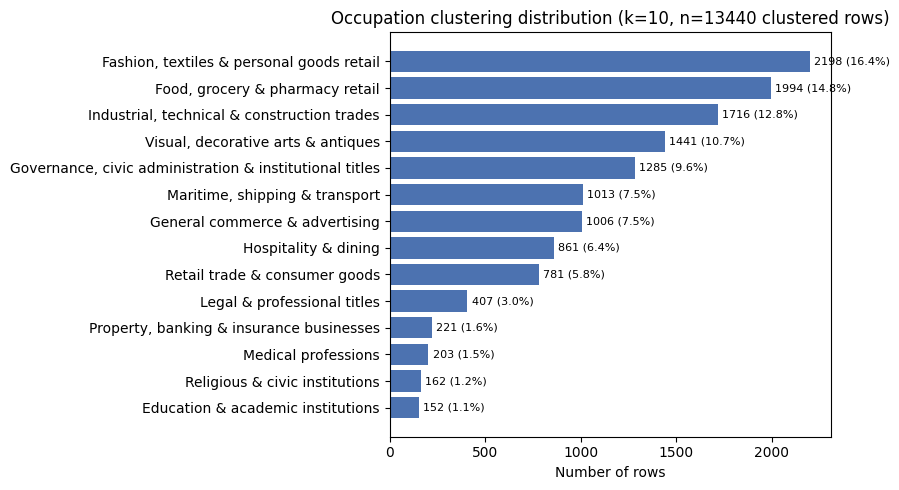

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_category_distribution_k10_20260824_161514.png
Saved figure: stats_geo_analysis/occupation_category_distribution_k10.png
                                               Category  Rows  % of categorized
              Fashion, textiles & personal goods retail  2198              16.4
                        Food, grocery & pharmacy retail  1994              14.8
            Industrial, technical & construction trades  1716              12.8
                     Visual, decorative arts & antiques  1441              10.7
Governance, civic administration & institutional titles  1285               9.6
                         Maritime, shipping & transport  1013               7.5
                         General commerce & advertising  1006               7.5
                                   Hospitality & dining   861               6.4
                          Retail trade & consumer goods   781             

In [97]:
# figures & tables -- k=10 occupation category distribution

occ_cat_counts_k10_sorted = geo["occupation_category_k10"].value_counts().sort_values(ascending=True)
has_category = geo["occupation_category_k10"].notna().sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(occ_cat_counts_k10_sorted.index, occ_cat_counts_k10_sorted.values, color="#4C72B0")
ax.set_xlabel("Number of rows")
ax.set_title(f"Occupation clustering distribution (k=10, n={has_category} clustered rows)")
for bar, val in zip(bars, occ_cat_counts_k10_sorted.values):
    ax.text(val + max(occ_cat_counts_k10_sorted.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{val} ({100*val/has_category:.1f}%)", va="center", fontsize=8)
plt.tight_layout()

fig_path = "occupation_category_distribution_k10.png"
plt.savefig(fig_path, dpi=150)
plt.show()

with open(fig_path, "rb") as f:
    upload_to_stats(fig_path, f.read(), "image/png", subfolder="occupation_clustering")
print(f"Saved figure: stats_geo_analysis/{fig_path}")

summary_table_occ_k10 = pd.DataFrame({
    "Category": occ_cat_counts_k10_sorted.index[::-1],
    "Rows": occ_cat_counts_k10_sorted.values[::-1],
    "% of categorized": (100 * occ_cat_counts_k10_sorted.values[::-1] / has_category).round(1),
})
print(summary_table_occ_k10.to_string(index=False))

csv_bytes = summary_table_occ_k10.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_category_table_k10.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")
print(f"\nSaved: stats_geo_analysis/occupation_category_table_k10.csv")


13440 classified out of 16469 total (81.6%)
occupation_category_k10
Fashion, textiles & personal goods retail                  2198
Food, grocery & pharmacy retail                            1994
Industrial, technical & construction trades                1716
Visual, decorative arts & antiques                         1441
Governance, civic administration & institutional titles    1285
Maritime, shipping & transport                             1013
General commerce & advertising                             1006
Hospitality & dining                                        861
Retail trade & consumer goods                               781
Legal & professional titles                                 407
Property, banking & insurance businesses                    221
Medical professions                                         203
Religious & civic institutions                              162
Education & academic institutions                           152

Shared window (same as the overall 

/var/folders/zx/y690zk891278q0tkfsym931c0000gn/T/ipykernel_11570/3360667396.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  "Blues_dark", plt.cm.get_cmap("Blues")(np.linspace(0.25, 1.0, 256))


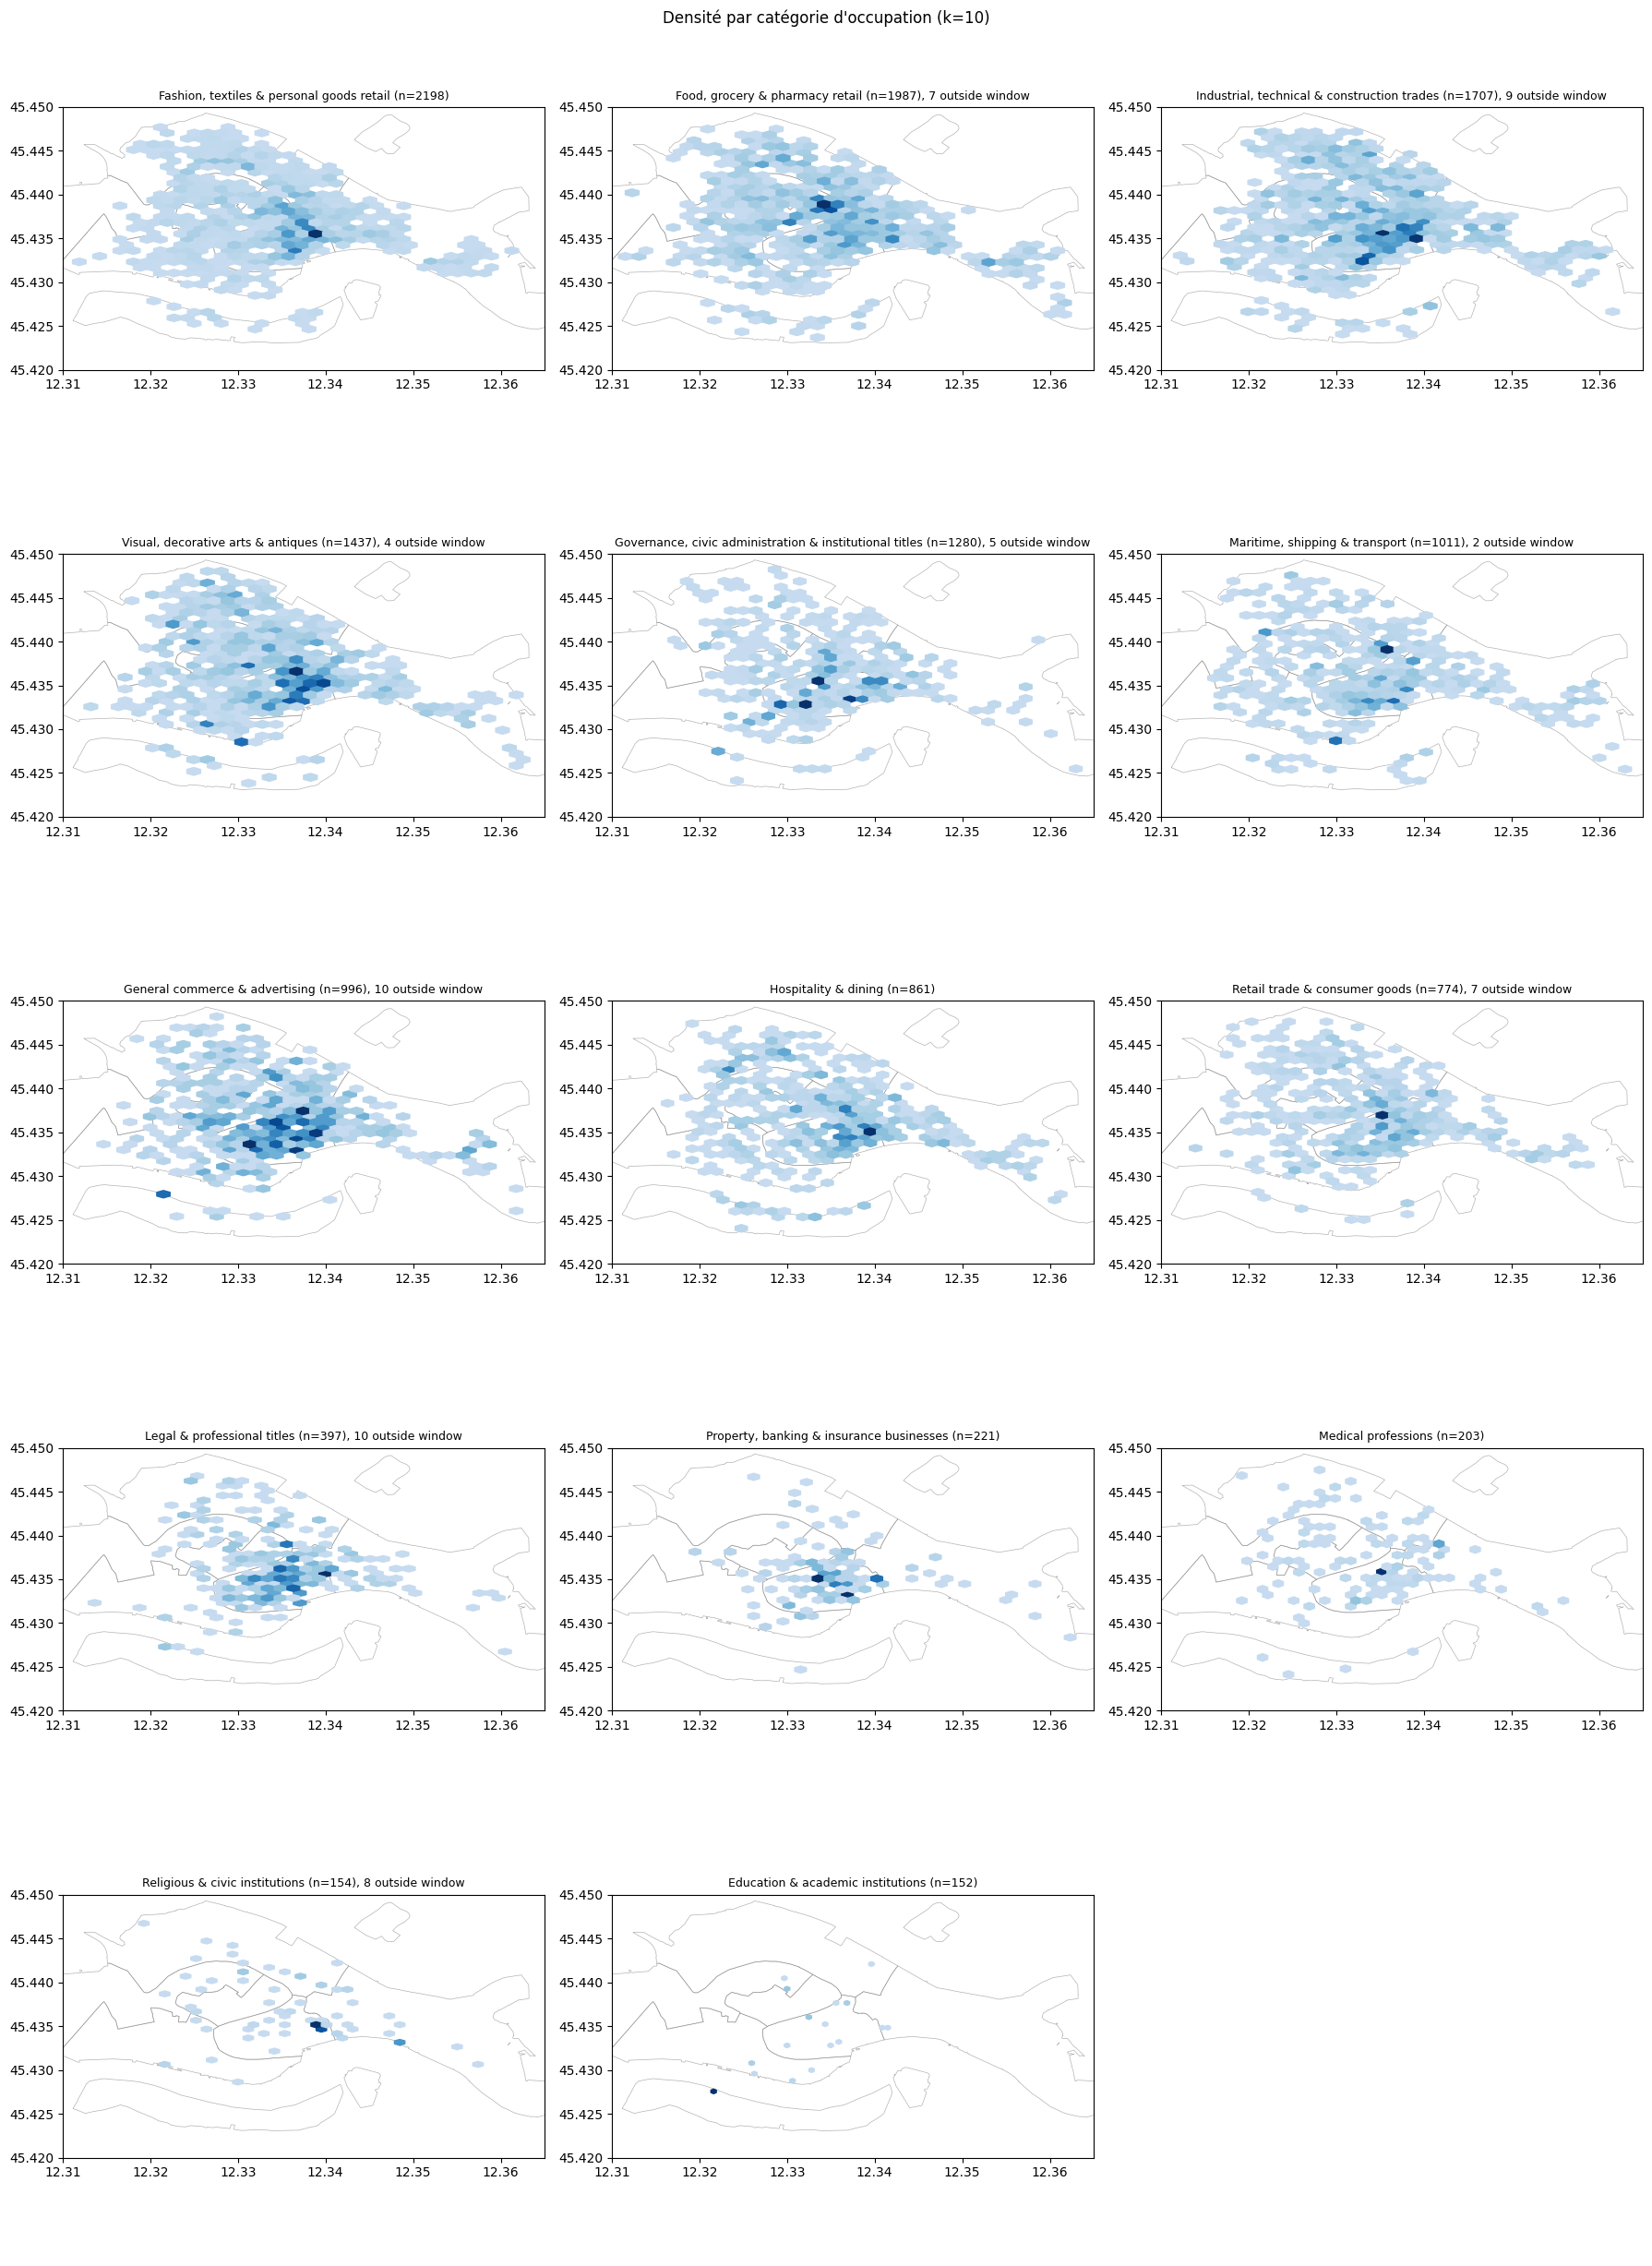

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: heatmap_occupation_category_k10_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_category_direct_k10_coverage_20260824_161514.csv


In [79]:
# density heatmaps by occupation category (k=10)

col = "occupation_category_k10"
geo_occ_direct = geo[geo[col].notna()].copy()
print(f"{len(geo_occ_direct)} classified out of {len(geo)} total ({100*len(geo_occ_direct)/len(geo):.1f}%)")

occ_class_counts_direct = geo_occ_direct[col].value_counts()
print(occ_class_counts_direct.to_string())

# same window as the overall density map, shared across every heatmap figure in this chapter
lon_min, lon_max = HEATMAP_LON_MIN, HEATMAP_LON_MAX
lat_min, lat_max = HEATMAP_LAT_MIN, HEATMAP_LAT_MAX
print(f"\nShared window (same as the overall density map): lon [{lon_min:.4f}, {lon_max:.4f}], "
      f"lat [{lat_min:.4f}, {lat_max:.4f}]")

# sestiere outline for context, reprojected to match matched_lon/matched_lat (EPSG:4326)
sestieri = gpd.read_file(SESTIERE_PATH).to_crs(epsg=4326)

# same method as the HEXAGON SIZE cell (median nearest-neighbor spacing), but derived from the sparsest category's own points, not the full dataset
# reusing the full-dataset spacing made hexagons too small to render for sparse categories
def _median_nn_spacing_m_occ(pts):
    lat0 = pts["matched_lat"].mean()
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat0))
    xy = np.column_stack([
        pts["matched_lon"].to_numpy() * m_per_deg_lon,
        pts["matched_lat"].to_numpy() * m_per_deg_lat,
    ])
    tree = cKDTree(xy)
    nn_dist, _ = tree.query(xy, k=2)
    return float(np.median(nn_dist[:, 1]))

_class_spacings_occ = {}
for _cls in occ_class_counts_direct.index:
    _sub_cls = geo_occ_direct[geo_occ_direct[col] == _cls]
    _pts_cls = _sub_cls[
        _sub_cls["matched_lon"].between(lon_min, lon_max) & _sub_cls["matched_lat"].between(lat_min, lat_max)
    ].drop_duplicates(subset=["matched_lat", "matched_lon"])
    if len(_pts_cls) >= 2:
        _class_spacings_occ[_cls] = _median_nn_spacing_m_occ(_pts_cls)

_sparsest_cls = max(_class_spacings_occ, key=_class_spacings_occ.get)
target_hex_width_m_occ = _class_spacings_occ[_sparsest_cls]
_m_per_deg_lon_occ = 111_320 * math.cos(math.radians(geo_occ_direct["matched_lat"].mean()))
_extent_m_occ = (lon_max - lon_min) * _m_per_deg_lon_occ
GRIDSIZE_OCC_PANEL = int(round(_extent_m_occ / target_hex_width_m_occ))
print(f"Most spatially spread class: {_sparsest_cls!r} (spacing={target_hex_width_m_occ:.1f}m) -> gridsize={GRIDSIZE_OCC_PANEL}")

# darkened Blues -- default cmap left the sparsest bins near-white and hard to read
cmap_dark_occ = mcolors.LinearSegmentedColormap.from_list(
    "Blues_dark", plt.cm.get_cmap("Blues")(np.linspace(0.25, 1.0, 256))
)

classes = occ_class_counts_direct.index.tolist()
n_cols = 3
n_rows = -(-len(classes) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sub = geo_occ_direct[geo_occ_direct[col] == cls]
    in_window = sub[
        sub["matched_lon"].between(lon_min, lon_max) & sub["matched_lat"].between(lat_min, lat_max)
    ]
    n_dropped = len(sub) - len(in_window)
    sestieri.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.6, zorder=0)
    ax.hexbin(in_window["matched_lon"], in_window["matched_lat"], gridsize=GRIDSIZE_OCC_PANEL, cmap=cmap_dark_occ, mincnt=1, zorder=1)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect("equal")
    title = f"{cls} (n={len(in_window)})"
    if n_dropped:
        title += f", {n_dropped} outside window"
    ax.set_title(title, fontsize=9)

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Densité par catégorie d'occupation (k=10)")
plt.tight_layout()
out_name = _v("heatmap_occupation_category_k10.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("heatmap_occupation_category_k10.png", f.read(), "image/png", subfolder="occupation_clustering")

csv_bytes = occ_class_counts_direct.reset_index().rename(
    columns={"index": "occupation_category", col: "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_category_direct_k10_coverage.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

13440 categorized rows out of 16469 total inside-Venice rows.


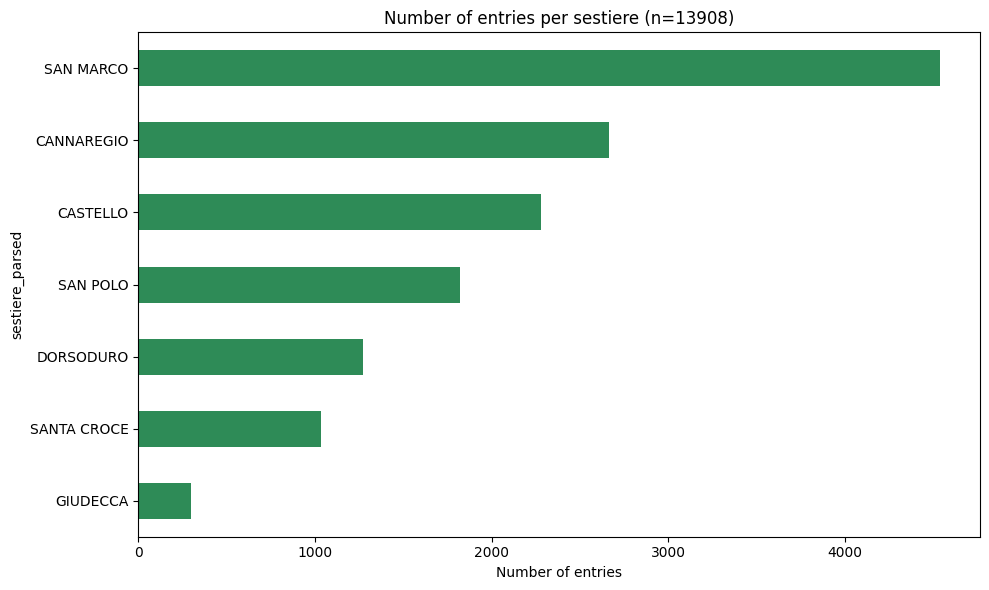

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_sestiere_counts_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_sestiere_counts_20260824_161514.csv


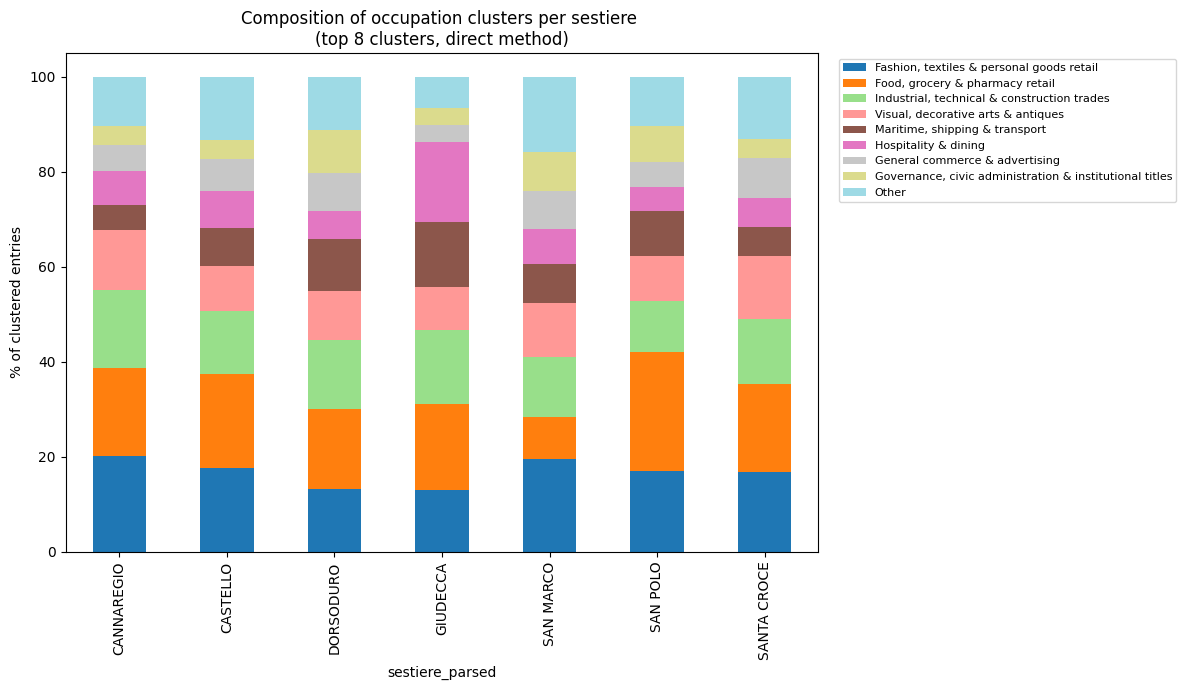

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_sestiere_composition_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_sestiere_composition_20260824_161514.csv


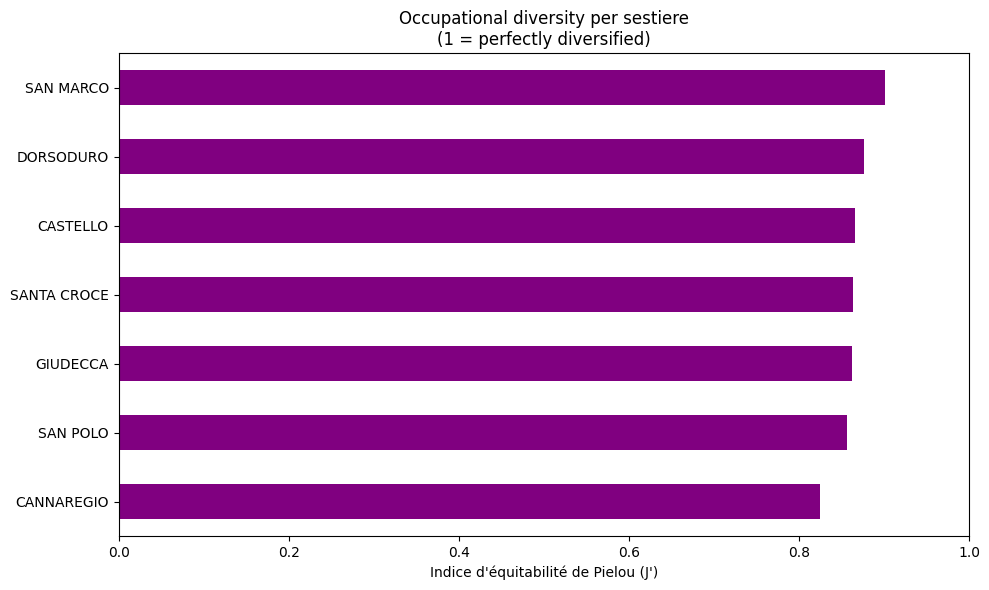

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_pielou_by_sestiere_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_pielou_by_sestiere_20260824_161514.csv

Pielou evenness by sestiere:
CANNAREGIO     0.824997
SAN POLO       0.856522
GIUDECCA       0.861833
SANTA CROCE    0.863078
CASTELLO       0.865981
DORSODURO      0.876294
SAN MARCO      0.901093

=== SESTIERE-LEVEL FIGURES DONE ===


In [104]:
# sestiere-level figures -- counts, composition, Pielou diversity, on occupation_category_k10 (direct method)
# overall density and per-category heatmaps for sestiere-level stats only

if "occupation_category_k10" not in geo.columns:
    raise RuntimeError("`occupation_category_k10` not found -- run the occupation naming cell (ee813d46) first.")

geo_occ_cat = geo[geo["occupation_category_k10"].notna()].copy()
print(f"{len(geo_occ_cat)} categorized rows out of {len(geo)} total inside-Venice rows.")

# sestiere counts

if "sestiere_parsed" in geo.columns:
    geo_sest = geo[geo["sestiere_parsed"].notna()].copy()
    sest_counts = geo_sest["sestiere_parsed"].value_counts()

    fig, ax = plt.subplots(figsize=(10, 6))
    sest_counts.sort_values().plot(kind="barh", ax=ax, color="seagreen")
    ax.set_xlabel("Number of entries")
    ax.set_title(f"Number of entries per sestiere (n={len(geo_sest)})")
    plt.tight_layout()
    plt.savefig(_v("occupation_sestiere_counts.png"), dpi=200)
    plt.show()
    with open(_v("occupation_sestiere_counts.png"), "rb") as f:
        upload_to_stats("occupation_sestiere_counts.png", f.read(), "image/png", subfolder="occupation_clustering")
    upload_to_stats("occupation_sestiere_counts.csv",
                     sest_counts.reset_index().to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_clustering")
else:
    print("WARNING: 'sestiere_parsed' not found -- skipping sestiere counts.")
    geo_sest = None

# sestiere x occupation-category composition

if geo_sest is not None:
    geo_sest_cat = geo_sest[geo_sest["occupation_category_k10"].notna()]
    comp = pd.crosstab(geo_sest_cat["sestiere_parsed"], geo_sest_cat["occupation_category_k10"], normalize="index") * 100

    top_comp_cats = geo_sest_cat["occupation_category_k10"].value_counts().head(8).index.tolist()
    comp_plot = comp[top_comp_cats].copy()
    comp_plot["Other"] = 100 - comp_plot.sum(axis=1)

    fig, ax = plt.subplots(figsize=(12, 7))
    comp_plot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_ylabel("% of clustered entries")
    ax.set_title("Composition of occupation clusters per sestiere \n(top 8 clusters, direct method)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(_v("occupation_sestiere_composition.png"), dpi=200)
    plt.show()
    with open(_v("occupation_sestiere_composition.png"), "rb") as f:
        upload_to_stats("occupation_sestiere_composition.png", f.read(), "image/png", subfolder="occupation_clustering")

    csv_bytes = comp.reset_index().to_csv(index=False).encode("utf-8")
    upload_to_stats("occupation_sestiere_composition.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")
else:
    geo_sest_cat = None

# Pielou evenness index per sestiere

if geo_sest_cat is not None:
    pielou_scores = {}
    for sest, group in geo_sest_cat.groupby("sestiere_parsed"):
        counts = group["occupation_category_k10"].value_counts()
        S = len(counts)
        if S <= 1:
            pielou_scores[sest] = np.nan
            continue
        p = counts / counts.sum()
        H = -np.sum(p * np.log(p))
        pielou_scores[sest] = H / np.log(S)

    pielou_df = pd.Series(pielou_scores).sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    pielou_df.plot(kind="barh", ax=ax, color="purple")
    ax.set_xlabel("Indice d'équitabilité de Pielou (J')")
    ax.set_xlim(0, 1)
    ax.set_title("Occupational diversity per sestiere\n(1 = perfectly diversified)")
    plt.tight_layout()
    plt.savefig(_v("occupation_pielou_by_sestiere.png"), dpi=200)
    plt.show()
    with open(_v("occupation_pielou_by_sestiere.png"), "rb") as f:
        upload_to_stats("occupation_pielou_by_sestiere.png", f.read(), "image/png", subfolder="occupation_clustering")

    csv_bytes = pielou_df.reset_index().rename(
        columns={"index": "sestiere", 0: "pielou_j"}
    ).to_csv(index=False).encode("utf-8")
    upload_to_stats("occupation_pielou_by_sestiere.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

    print("\nPielou evenness by sestiere:")
    print(pielou_df.to_string())

print("\n=== SESTIERE-LEVEL FIGURES DONE ===")


In [81]:
# dense-cluster analysis (occupation, direct method) -- top repeated
# coordinates per occupation, with sample names

TOP_N_HOTSPOTS = 3
TOP_N_NAMES = 5

hotspot_rows_occ_direct = []
for cls in geo_occ_direct["occupation_category_k10"].value_counts().index:
    sub = geo_occ_direct[geo_occ_direct["occupation_category_k10"] == cls]
    hotspots = sub.groupby(["matched_lat", "matched_lon"]).agg(
        n=("Name", "size"), address=("Address", "first"),
    ).reset_index().sort_values("n", ascending=False).head(TOP_N_HOTSPOTS)

    print(f"\n{cls} (n={len(sub)})")
    for _, row in hotspots.iterrows():
        pt = sub[(sub["matched_lat"] == row["matched_lat"]) & (sub["matched_lon"] == row["matched_lon"])]
        names = pt["Name"].head(TOP_N_NAMES).tolist()
        print(f"  {row['address']:<40} {int(row['n']):>4} entries  e.g. {names}")
        names_str = " | ".join(str(n) if pd.notna(n) else "(no name)" for n in names)
        hotspot_rows_occ_direct.append({
            "occupation_category": cls, "address": row["address"],
            "lat": row["matched_lat"], "lon": row["matched_lon"],
            "n_entries": int(row["n"]), "sample_names": names_str,
        })

hotspot_df_occ_direct = pd.DataFrame(hotspot_rows_occ_direct)
csv_bytes = hotspot_df_occ_direct.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_direct_k10_hotspots.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")



Fashion, textiles & personal goods retail (n=2198)
  S. Marco 5177                               8 entries  e.g. ['Bagiolato Umberto', 'Bagiolotto Umberto', 'Bagiottuto Umberto', 'Bagliotto Attilio', 'Bonotto Pierina']
  S. Marco 287                                6 entries  e.g. ['S.A.M, Miola', 'Successori P. Graziotto', 'S. A. Miola (Soc. a. r. I.)', 'Tessilmola S. I. I.', 'Valli Fermo']
  S. Marco 1218                               5 entries  e.g. ['Polotto Giuseppe', 'Cioni Piganton Evelina', 'Gioni Pignaton Evelyna', 'Cioni Evelina', 'Polato Gìuseppe']

Food, grocery & pharmacy retail (n=1994)
  Riva degli Schiavoni 4119                   8 entries  e.g. ['Mazzarini Giuseppe', 'Maestrello Virginia', 'Bagagioli Mario', 'Cigana Emma', 'Cigana Emma']
  Cannaregio 6025                             8 entries  e.g. ['Pellegrinotti Mario', 'Pellegrinotti G. e C.', 'Pellegrinotti Mario', 'Pellegrinotti Mario (ditta) Soc. a. r. l.', 'Pellegrinotti Mario (ditta)']
  Via Garibaldi 1812     

In [82]:
# tokenisation of labels -- LLM canonicalization (occupation), same method as the Category cell above
# maps each raw value to a short canonical label via an LLM, compared against direct clustering, not a replacement
CHAT_MODEL_OCC = "gpt-4o-mini"
CANONICALIZE_BATCH_SIZE = 25
CANONICALIZE_MAX_RETRIES = 5

# no ADVERTISEMENT/GARBAGE option here, unlike Category -- occupation is already cleaned, and that escape hatch produced false positives on real content (Vendita e Mobilizzi, al Porto di Venezia, etc.)
# every value gets a real canonical label now, no exclusion path
CANONICALIZE_PROMPT_HEADER = (
    "You are helping classify entries from a 1947 Venetian commercial almanac. "
    "For each numbered term below (a business trade/category label, sometimes OCR-corrupted), "
    "output a SHORT canonical label (2-4 words, Italian or English, whichever is clearer) "
    "naming the general trade, profession, or institution type it represents -- e.g. "
    "'tailor', 'grocer', 'religious institution/clergy', 'shipping company', "
    "'construction trade', 'medical profession', 'government/civic institution', "
    "'legal profession'. Every entry has a genuine underlying trade/profession/institution "
    "type, even if the wording is unusual or OCR-garbled -- always output your best label for "
    "what it most likely represents. "
    "Reply with ONLY a numbered list matching the input numbering, one label per line, "
    "no other text.\n\n"
)

_NUMBERED_LINE_RE_OCC = re.compile(r"^\d+[\.\)]\s*(.+)$")

def canonicalize_batch_with_retry_occ(batch, max_retries=CANONICALIZE_MAX_RETRIES):
    numbered_input = "\n".join(f"{i+1}. {v}" for i, v in enumerate(batch))
    prompt = CANONICALIZE_PROMPT_HEADER + numbered_input
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=CHAT_MODEL_OCC,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
            )
            raw = resp.choices[0].message.content.strip()
            lines = [l.strip() for l in raw.splitlines() if l.strip()]
            labels = []
            for line in lines:
                m = _NUMBERED_LINE_RE_OCC.match(line)
                labels.append(m.group(1).strip() if m else line)
            if len(labels) != len(batch):
                raise ValueError(f"Expected {len(batch)} labels, got {len(labels)}: {labels}")
            return labels
        except Exception as e:
            wait = 2 ** attempt
            print(f"    Error (attempt {attempt+1}/{max_retries}): {e}. Retrying in {wait}s...")
            time.sleep(wait)
    raise RuntimeError(f"Failed after {max_retries} retries on batch starting with: {batch[0]!r}")

# same address-like filter as the AGGREGATE cell below, applied here so addresses never reach the LLM
ADDRESS_LIKE_PATTERN_OCC = re.compile(
    r"^(Torcello|Venezia|VENEZIA|Cannaregio|Castello|Giudecca|Murano|Burano|"
    r"Mestre|Padova|Portogruaro|Cavarzere|Noale|MILANO|Chioggia|"
    r"S\. [A-ZÀ-Ú][a-zà-ú]+( \d|,|$)|S\. (Marco|Polo|Elena|Croce|Angelo|Fosca|Trovaso|Moisè|Luca|Samuele)( |$|,)|"
    r"Rialto|Riva |Via |Piazza |P\.za |P\.le |Calle |Campo |Rio |Ponte |Fondamenta |Sottoportico |"
    r"Telefono|Telef\.|numero \d|^\d|Piazzale)",
    re.I,
)

_is_addr = [bool(ADDRESS_LIKE_PATTERN_OCC.search(v)) for v in occ_unique_values]
occ_unique_values_filtered = [v for v, a in zip(occ_unique_values, _is_addr) if not a]
occ_value_counts_filtered = occ_value_counts[~pd.Series(_is_addr, index=occ_value_counts.index).values]
print(f"{sum(_is_addr)} address-like values dropped before canonicalization "
      f"({occ_value_counts[_is_addr].sum() if any(_is_addr) else 0} rows).")

print(f"{len(occ_unique_values_filtered)} unique occupation values to canonicalize "
      f"(covering {occ_value_counts_filtered.sum()} total rows).")

_occ_canon_cache = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_canonical_label_map.csv"
_occ_canon_cached_valid = False
if _occ_canon_cache.exists():
    _cached_map_df_occ = pd.read_csv(_occ_canon_cache)
    _cached_lookup_occ = dict(zip(_cached_map_df_occ["occupation"], _cached_map_df_occ["canonical_label"]))
    _missing_occ = set(occ_unique_values_filtered) - set(_cached_lookup_occ)
    if not _missing_occ:
        canonical_labels_occ = [_cached_lookup_occ[v] for v in occ_unique_values_filtered]
        _map_df_occ = pd.DataFrame({
            "occupation": occ_unique_values_filtered,
            "frequency": occ_value_counts_filtered.values,
            "canonical_label": canonical_labels_occ,
        })
        _occ_canon_cached_valid = True
        print(f"All {len(occ_unique_values_filtered)} current values already have a cached "
              f"canonical label in {_occ_canon_cache.name} -- no API calls made.")
    else:
        print(f"Cache at {_occ_canon_cache.name} is missing {len(_missing_occ)} of "
              f"{len(occ_unique_values_filtered)} current values -- recomputing.")

if not _occ_canon_cached_valid:
    canonical_labels_occ = []
    for i in range(0, len(occ_unique_values_filtered), CANONICALIZE_BATCH_SIZE):
        batch = occ_unique_values_filtered[i:i + CANONICALIZE_BATCH_SIZE]
        batch_labels = canonicalize_batch_with_retry_occ(batch)
        canonical_labels_occ.extend(batch_labels)
        print(f"  Canonicalized {min(i + CANONICALIZE_BATCH_SIZE, len(occ_unique_values_filtered))}/{len(occ_unique_values_filtered)}")

    _map_df_occ = pd.DataFrame({
        "occupation": occ_unique_values_filtered,
        "frequency": occ_value_counts_filtered.values,
        "canonical_label": canonical_labels_occ,
    })
    _map_df_occ.to_csv(_occ_canon_cache, index=False)

canonical_label_map_occ = dict(zip(occ_unique_values_filtered, canonical_labels_occ))
csv_bytes = _map_df_occ.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_canonical_label_map.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

print(f"\nSample of canonicalization (first 20):")
print(_map_df_occ.head(20).to_string(index=False))
print(f"\nSaved: stats_geo_analysis/occupation_canonical_label_map.csv")


102 address-like values dropped before canonicalization (131 rows).
3569 unique occupation values to canonicalize (covering 13521 total rows).
All 3569 current values already have a cached canonical label in occupation_canonical_label_map.csv -- no API calls made.
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_canonical_label_map_20260824_161514.csv

Sample of canonicalization (first 20):
          occupation  frequency          canonical_label
Agenzie di trasporto        323         Shipping company
   Camicerie da uomo        238         Men's shirt shop
   Medicina generale        222         General medicine
           Trattorie        177               Trattorias
 Vendita e Mobilizzi        159   Sales and mobilization
   CIMITERI COMUNALI        139     Municipal cemeteries
          Alimentari        137            Grocery store
 al Porto di Venezia        119           Port of Venice
             Attuari        111                actuaries

In [83]:
# aggregate + embed + cluster + pin -- occupation tokenised k=10, reference: occupation_tokenised_clusters_k10_reference.csv
# aggregation always runs (cheap); embedding+clustering skipped if the canonical-label set is unchanged

_map_df_occ["frequency"] = _map_df_occ["frequency"].astype(int)

occ_canon_freq_df = (
    _map_df_occ.groupby("canonical_label", as_index=False)["frequency"].sum()
    .sort_values("frequency", ascending=False)
)
print(f"{len(occ_canon_freq_df)} distinct canonical labels covering "
      f"{int(occ_canon_freq_df['frequency'].sum())} rows "
      f"(down from {len(occ_unique_values_filtered)} unique values canonicalized).")
print(occ_canon_freq_df.head(30).to_string(index=False))

occ_canon_unique_labels = occ_canon_freq_df["canonical_label"].tolist()

REGENERATE_REFERENCE_CANON_OCC = False
REFERENCE_CLUSTER_FILE_CANON_OCC = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_tokenised_clusters_k10_reference.csv"

_need_compute = True
if not REGENERATE_REFERENCE_CANON_OCC and REFERENCE_CLUSTER_FILE_CANON_OCC.exists():
    reference_df_canon_occ = pd.read_csv(REFERENCE_CLUSTER_FILE_CANON_OCC)
    if set(reference_df_canon_occ["canonical_label"]) == set(occ_canon_unique_labels):
        print(f"Label set unchanged ({len(occ_canon_unique_labels)} labels match the reference exactly) "
              f"-- skipping embedding and KMeans, loading the pinned reference directly.")
        occ_canon_cluster_df = reference_df_canon_occ.copy()
        _need_compute = False

if _need_compute:
    _occ_canon_emb_cache = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_canonical_embeddings_cache.npy"
    _occ_canon_emb_values_cache = STATS_LOCAL_DIR / "reference" / "occupation" / "occupation_canonical_embeddings_values.csv"
    occ_canon_embeddings = None
    if _occ_canon_emb_cache.exists() and _occ_canon_emb_values_cache.exists():
        _cached_occ_canon_values = pd.read_csv(_occ_canon_emb_values_cache)["value"].tolist()
        if _cached_occ_canon_values == occ_canon_unique_labels:
            occ_canon_embeddings = np.load(_occ_canon_emb_cache)
            print(f"Loaded cached embeddings -> {occ_canon_embeddings.shape}, no API calls made.")
        else:
            print("Cached values don't match current occ_canon_unique_labels -- recomputing.")
    if occ_canon_embeddings is None:
        occ_canon_embeddings = []
        for i in range(0, len(occ_canon_unique_labels), BATCH_SIZE):
            batch = occ_canon_unique_labels[i:i + BATCH_SIZE]
            batch_embeddings = embed_batch_with_retry(batch)
            occ_canon_embeddings.extend(batch_embeddings)
            print(f"  Embedded {min(i + BATCH_SIZE, len(occ_canon_unique_labels))}/{len(occ_canon_unique_labels)}")
        occ_canon_embeddings = np.array(occ_canon_embeddings)
        np.save(_occ_canon_emb_cache, occ_canon_embeddings)
        pd.DataFrame({"value": occ_canon_unique_labels}).to_csv(_occ_canon_emb_values_cache, index=False)
        print(f"Embedding matrix shape: {occ_canon_embeddings.shape}")

    N_CLUSTERS_CANON_OCC = 10
    kmeans_canon_occ = KMeans(n_clusters=N_CLUSTERS_CANON_OCC, random_state=42, n_init=10)
    occ_canon_cluster_labels = kmeans_canon_occ.fit_predict(occ_canon_embeddings)
    occ_canon_cluster_df = pd.DataFrame({
        "canonical_label": occ_canon_unique_labels,
        "frequency": occ_canon_freq_df["frequency"].values,
        "cluster_id": occ_canon_cluster_labels,
    }).sort_values(["cluster_id", "frequency"], ascending=[True, False])

    if REGENERATE_REFERENCE_CANON_OCC or not REFERENCE_CLUSTER_FILE_CANON_OCC.exists():
        if REGENERATE_REFERENCE_CANON_OCC:
            print("REGENERATE_REFERENCE_CANON_OCC=True -- overwriting the pinned reference with this run.")
        else:
            print(f"No reference file found at {REFERENCE_CLUSTER_FILE_CANON_OCC.name} -- "
                  f"bootstrapping: this run becomes the permanent reference.")
        reference_df_canon_occ = occ_canon_cluster_df.copy()
        STATS_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
        reference_df_canon_occ.to_csv(REFERENCE_CLUSTER_FILE_CANON_OCC, index=False)
        upload_to_stats("occupation_tokenised_clusters_k10_reference.csv",
                         reference_df_canon_occ.to_csv(index=False).encode("utf-8"), "text/csv", subfolder="occupation_clustering")
        print(f"Saved reference: {REFERENCE_CLUSTER_FILE_CANON_OCC.name} ({len(reference_df_canon_occ)} rows)")
    else:
        reference_map_canon_occ = dict(zip(reference_df_canon_occ["canonical_label"], reference_df_canon_occ["cluster_id"]))
        current_map_canon_occ = dict(zip(occ_canon_cluster_df["canonical_label"], occ_canon_cluster_df["cluster_id"]))
        mismatches_canon_occ = {
            c: (reference_map_canon_occ.get(c), current_map_canon_occ.get(c))
            for c in set(reference_map_canon_occ) | set(current_map_canon_occ)
            if reference_map_canon_occ.get(c) != current_map_canon_occ.get(c)
        }
        print(f"{'='*70}")
        print(f"MISMATCH -- {len(mismatches_canon_occ)} of "
              f"{len(set(reference_map_canon_occ) | set(current_map_canon_occ))} label(s) differ from the reference.")
        print("occ_canon_cluster_df is being reset to the pinned reference. "
              "Set REGENERATE_REFERENCE_CANON_OCC=True above to replace it instead.")
        print(f"{'='*70}\n")

    occ_canon_cluster_df = reference_df_canon_occ.copy()

print(f"occ_canon_cluster_df is now pinned ({len(occ_canon_cluster_df)} rows, "
      f"{occ_canon_cluster_df['cluster_id'].nunique()} clusters).")


2563 distinct canonical labels covering 13521 rows (down from 3569 unique values canonicalized).
             canonical_label  frequency
            Shipping company        355
            General medicine        319
            Men's shirt shop        238
                  Trattorias        177
      Sales and mobilization        159
               Grocery store        147
            legal profession        142
        Municipal cemeteries        139
                     Painter        124
              Port of Venice        119
                     butcher        115
                         Bar        112
                   actuaries        111
Government/civic institution        106
        Venetian specialties        104
                   Trattoria        103
              Men's clothing        102
                        café        100
          construction trade         97
                  Pharmacist         92
              Dairy products         85
                  Seams

In [84]:
# apply tokenised occupation names + corrections (k=10) -- independent naming pass, not copied from the direct method
# several categories converged with the direct method on their own (Fashion, Maritime, Visual, Governance, Medical, Legal, Religious) -- real agreement, not forced
# two genuine divergences kept as findings: industrial/electrical vs construction/carpentry split, and food retail vs wholesale split

CLUSTER_DEFAULT = {
    0: "Medical professions",
    1: "Restaurants, cafés & retail shops",
    2: "Fashion, textiles & personal goods retail",
    3: "Business & financial institutions",
    4: "Wholesale & agricultural suppliers",
    5: "Maritime, shipping & transport",
    6: "Visual, decorative arts & antiques",
    7: "Industrial & electrical trades",
    8: "Construction, carpentry & building materials",
    9: "Governance, civic administration & institutional titles",
}

OVERRIDES = {}
def route(name, *values):
    for v in values:
        OVERRIDES[v] = name

L = "Legal & accounting professions"
R = "Religious & civic institutions"
G = "Governance, civic administration & institutional titles"
E = "Education & academic institutions"
V = "Visual, decorative arts & antiques"
I = "Industrial & electrical trades"
M = "Medical professions"
F = "Fashion, textiles & personal goods retail"
W = "Wholesale & agricultural suppliers"
C = "Construction, carpentry & building materials"
H = "Restaurants, cafés & retail shops"
RE = "Business & financial institutions"

# cluster 0 -> pull legal/religious/governance/education/press/sport/pest/watchmaking out of Medical default
route(L, "legal profession", "Legal profession")
route(R, "Patriarchal Basilica of St. Mark", "Jewish community", "Clergy", "Religious institution/clergy",
      "religious institution", "Religious institution", "parishes and branches", "Religious Institution",
      "church", "clergy", "Religious Foundation", "Religion", "Theological Canons", "saintly man")
route(G, "Municipal cemeteries", "Labor", "active members", "pensions", "municipality", "component",
      "war veterans association", "police station", "public health services", "Urban sanitation",
      "Custodial services", "Court", "Criminal Procedure", "Criminal Law", "Civil Procedure",
      "Juvenile court", "Archive profession", "Archive protocol", "Archive", "Archival profession",
      "usher", "Usher", "municipal cemetery", "heritage preservation", "Heritage", "Heritage Preservation",
      "Heritage Preservation Division", "rowing club", "Olympic sports", "Alpine Club", "Alpine club",
      "Alpine Colony", "Shooting Sports Union")
route(E, "Educational Institution", "Scientific and Educational", "Education/language instruction",
      "elementary schools", "Education", "Language and literature", "English language", "French language",
      "Russian Language", "Romanian Language", "Latin Literature", "Italian Literature", "Education/Languages",
      "physical education", "scientific and teaching", "academic profession", "Mathematics", "Philology",
      "Philosophy", "Statistics", "History", "Geography", "Typing schools", "Typing School", "university",
      "university architecture institute", "university institute of architecture", "university library",
      "Academic Institution", "vocational training institute", "Education/Pedagogy", "Education/Mathematics",
      "Education/Literature", "Elementary education", "Science education", "Natural sciences", "Demography",
      "Romance Linguistics", "Semiotics", "Mineralogy and Geology", "Physics", "Architecture", "Educational shows")
route(V, "Newspapers", "newspaper", "Philatelic section", "Philately", "philatelic", "Cinema",
      "Film production", "theater", "Theaters", "Newsstand", "Publication", "Zincography")
route(I, "Pest control", "disinfection services", "Pest Control", "watchmaking", "Watchmaking", "Watches", "timekeeping")

# cluster 1 -> pull wholesale/fashion/visual/industrial out of retail-shops default
route(W, "wholesale produce", "wholesale wine", "Wholesale fruits and vegetables", "wholesaler",
      "Wine wholesaler", "wine wholesaler", "Wholesale Fish", "Dairy wholesaler", "Wholesale",
      "Wholesale trade", "Wholesale cured meats", "fish wholesaler", "Grocery Wholesale", "wholesale",
      "wholesale charcuterie", "wholesale confectionery", "wholesale food", "wholesale wines",
      "wholesalers", "cereals wholesaler", "grocery wholesaler", "paper wholesaler", "grain wholesaler",
      "liquor wholesaler", "food wholesaler", "fruit preserves wholesaler", "Lumber wholesaler",
      "Wine Wholesaler", "Wholesale produce", "Wholesale food", "Wholesale Grocer",
      "Wine and liquor wholesaler", "Coffee Importers", "coffee importers", "tobacco shop", "Tobacco shop")
route(F, "barber", "Barbers", "hairdresser", "barber shop", "Barber", "Hairdresser", "jewelry store",
      "hat shop", "Hat Shop", "Jewelry Store", "Perfume Shop", "Beauty salons", "Notions Store")
route(V, "Bookstore", "printing establishment", "Newspaper retailer", "printing house", "bookstore",
      "stationery and bookstore", "university bookstore", "antiques and bookstore", "Stationery store",
      "newspaper retail")
route(I, "hardware store", "Hardware Store", "Hardware store", "shoe factory", "Shoe Factory",
      "Furniture store", "furniture store", "electronics store", "Lighting shop", "Marelli dealer")

# cluster 3 -> dissolve entirely
route(RE, "rental agency", "real estate", "real estate company", "Insurance Company", "Credit Institutions",
      "Insurance", "insurance", "Apartment rentals", "Bank", "Real estate and agriculture",
      "Real estate agency", "Broker", "unspecified business", "Cooperator", "purchasing and management",
      "agency", "Purchasing society", "Banking institution", "Agencies and business", "Corporation",
      "commercial", "company", "partnership", "individual business", "Central offices", "Management company",
      "Real estate agency", "Real Estate Brokerage", "Commerce", "banking institution", "Real Estate",
      "Real Estate Company", "Financial institution", "Business Agency", "Joint Stock Company",
      "Business/company", "Business owner", "Business association", "management", "management company",
      "Apartment Rentals", "stock company", "Real Estate and Agricultural Purchases", "bank",
      "car rental company", "insurance company", "Mining Company", "Mining companies", "businesses",
      "business", "Real Estate Services", "Purchase of Buildings and Farms", "real estate development",
      "real estate brokerage", "Real Estate Trade", "real estate sales", "purchasing", "Business Name",
      "Corporation", "joint-stock company", "trading company", "business agency", "business association",
      "capital investment", "Business/Enterprise", "Business management", "Business Partnership",
      "Limited liability company", "Limited company", "Limited Liability Company", "International Company",
      "Insurance company", "Insurance agency", "Italian insurance company", "National interest bank",
      "Popular bank", "National Labor Bank", "Banking", "Banking profession", "banking")
route(G, "Government/civic institution", "civic institution", "civic organization", "state archive",
      "Consulates", "Government institution", "government office", "Government Agency",
      "Government Office Management", "Government Institution", "government building",
      "municipal government", "Provincial government", "Regional Office",
      "Regional Coordination Office", "City agency", "Civic authority", "Civic Consultation",
      "labor chamber", "provincial federation", "Sports Federation", "Sports organization",
      "Football Federation", "government inspection", "Municipal government", "government finance",
      "Administrative section", "tax office", "civil registry office", "General income tax office",
      "General Office", "Finance office", "Finance Department", "Finance", "Taxation",
      "Tax Inspection Office", "Tax Administration", "Regional League", "Housing authority",
      "civil and criminal court", "Civil and criminal court", "Civil Law", "succession and property office")
route(L, "accounting profession", "accounting", "Accounting profession", "Accounting",
      "Accounting and Tax Consulting", "State Accounting", "General Accounting", "Economic profession",
      "General Brokers", "General Accounting")
route(V, "publishing house", "Signs and advertising", "Advertising", "Commercial Directory", "advertising",
      "advertising agency", "press office", "Publishing Houses", "Copyright organization",
      "national press agency", "Publishing house", "Publishing Industry", "Publishing Agency Agent",
      "cinema rental agency", "Film company", "Film Rental Agency", "Entertainment industry")
route(H, "boarding house", "Hospitality industry")
route(C, "contracting and enterprises")
route(I, "industrial company", "Industry", "industrial and commercial representation")
route(W, "agricultural association", "Agricultural company", "Agricultural Enterprises",
      "Agricultural economics", "Agricultural consulate", "Agricultural Products", "Agricultural materials")

# cluster 4 -> pull chemical/fuel/industrial-raw / fashion-luxury / medical out of wholesale default
route(I, "chemical products", "Chemical Products Representative", "chemical products trade",
      "chemical products representative", "Chemical Products Representation", "chemical industry",
      "Fossil Fuels", "Mineral oils", "fuel oils", "Lubricants", "fuels", "Natural gas", "Fuels and Oils",
      "liquid fuels", "Petroleum products", "bitumen", "gasoline", "gas industry", "Fuels and Lubricants",
      "Solid and liquid fuels", "Toxic gases", "Paraffin", "Mineral Oils", "fuel company", "Fuel supplier",
      "Oil", "oils", "Oils", "Rubber products", "Cork", "Corks", "Cork Processing", "vegetable fibers",
      "Minerals", "minerals", "mineral trade", "mining and agriculture", "Sulfur", "Plastic materials",
      "Lead products", "Coatings", "Plant Fibers", "Nitrogen Fertilizers", "Dried Flax", "Stoves",
      "Various packaging", "packaging", "Packing Paper", "packaging materials", "paper products",
      "Paper bags", "chemical sales", "Chemical sales", "Drug processing", "coal (importers and producers)",
      "coal importers and producers", "Fertilizers", "Fertilizers and Pesticides", "Nitrogen Fertilizers")
route(F, "perfumery", "Perfumes", "pearls", "Pearls", "Perfumer", "Perfume processing", "Perfume",
      "perfume representative", "perfumes and related", "Cosmetics", "Hygiene Products")
route(M, "Pharmaceutical Products", "Pharmaceuticals", "pharmaceutical products", "pharmaceutical representation",
      "Pharmaceutical representation", "Pharmaceutical products", "sanitary products and pharmaceuticals",
      "herbal medicine", "Medicinal Herbs", "Antiseptic products", "antiseptic products", "Insecticides",
      "Pest control products")

# cluster 9 -> pull medical/religious/legal out of governance default
route(M, "Pharmacist", "Provincial doctors", "pharmacist", "dentist", "Surgeon", "Medical Director",
      "general practitioner")
route(R, "Parish Priest", "vicar", "Vicar", "archpriest", "parish priest")
route(L, "Lawyer", "Notary", "mediator", "accountant", "actuaries")


def _token_category(row):
    lbl = row["canonical_label"]
    if lbl in OVERRIDES:
        return OVERRIDES[lbl]
    return CLUSTER_DEFAULT[row["cluster_id"]]

occ_canon_cluster_df["category_name"] = occ_canon_cluster_df.apply(_token_category, axis=1)

n_overridden = sum(1 for l in occ_canon_cluster_df["canonical_label"] if l in OVERRIDES)
print(f"{len(OVERRIDES)} defined overrides, {n_overridden} of {len(occ_canon_cluster_df)} unique labels matched one.")

cat_totals = occ_canon_cluster_df.groupby("category_name")["frequency"].sum().sort_values(ascending=False)
cat_unique = occ_canon_cluster_df.groupby("category_name").size()
print(f"\n{'CATEGORY':<58} {'ROWS':>8} {'UNIQUE':>8}")
print("-" * 78)
for name, n in cat_totals.items():
    print(f"{name:<58} {n:>8} {cat_unique[name]:>8}")
print(f"\nTotal: {cat_totals.sum()} rows")

# --- Save corrected lookup table ---
csv_bytes = occ_canon_cluster_df.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_tokenised_clusters_k10_corrected.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

# --- Join category_name onto the full inside-Venice dataset, via the raw occupation value ---
_token_lookup = dict(zip(canonical_label_map_occ.keys(), canonical_label_map_occ.values()))
_label_to_category = dict(zip(occ_canon_cluster_df["canonical_label"], occ_canon_cluster_df["category_name"]))
geo["occupation_category_tokenised_k10"] = geo["occupation"].map(_token_lookup).map(_label_to_category)

total_rows = len(geo)
has_category_token = geo["occupation_category_tokenised_k10"].notna().sum()
print(f"\nRows with a tokenised k=10 category: {has_category_token} ({100*has_category_token/total_rows:.1f}% of {total_rows})")

print(f"\nSaved: stats_geo_analysis/occupation_tokenised_clusters_k10_corrected.csv")


439 defined overrides, 431 of 2563 unique labels matched one.

CATEGORY                                                       ROWS   UNIQUE
------------------------------------------------------------------------------
Fashion, textiles & personal goods retail                      2098      283
Restaurants, cafés & retail shops                              1839      165
Governance, civic administration & institutional titles        1379      390
Industrial & electrical trades                                 1335      336
Medical professions                                            1309      249
Maritime, shipping & transport                                 1266      195
Visual, decorative arts & antiques                             1185      285
Wholesale & agricultural suppliers                              992      216
Construction, carpentry & building materials                    782      163
Business & financial institutions                               670      203
Legal & acc

In [85]:
# categorization coverage stats (k=10) -- occupation, tokenised

n_total_labels = len(occ_canon_cluster_df)
n_categorized_labels = occ_canon_cluster_df["category_name"].notna().sum()
total_rows_clustered = occ_canon_cluster_df["frequency"].sum()
categorized_rows = occ_canon_cluster_df.loc[occ_canon_cluster_df["category_name"].notna(), "frequency"].sum()

print(f"By unique canonical label: {n_categorized_labels}/{n_total_labels} categorized "
      f"({100*n_categorized_labels/n_total_labels:.1f}%)")
print(f"By row count: {categorized_rows}/{total_rows_clustered} categorized "
      f"({100*categorized_rows/total_rows_clustered:.1f}%)")

total_geo_rows = len(geo)
has_any_occupation = geo["occupation"].notna().sum()
has_category_token = geo["occupation_category_tokenised_k10"].notna().sum()
print(f"\nRelative to full geo dataset:")
print(f"  Total rows in geo               : {total_geo_rows}")
print(f"  Rows with non-blank occupation  : {has_any_occupation} ({100*has_any_occupation/total_geo_rows:.1f}%)")
print(f"  Rows with a tokenised k=10 category: {has_category_token} ({100*has_category_token/total_geo_rows:.1f}% of all rows, "
      f"{100*has_category_token/has_any_occupation:.1f}% of rows that had an occupation at all)")


By unique canonical label: 2563/2563 categorized (100.0%)
By row count: 13521/13521 categorized (100.0%)

Relative to full geo dataset:
  Total rows in geo               : 16469
  Rows with non-blank occupation  : 13652 (82.9%)
  Rows with a tokenised k=10 category: 13521 (82.1% of all rows, 99.0% of rows that had an occupation at all)


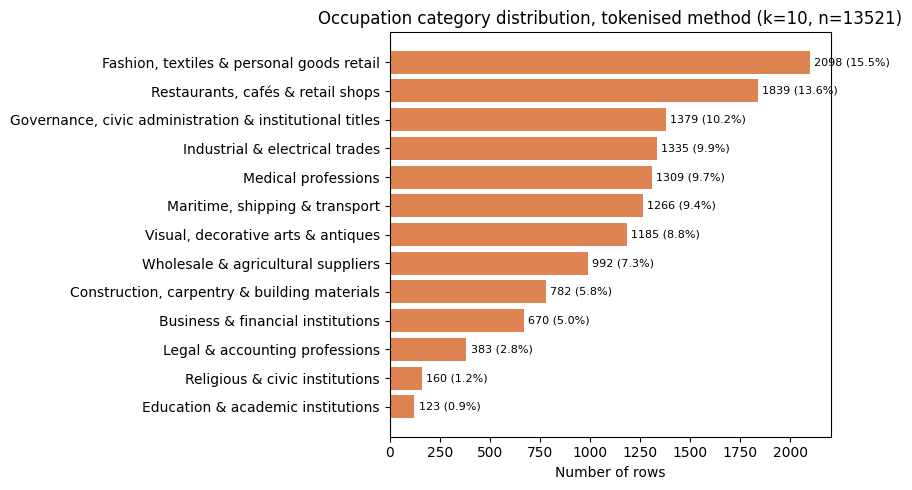

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_category_distribution_tokenised_k10_20260824_161514.png
Saved figure: stats_geo_analysis/occupation_category_distribution_tokenised_k10.png
                                               Category  Rows  % of categorized
              Fashion, textiles & personal goods retail  2098              15.5
                      Restaurants, cafés & retail shops  1839              13.6
Governance, civic administration & institutional titles  1379              10.2
                         Industrial & electrical trades  1335               9.9
                                    Medical professions  1309               9.7
                         Maritime, shipping & transport  1266               9.4
                     Visual, decorative arts & antiques  1185               8.8
                     Wholesale & agricultural suppliers   992               7.3
           Construction, carpentry & building material

In [86]:
# figures & tables -- k=10 occupation category distribution (tokenised)

occ_token_cat_counts_sorted = geo["occupation_category_tokenised_k10"].value_counts().sort_values(ascending=True)
has_category_token = geo["occupation_category_tokenised_k10"].notna().sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(occ_token_cat_counts_sorted.index, occ_token_cat_counts_sorted.values, color="#DD8452")
ax.set_xlabel("Number of rows")
ax.set_title(f"Occupation category distribution, tokenised method (k=10, n={has_category_token})")
for bar, val in zip(bars, occ_token_cat_counts_sorted.values):
    ax.text(val + max(occ_token_cat_counts_sorted.values)*0.01, bar.get_y() + bar.get_height()/2,
             f"{val} ({100*val/has_category_token:.1f}%)", va="center", fontsize=8)
plt.tight_layout()

fig_path = "occupation_category_distribution_tokenised_k10.png"
plt.savefig(fig_path, dpi=150)
plt.show()
with open(fig_path, "rb") as f:
    upload_to_stats(fig_path, f.read(), "image/png", subfolder="occupation_clustering")
print(f"Saved figure: stats_geo_analysis/{fig_path}")

summary_table_token = pd.DataFrame({
    "Category": occ_token_cat_counts_sorted.index[::-1],
    "Rows": occ_token_cat_counts_sorted.values[::-1],
    "% of categorized": (100 * occ_token_cat_counts_sorted.values[::-1] / has_category_token).round(1),
})
print(summary_table_token.to_string(index=False))
csv_bytes = summary_table_token.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_category_table_tokenised_k10.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")


13521 classified out of 16469 total (82.1%)
occupation_category_tokenised_k10
Fashion, textiles & personal goods retail                  2098
Restaurants, cafés & retail shops                          1839
Governance, civic administration & institutional titles    1379
Industrial & electrical trades                             1335
Medical professions                                        1309
Maritime, shipping & transport                             1266
Visual, decorative arts & antiques                         1185
Wholesale & agricultural suppliers                          992
Construction, carpentry & building materials                782
Business & financial institutions                           670
Legal & accounting professions                              383
Religious & civic institutions                              160
Education & academic institutions                           123
Most spatially spread class: 'Education & academic institutions' (spacing=128.1m) -> grids

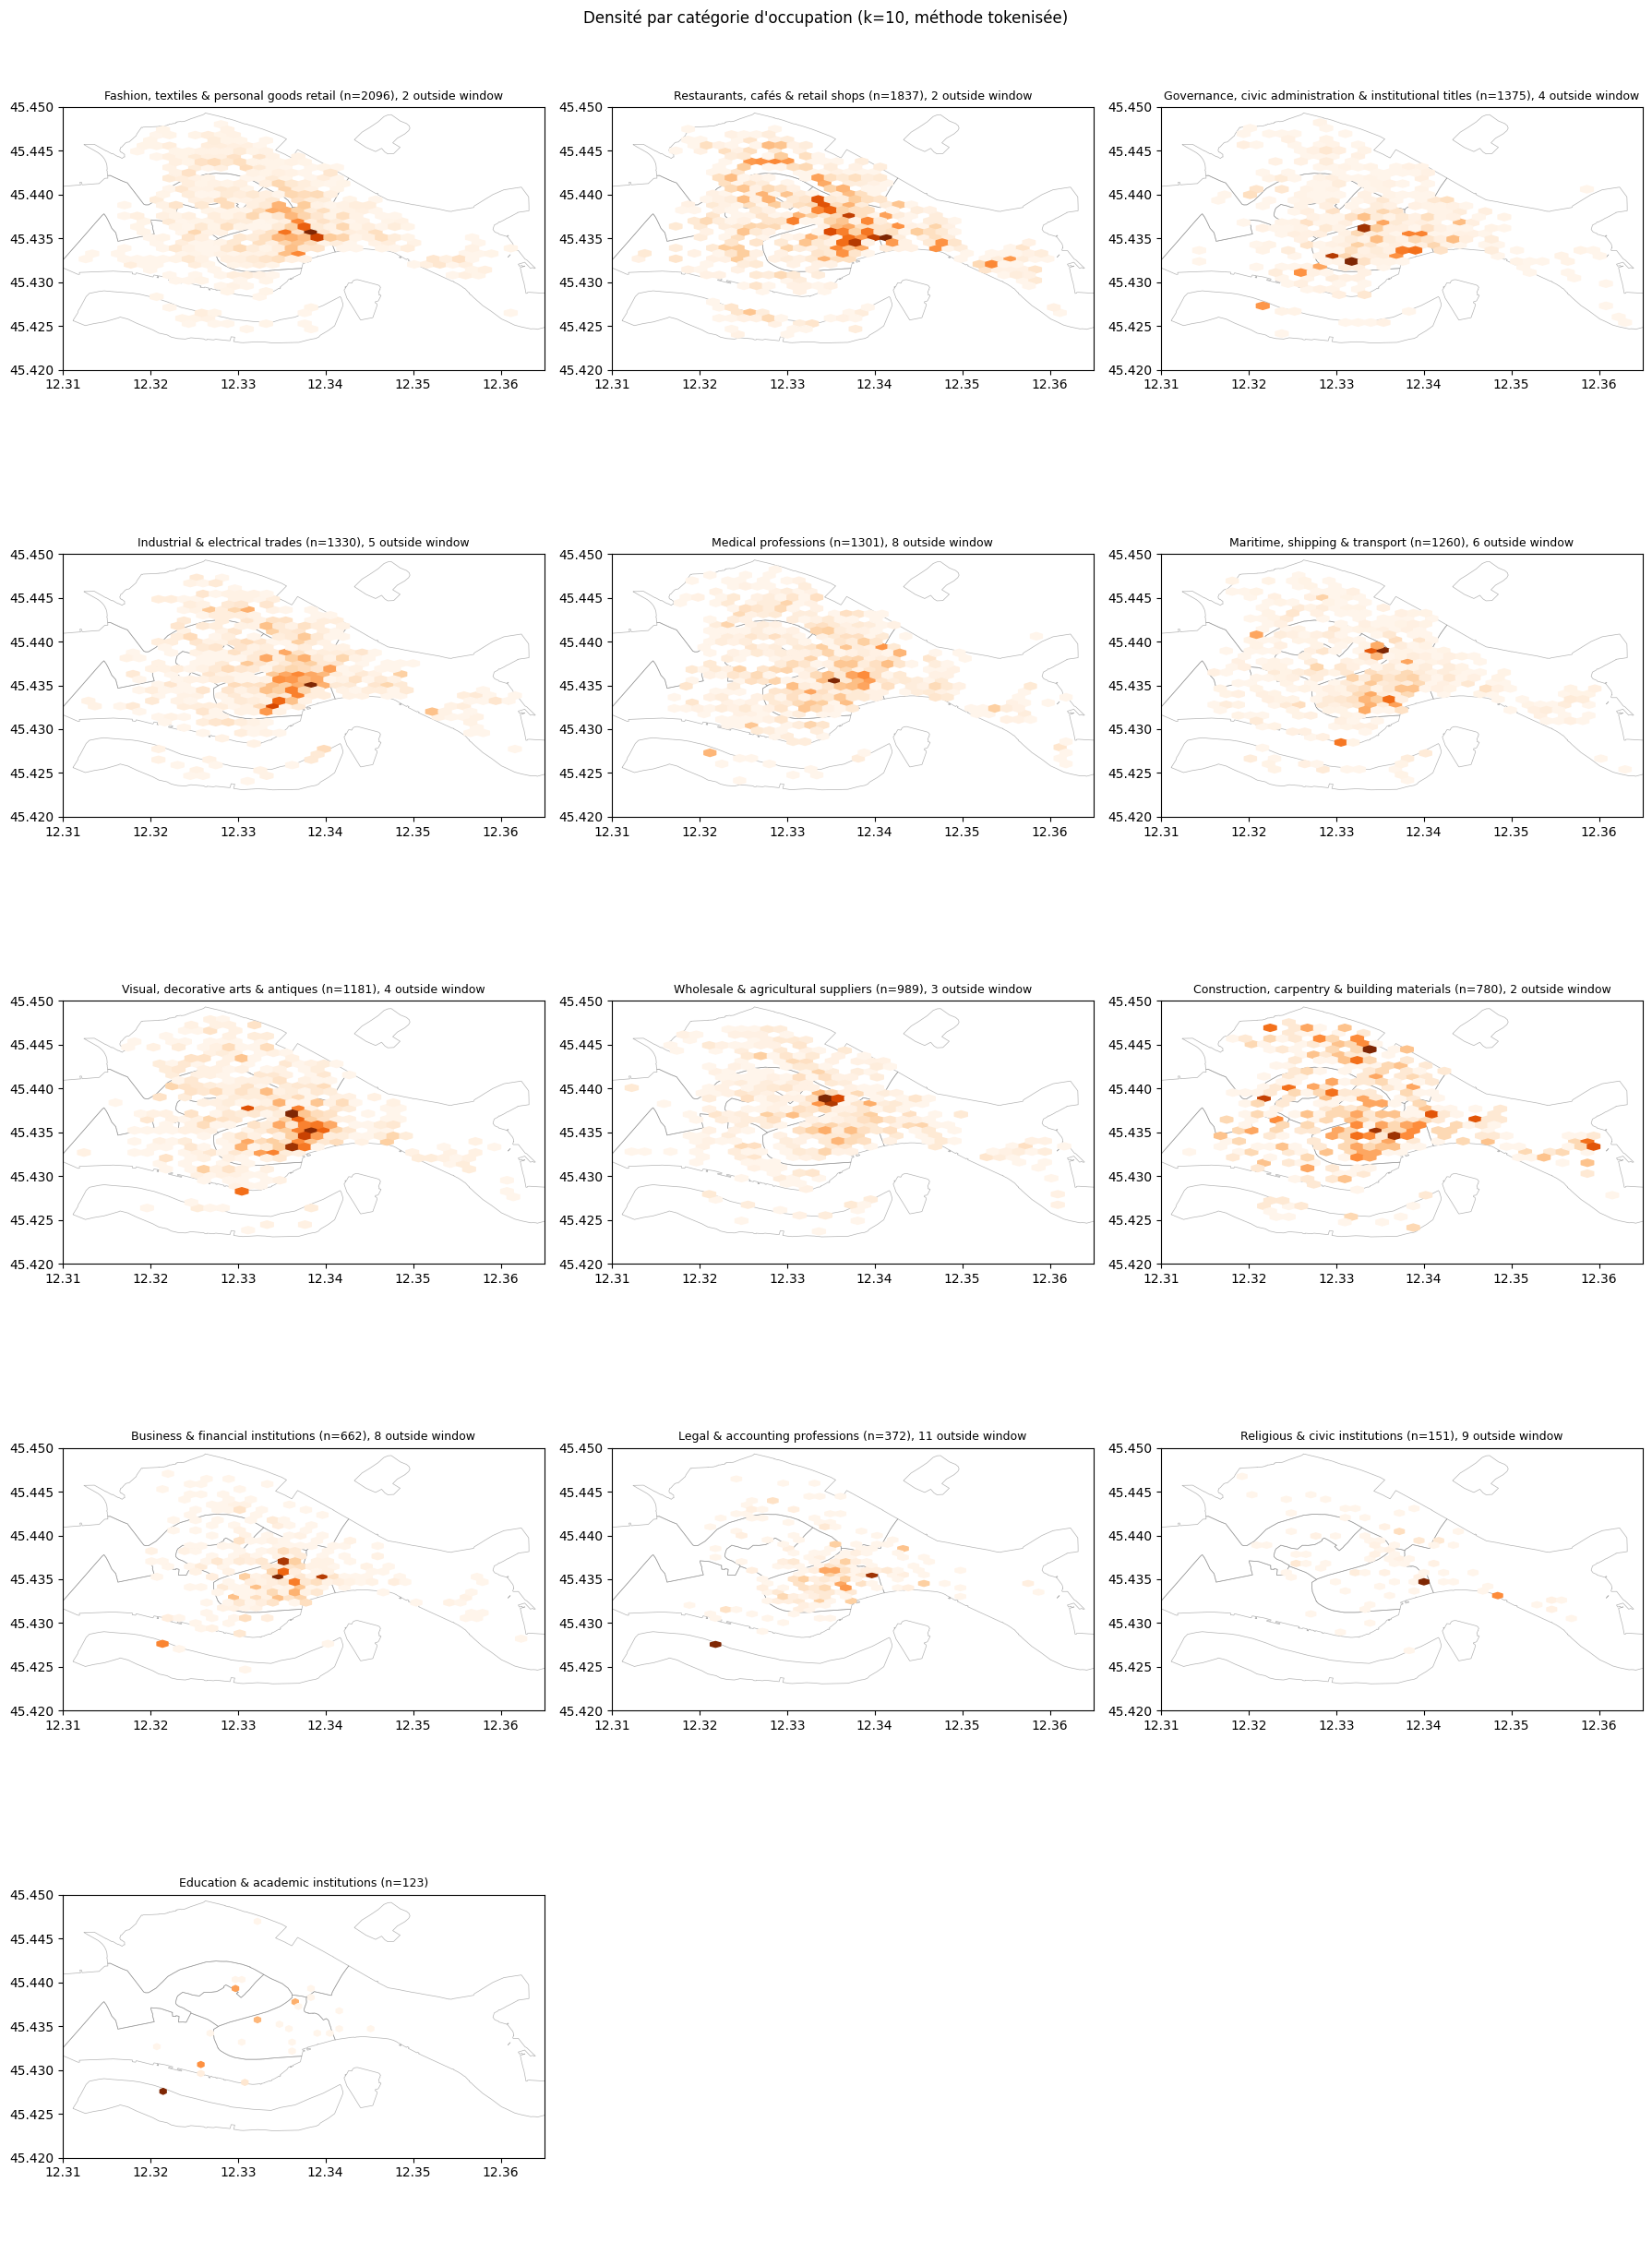

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: heatmap_occupation_category_tokenised_k10_20260824_161514.png
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_category_tokenised_k10_coverage_20260824_161514.csv


In [87]:
# density heatmaps by occupation category (k=10) -- tokenised, same gridsize method as the direct heatmap cell

col = "occupation_category_tokenised_k10"
geo_token_direct = geo[geo[col].notna()].copy()
print(f"{len(geo_token_direct)} classified out of {len(geo)} total ({100*len(geo_token_direct)/len(geo):.1f}%)")

occ_token_class_counts = geo_token_direct[col].value_counts()
print(occ_token_class_counts.to_string())

lon_min, lon_max = HEATMAP_LON_MIN, HEATMAP_LON_MAX
lat_min, lat_max = HEATMAP_LAT_MIN, HEATMAP_LAT_MAX

# sestiere outline for context, reprojected to match matched_lon/matched_lat (EPSG:4326)
sestieri = gpd.read_file(SESTIERE_PATH).to_crs(epsg=4326)

def _median_nn_spacing_m_t(pts):
    lat0 = pts["matched_lat"].mean()
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat0))
    xy = np.column_stack([
        pts["matched_lon"].to_numpy() * m_per_deg_lon,
        pts["matched_lat"].to_numpy() * m_per_deg_lat,
    ])
    tree = cKDTree(xy)
    nn_dist, _ = tree.query(xy, k=2)
    return float(np.median(nn_dist[:, 1]))

# size hexagons off whichever class is most spatially spread out (largest median
# nearest-neighbor spacing) rather than whichever has the fewest rows -- a
# low-row-count class that happens to be spatially clustered would otherwise
# shrink the hexagons for the entire figure
_class_spacings_t = {}
for _cls in occ_token_class_counts.index:
    _sub_cls = geo_token_direct[geo_token_direct[col] == _cls]
    _pts_cls = _sub_cls[
        _sub_cls["matched_lon"].between(lon_min, lon_max) & _sub_cls["matched_lat"].between(lat_min, lat_max)
    ].drop_duplicates(subset=["matched_lat", "matched_lon"])
    if len(_pts_cls) >= 2:
        _class_spacings_t[_cls] = _median_nn_spacing_m_t(_pts_cls)

_sparsest_cls_t = max(_class_spacings_t, key=_class_spacings_t.get)
target_hex_width_m_t = _class_spacings_t[_sparsest_cls_t]
_m_per_deg_lon_t = 111_320 * math.cos(math.radians(geo_token_direct["matched_lat"].mean()))
_extent_m_t = (lon_max - lon_min) * _m_per_deg_lon_t
GRIDSIZE_TOKEN_PANEL = int(round(_extent_m_t / target_hex_width_m_t))
print(f"Most spatially spread class: {_sparsest_cls_t!r} (spacing={target_hex_width_m_t:.1f}m) -> gridsize={GRIDSIZE_TOKEN_PANEL}")

classes = occ_token_class_counts.index.tolist()
n_cols = 3
n_rows = -(-len(classes) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for ax, cls in zip(axes, classes):
    sub = geo_token_direct[geo_token_direct[col] == cls]
    in_window = sub[sub["matched_lon"].between(lon_min, lon_max) & sub["matched_lat"].between(lat_min, lat_max)]
    n_dropped = len(sub) - len(in_window)
    sestieri.boundary.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.6, zorder=0)
    ax.hexbin(in_window["matched_lon"], in_window["matched_lat"], gridsize=GRIDSIZE_TOKEN_PANEL, cmap="Oranges", mincnt=1, zorder=1)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect("equal")
    title = f"{cls} (n={len(in_window)})"
    if n_dropped:
        title += f", {n_dropped} outside window"
    ax.set_title(title, fontsize=9)

for ax in axes[len(classes):]:
    ax.axis("off")

plt.suptitle("Densité par catégorie d'occupation (k=10, méthode tokenisée)")
plt.tight_layout()
out_name = _v("heatmap_occupation_category_tokenised_k10.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("heatmap_occupation_category_tokenised_k10.png", f.read(), "image/png", subfolder="occupation_clustering")

csv_bytes = occ_token_class_counts.reset_index().rename(
    columns={"index": "occupation_category", col: "n_rows"}
).to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_category_tokenised_k10_coverage.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")

In [88]:
# occupation -- direct vs tokenised method comparison, same approach as Category's two methods

both_occ = geo[geo["occupation_category_k10"].notna() & geo["occupation_category_tokenised_k10"].notna()].copy()
print(f"{len(both_occ)} rows classified by both methods "
      f"(direct: {geo['occupation_category_k10'].notna().sum()}, "
      f"tokenised: {geo['occupation_category_tokenised_k10'].notna().sum()})")

occ_crosstab_counts = pd.crosstab(both_occ["occupation_category_k10"], both_occ["occupation_category_tokenised_k10"])
occ_crosstab_pct = pd.crosstab(both_occ["occupation_category_k10"], both_occ["occupation_category_tokenised_k10"], normalize="index") * 100

print("\nrow totals (direct method categories):")
print(occ_crosstab_counts.sum(axis=1).to_string())

print("\ndominant tokenised match per direct category:")
for cls in occ_crosstab_counts.index:
    row = occ_crosstab_counts.loc[cls]
    top = row.idxmax()
    print(f"{cls:<58} -> {top:<45} {row[top]/row.sum()*100:.1f}%")

upload_to_stats("occupation_method_comparison_counts.csv", occ_crosstab_counts.to_csv().encode("utf-8"), "text/csv", subfolder="occupation_clustering")
upload_to_stats("occupation_method_comparison_pct.csv", occ_crosstab_pct.round(1).to_csv().encode("utf-8"), "text/csv", subfolder="occupation_clustering")


13440 rows classified by both methods (direct: 13440, tokenised: 13521)

row totals (direct method categories):
occupation_category_k10
Education & academic institutions                           152
Fashion, textiles & personal goods retail                  2198
Food, grocery & pharmacy retail                            1994
General commerce & advertising                             1006
Governance, civic administration & institutional titles    1285
Hospitality & dining                                        861
Industrial, technical & construction trades                1716
Legal & professional titles                                 407
Maritime, shipping & transport                             1013
Medical professions                                         203
Property, banking & insurance businesses                    221
Religious & civic institutions                              162
Retail trade & consumer goods                               781
Visual, decorative arts & antiqu

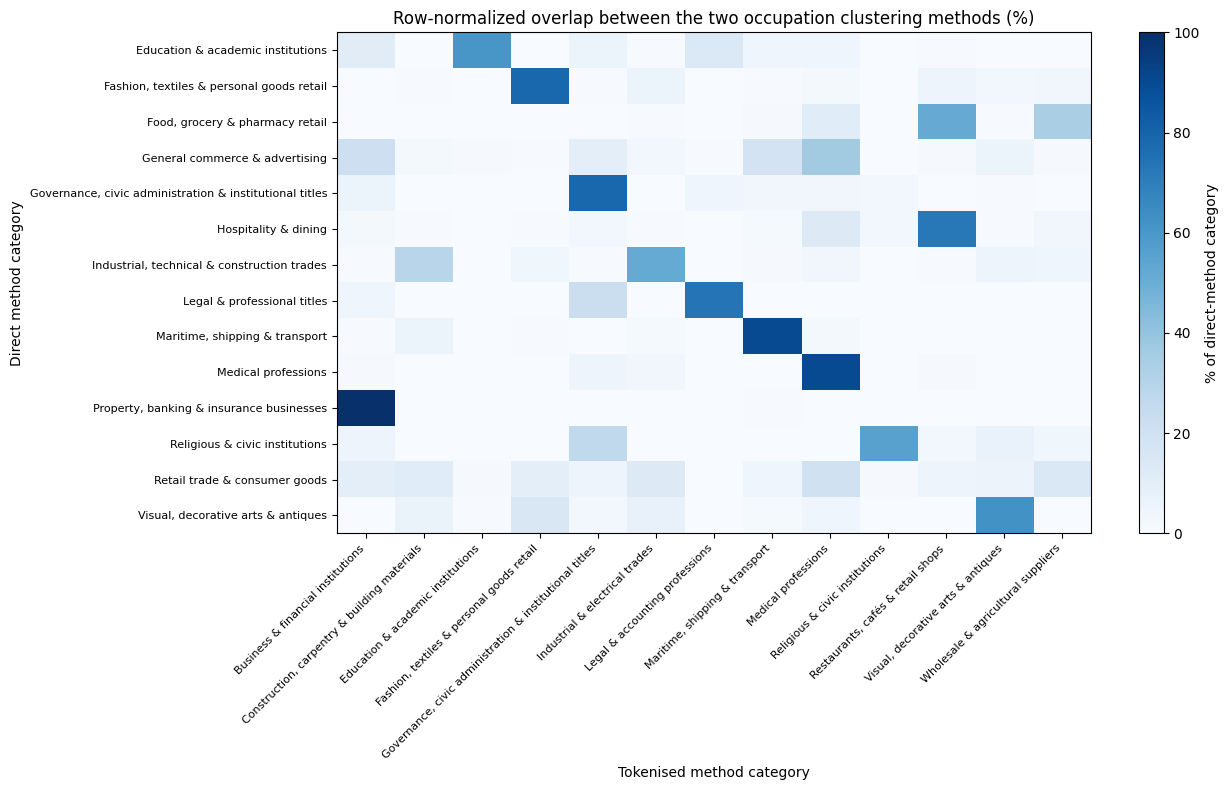

Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_method_comparison_heatmap_20260824_161514.png


In [100]:
# comparison plot -- normalized crosstab as a heatmap (occupation, direct vs tokenised)

fig, ax = plt.subplots(figsize=(13, 8))
im = ax.imshow(occ_crosstab_pct.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(len(occ_crosstab_pct.columns)))
ax.set_xticklabels(occ_crosstab_pct.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(occ_crosstab_pct.index)))
ax.set_yticklabels(occ_crosstab_pct.index, fontsize=8)
ax.set_xlabel("Tokenised method category")
ax.set_ylabel("Direct method category")
ax.set_title("Row-normalized overlap between the two occupation clustering methods (%)")
fig.colorbar(im, ax=ax, label="% of direct-method category")
plt.tight_layout()
out_name = _v("occupation_method_comparison_heatmap.png")
plt.savefig(out_name, dpi=200)
plt.show()
with open(out_name, "rb") as f:
    upload_to_stats("occupation_method_comparison_heatmap.png", f.read(), "image/png", subfolder="occupation_clustering")


In [90]:
# coverage summary -- direct vs tokenised, side by side (occupation)

has_occupation = geo["occupation"].notna().sum()
total = len(geo)

summary_rows_occ = []
for label, col in [("Direct (k=10)", "occupation_category_k10"), ("Tokenised (k=10)", "occupation_category_tokenised_k10")]:
    classified = geo[col].notna().sum()
    n_categories = geo[col].nunique()
    excluded = has_occupation - classified
    summary_rows_occ.append({
        "method": label,
        "total_rows": total,
        "rows_with_occupation_value": has_occupation,
        "rows_classified": classified,
        "pct_of_total": round(100 * classified / total, 1),
        "pct_of_rows_with_occupation": round(100 * classified / has_occupation, 1),
        "n_categories": n_categories,
        "rows_excluded": excluded,
    })

occ_coverage_summary = pd.DataFrame(summary_rows_occ)
print(occ_coverage_summary.to_string(index=False))

csv_bytes = occ_coverage_summary.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_coverage_summary_both_methods.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")


          method  total_rows  rows_with_occupation_value  rows_classified  pct_of_total  pct_of_rows_with_occupation  n_categories  rows_excluded
   Direct (k=10)       16469                       13652            13440          81.6                         98.4            14            212
Tokenised (k=10)       16469                       13652            13521          82.1                         99.0            13            131
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_coverage_summary_both_methods_20260824_161514.csv


In [91]:
# manual-override transparency -- direct vs tokenised (occupation)

def _occ_override_stats(value_overrides, cluster_default_names, cluster_df, value_col):
    n_reassign_defs = sum(1 for v in value_overrides.values() if v is not None)
    n_exclude_defs = sum(1 for v in value_overrides.values() if v is None)
    matched = cluster_df[cluster_df[value_col].isin(value_overrides)]
    reassigned = matched[matched["category_name"].notna()]
    excluded = matched[matched["category_name"].isna()]
    return {
        "n_cluster_defaults": sum(1 for v in cluster_default_names.values() if v is not None),
        "n_overrides_defined": len(value_overrides),
        "n_overrides_reassign": n_reassign_defs,
        "n_overrides_exclude": n_exclude_defs,
        "n_values_reassigned": len(reassigned),
        "rows_reassigned": int(reassigned["frequency"].sum()),
        "n_values_excluded_by_override": len(excluded),
        "rows_excluded_by_override": int(excluded["frequency"].sum()),
    }

direct_occ_stats = _occ_override_stats(VALUE_OVERRIDES_OCC_K10, CLUSTER_DEFAULT_NAMES_OCC_K10, occ_cluster_df_k10, "occupation")
direct_occ_stats["method"] = "Direct (k=10)"

token_occ_stats = _occ_override_stats(OVERRIDES, CLUSTER_DEFAULT, occ_canon_cluster_df, "canonical_label")
token_occ_stats["method"] = "Tokenised (k=10)"

occ_override_summary = pd.DataFrame([direct_occ_stats, token_occ_stats])
occ_override_summary = occ_override_summary[[
    "method", "n_cluster_defaults", "n_overrides_defined", "n_overrides_reassign",
    "n_overrides_exclude", "n_values_reassigned", "rows_reassigned",
    "n_values_excluded_by_override", "rows_excluded_by_override",
]]
print(occ_override_summary.to_string(index=False))

csv_bytes = occ_override_summary.to_csv(index=False).encode("utf-8")
upload_to_stats("occupation_override_transparency_both_methods.csv", csv_bytes, "text/csv", subfolder="occupation_clustering")


          method  n_cluster_defaults  n_overrides_defined  n_overrides_reassign  n_overrides_exclude  n_values_reassigned  rows_reassigned  n_values_excluded_by_override  rows_excluded_by_override
   Direct (k=10)                  10                  492                   469                   23                  463             3503                             23                        112
Tokenised (k=10)                  10                  439                   439                    0                  431             3075                              0                          0
Saved (both) to stats_geo_analysis/20260824_161514/occupation_clustering/: occupation_override_transparency_both_methods_20260824_161514.csv


In [92]:
# final occupation-only CSV 


_OCCUPATION_FINAL_COLS = [
    "Name", "Address", "Location", "occupation", "occupation_category_k10",
    "occupation_category_tokenised_k10", "Category", "Profession", "Role",
    "Additional Info", "matched_lat", "matched_lon", "geocoding_tier",
    "civic_num", "civic_lett", "sestiere_parsed", "parish_parsed",
    "sestiere_implied", "matched_parish", "matched_sestiere", "matched_lett",
    "all_doors", "match_confidence", "match_note",
    "page_num", "section", "source_file",
]
_occ_final_present = [c for c in _OCCUPATION_FINAL_COLS if c in geo.columns]
_occ_final_missing = [c for c in _OCCUPATION_FINAL_COLS if c not in geo.columns]
if _occ_final_missing:
    print(f"  WARNING: final occupation file missing columns: {_occ_final_missing}")

geo_occupation_final = geo[_occ_final_present].copy()
geo_occupation_final = geo_occupation_final.sort_values(
    by="page_num",
    key=lambda s: pd.to_numeric(s, errors="coerce"),
    kind="stable",
).reset_index(drop=True)

_occ_csv_name = f"occupation_inside_venice_geocoded_{RUN_TAG}.csv"
_occ_csv_path = Path(FINAL_OUTPUT_DIR) / _occ_csv_name
geo_occupation_final.to_csv(_occ_csv_path, index=False)
print(f"Saved {len(geo_occupation_final)} rows -> final/{_occ_csv_name}")

# --- GeoJSON export, same file, final/ (not stats_geo_analysis/) ---

_geo_gdf = gpd.GeoDataFrame(
    geo_occupation_final.copy(),
    geometry=gpd.points_from_xy(geo_occupation_final["matched_lon"],
                                 geo_occupation_final["matched_lat"]),
    crs="EPSG:4326",
)
_geojson_name = f"occupation_inside_venice_geocoded_{RUN_TAG}.geojson"
_geojson_path = Path(FINAL_OUTPUT_DIR) / _geojson_name
_geo_gdf.to_file(_geojson_path, driver="GeoJSON")
print(f"Saved GeoJSON -> final/{_geojson_name}")


Saved (both) to stats_geo_analysis/20260824_161514/final_results/occupation_clustering/: geo_inside_venice_occupation_20260824_161514.csv
Saved 16469 rows -> stats_geo_analysis/final_results/occupation_clustering/geo_inside_venice_occupation_20260824_161514.csv
Saved GeoJSON -> stats_geo_analysis/final_results/occupation_clustering/geo_inside_venice_occupation_20260824_161514.geojson


# Dropped (kept for reference only)

In [93]:


#using the Hiscos method with OccCanine - same as NYC almanac

# ── Build 50-value test sample for OccCANINE comparison ──
# Excludes Uncategorized/Address fragments — those aren't real occupations.

SAMPLE_SIZE = 50
EXCLUDE_CATEGORIES = {"Uncategorized", "Address fragments / non-profession"}

candidates = cluster_df[~cluster_df["category_name"].isin(EXCLUDE_CATEGORIES)].copy()
candidates = candidates.sort_values("frequency", ascending=False)

# Stratified-ish: mix of high-frequency and a few mid-frequency terms
sample_it = candidates.head(SAMPLE_SIZE)[["profession", "frequency", "category_name"]].reset_index(drop=True)
print(f"Selected {len(sample_it)} Italian test values:")
print(sample_it.to_string(index=False))

# --- Translate to English via GPT-4o (reusing existing key-loading pattern) ---
api_file = Path(OPENAI_KEY_FILE)
with open(api_file, "r") as f:
    cont = f.readlines()
params = dict(v.strip().split("=", 1) for v in cont if "=" in v)
client = OpenAI(api_key=params["api_key"])

def translate_it_to_en(text):
    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[{
            "role": "user",
            "content": f"Translate this Italian occupation/profession term to English. "
                       f"Reply with ONLY the translation, nothing else: {text}"
        }],
        temperature=0,
    )
    return resp.choices[0].message.content.strip()

sample_it["english_translation"] = sample_it["profession"].apply(translate_it_to_en)
print("\nWith translations:")
print(sample_it[["profession", "english_translation"]].to_string(index=False))

# --- Save both as OccCANINE-ready CSVs (needs a column, default 'occ1') ---
_it_name = _v("occcanine_test_italian.csv")
_en_name = _v("occcanine_test_english.csv")
sample_it[["profession"]].rename(columns={"profession": "occ1"}).to_csv(
    _it_name, index=False
)
sample_it[["english_translation"]].rename(columns={"english_translation": "occ1"}).to_csv(
    _en_name, index=False
)
print(f"\nSaved: {_it_name}, {_en_name}")

Selected 50 Italian test values:
                                                             profession  frequency                                category_name
                                                    Vendita e Mobilizzi        544                          General goods trade
                     Macchine per scrivere - Calcolatrici - Duplicatori        360 Office & mechanical equipment (ad-dominated)
                        MACCHINE PER SCRIVERE - DUPLICATORI - ACCESSORI        359 Office & mechanical equipment (ad-dominated)
                                                      Medicina generale        216                          Medical professions
             Tutti i prodotti ZAMPIRONI INSETTIFUGHI di massima fiducia        194           General goods trade (ad-dominated)
                       Rappresentante di case produttrici di medicinali        186    Sales representatives / Commercial agents
                                                              industria